
<h1><center>Potencial por cuenta</center></h1>

# Variables Globales

In [1]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pytz
import pandas as pd

In [2]:
Zona = pytz.timezone('America/Lima')
peru_time = datetime.now(Zona)
var_fecha_dt = peru_time - timedelta(days=1)
var_fecha = var_fecha_dt.strftime('%Y-%m-%d')

In [3]:
var_fecha

'2026-07-01'

In [4]:
var_fecha = '2026-06-30'

In [5]:
##Primer dia y ultimo dia del mes

In [6]:
var_fecha_fin = var_fecha
var_fecha_dt = datetime.strptime(var_fecha, '%Y-%m-%d')
primer_dia_mes = var_fecha_dt.replace(day=1)
var_fecha_ini = primer_dia_mes.strftime('%Y-%m-%d')
periodo = var_fecha_dt.strftime('%Y%m')
var_ult_dia_fecha_dt = var_fecha_dt + pd.offsets.MonthEnd(0)
var_ult_dia_fecha = var_ult_dia_fecha_dt.strftime('%Y-%m-%d')


In [7]:
# var_fecha_dt = datetime.strptime(var_fecha, '%Y-%m-%d')
# var_fecha_ant_dt = var_fecha_dt - timedelta(days=1)
# var_fecha_fin = var_fecha_ant_dt.strftime('%Y-%m-%d')

# primer_dia_mes = var_fecha_ant_dt.replace(day=1)
# var_fecha_ini = primer_dia_mes.strftime('%Y-%m-%d')

# var_fecha_fin_mes_ant = var_fecha_dt - relativedelta(months=1)
# var_periodo_ant = var_fecha_fin_mes_ant.strftime('%Y%m')

In [8]:
var_fecha_fin

'2026-06-30'

In [9]:
var_fecha_ini

'2026-06-01'

In [10]:
# !pip install --upgrade bigframes

## Proyectos

In [11]:
#@title Setup Project Variables { run: "auto", display-mode: "form" }
var_project_operation = "prd-izipay-data-operation" #@param {type:"string"}
var_project_storage = "prd-izipay-data-storage-pv" #@param {type:"string"}
var_project_sensitive = "prd-izipay-data-sensitive" #@param {type:"string"}

from google.cloud import bigquery
client = bigquery.Client()

In [12]:
#@title Dataset Business { run: "auto", display-mode: "form" }
var_dataset_business_stage = "business_stage" #@param {type:"string"}

var_dataset_bi_apm = "bi_apm" #@param {type:"string"}
var_table_dv_potencial_cuenta = "dv_potencial_cuenta" #@param {type:"string"}
var_table_dv_potencial_cuenta_agrupado = "dv_potencial_cuenta_agrupado" #@param {type:"string"}
var_table_dv_potencial_cuenta_detalle = "dv_potencial_cuenta_detalle" #@param {type:"string"}

var_dataset_master_stage_transaction = "master_stage_transaction" #@param {type:"string"}
var_table_t_potencial_cuenta = "t_potencial_cuenta" #@param {type:"string"}


## Dataset Raw

In [13]:
#@title Dataset Planeamiento { run: "auto", display-mode: "form" }
var_dataset_raw_de_planeamiento = "raw_de_planeamiento" #@param {type:"string"}
var_dataset_raw_dataentry_planeamiento = "raw_dataentry_planeamiento" #@param {type:"string"}
var_table_te_scrapper_pxc = "te_scrapper_pxc" #@param {type:"string"}
var_table_te_base_azul_pxc = "te_base_azul_pxc" #@param {type:"string"}
var_table_te_catalogo_vertical_giro = "te_catalogo_vertical_giro" #@param {type:"string"}
var_table_te_grupo_economico = "te_grupo_economico" #@param {type:"string"}
var_table_te_giro = "te_giro" #@param {type:"string"}
var_table_te_scrapper2_pxc = "te_scrapper2_pxc" #@param {type:"string"}
var_table_te_catalogo_banco = "te_catalogo_banco" #@param {type:"string"}


In [14]:
#@title Dataset OM { run: "auto", display-mode: "form" }
var_dataset_raw_om = "raw_om" #@param {type:"string"}
var_table_bdlogvisita = "bdlogvisita" #@param {type:"string"}


## Dataset Transaction

In [15]:
#@title Setup Project Variables { run: "auto", display-mode: "form" }

var_dataset_master_transaction = "master_transaction" #@param {type:"string"}
var_table_t_consumo_ibk = "t_consumo_ibk" #@param {type:"string"}
var_table_t_detalle_transacciones = "t_detalle_transacciones" #@param {type:"string"}

var_dataset_raw_synapse = "raw_synapse" #@param {type:"string"}
var_table_segmentacion = "segmentacion" #@param {type:"string"}

var_dataset_master_placement = "master_placement" #@param {type:"string"}
var_table_m_establecimiento = "m_establecimiento" #@param {type:"string"}
var_table_m_parque_hist = "m_parque_hist" #@param {type:"string"}



In [16]:

#@title Setup Project Variables { run: "auto", display-mode: "form" }

var_dataset_master_transaction = "master_transaction" #@param {type:"string"}
var_table_t_consumo_ibk = "t_consumo_ibk" #@param {type:"string"}
var_table_t_detalle_transacciones = "t_detalle_transacciones" #@param {type:"string"}
var_dataset_master_party = "master_party" #@param {type:"string"}

var_dataset_raw_synapse = "raw_synapse" #@param {type:"string"}
var_table_segmentacion = "segmentacion" #@param {type:"string"}

var_dataset_master_placement = "master_placement" #@param {type:"string"}
var_table_m_establecimiento = "m_establecimiento" #@param {type:"string"}
var_table_m_parque_hist = "m_parque_hist" #@param {type:"string"}
var_table_m_comercio = "m_comercio" #@param {type:"string"}


# Cargar Librerias

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dateutil.relativedelta import relativedelta
import re
from datetime import timedelta
import plotly.express as px
from tqdm import tqdm
#from fuzzywuzzy import fuzz
import warnings
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
def custom_format(x):
    return f"{x:.2f}"

pd.options.display.float_format = custom_format

pd.set_option('display.max_columns', None)

izipay_colors = ['#004080', '#FF6600', '#FFD700', '#008000', '#FFFFFF', '#000000']

# Aplica la paleta de colores
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=izipay_colors)
sns.set_palette(sns.color_palette(izipay_colors))

show_fig = False

# tasacambio = 3.764
# periodo = '202408' #AVANCE
# fecha = '20240831'
# periodo_m1 = '202408' #CIERRE

# ruta_maes = 'C:\\Users\\User\\OneDrive - L&S Consulting S.A.C\\Delfosti\\PxC\\'

In [18]:
!pip install fuzzywuzzy
from fuzzywuzzy import fuzz

# Carga de datos <a class="anchor" id="chapter1"></a>


Se cargan las diferentes bases de datos, sean las bases principales (amex, izipay y ibk) y las bases complementarias (grupo económico, mcc-giro-vertical y el adicional de codigo-nroruc.

## Bases Complementarias

### Scrapper

Carga la base maesra del scrapper

In [19]:
query = f"""
select
  nroruc,
  razsoc
from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_scrapper_pxc}`
"""
scrapper = client.query(query).to_dataframe()

In [20]:
scrapper.head()

,nroruc,razsoc
0,10818310442,MARÍA GABRIELA HOLGUIN FIGUEIRA
1,10028802655,MARTHA CECILIA CARBAJAL SEMINARIO
2,10094396722,MADELEINE JACQUELINE GONZALEZ PUENTE
3,10417956129,URSULA MARIA WERTHEMAN BECERRA
4,10420157784,ANTONIO SIXCO CUEVAS RODRIGUEZ


In [21]:
scrapper['nroruc'] = scrapper['nroruc'].astype(str)

In [22]:
scrapper.nroruc = scrapper.nroruc.str.strip().str.lstrip('0')
scrapper.head()

,nroruc,razsoc
0,10818310442,MARÍA GABRIELA HOLGUIN FIGUEIRA
1,10028802655,MARTHA CECILIA CARBAJAL SEMINARIO
2,10094396722,MADELEINE JACQUELINE GONZALEZ PUENTE
3,10417956129,URSULA MARIA WERTHEMAN BECERRA
4,10420157784,ANTONIO SIXCO CUEVAS RODRIGUEZ


In [23]:
scrapper.nunique()

,0
nroruc,4783
razsoc,4783


### Codigo/Ruc
Carga del archivo que a mano da un nroruc para codigos

In [24]:
query = f"""
select
  codigo,
  nroruc
from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_base_azul_pxc}`
"""
codigonroruc = client.query(query).to_dataframe()

In [25]:
codigonroruc['nroruc'] = codigonroruc['nroruc'].astype(str)
codigonroruc['codigo'] = codigonroruc['codigo'].astype(str)

In [26]:
codigonroruc.nroruc = codigonroruc.nroruc.str.strip().str.lstrip('0')
codigonroruc.codigo = codigonroruc.codigo.str.strip().str.lstrip('0')
codigonroruc = codigonroruc.loc[codigonroruc.nroruc != ""].copy()
codigonroruc.head()

,codigo,nroruc
0,999999,20334461875
7,8717771,10
8,8367503,2054
9,9278677,7633
10,8561311,8420


In [27]:
codigonroruc.nunique()

,0
codigo,370901
nroruc,253112


### Mcc/Giro/Vertical

In [28]:
query = f"""
select
  mcc,
  giro,
  vertical
from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_catalogo_vertical_giro}`
"""
mccgv = client.query(query).to_dataframe()

In [29]:
# %%bigquery mccgv
# SELECT * FROM dev-izipay-data-operation.camila.base_mccgv_202404_raw

In [30]:
mccgv.dtypes

,0
mcc,object
giro,object
vertical,object


In [31]:
mccgv.head()

,mcc,giro,vertical
0,9399,Servicios Gubernamentales,GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS
1,8050,Enfermeras,GRUPO 4 - SALUD
2,8062,"Hospitales, clinicas",GRUPO 4 - SALUD
3,8071,Laboratorios medicos,GRUPO 4 - SALUD
4,5976,Aparatos ortopedicos,GRUPO 4 - SALUD


In [32]:
mccgv.nunique()

,0
mcc,295
giro,292
vertical,8


### Grupo Economico Revisar

In [33]:
# query = f"""
# select
#   ruc as nroruc,
#   grupo_economico as greco
# from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_grupo_economico}`
# where process_date = '{var_ult_dia_fecha}'
# group by 1,2
# """
# nroruc_greco = client.query(query).to_dataframe()

In [34]:
%%bigquery nroruc_greco
SELECT
  nroruc,
  greco
FROM `prd-izipay-data-storage-pv.raw_de_planeamiento.ge_ene25`
group by 1,2

Query is running:   0%|          |

Downloading:   0%|          |

In [35]:
nroruc_greco['nroruc'] = nroruc_greco['nroruc'].astype(str)

In [36]:
nroruc_greco.nroruc = nroruc_greco.nroruc.str.strip().str.lstrip('0')
nroruc_greco.head()

,nroruc,greco
0,20508647311,4D
1,20508645539,4D
2,20601977207,4D
3,20508647400,4D
4,20514033987,4D


In [37]:
nroruc_greco.greco.value_counts(dropna=False)

,count
greco,
MONTALVO,154
GRUPO NORKYS,127
RUSTICA,61
MULTIDENT,45
GRUPO ROKYS,39
...,...
TIENDAS ROJAS,1
TRES REGIONES,1
UCV GRIFOS II,1


### Mcc/Giro

In [38]:
query = f"""
select
  mcc,
  giro
from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_giro}`
"""
giro = client.query(query).to_dataframe()

In [39]:
# %%bigquery giro
# SELECT * FROM dev-izipay-data-operation.camila.giro_ago24_

In [40]:
giro.head()

,mcc,giro
0,3351,Affiliated Auto Rental
1,5661,Zapaterias
2,5111,Mayorista de artículos de papelería y de
3,5815,Bienes digitales-Medios audiovisuales y libros...
4,5722,Accesorios para el hogar


In [41]:
# Combinar las tablas para agregar los giros faltantes
mccgiro = pd.concat([giro], axis=0, ignore_index=True)
mccgiro['giro']=mccgiro['giro'].str.strip()

In [42]:
mccgiro

,mcc,giro
0,3351,Affiliated Auto Rental
1,5661,Zapaterias
2,5111,Mayorista de artículos de papelería y de
3,5815,Bienes digitales-Medios audiovisuales y libros...
4,5722,Accesorios para el hogar
...,...,...
237,3102,Iberia-IBERIA
238,7641,Tapiceria
239,8050,Enfermeras
240,5963,Ventas puerta a puerta


In [43]:
# se toma un giro por mcc
mccgiro.drop_duplicates(subset='giro', inplace=True)

In [44]:
mccgiro.nunique()

,0
mcc,242
giro,242


In [45]:
mccgiro.shape

(242, 2)

### Datos Manuales

In [46]:
query = f"""
select
  codigo as Codigo,
  ruc as Ruc,
  razon_social as Razon_Social
from `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_scrapper2_pxc}`
"""
datos_manuales = client.query(query).to_dataframe()

In [47]:
# %%bigquery datos_manuales
# SELECT * FROM dev-izipay-data-operation.camila.datos_manuales_ago24_

In [48]:
datos_manuales['Ruc'] = datos_manuales['Ruc'].astype(str)
datos_manuales['Codigo'] = datos_manuales['Codigo'].astype(str)

In [49]:
datos_manuales.Ruc = datos_manuales.Ruc.str.strip().str.lstrip('0')
datos_manuales.Codigo = datos_manuales.Codigo.str.strip().str.lstrip('0')

In [50]:
print(datos_manuales.shape[0])
datos_manuales.dropna(inplace=True, axis=0, thresh=2)
datos_manuales['Razon_Social'] = datos_manuales['Razon_Social'].str.replace('.','').str.strip()
print(datos_manuales.shape[0])

539978
539978


In [51]:
datos_manuales.head()

,Codigo,Ruc,Razon_Social
0,999999301,10099999352,MIRANDA CALDERON CARMEN ISABEL
1,6130010,15604534884,None
2,6147416,10101270772,None
3,6152980,10741339159,None
4,6154860,20414550551,None


### Cotizador

In [52]:
# query = f"""
# select
#   split(nro_ruc,' ')[offset(0)] as nroruc,
#   codigo_comercio as codigo
# from `{var_project_storage}.{var_dataset_raw_om}.{var_table_bdlogvisita}`
# where  flag_codigo_comercio = '1'
# and process_date <= '{var_fecha_fin}'
# group by 1,2
# """
# cotizador = client.query(query).to_dataframe()

In [53]:
query = f"""
with temp_log_hash  as
(
  select
    ruc_hasheado,
    ruc
  from `prd-izipay-data-storage-pv.raw_logs.firestore_log_hash`
  where process_date <= '{var_fecha_fin}'
  group by all
)
select
  ifnull(c.ruc,split(a.nro_ruc,' ')[offset(0)]) as nroruc,
  a.codigo_comercio as codigo,
from `{var_project_storage}.{var_dataset_raw_om}.{var_table_bdlogvisita}` a
left join temp_log_hash c on (split(a.nro_ruc,' ')[offset(0)] = c.ruc_hasheado )
where  flag_codigo_comercio = '1'
and process_date <= '{var_fecha_fin}'
group by all
"""
cotizador = client.query(query).to_dataframe()

In [54]:
cotizador['nroruc'] = cotizador['nroruc'].astype(str)
cotizador['codigo'] = cotizador['codigo'].astype(str)

In [55]:
cotizador.nroruc = cotizador.nroruc.str.strip().str.lstrip('0')
cotizador.codigo = cotizador.codigo.str.strip().str.lstrip('0')
cotizador.head()

,nroruc,codigo
0,74297503,5504292
1,47749833,5550042
2,47749833,5550022
3,70777992,5768934
4,24580111,5550005


In [56]:
print(f"Cantidad de Códigos Distintos: {cotizador['codigo'].nunique()}")
print(f"Cantidad de RUCs Distintos: {cotizador['nroruc'].nunique()}")

Cantidad de Códigos Distintos: 108821
Cantidad de RUCs Distintos: 86722


## Amex

In [57]:
# %%bigquery amex
# SELECT * FROM dev-izipay-data-operation.camila.amez_ago24_2

In [58]:
# query = f"""
# select
#   format_date('%Y%m',a.process_date) as periodo,
#   regexp_replace
#     (
#       case
#         when length(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', '')) in (9, 10) and starts_with(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', ''), '0')
#           then right(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', ''), 8)
#         else regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', '')
#       end, r'"', ''
#      ) as nroruc,
#   a.pdcest as codigo,
#   c.nomcom as nombrecomercial,
#   case when a.pdbcoe = '3' then b.nombrebanco else 'OTROS' end as banco,
#   c.mcc as mcc,
#   c.giro as giro,
#   c.contra as facilitador,
#   sum(importe) as monto,
#   count(1) as trx
# FROM `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_detalle_transacciones}` a
# left join `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_catalogo_banco}` b on (a.pdbcoe = b.codbco)
# left join `{var_project_storage}.{var_dataset_master_placement}.{var_table_m_establecimiento}` c on (cast(a.pdcest as int64) = cast(c.codigo as int64))
# where a.process_date between '{var_fecha_ini}' and '{var_fecha_fin}'
# and  upper(filtro_trx) like '%AMEX%'
# group by  1,  2,  3,  4,  5,  6, 7, 8
# """
# amex = client.query(query).to_dataframe()

In [59]:
query = f"""
with
cte_party_id_izi as
(
  select party_id_izi, document_number
  from `{var_project_sensitive}.master_pii.iden_party_data_control`
  where party_id_izi <>'-1'
),
cte_deduplicated as
(
  select
    party_id_izi,
    document_number,
    ROW_NUMBER() OVER (PARTITION BY party_id_izi ORDER BY document_number) as rn
  from cte_party_id_izi
)
,cte_party_id_izi_final as
(
  select
    party_id_izi,
    document_number
  from cte_deduplicated
  where rn = 1
)
,
cte_base_m_establecimiento as
(
  select
    b.document_number as nroruc
    ,a.nom_comercio as nomcom
    ,a.cod_comercio as codigo
    ,a.cod_giro_comercio as mcc
    ,a.nom_giro_comercio as giro
    ,a.cod_contrato as contra
 from `{var_project_storage}.{var_dataset_master_party}.{var_table_m_comercio}` a
left join  cte_party_id_izi_final b on a.party_id_izi = b.party_id_izi
)
select
  format_date('%Y%m',a.process_date) as periodo,
  regexp_replace
    (
      case
        when length(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', '')) in (9, 10) and starts_with(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', ''), '0')
          then right(regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', ''), 8)
        else regexp_replace(regexp_replace(c.nroruc, r'\\s', ''), r'\\.0$', '')
      end, r'"', ''
     ) as nroruc,
  a.pdcest as codigo,
  c.nomcom as nombrecomercial,
  case when a.pdbcoe = '3' then b.nombrebanco else 'OTROS' end as banco,
  c.mcc as mcc,
  c.giro as giro,
  c.contra as facilitador,
  sum(importe) as monto,
  count(1) as trx
FROM `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_detalle_transacciones}` a
left join `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_catalogo_banco}` b on (a.pdbcoe = b.codbco)
left join cte_base_m_establecimiento c on (cast(a.pdcest as int64) = cast(c.codigo as int64))
where a.process_date between '{var_fecha_ini}' and '{var_fecha_fin}'
and  upper(filtro_trx) like '%AMEX%'
 group by  1,  2,  3,  4,  5,  6, 7, 8
"""
amex = client.query(query).to_dataframe()

In [60]:
amex['nroruc'] = amex['nroruc'].astype(str)
amex['mcc'] = amex['mcc'].astype(str)
amex['codigo'] = amex['codigo'].astype(str)

In [61]:
amex.head()

,periodo,nroruc,codigo,nombrecomercial,banco,mcc,giro,facilitador,monto,trx
0,202606,20563788713,6457646,BISSU,OTROS,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR",NIUBIZ-AX,282.10,6
1,202606,20507795642,6580088,SAN MIGUEL,OTROS,5261,VIVEROS,NIUBIZ-AX,59.00,1
2,202606,20517261387,6535209,OPTICAS JVQ,Interbank,8043,OPTICAS,OPEN-AX,1280.00,3
3,202606,20602313906,6047107,CONSORCIO VETERINARIO,OTROS,5995,MASCOTAS Y ACCESORIOS,NIUBIZ-AX,1264.20,10
4,202606,20521128187,6515388,BONANZA HUARAL,Interbank,7392,CONSULTORÍA DE GESTIÓN Y SERVICIOS DE RELACION...,NIUBIZ-AX,305.00,2


### Resultado

In [62]:
print(f"Volumen Total: {amex['monto'].sum()}")
print(f"\nVolumen por Banco:\n{amex.groupby('banco')['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {amex['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {amex['nroruc'].nunique()}")

Volumen Total: 163011218.31000298

Volumen por Banco:
banco
Interbank   97506265.03
OTROS       65504953.28
Name: monto, dtype: float64

Cantidad de Códigos Distintos: 27121

Cantidad de RUCs Distintos: 12108


In [63]:
# Limpieza inicial
amex.codigo = amex.codigo.str.strip().str.lstrip('0')
amex.nroruc = amex.nroruc.str.strip().str.lstrip('0')
amex['giro']=amex['giro'].str.strip()
amex.monto = amex.monto.astype('float64')
amex.loc[amex.monto < 0, 'monto'] = 0
amex

,periodo,nroruc,codigo,nombrecomercial,banco,mcc,giro,facilitador,monto,trx
0,202606,20563788713,6457646,BISSU,OTROS,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR",NIUBIZ-AX,282.10,6
1,202606,20507795642,6580088,SAN MIGUEL,OTROS,5261,VIVEROS,NIUBIZ-AX,59.00,1
2,202606,20517261387,6535209,OPTICAS JVQ,Interbank,8043,OPTICAS,OPEN-AX,1280.00,3
3,202606,20602313906,6047107,CONSORCIO VETERINARIO,OTROS,5995,MASCOTAS Y ACCESORIOS,NIUBIZ-AX,1264.20,10
4,202606,20521128187,6515388,BONANZA HUARAL,Interbank,7392,CONSULTORÍA DE GESTIÓN Y SERVICIOS DE RELACION...,NIUBIZ-AX,305.00,2
...,...,...,...,...,...,...,...,...,...,...
43796,202606,20131366702,6396740,MUNI PTE PIEDRA COBRANZA DOMICILIO,OTROS,9311,"MUNICIPALIDADES, TRIBUTOS",NIUBIZ-AX,588.10,6
43797,202606,20100030595,6131004,BANCO DE LA NACION AG DL,OTROS,9311,"MUNICIPALIDADES, TRIBUTOS",NIUBIZ-AX,11858.98,5
43798,202606,20131378204,6406633,ARBITRIOS Y TASAS,Interbank,9311,"MUNICIPALIDADES, TRIBUTOS",NIUBIZ-AX,13168.40,15
43799,202606,20285139415,6554595,OFICINA REGISTRAL DE TARAPOTO,OTROS,9311,"MUNICIPALIDADES, TRIBUTOS",NIUBIZ-AX,4460.60,6


Total de valores perdidos: 0


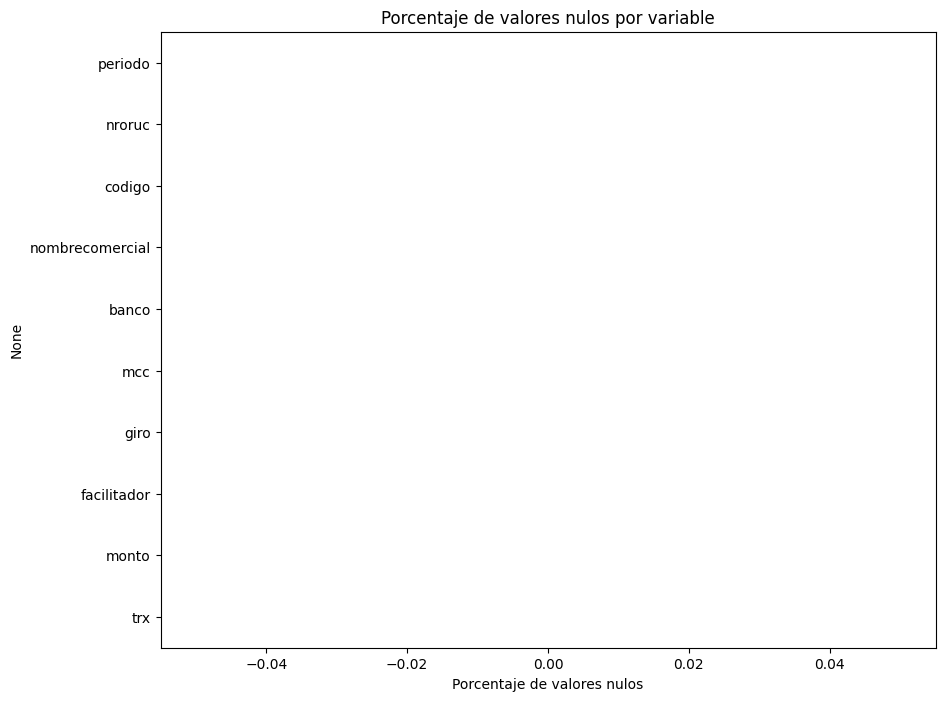

In [64]:
# Evaluar la presencia de nulos
print('Total de valores perdidos: {}'.format(amex.isnull().sum().sum()))

# Calcular el porcentaje de valores nulos por cada variable
porcentaje_null = (amex.isnull().sum() / len(amex)) * 100

# Crear un gráfico de barras horizontal con seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x=porcentaje_null.values, y=porcentaje_null.index, palette='viridis')
plt.xlabel('Porcentaje de valores nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.show()

### Consistencia

Se revisa la consistencia de datos. Se entiende por consistencia que solo se le puede atribuir, dependiendo del campo, un mismo valor a un mismo código de comercio o RUC. En caso haya inconsistencia, se corrige tomando el valor con el mayor monto transaccionado.

#### Codigo y Ruc

Un código solo puede tener un nroruc.

In [65]:
temp = amex[['codigo', 'nroruc']].drop_duplicates()
temp

,codigo,nroruc
0,6457646,20563788713
1,6580088,20507795642
2,6535209,20517261387
3,6047107,20602313906
4,6515388,20521128187
...,...,...
43784,6146735,20131366613
43785,6480354,20100047218
43787,6667866,20131380951
43788,6397441,20260998898


In [66]:
temp.nunique()

,0
codigo,27121
nroruc,12108


In [67]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único nroruc.')

Cada código está relacionado a un único nroruc.


#### Codigo y Nombre Comercial

In [68]:
temp = amex[['codigo', 'nombrecomercial']].drop_duplicates().sort_values(by='codigo')
temp

,codigo,nombrecomercial
1676,6000073,FUNDACION MUSEO AMANO SOL
2146,6000080,FUNDACION MUSEO AMANO
9493,6000561,COMERCIAL MARISCAL
24249,6001024,PIZZERIA QUINUA DEL VALLE
1980,6001067,LENCERIA BELEN
...,...,...
23799,6676377,INIRSA
23226,6676405,MI TERCER LUGAR SAN MIGUEL
38380,6676448,DEL PRADO HOTEL
38506,6676449,DEL PRADO HOTEL


In [69]:
temp.nunique()

,0
codigo,27121
nombrecomercial,18632


In [70]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único nombre comercial.')
temp[temp.duplicated(subset='codigo', keep=False)]

Cada código está relacionado a un único nombre comercial.


,codigo,nombrecomercial


#### Ruc y Nombre Comercial

Un nroruc solo puede tener un nombre comercial.

In [71]:
temp = amex[['nroruc', 'nombrecomercial']].drop_duplicates().sort_values(by='nroruc')
temp

,nroruc,nombrecomercial
28846,10000269706,RESTOBAR AL PALO A LA PARRILLA
25106,10000269706,RESTAURANT AL PALO Y LA PARRILLA
27281,10000825196,CAMUCHA
16964,10002132660,PARRILLADAS COLCHADO
24571,10002401326,CREMOLADERIA RST SI SENOR
...,...,...
17748,20615923282,TORTAS CIELO
15616,20615933733,TORTAS CIELO
29445,20615952878,SABORES AUTENTICOS MARY SAC
16692,20615956458,TORTAS CIELO


In [72]:
temp.nunique()

,0
nroruc,12108
nombrecomercial,18632


In [73]:
if temp.nroruc.nunique() == temp.shape[0]:
    print('Cada código está relacionado a un único nombre comercial.')
else:
    print('No todos los códigos están relacionados a un único nombre comercial.')
    # Muestra las filas duplicadas basadas en nroruc
    duplicados = temp[temp.duplicated(subset='nroruc', keep=False)]

No todos los códigos están relacionados a un único nombre comercial.


In [74]:
duplicados

,nroruc,nombrecomercial
28846,10000269706,RESTOBAR AL PALO A LA PARRILLA
25106,10000269706,RESTAURANT AL PALO Y LA PARRILLA
1330,10008398670,KAMILA BAZAR
2489,10008398670,BAZAR CAMILA
21113,10009673976,GRIFO VENECIA I
...,...,...
26519,20615781461,GOLDEN EMPERADOR SAC
8228,20615833020,CUSELA PAX2
8363,20615833020,CUSELA QUILLABAMBA PAX 1
8038,20615833020,CUSELA ENC 3


In [75]:
temp = temp.drop_duplicates(subset='nroruc')
print(temp.shape, temp.nroruc.nunique())

(12108, 2) 12108


In [76]:
amex = amex.drop(columns='nombrecomercial')
amex = amex.merge(temp, on='nroruc', how='left')

#### Monto

No deben haber valores negativos

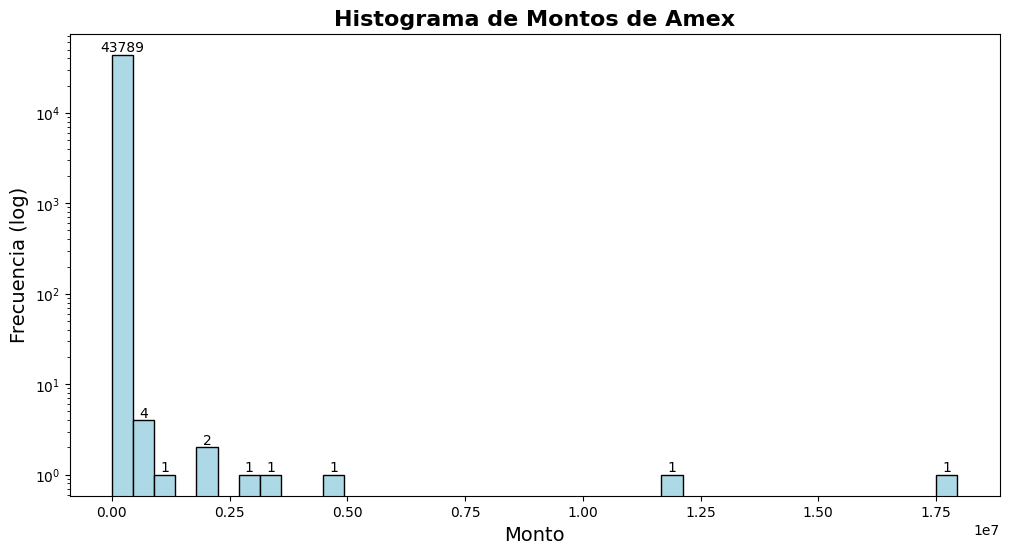

In [77]:
# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(12, 6))
# Crear el histograma
n, bins, patches = ax.hist(amex.monto, bins=40, log=True, edgecolor='black',color='lightblue')
# Personalizar el gráfico
ax.set_title('Histograma de Montos de Amex', fontsize=16, weight='bold')
ax.set_xlabel('Monto', fontsize=14)
ax.set_ylabel('Frecuencia (log)', fontsize=14)
# Agregar etiquetas de datos en cada barra
for i in range(len(patches)):
    height = patches[i].get_height()
    if height > 0:  # Agregar etiquetas solo a las barras no vacías
        ax.text(patches[i].get_x() + patches[i].get_width() / 2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10, color='black')
# Mostrar el gráfico
plt.show()

#### Mcc&Giro

In [78]:
temp = amex[['codigo', 'mcc', 'giro']].drop_duplicates()
temp

,codigo,mcc,giro
0,6457646,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR"
1,6580088,5261,VIVEROS
2,6535209,8043,OPTICAS
3,6047107,5995,MASCOTAS Y ACCESORIOS
4,6515388,7392,CONSULTORÍA DE GESTIÓN Y SERVICIOS DE RELACION...
...,...,...,...
43784,6146735,9311,"MUNICIPALIDADES, TRIBUTOS"
43785,6480354,9311,"MUNICIPALIDADES, TRIBUTOS"
43787,6667866,9311,"MUNICIPALIDADES, TRIBUTOS"
43788,6397441,9311,"MUNICIPALIDADES, TRIBUTOS"


In [79]:
temp.nunique()

,0
codigo,27121
mcc,219
giro,218


In [80]:
temp = amex.groupby(by=['codigo', 'mcc', 'giro'])['monto'].sum().reset_index()
temp.sort_values(by=['codigo', 'monto'], inplace=True)
temp

,codigo,mcc,giro,monto
0,6000073,8398,ORGANIZACIONES SIN FINES DE LUCRO,990.00
1,6000080,5971,"GALERIAS DE ARTE, MUSEOS",3057.50
2,6000561,5139,CALZADO COMERCIAL,2198.00
3,6001024,5812,RESTAURANTES,1346.00
4,6001067,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR",48.00
...,...,...,...,...
27116,6676377,5812,RESTAURANTES,64.80
27117,6676405,5812,RESTAURANTES,1118.00
27118,6676448,7011,"HOTELES, HOSTALES, MOTELES",1434.30
27119,6676449,7011,"HOTELES, HOSTALES, MOTELES",262.75


In [81]:
temp.drop_duplicates(subset='codigo', inplace=True, keep='last')
temp

,codigo,mcc,giro,monto
0,6000073,8398,ORGANIZACIONES SIN FINES DE LUCRO,990.00
1,6000080,5971,"GALERIAS DE ARTE, MUSEOS",3057.50
2,6000561,5139,CALZADO COMERCIAL,2198.00
3,6001024,5812,RESTAURANTES,1346.00
4,6001067,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR",48.00
...,...,...,...,...
27116,6676377,5812,RESTAURANTES,64.80
27117,6676405,5812,RESTAURANTES,1118.00
27118,6676448,7011,"HOTELES, HOSTALES, MOTELES",1434.30
27119,6676449,7011,"HOTELES, HOSTALES, MOTELES",262.75


In [82]:
amex.drop(columns='giro', inplace=True)

In [83]:
amex.drop(columns='mcc', inplace=True)

In [84]:
amex = amex.merge(temp[['codigo', 'mcc', 'giro']], on='codigo', how='left')
amex

,periodo,nroruc,codigo,banco,facilitador,monto,trx,nombrecomercial,mcc,giro
0,202606,20563788713,6457646,OTROS,NIUBIZ-AX,282.10,6,BISSU,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR"
1,202606,20507795642,6580088,OTROS,NIUBIZ-AX,59.00,1,SAN MIGUEL,5261,VIVEROS
2,202606,20517261387,6535209,Interbank,OPEN-AX,1280.00,3,OPTICAS JVQ,8043,OPTICAS
3,202606,20602313906,6047107,OTROS,NIUBIZ-AX,1264.20,10,CONVET,5995,MASCOTAS Y ACCESORIOS
4,202606,20521128187,6515388,Interbank,NIUBIZ-AX,305.00,2,SALA ROYAL,7392,CONSULTORÍA DE GESTIÓN Y SERVICIOS DE RELACION...
...,...,...,...,...,...,...,...,...,...,...
43796,202606,20131366702,6396740,OTROS,NIUBIZ-AX,588.10,6,ARBITRIOS,9311,"MUNICIPALIDADES, TRIBUTOS"
43797,202606,20100030595,6131004,OTROS,NIUBIZ-AX,11858.98,5,BANCO DE LA NACION AG SL,9311,"MUNICIPALIDADES, TRIBUTOS"
43798,202606,20131378204,6406633,Interbank,NIUBIZ-AX,13168.40,15,MUNICIPALIDAD DISTRITAL DE SAN JUAN DE MIRAFLORES,9311,"MUNICIPALIDADES, TRIBUTOS"
43799,202606,20285139415,6554595,OTROS,NIUBIZ-AX,4460.60,6,OFICINA RECEPTORA LAMAS,9311,"MUNICIPALIDADES, TRIBUTOS"


In [85]:
temp = amex[['codigo', 'mcc', 'giro']].drop_duplicates()
temp

,codigo,mcc,giro
0,6457646,5631,"ROPA MUJERES, LENCERIA, ROPA INTERIOR"
1,6580088,5261,VIVEROS
2,6535209,8043,OPTICAS
3,6047107,5995,MASCOTAS Y ACCESORIOS
4,6515388,7392,CONSULTORÍA DE GESTIÓN Y SERVICIOS DE RELACION...
...,...,...,...
43784,6146735,9311,"MUNICIPALIDADES, TRIBUTOS"
43785,6480354,9311,"MUNICIPALIDADES, TRIBUTOS"
43787,6667866,9311,"MUNICIPALIDADES, TRIBUTOS"
43788,6397441,9311,"MUNICIPALIDADES, TRIBUTOS"


In [86]:
temp.nunique()

,0
codigo,27121
mcc,219
giro,218


In [87]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único mcc y giro.')

Cada código está relacionado a un único mcc y giro.


## Izipay <a id="section_1_2"></a>


Se cargan los datos de Izipay. Los valores de ciertos campos se cambian a sus equivalentes para que haya consistencia de datos. Se seleccionan equipos de Izipay o PMP (excluyendo VENDEMAS).

In [88]:
# %%bigquery izi
# SELECT PERIODO, NRORUC, CODIGO, MCC, GIRO, RAZSOC, COMPANIA, TIPOPRODUCTO,
# DPTO, TIPOTARJETA, EMISOR, MARCA, ONUS, BANCO,
# CARTERA, NOMBRE_COMERCIAL, SUM(MONTO) AS MONTO
# FROM dev-izipay-data-operation.camila.izi_ago24_2
# GROUP BY PERIODO, NRORUC, CODIGO, MCC, GIRO, RAZSOC, COMPANIA, TIPOPRODUCTO,
# DPTO, TIPOTARJETA, EMISOR, MARCA, ONUS, BANCO, CARTERA, NOMBRE_COMERCIAL

In [89]:
# query = f"""

# with stage_parque as
# (
#   select
#     codigo,
#     nro_ruc,
#     mcc,
#     giro,
#     raz_soc,
#     compania,
#     tipo_producto,
#     dpto,
#     nom_com
#   from `{var_project_storage}.{var_dataset_master_placement}.{var_table_m_parque_hist}`
#   where process_date = last_day(date '{var_fecha}')
#   group by 1,2,3,4,5,6,7,8,9
# ),
# semento_actual as
# (
#   select
#     codigo,
#     segmento_antiguo
#   from `{var_project_storage}.{var_dataset_raw_synapse}.{var_table_segmentacion}`
#   where process_date = last_day(date '{var_fecha}')
#   group by 1,2
# ),
# semento_mes_ant as
# (
#   select
#     codigo,
#     segmento_antiguo
#   from `{var_project_storage}.{var_dataset_raw_synapse}.{var_table_segmentacion}`
#   where process_date = last_day(date_sub(date '{var_fecha}', interval 1 month))
#   group by 1,2
# ),
# segmento as
# (
#   select *
#   from semento_actual
#   where exists (select 1 from semento_actual)
#   union all
#   select *
#   from semento_mes_ant
#   where not exists (select 1 from semento_actual)
# )

# select
#   format_date('%Y%m',a.process_date) as periodo,
#   e.nro_ruc as nroruc,
#   a.pdcest as codigo,
#   e.mcc as mcc,
#   e.giro as giro,
#   e.raz_soc as razsoc,
#   e.compania,
#   case when upper(e.tipo_producto) = 'VENDEMAS' then 'Fisico' else e.tipo_producto end as tipoproducto,
#   e.dpto,
#   case
#     when a.marca in ('Amex', 'Diners') then 'Crédito'
#     when left (a.subtipo_tarjeta, 1) = 'P' then 'Débito'
#     when left (a.subtipo_tarjeta, 1) = 'C' then 'Crédito'
#     when left (a.subtipo_tarjeta, 1) = 'D' then 'Débito' end as tipotarjeta,
#   a.tipo_emisor as emisor,
#   a.marca,
#   case when a.tipo_trx = 'On Us' then 'On Us' else '-' end onus,
#   b.nombrebanco as banco,
#   CASE
#     when f.segmento_antiguo = 'Eventos' then 'EMP'
# 	  when f.segmento_antiguo = 'Facilitador Virtual' then 'CORPORACIONES'
# 	  when f.segmento_antiguo IN ('Facilitador Fisico', 'SIN CARTERA') then 'NEG' else f.segmento_antiguo end AS cartera,
#   e.nom_com as nombre_comercial,
#   sum(ifnull(importe,0)) as monto,
#   count(1) as trx
# from `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_detalle_transacciones}` a
# left join `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_catalogo_banco}` b on (cast(a.pdbcoe as int64) = cast(b.codbco as int64))
# left join stage_parque e on (cast(a.pdcest as int64) = cast(e.codigo as int64))
# left join segmento f on (cast(a.pdcest as int64) = cast(f.codigo as int64))
# where a.process_date between '{var_fecha_ini}' and '{var_fecha_fin}'
# and upper(a.filtro_trx) like '%COMPRAS%'
# group by  1,  2,  3,  4,  5,  6,  7,  8,  9,  10,  11,  12,  13,  14,  15,  16
# """
# izi = client.query(query).to_dataframe()

In [90]:
query = f"""

with stage_parque as
(
  select
    trim(codigo) as codigo,
    trim(nro_ruc) as nro_ruc,
    trim(mcc) as mcc,
    giro,
    raz_soc,
    compania,
    tipo_producto,
    dpto,
    nom_com
  from `{var_project_storage}.{var_dataset_master_placement}.{var_table_m_parque_hist}`
  where process_date = last_day(date '{var_fecha}')
  group by 1,2,3,4,5,6,7,8,9
),
semento_actual as
(
  select
    codigo,
    segmento
  from `{var_project_storage}.{var_dataset_raw_dataentry_planeamiento}.{var_table_segmentacion}`
  where process_date = date_trunc(date '{var_fecha}', month)
  group by 1,2
),
semento_mes_ant as
(
  select
    codigo,
    segmento
  from `{var_project_storage}.{var_dataset_raw_dataentry_planeamiento}.{var_table_segmentacion}`
  where process_date = date_trunc(date_sub(date '{var_fecha}', interval 1 month), month)
  group by 1,2
),
segmento as
(
  select *
  from semento_actual
  where exists (select 1 from semento_actual)
  union all
  select *
  from semento_mes_ant
  where not exists (select 1 from semento_actual)
)

select
  format_date('%Y%m',a.process_date) as periodo,
  e.nro_ruc as nroruc,
  a.pdcest as codigo,
  e.mcc as mcc,
  e.giro as giro,
  e.raz_soc as razsoc,
  e.compania,
  case when upper(e.tipo_producto) = 'VENDEMAS' then 'Fisico' else e.tipo_producto end as tipoproducto,
  e.dpto,
  case
    when a.marca in ('Amex', 'Diners') then 'Crédito'
    when left (a.subtipo_tarjeta, 1) = 'P' then 'Débito'
    when left (a.subtipo_tarjeta, 1) = 'C' then 'Crédito'
    when left (a.subtipo_tarjeta, 1) = 'D' then 'Débito' end as tipotarjeta,
  a.tipo_emisor as emisor,
  a.marca,
  case when a.tipo_trx = 'On Us' then 'On Us' else '-' end onus,
  b.nombrebanco as banco,
  f.segmento AS cartera,
  e.nom_com as nombre_comercial,
  sum(ifnull(importe,0)) as monto,
  count(1) as trx
from `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_detalle_transacciones}` a
left join `{var_project_storage}.{var_dataset_raw_de_planeamiento}.{var_table_te_catalogo_banco}` b on (cast(a.pdbcoe as int64) = cast(b.codbco as int64))
left join stage_parque e on (cast(a.pdcest as int64) = cast(e.codigo as int64))
left join segmento f on (cast(a.pdcest as int64) = cast(f.codigo as int64))
where a.process_date between '{var_fecha_ini}' and '{var_fecha_fin}'
and upper(a.filtro_trx) like '%COMPRAS%'
group by  1,  2,  3,  4,  5,  6,  7,  8,  9,  10,  11,  12,  13,  14,  15,  16
"""
izi = client.query(query).to_dataframe()

In [91]:
# %%bigquery izi
# select
#   format_date('%Y%m',a.process_date) as periodo,
#   e.nro_ruc as nroruc,
#   a.pdcest as codigo,
#   e.mcc as mcc,
#   e.giro as giro,
#   e.raz_soc as razsoc,
#   e.compania,
#   case when upper(e.tipo_producto) = 'VENDEMAS' then 'Fisico' else e.tipo_producto end as tipoproducto,
#   e.dpto,
#   case
#     when a.marca in ('Amex', 'Diners') then 'Crédito'
#     when left (a.subtipo_tarjeta, 1) = 'P' then 'Débito'
#     when left (a.subtipo_tarjeta, 1) = 'C' then 'Crédito'
#     when left (a.subtipo_tarjeta, 1) = 'D' then 'Débito' end as tipotarjeta,
#   a.tipo_emisor as emisor,
#   a.marca,
#   case when a.tipo_trx = 'On Us' then 'On Us' else '-' end onus,
#   b.nombrebanco as banco,
#   CASE
#     when f.SEGMENTO_ANTIGUO = 'Eventos' then 'EMP'
# 	  when f.SEGMENTO_ANTIGUO = 'Facilitador Virtual' then 'CORPORACIONES'
# 	  when f.SEGMENTO_ANTIGUO IN ('Facilitador Fisico', 'SIN CARTERA') then 'NEG' else f.SEGMENTO_ANTIGUO end AS cartera,
#   e.nom_com as nombre_comercial,
#   sum(ifnull(importe,0)) as monto,
#   count(1) as trx
#   --sum(case when a.filtro_trx = 'Dev. Compras' and a.marca in ('Amex','Diners') then 0 else ifnull(importe,0) end) as monto
# from `dev-izipay-data-storage.master_transaccional.transacciones_izipay_expressnet` a
# left join `dev-izipay-data-storage.raw_de_planeamiento.te_catalogo_banco` b on (a.pdbcoe = b.codbco)
# left join `dev-izipay-data-operation.cquispeh.stgparque_syn` e on (a.pdcest = e.codigo)
# left join dev-izipay-data-operation.raw_stage_aux.segmentacion  f on (cast(a.pdcest as int64) = f.codigo)
# where a.process_date between '2024-08-01' and '2024-08-31'
# and upper(a.filtro_trx) like '%COMPRAS%'
# group by  1,  2,  3,  4,  5,  6,  7,  8,  9,  10,  11,  12,  13,  14,  15,  16

In [92]:
izi.columns = [col.lower() for col in izi.columns]
izi.rename(columns={'nombre_comercial': 'nombrecomercial'}, inplace=True)
izi.head()

,periodo,nroruc,codigo,mcc,giro,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx
0,202606,20307246741,2267144,3076,Aeromexico-AEROMEXI,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,PMP,Fisico,LIMA,Crédito,Internacional,Amex,-,Express Net,BC,AEROMEXICO IATA,132504.89,42
1,202606,20466776336,1559621,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...,CENTRO CERAMICO LAS FLORES SAC.,PMP,Fisico,LIMA,Crédito,Local,Mastercard,-,Cencosud,BC,HIPERMERCADO CERAMICO,402.44,2
2,202606,20100935032,6079852,3357,Hertz (HERTZ CORPORATION),INKA S RENT A CAR S A,PMP,Fisico,LIMA,Crédito,Internacional,Visa,-,Visa Internacional,BE,HERTZ,17009.77,10
3,202606,20605282076,8963437,8071,Laboratorios medicos,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,IZIPAY,Fisico,SAN MARTIN,Débito,Local,Mastercard,-,Scotiabank,BPE,IZI*CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,60.00,1
4,202606,20100017491,1038068,4900,"Luz, Agua, Gas.",INTEGRATEL PERU S.A.A.,PMP,Fisico,LIMA,Débito,Local,Visa,-,Banco Falabella,BC,MOVISTAR PGRECIBO CORP. SIC,98.30,1


In [93]:
izi['nroruc'] = izi['nroruc'].astype(str)
izi['mcc'] = izi['mcc'].astype(str)
izi['codigo'] = izi['codigo'].astype(str)

Total de valores perdidos: 147003


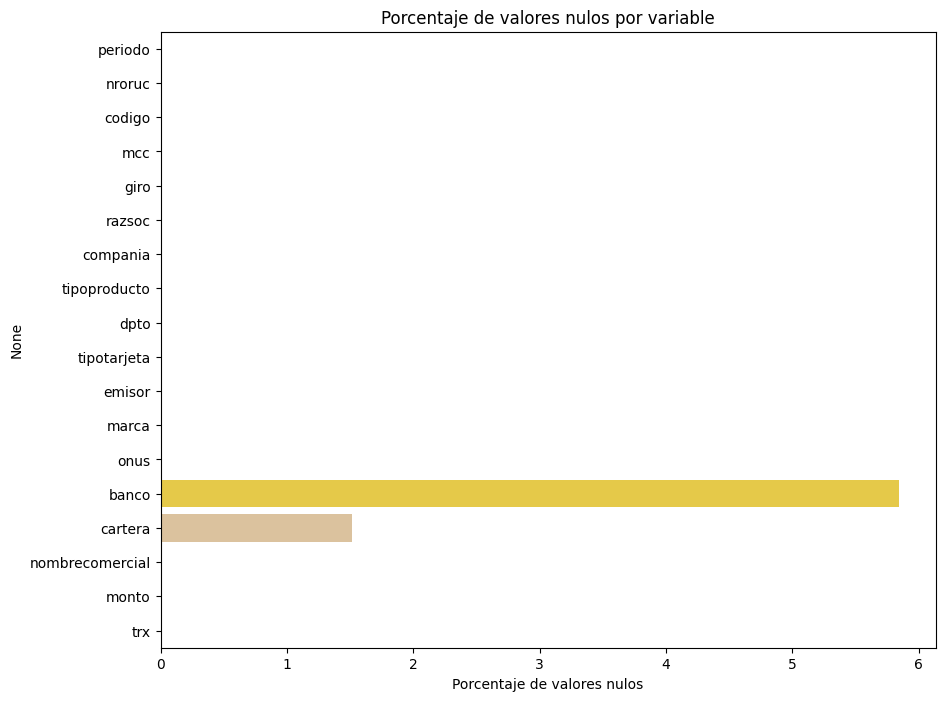

In [94]:
# Evaluar la presencia de nulos
print('Total de valores perdidos: {}'.format(izi.isnull().sum().sum()))

# Calcular el porcentaje de valores nulos por cada variable
porcentaje_null = (izi.isnull().sum() / len(izi)) * 100

# Crear un gráfico de barras horizontal con seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x=porcentaje_null.values, y=porcentaje_null.index, palette='Set2')
plt.xlabel('Porcentaje de valores nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.show()

In [95]:
izi[izi.isna().any(axis=1)]

,periodo,nroruc,codigo,mcc,giro,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx
21,202606,20612732621,5960556,7991,Ferias,Espectaculos Peruanos SAC,IZIPAY,Fisico,PASCO,Débito,Local,Visa,-,Visa Internacional,None,IZI*F SELVAMONOS OXAPAMPA 17 A,230.00,16
24,202606,20100014395,1058865,5099,BIENES NO DURABLES PROMOC UNL DEL 13/6 AL 31/12/7,PRODUCTOS PARAISO DEL PERU S.A.C.,PMP,Fisico,LIMA,Crédito,Local,Visa,-,BCP,None,TIENDA MIRAFLORES,25105.01,20
26,202606,20612931951,5958686,5045,"COMPUTADORAS, EQUIPO DE COMPUT QUIPO DE COMPUT...",TECNOLOGIA Y TENDENCIA SAC,IZIPAY,Fisico,LIMA,Débito,Local,Visa,-,Mibanco,None,IZI*LA CASA DE LA TECNOLOGIA,988.00,2
41,202606,10725237117,5583599,5712,Muebles para el hogar,Agurto Flores Wilder,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,None,RETAIL,IZI*AMUEBLARTE,180.00,1
43,202606,20112654641,5657672,7997,Club sociales y deportivos,CLUB DE LA UNION,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,None,BI,IZI*CLUB DE LA UNION CULTURAL Y DEPORTE,655.00,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997156,202606,20101951872,1049045,5661,Zapaterias,EMPRESAS COMERCIALES S A Y O EMCOMER S A,PMP,Fisico,LIMA,Crédito,Local,Visa,-,None,BC,50158 B SAN MARTIN DE PORRES,496.10,2
1997168,202606,20417531026,1058943,5661,Zapaterias,TRIATHLON S.A.C.,PMP,Fisico,LIMA,Débito,Local,Mastercard,-,BBVA,None,T60 CARPA COMAS,431.86,1
1997181,202606,20602483828,8442868,5661,Zapaterias,COMERCIAL SANTA EDIBURGA EIRL,IZIPAY,Fisico,TACNA,Débito,Local,Visa,-,None,BPE,IZI*COMERCIAL SANTA EDIBURGA EIRL,150.00,1
1997243,202606,20417531026,1058793,5661,Zapaterias,TRIATHLON S.A.C.,PMP,Fisico,LIMA,Crédito,Local,Visa,-,Cencosud,None,T56 CARPA SAN JUAN DE LURIGANCHO,2246.46,7


In [96]:
izi['cartera'].fillna('RETAIL', inplace=True)
izi['tipotarjeta'].fillna('Crédito', inplace=True)
izi[izi.isna().any(axis=1)]

,periodo,nroruc,codigo,mcc,giro,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx
41,202606,10725237117,5583599,5712,Muebles para el hogar,Agurto Flores Wilder,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,None,RETAIL,IZI*AMUEBLARTE,180.00,1
43,202606,20112654641,5657672,7997,Club sociales y deportivos,CLUB DE LA UNION,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,None,BI,IZI*CLUB DE LA UNION CULTURAL Y DEPORTE,655.00,30
48,202606,48584497,8081947,5699,"Accesorios, uniformes, otros",FARRIEL DIAZ ALEXIS,IZIPAY,Fisico,LIMA,Débito,Local,Visa,-,None,RETAIL,IZI*DIVINA CON KUCHI,15.00,1
67,202606,10774976685,8865686,5944,"Joyeria, relojeria",SANTILLAN GUERRERO ANTHONY RENZO,IZIPAY,Fisico,LIMA,Débito,Local,Visa,-,None,BPE,IZI*RENZO JOYAS,406.00,1
93,202606,20608727176,5896778,7298,"Banos turcos, gimnasios",TNT NUTRITION PERU EIRL,IZIPAY,Fisico,LIMA,Débito,Local,Visa,-,None,BPE,IZI*TNT FITNESS GYM SANTA ANITA,21.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997075,202606,20417531026,1913891,5661,Zapaterias,TRIATHLON S.A.C.,PMP,Fisico,LIMA,Crédito,Local,Visa,-,None,BC,51 CANTO GRANDE,340.83,2
1997105,202606,20101951872,1049174,5661,Zapaterias,EMPRESAS COMERCIALES S A Y O EMCOMER S A,PMP,Fisico,LAMBAYEQUE,Débito,Local,Visa,-,None,BC,50501 B1 CHICLAYO,12738.10,90
1997156,202606,20101951872,1049045,5661,Zapaterias,EMPRESAS COMERCIALES S A Y O EMCOMER S A,PMP,Fisico,LIMA,Crédito,Local,Visa,-,None,BC,50158 B SAN MARTIN DE PORRES,496.10,2
1997181,202606,20602483828,8442868,5661,Zapaterias,COMERCIAL SANTA EDIBURGA EIRL,IZIPAY,Fisico,TACNA,Débito,Local,Visa,-,None,BPE,IZI*COMERCIAL SANTA EDIBURGA EIRL,150.00,1


In [97]:
izi.tipoproducto.value_counts()

,count
tipoproducto,
Fisico,1897681
Virtual,99595


In [98]:
izi.marca.value_counts()

,count
marca,
Visa,1422951
Mastercard,378020
Amex,126136
Diners,48830
Otros,21333


In [99]:
izi.dpto.value_counts()

,count
dpto,
LIMA,1250745
AREQUIPA,99474
LA LIBERTAD,86877
PIURA,82281
CUSCO,71998
LAMBAYEQUE,64797
ICA,62095
JUNIN,41048
ANCASH,35053


### Resultado

In [100]:
print(f"Volumen Total: {izi['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {izi['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {izi['nroruc'].nunique()}")

Volumen Total: 6387588385.619967

Cantidad de Códigos Distintos: 197012

Cantidad de RUCs Distintos: 142406


In [101]:
# Filtrando el DataFrame para incluir solo registros donde la compañía es "VENDEMAS"
izi_vendemas = izi[izi['compania'] == 'VENDEMAS']
#izi_vendemas = izi[izi['compania'] == 'Niubiz Vendemás']

# Calculando los resultados con el DataFrame filtrado
print(f"Volumen Total: {izi_vendemas['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {izi_vendemas['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {izi_vendemas['nroruc'].nunique()}")

Volumen Total: 5756603.97

Cantidad de Códigos Distintos: 6208

Cantidad de RUCs Distintos: 5648


In [102]:
izi['codigo'] = izi['codigo'].astype(str)
izi['nroruc'] = izi['nroruc'].astype(str)
izi['codigo'] = izi['codigo'].str.replace('\.0', '', regex=True)

In [103]:
# Limpieza inicial
izi.codigo = izi.codigo.str.strip().str.lstrip('0')
izi.nroruc = izi.nroruc.str.strip().str.lstrip('0')
izi.razsoc = izi.razsoc.str.replace('.',' ').str.strip()
izi.monto = izi.monto.astype('float')
izi.loc[izi.monto < 0, 'monto'] = 0

In [104]:
# procesamiento de datos
izi.loc[izi.banco=='BANCO INTERBANK', 'banco'] = 'IBK'
izi.loc[izi.banco=='Interbank', 'banco'] = 'IBK'
izi.loc[izi.banco!='IBK', 'banco'] = 'OTROS'
izi.loc[izi.cartera=='Facilitador Fisico', 'cartera'] = 'NEG'
izi.loc[izi.cartera=='Facilitador Virtual', 'cartera'] = 'CORPORACIONES'
izi.loc[izi.cartera=='SIN CARTERA', 'cartera'] = 'NEG'
izi.loc[izi.cartera=='Eventos', 'cartera'] = 'EMP'
izi.loc[izi.cartera=='-', 'cartera'] = 'RETAIL'
izi.loc[izi.tipoproducto=='VENDEMAS', 'tipoproducto'] = 'Fisico'
izi.loc[izi.compania=='Izipay Adquiriente', 'compania'] = 'PMP'
izi.loc[izi.compania=='Niubiz Vendemás', 'compania'] = 'OTROS'
izi.loc[izi.compania=='VENDEMAS', 'compania'] = 'OTROS'
izi.loc[izi.compania=='Izipay Facilitador', 'compania'] = 'IZIPAY'
izi.loc[izi.tipotarjeta == 'Prepago','tipotarjeta'] = 'Débito'
izi.loc[izi.marca == 'VISA','marca'] = 'Visa'
izi['compania'].fillna('VENDEMAS', inplace=True)
izi['tipoproducto'].fillna('Fisico', inplace=True)
izi['dpto'].fillna('LIMA', inplace=True)
izi.sample(10)

,periodo,nroruc,codigo,mcc,giro,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx
1910438,202606,10447242,5036651,5331,Tiendas de articulos varios,RACUAY FUENTES MADELEYNE,IZIPAY,Fisico,LIMA,Crédito,Local,Diners,-,OTROS,RETAIL,IZI*MAD J,35.00,1
1913859,202606,10105519228,5744559,8021,"Dentistas, Ortodoncistas",Garcia Salomon Miguel Lorgio,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,OTROS,RETAIL,IZI*DENTAL SAN PEDRO,350.00,1
1705681,202606,20609044552,5757426,5912,"Farmacias, boticas",BOTICA FARMA BLESSING SOCIEDAD ANONIMA CERRADA,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,OTROS,BPE,IZI*BOTICA FARMA BLESSING,649.50,19
1043630,202606,20608430301,1036078,5912,"Farmacias, boticas",BOTICAS IP S A C,PMP,Fisico,JUNIN,Débito,Local,Visa,-,OTROS,BC,IKF 202 LA MERCED,4764.30,114
1277703,202606,10296090561,5473883,5462,"Panaderias, Pastelerias, CAFETERIAS",Salazar Aguilar Myler Edgard,IZIPAY,Fisico,AREQUIPA,Crédito,Local,Visa,-,OTROS,RETAIL,IZI*CAFETERIA SAL Y AZAR,632.50,28
1919482,202606,20600261151,1042021,5137,"UNIFORMES Y ROPA COMERCIAL PARA HOMBRES, MUJER...",SICUREZZA CO S A C,PMP,Fisico,AREQUIPA,Débito,Local,Visa,-,OTROS,BE,SICUREZZA,302.60,1
464510,202606,10474151145,5709981,5947,"Bazares, regalos",Carazas Ayquipa Meliza Andrea,IZIPAY,Fisico,LIMA,Crédito,Local,Visa,-,OTROS,RETAIL,IZI*BELLA VANIDAD,68.70,1
127805,202606,15612345721,5927645,5940,"Bicicletas, venta y reparacion",Ybarra Heredia Javier Custodio,IZIPAY,Fisico,LIMA,Crédito,Internacional,Visa,-,OTROS,RETAIL,IZI*RORAIMA BIKES,131.25,1
990818,202606,20603703066,9860455,8999,Otros servicios profesionales,CORPORACION DANY IMPORT S A C,IZIPAY,Virtual,LIMA,Débito,Local,Visa,-,OTROS,BPE,IZI*CORPORACION DANY IMPORT,3049.00,36
1616308,202606,20100123330,1033943,5814,Comida rapida,DELOSI S A,PMP,Fisico,LIMA,Débito,Local,Mastercard,-,OTROS,BC,KFC - 073 MALL PLAZA COMAS,485.84,17


In [105]:
# Ver campos únicos para cada columna
unique_cartera = izi['cartera'].unique()
unique_tipoproducto = izi['tipoproducto'].unique()
unique_compania = izi['compania'].unique()
unique_tipotarjeta = izi['tipotarjeta'].unique()

print("Campos únicos en 'cartera':", unique_cartera)
print("Campos únicos en 'tipoproducto':", unique_tipoproducto)
print("Campos únicos en 'compania':", unique_compania)
print("Campos únicos en 'tipotarjeta':", unique_tipotarjeta)

Campos únicos en 'cartera': ['BC' 'BE' 'BPE' 'RETAIL' 'BI']
Campos únicos en 'tipoproducto': ['Fisico' 'Virtual']
Campos únicos en 'compania': ['PMP' 'IZIPAY' 'OTROS']
Campos únicos en 'tipotarjeta': ['Crédito' 'Débito']


In [106]:
print(f"Volumen Total: {izi['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {izi['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {izi['nroruc'].nunique()}")

Volumen Total: 6388019925.009973

Cantidad de Códigos Distintos: 197012

Cantidad de RUCs Distintos: 142405


In [107]:
# Filtrando el DataFrame para incluir solo registros donde la compañía es "VENDEMAS"
izi_vendemas = izi[izi['compania'] == 'OTROS']

# Calculando los resultados con el DataFrame filtrado
print(f"Volumen Total: {izi_vendemas['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {izi_vendemas['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {izi_vendemas['nroruc'].nunique()}")

Volumen Total: 5783158.39

Cantidad de Códigos Distintos: 6208

Cantidad de RUCs Distintos: 5648


In [108]:
izi.groupby(by='banco')['monto'].sum()

,monto
banco,
IBK,903256240.16
OTROS,5484763684.85


In [109]:
izi.head()

,periodo,nroruc,codigo,mcc,giro,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx
0,202606,20307246741,2267144,3076,Aeromexico-AEROMEXI,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,PMP,Fisico,LIMA,Crédito,Internacional,Amex,-,OTROS,BC,AEROMEXICO IATA,132504.89,42
1,202606,20466776336,1559621,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...,CENTRO CERAMICO LAS FLORES SAC,PMP,Fisico,LIMA,Crédito,Local,Mastercard,-,OTROS,BC,HIPERMERCADO CERAMICO,402.44,2
2,202606,20100935032,6079852,3357,Hertz (HERTZ CORPORATION),INKA S RENT A CAR S A,PMP,Fisico,LIMA,Crédito,Internacional,Visa,-,OTROS,BE,HERTZ,17009.77,10
3,202606,20605282076,8963437,8071,Laboratorios medicos,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,IZIPAY,Fisico,SAN MARTIN,Débito,Local,Mastercard,-,OTROS,BPE,IZI*CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,60.00,1
4,202606,20100017491,1038068,4900,"Luz, Agua, Gas.",INTEGRATEL PERU S A A,PMP,Fisico,LIMA,Débito,Local,Visa,-,OTROS,BC,MOVISTAR PGRECIBO CORP. SIC,98.30,1


### Consistencia

#### Codigo y Ruc

In [110]:
temp = izi[['codigo', 'nroruc']].drop_duplicates()
temp

,codigo,nroruc
0,2267144,20307246741
1,1559621,20466776336
2,6079852,20100935032
3,8963437,20605282076
4,1038068,20100017491
...,...,...
1997022,5681645,70014150
1997025,5602493,10404457808
1997106,5150193,10415505316
1997133,5554699,10433204935


In [111]:
temp.nunique()

,0
codigo,197012
nroruc,142405


In [112]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único nroruc.')

Cada código está relacionado a un único nroruc.


#### Codigo y Nombre Comercial

In [113]:
temp = izi[['codigo', 'nombrecomercial']].drop_duplicates().sort_values(by='codigo')
temp

,codigo,nombrecomercial
31106,1000010,HERTFORD AUTOMOTRIZ SA
237674,1000071,ESSENTIEL
5237,1000080,TAI LOY
282925,1000083,VEGA CASH Y CARRY SANTO DOMINGO
462778,1000096,MARKET REPSOL
...,...,...
4085,9998206,IZI*ASU TELECOM PERU
982428,9998875,IZI*GUNKAN
508541,9999342,IZI*OTEO GAVILAN LIZBET ISIDORA
212937,9999359,IZI*REPRESENTACIONES FARMAMEDIC VETHEEL E


In [114]:
temp.nunique()

,0
codigo,197012
nombrecomercial,163173


In [115]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único nombre comercial.')
temp[temp.duplicated(subset='codigo', keep=False)]

Cada código está relacionado a un único nombre comercial.


,codigo,nombrecomercial


#### Mcc&Giro

In [116]:
temp = izi[['codigo', 'mcc', 'giro']].drop_duplicates()
temp

,codigo,mcc,giro
0,2267144,3076,Aeromexico-AEROMEXI
1,1559621,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...
2,6079852,3357,Hertz (HERTZ CORPORATION)
3,8963437,8071,Laboratorios medicos
4,1038068,4900,"Luz, Agua, Gas."
...,...,...,...
1997022,5681645,5661,Zapaterias
1997025,5602493,5661,Zapaterias
1997106,5150193,5661,Zapaterias
1997133,5554699,5661,Zapaterias


In [117]:
temp.nunique()

,0
codigo,197012
mcc,274
giro,265


In [118]:
temp = izi.groupby(by=['codigo', 'mcc', 'giro'])['monto'].sum().reset_index()
temp.sort_values(by=['codigo', 'monto'], inplace=True)
temp

,codigo,mcc,giro,monto
0,1000010,5511,Venta autos/camiones nuevos,93303.05
1,1000071,5137,"UNIFORMES Y ROPA COMERCIAL PARA HOMBRES, MUJER...",41262.27
2,1000080,5111,Mayorista de artículos de papelería y de,303699.18
3,1000083,5300,WHOLESALE CLUBS,46280.54
4,1000096,5300,WHOLESALE CLUBS,144.70
...,...,...,...,...
197007,9998206,5046,Activ. Comercial no clasific.\t,12481.90
197008,9998875,8999,Otros servicios profesionales,56089.50
197009,9999342,5499,"Bodegas, Minimercados",9.00
197010,9999359,5046,Activ. Comercial no clasific.\t,8.80


In [119]:
temp.drop_duplicates(subset='codigo', inplace=True, keep='last')
temp

,codigo,mcc,giro,monto
0,1000010,5511,Venta autos/camiones nuevos,93303.05
1,1000071,5137,"UNIFORMES Y ROPA COMERCIAL PARA HOMBRES, MUJER...",41262.27
2,1000080,5111,Mayorista de artículos de papelería y de,303699.18
3,1000083,5300,WHOLESALE CLUBS,46280.54
4,1000096,5300,WHOLESALE CLUBS,144.70
...,...,...,...,...
197007,9998206,5046,Activ. Comercial no clasific.\t,12481.90
197008,9998875,8999,Otros servicios profesionales,56089.50
197009,9999342,5499,"Bodegas, Minimercados",9.00
197010,9999359,5046,Activ. Comercial no clasific.\t,8.80


In [120]:
izi.drop(columns='giro', inplace=True)

In [121]:
izi.drop(columns='mcc', inplace=True)

In [122]:
izi = izi.merge(temp[['codigo', 'mcc', 'giro']], on='codigo', how='left')
izi

,periodo,nroruc,codigo,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx,mcc,giro
0,202606,20307246741,2267144,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,PMP,Fisico,LIMA,Crédito,Internacional,Amex,-,OTROS,BC,AEROMEXICO IATA,132504.89,42,3076,Aeromexico-AEROMEXI
1,202606,20466776336,1559621,CENTRO CERAMICO LAS FLORES SAC,PMP,Fisico,LIMA,Crédito,Local,Mastercard,-,OTROS,BC,HIPERMERCADO CERAMICO,402.44,2,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...
2,202606,20100935032,6079852,INKA S RENT A CAR S A,PMP,Fisico,LIMA,Crédito,Internacional,Visa,-,OTROS,BE,HERTZ,17009.77,10,3357,Hertz (HERTZ CORPORATION)
3,202606,20605282076,8963437,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,IZIPAY,Fisico,SAN MARTIN,Débito,Local,Mastercard,-,OTROS,BPE,IZI*CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,60.00,1,8071,Laboratorios medicos
4,202606,20100017491,1038068,INTEGRATEL PERU S A A,PMP,Fisico,LIMA,Débito,Local,Visa,-,OTROS,BC,MOVISTAR PGRECIBO CORP. SIC,98.30,1,4900,"Luz, Agua, Gas."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997271,202606,20101951872,1049084,EMPRESAS COMERCIALES S A Y O EMCOMER S A,PMP,Fisico,ANCASH,Crédito,Local,Visa,-,IBK,BC,50515 B2 CHIMBOTE,6775.48,38,5661,Zapaterias
1997272,202606,20417531026,1803816,TRIATHLON S A C,PMP,Fisico,LIMA,Débito,Local,Visa,-,OTROS,BC,46 MEGAPLAZA 1,1553.30,7,5661,Zapaterias
1997273,202606,74743582,5896972,MONTOYA ROJAS CESAR GONZALO,IZIPAY,Virtual,LIMA,Crédito,Local,Visa,-,IBK,RETAIL,IZI*SNEAKERS SPA BY GONZA,500.00,1,5661,Zapaterias
1997274,202606,20101951872,1049036,EMPRESAS COMERCIALES S A Y O EMCOMER S A,PMP,Fisico,LIMA,Crédito,Local,Visa,-,OTROS,BC,50201 NS PLAZA NORTE,10589.54,46,5661,Zapaterias


In [123]:
temp = izi[['codigo', 'mcc', 'giro']].drop_duplicates()
temp

,codigo,mcc,giro
0,2267144,3076,Aeromexico-AEROMEXI
1,1559621,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...
2,6079852,3357,Hertz (HERTZ CORPORATION)
3,8963437,8071,Laboratorios medicos
4,1038068,4900,"Luz, Agua, Gas."
...,...,...,...
1997022,5681645,5661,Zapaterias
1997025,5602493,5661,Zapaterias
1997106,5150193,5661,Zapaterias
1997133,5554699,5661,Zapaterias


In [124]:
temp.nunique()

,0
codigo,197012
mcc,274
giro,265


In [125]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un único mcc y giro.')

Cada código está relacionado a un único mcc y giro.


#### Codigo y Giro

In [126]:
temp = izi[['codigo', 'giro']].drop_duplicates()
temp

,codigo,giro
0,2267144,Aeromexico-AEROMEXI
1,1559621,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...
2,6079852,Hertz (HERTZ CORPORATION)
3,8963437,Laboratorios medicos
4,1038068,"Luz, Agua, Gas."
...,...,...
1997022,5681645,Zapaterias
1997025,5602493,Zapaterias
1997106,5150193,Zapaterias
1997133,5554699,Zapaterias


In [127]:
cantidad_codigos_unicos = temp['codigo'].nunique()
print(f"Cantidad de códigos únicos: {cantidad_codigos_unicos}")
cantidad_registros = len(temp)
print(f"Cantidad total de registros: {cantidad_registros}")
codigos_mas_de_un_mcc = temp.groupby('codigo')['giro'].nunique()
codigos_con_mas_de_un_mcc = codigos_mas_de_un_mcc[codigos_mas_de_un_mcc > 1]
print(f"Cantidad de códigos con más de un MCC: {len(codigos_con_mas_de_un_mcc)}")


Cantidad de códigos únicos: 197012
Cantidad total de registros: 197012
Cantidad de códigos con más de un MCC: 0


In [128]:
temp.nunique()

,0
codigo,197012
giro,265


In [129]:
if temp.codigo.nunique() == temp.shape[0]:
  print('Cada código está relacionado a un único giro.')

Cada código está relacionado a un único giro.


#### Codigo y Compania

In [130]:
temp = izi[['codigo', 'compania']].drop_duplicates()
temp

,codigo,compania
0,2267144,PMP
1,1559621,PMP
2,6079852,PMP
3,8963437,IZIPAY
4,1038068,PMP
...,...,...
1997022,5681645,IZIPAY
1997025,5602493,IZIPAY
1997106,5150193,IZIPAY
1997133,5554699,IZIPAY


In [131]:
temp.nunique()

,0
codigo,197012
compania,3


In [132]:
if temp.codigo.nunique() == temp.shape[0]: print('Cada código está relacionado a un única compania.')

Cada código está relacionado a un única compania.


#### Tipo Producto

In [133]:
temp = izi[['codigo', 'tipoproducto']].drop_duplicates()
temp

,codigo,tipoproducto
0,2267144,Fisico
1,1559621,Fisico
2,6079852,Fisico
3,8963437,Fisico
4,1038068,Fisico
...,...,...
1997022,5681645,Virtual
1997025,5602493,Fisico
1997106,5150193,Fisico
1997133,5554699,Fisico


In [134]:
temp.nunique()

,0
codigo,197012
tipoproducto,2


In [135]:
temp.tipoproducto.value_counts()

,count
tipoproducto,
Fisico,167166
Virtual,29846


In [136]:
# se cambia el valor de vendemas a fisico porque vendemas son productos físicos
izi.loc[izi.tipoproducto=='VENDEMAS', 'tipoproducto'] = 'Fisico'

In [137]:
if temp.codigo.nunique() == temp.shape[0]:
    print('Cada código está relacionado a un único tipo producto.')
else:
    print('No todos los códigos están relacionados a un único tipo producto.')
    # Muestra las filas duplicadas basadas en nroruc
    duplicados = temp[temp.duplicated(subset='codigo', keep=False)]

Cada código está relacionado a un único tipo producto.


#### Departamento

In [138]:
temp = izi[['codigo', 'dpto']].drop_duplicates()
temp

,codigo,dpto
0,2267144,LIMA
1,1559621,LIMA
2,6079852,LIMA
3,8963437,SAN MARTIN
4,1038068,LIMA
...,...,...
1997022,5681645,LIMA
1997025,5602493,AYACUCHO
1997106,5150193,CAJAMARCA
1997133,5554699,LA LIBERTAD


In [139]:
temp.nunique()

,0
codigo,197012
dpto,24


In [140]:
if temp.codigo.nunique() == temp.shape[0]:
    print('Cada código está relacionado a un único departamento.')
else:
    print('No todos los códigos están relacionados a un único departamento.')
    # Muestra las filas duplicadas basadas en nroruc
    duplicados = temp[temp.duplicated(subset='codigo', keep=False)]

Cada código está relacionado a un único departamento.


#### Razon social

In [141]:
temp = izi[['codigo', 'razsoc']].drop_duplicates()
temp

,codigo,razsoc
0,2267144,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER
1,1559621,CENTRO CERAMICO LAS FLORES SAC
2,6079852,INKA S RENT A CAR S A
3,8963437,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...
4,1038068,INTEGRATEL PERU S A A
...,...,...
1997022,5681645,Kimberly Samanta Hermoza Alcalde
1997025,5602493,HUAYANAY HUAYTALLA PROSPERO
1997106,5150193,REYES COTRINA MARIA ELIZABETH
1997133,5554699,LAURIANO JUIRO MARGARITA YESSICA


In [142]:
temp.nunique()

,0
codigo,197012
razsoc,136739


In [143]:
if temp.codigo.nunique() == temp.shape[0]:
    print('Cada código está relacionado a un único razon social.')
else:
    print('No todos los códigos están relacionados a un único razon social.')
    # Muestra las filas duplicadas basadas en nroruc
    duplicados = temp[temp.duplicated(subset='codigo', keep=False)]

Cada código está relacionado a un único razon social.


#### Segmento / Cartera

In [144]:
temp = izi[['nroruc', 'cartera']].drop_duplicates()
temp

,nroruc,cartera
0,20307246741,BC
1,20466776336,BC
2,20100935032,BE
3,20605282076,BPE
4,20100017491,BC
...,...,...
1997022,70014150,RETAIL
1997025,10404457808,BPE
1997106,10415505316,BPE
1997133,10433204935,BPE


In [145]:
temp.nunique()

,0
nroruc,142405
cartera,5


In [146]:
if temp.nroruc.nunique() == temp.shape[0]:
    print('Cada nroruc está relacionado a un único cartera.')
else:
    print('No todos los nroruc están relacionados a un único cartera.')
    # Muestra las filas duplicadas basadas en nroruc
    duplicados = temp[temp.duplicated(subset='nroruc', keep=False)]

No todos los nroruc están relacionados a un único cartera.


In [147]:
duplicados.sort_values(by='nroruc')

,nroruc,cartera
344781,10001187886,BPE
1821591,10001187886,RETAIL
91848,10036762751,BPE
69182,10036762751,RETAIL
500073,10054019527,BPE
...,...,...
1600221,20615858782,BPE
919799,20615866246,BPE
919403,20615866246,RETAIL
1058176,20615913155,BPE


#### Facilitador

In [148]:
#columnas procesador
# regex para capturar todo lo anterior a un primer asterisco
regex = r'([^*]*)'

# facilitador es lo que hay antes de asterisco en nombre comercial
izi['facilitador'] = izi['nombrecomercial'].str.extract(regex)

In [149]:
# se remplazan los valores vacíos de nombrecomercial con NA
izi['nombrecomercial'] = izi['nombrecomercial'].fillna('NA')

izi['facilitador'] = np.where(izi['nombrecomercial'].str.contains(r'\*'), izi['facilitador'], 'NA')

# se limpia el campo de facilitador
izi['facilitador'] = izi['facilitador'].str.upper().str.strip().str.lstrip(':')

In [150]:
izi['facilitador'].value_counts(dropna=False)

,count
facilitador,
IZI,1409407
NA,568079
VD+,9898
DLC,3656
FULLCAR,2194
PYU,1650
MDOPAGO,1083
ECM,525
NUVEIPE,210


In [151]:
izi['facilitador'] = izi['facilitador'].replace({'IZ':'IZI', 'ZI':'IZI', 'MERPAGO':'MPAGO', 'MERCPAGO':'MPAGO', 'MDOPAGO':'MPAGO'})

In [152]:
# se hace una lista con los facilitadores
facilitadores = izi['facilitador'].unique().tolist()

# se quitan unos facilitadores que no son
no_facilitadores_list = ['DLC', 'MICROSOFT', 'AIRBNB', 'UNIF 422', 'UBER', 'ONLINEIPS', '','ONLINEIPS','ICICI','UNIF.4772','UNIF.477','KETO963']

facilitadores = [facilitador for facilitador in facilitadores if facilitador not in no_facilitadores_list]

print(facilitadores)

izi['facilitador'] = np.where(izi['facilitador'].isin(facilitadores), izi['facilitador'],'NA')

['NA', 'IZI', 'VD+', 'PYU', 'MPAGO', 'ECM', 'NUVEIPE', 'FULLCAR', 'KSK', 'NV', 'PAG', 'EBN', 'ALIGNET', 'PMZ', 'BNACION', 'PAYULAT']


In [153]:
# función para cambiar
def limpieza(texto):
    tokens = re.findall(r'[a-zA-Z0-9]+', texto.upper())
    tokens = [w for w in tokens if w not in facilitadores]
    return " ".join(tokens).strip()

In [154]:
izi['nombrecomercial'].fillna('NA', inplace=True)
izi['nombrecomercial'] = izi['nombrecomercial'].apply(lambda x: limpieza(x))

In [155]:
#Base final Izipay
izi.head()

,periodo,nroruc,codigo,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx,mcc,giro,facilitador
0,202606,20307246741,2267144,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,PMP,Fisico,LIMA,Crédito,Internacional,Amex,-,OTROS,BC,AEROMEXICO IATA,132504.89,42,3076,Aeromexico-AEROMEXI,NA
1,202606,20466776336,1559621,CENTRO CERAMICO LAS FLORES SAC,PMP,Fisico,LIMA,Crédito,Local,Mastercard,-,OTROS,BC,HIPERMERCADO CERAMICO,402.44,2,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÓN (NO INC...,NA
2,202606,20100935032,6079852,INKA S RENT A CAR S A,PMP,Fisico,LIMA,Crédito,Internacional,Visa,-,OTROS,BE,HERTZ,17009.77,10,3357,Hertz (HERTZ CORPORATION),NA
3,202606,20605282076,8963437,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,IZIPAY,Fisico,SAN MARTIN,Débito,Local,Mastercard,-,OTROS,BPE,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,60.00,1,8071,Laboratorios medicos,IZI
4,202606,20100017491,1038068,INTEGRATEL PERU S A A,PMP,Fisico,LIMA,Débito,Local,Visa,-,OTROS,BC,MOVISTAR PGRECIBO CORP SIC,98.30,1,4900,"Luz, Agua, Gas.",NA


In [156]:
print(f"Volumen Total: {izi['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {izi['codigo'].nunique()}")
print(f"\nCantidad de RUCs Distintos: {izi['nroruc'].nunique()}")

Volumen Total: 6388019925.009973

Cantidad de Códigos Distintos: 197012

Cantidad de RUCs Distintos: 142405


In [157]:
izi.shape

(1997276, 19)

In [158]:
# izi.to_gbq(destination_table='pxc.izi',
#           project_id='dev-izipay-data-storage',
#           if_exists='replace')  # Opciones: 'fail', 'replace', 'append'

In [159]:
izi.groupby(by='marca')['monto'].sum()

,monto
marca,
Amex,343613519.52
Diners,80007004.52
Mastercard,394946609.12
Otros,4820093.37
Visa,5564632661.59


## IBK <a id="section_1_3"></a>

Se cargan los datos de IBK, crédito y débito por separado y luego se juntan.

In [160]:
# query = f"""
# select
#   fecha_trx as fectransaccion,
#   canal as canal_2,
#   flag_tipo_trx as tipflgtraninter,
#   right(concat('000',cod_mcc),4) as codcatcomerciomcc,
#   cod_comercio as codestabcompra,
#   nombre_comercio as descomercio,
#   ciudad_comercio as desciudadcomercio,
#   dpto_cliente as dpto_cliente,
#   case when tipo_tarjeta in ('01','1') then 'TD' else 'TC' end as tipo_tarjeta,
#   case when marca_tarjeta = 'T1' then 'Amex' when marca_tarjeta = 'T2' then 'Visa' end as marca_tipo,
#   sum(cast(monto_consumo as float64)) as cons,
#   count(1) as clientes,
#   count(1) as trx
# from `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_consumo_ibk}`
# where process_date between '{var_fecha_ini}' and '{var_fecha_fin}'
# and flag_tipo_trx = 'L'
# /*and process_date between '2024-08-01' and '2024-08-31'*/
# group by 1,2,3,4,5,6,7,8,9,10
# """
# ibk = client.query(query).to_dataframe()

In [161]:
## ajuste para identificar COMERCIOS IZIPAY :
query = f"""
with cte_base_m_comercio as
(
  select
    cod_comercio
    ,nom_comercio
    ,compania
    ,departamento_comercio
  from   `{var_project_storage}.{var_dataset_master_party}.{var_table_m_comercio}`
  where
    COALESCE(tipo_comercio, '') <> 'IZIPAY APP'
), cte_base_ibk  as
(
  select
    fecha_trx
    ,canal
    ,flag_tipo_trx
    ,cod_mcc
    ,cod_comercio
    ,nombre_comercio
    ,ciudad_comercio
    ,dpto_cliente
    ,tipo_tarjeta
    ,marca_tarjeta
    ,monto_consumo
  from  `{var_project_storage}.{var_dataset_master_transaction}.{var_table_t_consumo_ibk}`
  where
    process_date  between '{var_fecha_ini}' and '{var_fecha_fin}'
    and flag_tipo_trx = 'L'
), cte_base_union_ibk as
(
  select
    a.fecha_trx
    ,a.canal
    ,a.flag_tipo_trx
    ,a.cod_mcc
    ,a.cod_comercio
    ,CASE WHEN B.nom_comercio is not null then b.nom_comercio else a.nombre_comercio end  as nombre_comercio
    ,a.ciudad_comercio
    ,A.dpto_cliente as   dpto_cliente
    ,a.tipo_tarjeta
    ,a.marca_tarjeta
    ,a.monto_consumo
  from cte_base_ibk a
  left join cte_base_m_comercio b on trim(REGEXP_REPLACE(a.cod_comercio, r'^0+', ''))  =  trim(b.cod_comercio) -- 5,655,820
)
select
  fecha_trx as fectransaccion,
  canal as canal_2,
  flag_tipo_trx as tipflgtraninter,
  right(concat('000',cod_mcc),4) as codcatcomerciomcc,
  cod_comercio as codestabcompra,
  nombre_comercio as descomercio,
  ciudad_comercio as desciudadcomercio,
  dpto_cliente as dpto_cliente,
  case when tipo_tarjeta in ('01','1') then 'TD' else 'TC' end as tipo_tarjeta,
  case when marca_tarjeta = 'T1' then 'Amex' when marca_tarjeta = 'T2' then 'Visa' end as marca_tipo,
  sum(cast(monto_consumo as float64)) as cons,
  count(1) as clientes,
  count(1) as trx
from   cte_base_union_ibk
  group by all
"""
ibk = client.query(query).to_dataframe()

Para Camila

In [162]:
ibk = ibk.astype(str)

In [163]:
ibk.columns = ibk.columns.str.lower()
ibk.fillna('0',inplace=True)
ibk.replace('',0,inplace=True)

Total de valores perdidos: 0


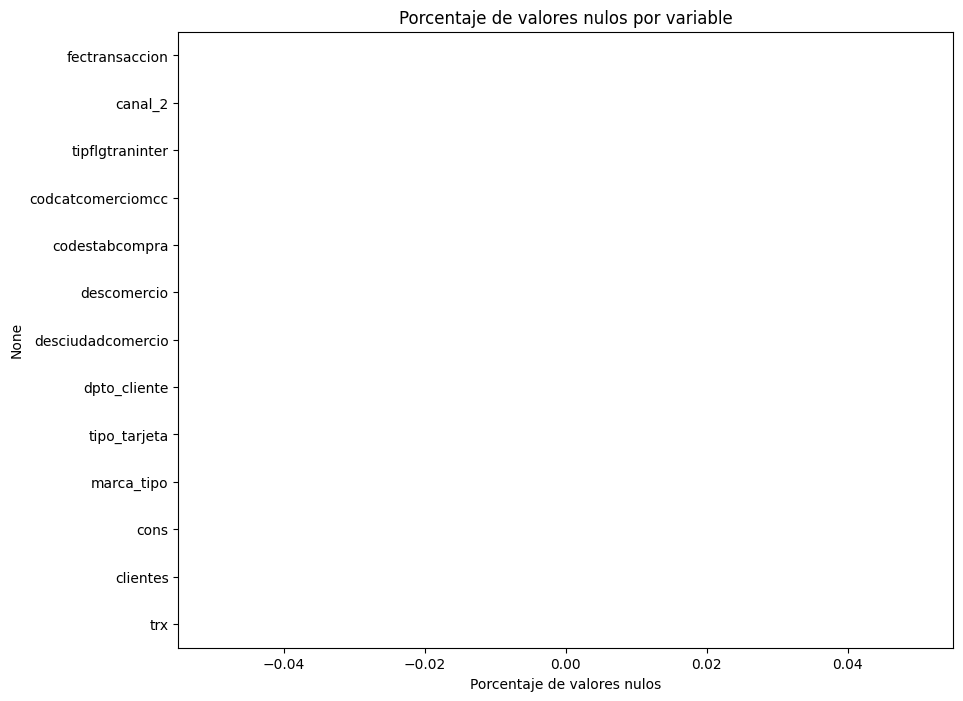

In [164]:
# Evaluar la presencia de nulos
print('Total de valores perdidos: {}'.format(ibk.isnull().sum().sum()))

# Calcular el porcentaje de valores nulos por cada variable
porcentaje_null = (ibk.isnull().sum() / len(ibk)) * 100

# Crear un gráfico de barras horizontal con seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x=porcentaje_null.values, y=porcentaje_null.index, palette='Set2')
plt.xlabel('Porcentaje de valores nulos')
plt.title('Porcentaje de valores nulos por variable')
plt.show()

In [165]:
#ibk = ibk[(ibk['FecTransaccion'] >= '2024-08-01') & (ibk['FecTransaccion'] < '2024-09-01')]
#ibk['FecTransaccion'] = pd.to_datetime(ibk['FecTransaccion'])

In [166]:
#ibk.FecTransaccion.value_counts(dropna=False).sort_values(ascending=False)
value_counts = ibk.fectransaccion.value_counts(dropna=False)

# Convertir el índice a tipo datetime para ordenar por fechas
value_counts.index = pd.to_datetime(value_counts.index)

# Ordenar los valores contados por las fechas
value_counts.sort_index()
## Check

,count
fectransaccion,
2026-05-02,1
2026-05-04,1
2026-05-05,2
2026-05-08,2
2026-05-09,1
2026-05-10,2
2026-05-11,1
2026-05-12,8
2026-05-13,15


In [167]:
# #ibk.FecTransaccion.value_counts(dropna=False).sort_values(ascending=False)
# value_counts = ibk.FecDia.value_counts(dropna=False)

# # Convertir el índice a tipo datetime para ordenar por fechas
# value_counts.index = pd.to_datetime(value_counts.index)

# # Ordenar los valores contados por las fechas
# value_counts.sort_index()
# ## Check

In [168]:
ibk['cons'] = ibk['cons'].astype(float)
# ibk['clientes'] = ibk['clientes'].astype(int)
# ibk['trx'] = ibk['trx'].astype(int)

### Resultado

In [169]:
print(f"Volumen Total: {ibk['cons'].sum()}")
print(f"\nCantidad de Códigos Distintos: {ibk['codestabcompra'].nunique()}")
print(f"\nCantidad de Nombres Comerciales Distintos: {ibk['descomercio'].nunique()}")

Volumen Total: 1796267408.1491992

Cantidad de Códigos Distintos: 236934

Cantidad de Nombres Comerciales Distintos: 272671


In [170]:
ibk.tipflgtraninter.value_counts(dropna = False)

,count
tipflgtraninter,
L,6111900


In [171]:
ibk.canal_2.value_counts(dropna = False)

,count
canal_2,
POS,4733568
COMERCIO ELECTRONICO,1378332


In [172]:
ibk.marca_tipo.value_counts()

,count
marca_tipo,
Visa,5324377
Amex,787523


In [173]:
ibk.tipo_tarjeta.value_counts(dropna=False)
## Check

,count
tipo_tarjeta,
TD,3220997
TC,2890903


In [174]:
ibk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6111900 entries, 0 to 6111899
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   fectransaccion     object 
 1   canal_2            object 
 2   tipflgtraninter    object 
 3   codcatcomerciomcc  object 
 4   codestabcompra     object 
 5   descomercio        object 
 6   desciudadcomercio  object 
 7   dpto_cliente       object 
 8   tipo_tarjeta       object 
 9   marca_tipo         object 
 10  cons               float64
 11  clientes           object 
 12  trx                object 
dtypes: float64(1), object(12)
memory usage: 606.2+ MB


In [175]:
ibk[['tipo_tarjeta','cons']].groupby('tipo_tarjeta').sum()

,cons
tipo_tarjeta,
TC,1094962015.91
TD,701305392.24


In [176]:
ibk[['marca_tipo','cons']].groupby('marca_tipo').sum()

,cons
marca_tipo,
Amex,318867944.54
Visa,1477399463.61


In [177]:
ibk = ibk.pivot_table(index = ['canal_2', 'tipflgtraninter', 'codcatcomerciomcc',
       'codestabcompra', 'descomercio', 'desciudadcomercio', 'dpto_cliente',
       'tipo_tarjeta', 'marca_tipo'],values = ['cons', 'clientes', 'trx'],aggfunc='sum').reset_index()

In [178]:
#Carga de IBK
ibk.columns = ['tipoproducto', 'emisor', 'mcc', 'codigo',
       'nombrecomercial', 'desciudadcomercio', 'dpto', 'tipotarjeta',
       'marca', 'clientes', 'monto', 'trx']
ibk.monto.replace('?', '0', inplace=True)
ibk.monto = ibk.monto.astype('float')
ibk.loc[ibk.monto < 0, 'cons'] = 0
ibk.codigo = ibk.codigo.str.strip().str.lstrip('0')
ibk.tipoproducto.replace({'POS':'Fisico', 'COMERCIO ELECTRONICO':'Virtual'}, inplace=True)
ibk

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons
0,Virtual,L,0742,,IZI*AGRO VET*005717284,None,ICA,TC,Visa,2,78.00,2,NaN
1,Virtual,L,0742,,IZI*AGRO VETERI*005851646,None,None,TC,Visa,1,5.00,1,NaN
2,Virtual,L,0742,,IZI*AMERICA SAC*005852292,None,None,TC,Visa,11,232.00,11,NaN
3,Virtual,L,0742,,IZI*ANIMAL CARE*005957887,None,LORETO,TC,Visa,1,55.00,1,NaN
4,Virtual,L,0742,,IZI*ANIMAL GLAM*005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999,Zara 2/4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN
1411677,Fisico,L,9999,999999,Zona 31 19/3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN
1411678,Fisico,L,9999,999999,Zona 31 25/4,LIMA,None,TC,Visa,1,47.47,1,NaN
1411679,Fisico,L,9999,999999,Zona 31 26/4,LIMA,None,TC,Visa,1,64.16,1,NaN


In [179]:
print(f"Volumen Total: {ibk['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {ibk['codigo'].nunique()}")
print(f"\nCantidad de Nombres Comerciales Distintos: {ibk['nombrecomercial'].nunique()}")

Volumen Total: 1796267408.1492

Cantidad de Códigos Distintos: 230629

Cantidad de Nombres Comerciales Distintos: 272671


In [180]:
ibk.isna().sum()

,0
tipoproducto,0
emisor,0
mcc,0
codigo,0
nombrecomercial,0
desciudadcomercio,0
dpto,0
tipotarjeta,0
marca,0
clientes,0


In [181]:
ibk.sample(6)

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons
876643,Fisico,L,5812,235977,Nina Pacha,None,LIMA PROV,TC,Visa,1,119.00,1,NaN
1347406,Fisico,L,7999,5057631,IZI*DIVERMIX,LIMA,None,TD,Visa,1,40.00,1,NaN
543691,Fisico,L,5411,1048695,2134 MASS MARIANO5 CIX MS,LAMBAYEQUE,LA LIBERTAD,TD,Visa,1,3.70,1,NaN
456993,Fisico,L,5300,1050111,HALHUA SAC,LIMA,LIMA,TC,Amex,1,11.90,1,NaN
235217,Virtual,L,5814,1046034,T2166 VENTUROSA CHORRILLOS,LIMA,CALLAO,TD,Visa,1,11.80,1,NaN
1183809,Fisico,L,5912,1047971,MF H69 TRUJILLO FLORENCIA DE MORA,LA LIBERTAD,LA LIBERTAD,TC,Visa,211121441111111111222,1397.40,211121441111111111222,NaN


### Consistencia

In [182]:
# tener rastro de nombrecomercial raw
ibk['nombrecomercial_raw'] = ibk['nombrecomercial'].copy()

In [183]:
ibk.dropna(subset='codigo', inplace=True)

**Problema:**

Hay códigos que esconden muchos códigos diferentes. Por ejemplo, el código 1000 corresponde a más de un solo código.

In [184]:
ibk.query('mcc=="9999"')

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw
351069,Virtual,L,9999,999999,RefundGlobalblue.com,LIMA,CUSCO,TC,Visa,1,343.90,1,NaN,RefundGlobalblue.com
351070,Virtual,L,9999,999999,RefundGlobalblue.com,LIMA,ICA,TC,Visa,1,27.40,1,NaN,RefundGlobalblue.com
351071,Virtual,L,9999,999999,RefundGlobalblue.com,LIMA,LA LIBERTAD,TC,Visa,6,307.63,6,NaN,RefundGlobalblue.com
351072,Virtual,L,9999,999999,RefundGlobalblue.com,LIMA,LIMA,TC,Visa,5,566.56,5,NaN,RefundGlobalblue.com
1408728,Fisico,L,9999,999999,01-006-09-LUZDELNET,LIMA,LIMA,TC,Amex,1,139.80,1,NaN,01-006-09-LUZDELNET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999,Zara 2/4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4
1411677,Fisico,L,9999,999999,Zona 31 19/3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3
1411678,Fisico,L,9999,999999,Zona 31 25/4,LIMA,None,TC,Visa,1,47.47,1,NaN,Zona 31 25/4
1411679,Fisico,L,9999,999999,Zona 31 26/4,LIMA,None,TC,Visa,1,64.16,1,NaN,Zona 31 26/4


In [185]:
ibk.query('codigo=="999999"').monto.sum()

np.float64(2120120.6692999983)

In [186]:
ibk.query('codigo=="999999"').sort_values(by='nombrecomercial').nombrecomercial.value_counts()

,count
nombrecomercial,
SEGURO EXTRACASH,53
PRIORITY PASS,47
CARGO POR TRASPASO MONEDA,31
TRASLADO SALDO,14
CONCIERTO MAROON 5,7
...,...
El Dorado 30/3,1
El Dorado 4/4,1
El Dorado 5/3,1


#### Limpieza nombre comercial

In [187]:
#columnas procesador
# regex para capturar todo lo anterior a un primer asterisco
regex = r'([^*]*)'

# facilitador es lo que hay antes de asterisco en nombre comercial
ibk['facilitador'] = ibk['nombrecomercial'].str.extract(regex)

In [188]:
ibk['facilitador'].value_counts(dropna=False)

,count
facilitador,
IZI,342494
BCP,54974
OPENPAY,27815
VENDOMATICA,24938
PedidosYa,22284
...,...
WELLNESS WHOLESOME 13/3,1
WAJACA ARKADIA 7/4,1
Xue Cafe 27/4,1


In [189]:
# se remplazan los valores vacíos de nombrecomercial con NA
ibk['nombrecomercial'] = ibk['nombrecomercial'].fillna('NA')

ibk['facilitador'] = np.where(ibk['nombrecomercial'].str.contains(r'\*'), ibk['facilitador'], 'NA')

# se limpia el campo de facilitador
ibk['facilitador'] = ibk['facilitador'].str.upper().str.strip().str.lstrip(':')

In [190]:
ibk['facilitador'].value_counts(dropna=False)

,count
facilitador,
NA,866209
IZI,342498
BCP,54974
OPENPAY,27765
PEDIDOSYA,22284
CULQI,20519
DLC,17764
VM,15026
MP,14332


In [191]:
ibk['facilitador'] = ibk['facilitador'].replace({'IZ':'IZI', 'ZI':'IZI', 'MERPAGO':'MPAGO', 'MERCPAGO':'MPAGO', 'MDOPAGO':'MPAGO'})

In [192]:
# se hace una lista con los facilitadores
facilitadores = ibk['facilitador'].unique().tolist()

# se quitan unos facilitadores que no son
no_facilitadores_list = ['DLC', 'MICROSOFT', 'AIRBNB', 'UNIF 422', 'UBER', 'ONLINEIPS', '','ONLINEIPS','ICICI','UNIF.4772','UNIF.477','KETO963']

facilitadores = [facilitador for facilitador in facilitadores if facilitador not in no_facilitadores_list]

print(facilitadores)

ibk['facilitador'] = np.where(ibk['facilitador'].isin(facilitadores), ibk['facilitador'],'NA')

['IZI', 'NA', 'OPENPAY', 'MP', 'SUMUP', 'CULQI', 'BCP', 'PAYPAL', 'OP', 'PYU', 'MPAGO', 'VD+', 'MNT', 'PAG', 'NUVEIPE', 'FLOW', 'INS', 'ATIX', 'KS', 'ALIGNET', 'PAGOEFECTIVO', 'FULLCAR', 'KSK', 'ECM', 'VM', 'EBN', 'BMB', 'PEDIDOSYA', 'DP', 'NV', 'PAYRETAILERS', 'PAYVALIDA', 'PAYVAPE', 'FACEBK', 'PPRO', 'NPF', 'PMZ', 'PTP', 'TUPAYBT', 'OKT', 'TUPAY', 'PAYULAT', 'BNACION', 'TIENDA SUPPER NOGALES', 'TIENDA SUPPER RIMAC', 'C', 'DTV', 'REG DTV', 'TRASLADO A 477290']


In [193]:
# función para cambiar
def limpieza(texto):
    tokens = re.findall(r'[a-zA-Z0-9]+', texto.upper())
    tokens = [w for w in tokens if w not in facilitadores]
    return " ".join(tokens).strip()

In [194]:
ibk['nombrecomercial'].fillna('NA', inplace=True)
ibk['nombrecomercial'] = ibk['nombrecomercial'].apply(lambda x: limpieza(x))

#### Montos sin codigo

In [195]:
# montos sin código
print('monto total sin código', ibk.loc[ibk.codigo=="", 'monto'].sum())
ibk.loc[ibk.codigo==""]

monto total sin código 14382661.91


,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador
0,Virtual,L,0742,,AGRO VET 005717284,None,ICA,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,IZI
1,Virtual,L,0742,,AGRO VETERI 005851646,None,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,IZI
2,Virtual,L,0742,,AMERICA SAC 005852292,None,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,IZI
3,Virtual,L,0742,,ANIMAL CARE 005957887,None,LORETO,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,IZI
4,Virtual,L,0742,,ANIMAL GLAM 005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,IZI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662637,Fisico,L,5499,,MULTISERVIC 005669991,None,LAMBAYEQUE,TC,Visa,1,650.00,1,NaN,IZI*MULTISERVIC*005669991,IZI
852790,Fisico,L,5812,,JESSI 005854049,None,LAMBAYEQUE,TC,Visa,1,1050.00,1,NaN,IZI*JESSI*005854049,IZI
1253175,Fisico,L,5999,,MOBILETECH 005862260,None,LIMA,TC,Visa,1,398.00,1,NaN,IZI*MOBILETECH*005862260,IZI
1330527,Fisico,L,7629,,INSTASHOP S 005766198,None,TACNA,TC,Visa,1,1500.00,1,NaN,IZI*INSTASHOP S*005766198,IZI


In [196]:
def codigo_izi(nombrecomercio):
    pattern = r'\*([0-9]+)$' # nros dsps de asterisco

    # buscamos el patron en el string
    match = re.search(pattern, nombrecomercio)

    if match:
        # print('se cambió A por B:', nombrecomercio, match.group(1))
        return match.group(1)
    else:
        return np.nan

ibk['codigo'] = ibk.apply(lambda x: codigo_izi(x.nombrecomercial_raw) if x.codigo=="" else x.codigo, axis=1)

In [197]:
ibk['codigo'] = ibk['codigo'].str.lstrip('0')

In [198]:
ibk.loc[ibk.codigo==""]

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador


In [199]:
ibk.loc[ibk.codigo.isna()]

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador
262668,Virtual,L,5818,NaN,GARENA PE,LIMA,ANCASH,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262669,Virtual,L,5818,NaN,GARENA PE,LIMA,AREQUIPA,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262670,Virtual,L,5818,NaN,GARENA PE,LIMA,CALLAO,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262671,Virtual,L,5818,NaN,GARENA PE,LIMA,CUSCO,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262672,Virtual,L,5818,NaN,GARENA PE,LIMA,ICA,TD,Visa,11,31.00,11,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262673,Virtual,L,5818,NaN,GARENA PE,LIMA,LIMA,TD,Visa,11,15.40,11,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262674,Virtual,L,5818,NaN,GARENA PE,LIMA,None,TD,Visa,1211111,119.40,1211111,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262675,Virtual,L,5818,NaN,GARENA PE,LIMA,UCAYALI,TD,Visa,11,23.00,11,NaN,PAYVALIDA*GARENA PE,PAYVALIDA
262676,Virtual,L,5818,NaN,WALLET,LIMA,AREQUIPA,TD,Visa,2,610.00,2,NaN,PAYVALIDA*WALLET,PAYVALIDA
262677,Virtual,L,5818,NaN,WALLET,LIMA,CALLAO,TD,Visa,11,45.00,11,NaN,PAYVALIDA*WALLET,PAYVALIDA


In [200]:
ibk.shape

(1411681, 15)

#### Agrupación de nombres comerciales similares

Mismo código y mcc

In [201]:
# def nombre_mas_largo(df):
#     return df.loc[df['nombrecomercial'].str.len().idxmax()]

# temp = ibk[['codigo','nombrecomercial','mcc']].copy()
# temp.drop_duplicates(inplace = True)
# temp.reset_index(inplace=True)
# thresh = 66
# cont = 0

# grupo = temp.groupby(['codigo','mcc'])

# for nombre, df in tqdm(grupo):
#     if len(df) > 1 and len(df) < 6: # si es más de 5 nombres comerciales es codigo bolsa real (no se toca)
#         ref = nombre_mas_largo(df)
#         for index, row in df.iterrows():
#             # Levenshtein
#             ratio = fuzz.ratio(ref['nombrecomercial'], row['nombrecomercial'])
#             if ratio > thresh and 100 > ratio:
#                 # Reemplazo
#                 temp.at[index, 'nombrecomercial'] = ref['nombrecomercial']
#                 cont += 1
# print(f'Número de cambios: {cont}')

In [202]:
!pip install jellyfish

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.6 MB/s eta 0:00:00


In [203]:
# MEJORA ---
import re
import unicodedata
import jellyfish
from fuzzywuzzy import fuzz
from tqdm import tqdm

# --- Funciones auxiliares ---
def limpiar_nombre(nombre):
    nombre = nombre.lower()
    nombre = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode("utf-8")  # quita tildes
    nombre = re.sub(r'[^\w\s]', ' ', nombre)  # quita signos
    nombre = re.sub(r'\b(sac|s\.a\.c|sa|ltda|store|market|srl)\b', '', nombre)  # quita genéricos
    nombre = re.sub(r'\s+', ' ', nombre).strip()
    return nombre

def nombre_mas_largo(df):
    return df.loc[df['nombrecomercial'].str.len().idxmax()]

# --- Copia y limpieza inicial ---
temp = ibk[['codigo','nombrecomercial','mcc']].copy()
temp.drop_duplicates(inplace=True)
temp.reset_index(inplace=True)
#temp.reset_index(drop=True, inplace=True)

# Normalizamos antes de comparar
temp['nombrecomercial_norm'] = temp['nombrecomercial'].apply(limpiar_nombre)

# --- Parámetros ---
thresh_lev = 66 ##70
thresh_jw = 0.70 #0.88
cont = 0
log_cambios = []

grupo = temp.groupby(['codigo','mcc'])

for nombre, df in tqdm(grupo):
    if 1 < len(df) < 6:  # evitar bolsas grandes
        ref = nombre_mas_largo(df)
        ref_norm = limpiar_nombre(ref['nombrecomercial'])

        for index, row in df.iterrows():
            if row['nombrecomercial'] == ref['nombrecomercial']:
                continue  # saltar el de referencia

            #lev = fuzz.ratio(ref_norm, row['nombrecomercial_norm'])
            jw = jellyfish.jaro_winkler_similarity(ref_norm, row['nombrecomercial_norm'])

            #if lev > thresh_lev and jw > thresh_jw and lev < 100:
            if jw > thresh_jw:
                # Reemplazo
                temp.at[index, 'nombrecomercial'] = ref['nombrecomercial']
                cont += 1
                log_cambios.append({
                    "original": row['nombrecomercial'],
                    "reemplazo": ref['nombrecomercial'],
                    #"levenshtein": lev,
                    "jaro_winkler": round(jw,3)
                })

print(f'Número de cambios: {cont}')

100%|█████████▉| 246798/246799 [00:19<00:00, 12586.21it/s]

Número de cambios: 19673


In [204]:
temp

,index,codigo,nombrecomercial,mcc,nombrecomercial_norm
0,0,5717284,AGRO VET 005717284,0742,agro vet 005717284
1,1,5851646,AGRO VETERI 005851646,0742,agro veteri 005851646
2,2,5852292,AMERICA SAC 005852292,0742,america 005852292
3,3,5957887,ANIMAL CARE 005957887,0742,animal care 005957887
4,4,5934496,ANIMAL GLAM 005934496,0742,animal glam 005934496
...,...,...,...,...,...
382158,1411676,999999,ZARA 2 4,9999,zara 2 4
382159,1411677,999999,ZONA 31 19 3,9999,zona 31 19 3
382160,1411678,999999,ZONA 31 25 4,9999,zona 31 25 4
382161,1411679,999999,ZONA 31 26 4,9999,zona 31 26 4


In [205]:
cod1 = temp.drop_duplicates(subset=['codigo', 'mcc', 'nombrecomercial'])

In [206]:
cod1[cod1.duplicated(subset=['codigo', 'mcc'], keep=False)].sort_values(by=['codigo', 'mcc', 'nombrecomercial'])

,index,codigo,nombrecomercial,mcc,nombrecomercial_norm
324882,1258530,1,PLIN ALBERTO,6014,plin alberto
324883,1258531,1,PLIN ALVARO,6014,plin alvaro
324884,1258532,1,PLIN ANA,6014,plin ana
324885,1258533,1,PLIN BORIS,6014,plin boris
324886,1258534,1,PLIN BRAYAN,6014,plin brayan
...,...,...,...,...,...
382155,1411673,999999,ZONAZUL CCO SANTAFE 12 3,9999,zonazul cco santafe 12 3
382156,1411674,999999,ZYROPE CAFE 9 4,9999,zyrope cafe 9 4
382162,1411680,999999,ZYROPE CAFE BAR LC 1 4,9999,zyrope cafe bar lc 1 4
94539,262668,NaN,GARENA PE,5818,garena pe


In [207]:
temp.rename(columns = {'codigo':'codigo_temp','nombrecomercial':'nombrecomercial_temp','mcc':'mcc_temp'},inplace = True)

In [208]:
temp2 = ibk[['codigo','nombrecomercial','mcc']].drop_duplicates()
temp2

,codigo,nombrecomercial,mcc
0,5717284,AGRO VET 005717284,0742
1,5851646,AGRO VETERI 005851646,0742
2,5852292,AMERICA SAC 005852292,0742
3,5957887,ANIMAL CARE 005957887,0742
4,5934496,ANIMAL GLAM 005934496,0742
...,...,...,...
1411676,999999,ZARA 2 4,9999
1411677,999999,ZONA 31 19 3,9999
1411678,999999,ZONA 31 25 4,9999
1411679,999999,ZONA 31 26 4,9999


In [209]:
temp

,index,codigo_temp,nombrecomercial_temp,mcc_temp,nombrecomercial_norm
0,0,5717284,AGRO VET 005717284,0742,agro vet 005717284
1,1,5851646,AGRO VETERI 005851646,0742,agro veteri 005851646
2,2,5852292,AMERICA SAC 005852292,0742,america 005852292
3,3,5957887,ANIMAL CARE 005957887,0742,animal care 005957887
4,4,5934496,ANIMAL GLAM 005934496,0742,animal glam 005934496
...,...,...,...,...,...
382158,1411676,999999,ZARA 2 4,9999,zara 2 4
382159,1411677,999999,ZONA 31 19 3,9999,zona 31 19 3
382160,1411678,999999,ZONA 31 25 4,9999,zona 31 25 4
382161,1411679,999999,ZONA 31 26 4,9999,zona 31 26 4


In [210]:
con = pd.concat([temp2, temp.set_index('index', drop=True)], axis = 1).reset_index()

In [211]:
con['cambio'] = np.where((con['codigo'] == con['codigo_temp'])&
                         (con['nombrecomercial'] == con['nombrecomercial_temp'])&
                         (con['mcc'] == con['mcc_temp']),1,0)

In [212]:
con.sort_values(by='codigo')

,index,codigo,nombrecomercial,mcc,codigo_temp,nombrecomercial_temp,mcc_temp,nombrecomercial_norm,cambio
324887,1258535,1,PLIN DISTRIB,6014,1,PLIN DISTRIB,6014,plin distrib,1
324902,1258551,1,PLIN MILADY,6014,1,PLIN MILADY,6014,plin milady,1
324901,1258550,1,PLIN MELVIN,6014,1,PLIN MELVIN,6014,plin melvin,1
324900,1258549,1,PLIN MELANIE,6014,1,PLIN MELANIE,6014,plin melanie,1
324899,1258548,1,PLIN MEDSCUL,6014,1,PLIN MEDSCUL,6014,plin medscul,1
...,...,...,...,...,...,...,...,...,...
380358,1409699,999999,EL 10 20 3,9999,999999,EL 10 20 3,9999,el 10 20 3,1
380350,1409691,999999,EXQUI SANTA M TA SA 8 3,9999,999999,EXQUI SANTA M TA SA 8 3,9999,exqui santa m ta 8 3,1
382162,1411680,999999,ZYROPE CAFE BAR LC 1 4,9999,999999,ZYROPE CAFE BAR LC 1 4,9999,zyrope cafe bar lc 1 4,1
94539,262668,NaN,GARENA PE,5818,NaN,GARENA PE,5818,garena pe,0


In [213]:
nombre = con.drop_duplicates(subset=['codigo', 'nombrecomercial', 'nombrecomercial_temp'])[['codigo', 'nombrecomercial', 'nombrecomercial_temp','mcc']]
#nombre.rename(columns={'nombrecomercial':'nombrecomercial_error', 'nombrecomercial_temp':'nombrecomercial'}, inplace=True)
#nombre.rename(columns={'nombrecomercial':'nombrecomercial_error'}, inplace=True)
#nombre.rename(columns={'nombrecomercial_temp':'nombrecomercial'}, inplace=True)

nombre

,codigo,nombrecomercial,nombrecomercial_temp,mcc
0,5717284,AGRO VET 005717284,AGRO VET 005717284,0742
1,5851646,AGRO VETERI 005851646,AGRO VETERI 005851646,0742
2,5852292,AMERICA SAC 005852292,AMERICA SAC 005852292,0742
3,5957887,ANIMAL CARE 005957887,ANIMAL CARE 005957887,0742
4,5934496,ANIMAL GLAM 005934496,ANIMAL GLAM 005934496,0742
...,...,...,...,...
382158,999999,ZARA 2 4,ZARA 2 4,9999
382159,999999,ZONA 31 19 3,ZONA 31 19 3,9999
382160,999999,ZONA 31 25 4,ZONA 31 25 4,9999
382161,999999,ZONA 31 26 4,ZONA 31 26 4,9999


In [214]:
nombre[nombre.duplicated(subset=['codigo', 'nombrecomercial_temp'], keep=False)].sort_values(by='codigo')

,codigo,nombrecomercial,nombrecomercial_temp,mcc
378568,100000000,NOTARIA GUE,NOTARIA ALMEIDA,9222
142838,100000000,TRADI CHORRILLOS,TRADI LA VICTORIA,5051
142839,100000000,TRADI LA VICTORIA,TRADI LA VICTORIA,5051
378567,100000000,NOTARIA ALMEIDA,NOTARIA ALMEIDA,9222
155448,100000000,VIVERO,VIVERO ESTA,5261
...,...,...,...,...
308924,999710601,BOTICA BIEN,BOTICA BIENESTAR,5912
216949,999841301,YASMINE S CLOTHING,YASMINE S CLOTHING,5621
216950,999841301,YASMINE S,YASMINE S CLOTHING,5621
124746,9998875,GUNKAN,GUNKAN 009998875,8999


In [215]:
nombre[nombre.duplicated(subset=['codigo', 'nombrecomercial'], keep=False)].sort_values(by='codigo')

,codigo,nombrecomercial,nombrecomercial_temp,mcc
297549,10006589,CAS,CASA MADRID,5814
311432,10006589,GIM,GIM,5941
142840,10006589,CAS,CAS,5051
354750,10006589,GIM,GIMNASIO COLON,7997
142841,10006589,PLA,PLAY LAND PARK,5051
...,...,...,...,...
112500,9176794,ENDIGAS DEL SUR,ENDIGAS DEL 009176794,7399
377731,9226758,EVA ASOCIADOS SAC,EVA ASOCIADOS SAC,8999
112501,9226758,EVA ASOCIADOS SAC,EVA ASOCIAD 009226758,7399
377739,9880637,XTREME GROUP,XTREME GROUP,8999


In [216]:
ibk.rename(columns={'nombrecomercial_error':'nombrecomercial'}, inplace=True)
ibk

,tipoproducto,emisor,mcc,codigo,nombrecomercial,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador
0,Virtual,L,0742,5717284,AGRO VET 005717284,None,ICA,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,IZI
1,Virtual,L,0742,5851646,AGRO VETERI 005851646,None,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,IZI
2,Virtual,L,0742,5852292,AMERICA SAC 005852292,None,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,IZI
3,Virtual,L,0742,5957887,ANIMAL CARE 005957887,None,LORETO,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,IZI
4,Virtual,L,0742,5934496,ANIMAL GLAM 005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,IZI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999,ZARA 2 4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4,NA
1411677,Fisico,L,9999,999999,ZONA 31 19 3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3,NA
1411678,Fisico,L,9999,999999,ZONA 31 25 4,LIMA,None,TC,Visa,1,47.47,1,NaN,Zona 31 25/4,NA
1411679,Fisico,L,9999,999999,ZONA 31 26 4,LIMA,None,TC,Visa,1,64.16,1,NaN,Zona 31 26/4,NA


In [217]:
ibk = ibk.merge(nombre, on=['codigo', 'nombrecomercial', 'mcc'], how='left')
ibk.rename(columns={'nombrecomercial':'nombrecomercial_old'}, inplace=True)
ibk.rename(columns={'nombrecomercial_temp':'nombrecomercial'}, inplace=True)
ibk

,tipoproducto,emisor,mcc,codigo,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador,nombrecomercial
0,Virtual,L,0742,5717284,AGRO VET 005717284,None,ICA,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,IZI,AGRO VET 005717284
1,Virtual,L,0742,5851646,AGRO VETERI 005851646,None,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,IZI,AGRO VETERI 005851646
2,Virtual,L,0742,5852292,AMERICA SAC 005852292,None,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,IZI,AMERICA SAC 005852292
3,Virtual,L,0742,5957887,ANIMAL CARE 005957887,None,LORETO,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,IZI,ANIMAL CARE 005957887
4,Virtual,L,0742,5934496,ANIMAL GLAM 005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,IZI,ANIMAL GLAM 005934496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999,ZARA 2 4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4,NA,ZARA 2 4
1411677,Fisico,L,9999,999999,ZONA 31 19 3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3,NA,ZONA 31 19 3
1411678,Fisico,L,9999,999999,ZONA 31 25 4,LIMA,None,TC,Visa,1,47.47,1,NaN,Zona 31 25/4,NA,ZONA 31 25 4
1411679,Fisico,L,9999,999999,ZONA 31 26 4,LIMA,None,TC,Visa,1,64.16,1,NaN,Zona 31 26/4,NA,ZONA 31 26 4


In [218]:
ibk.query('nombrecomercial.isna()')

,tipoproducto,emisor,mcc,codigo,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador,nombrecomercial
1113,Virtual,L,0763,651019933,CLINICA VETERINARI,LIMA,LIMA,TD,Visa,111,220.00,111,NaN,Culqi *Clinica veterinari,CULQI,NaN
1114,Virtual,L,0763,651019933,CLINICA VETERINARI,LIMA,None,TD,Visa,1,3.00,1,NaN,Culqi *Clinica veterinari,CULQI,NaN
1234,Virtual,L,0763,651057673,CLINICA VETERINARIA M,LIMA,LIMA,TD,Visa,11111,197.00,11111,NaN,BCP*Clinica veterinaria M,BCP,NaN
1235,Virtual,L,0763,651057673,CLINICA VETERINARIA M,LIMA,None,TD,Visa,111,49.00,111,NaN,BCP*Clinica veterinaria M,BCP,NaN
7686,Virtual,L,4131,651003355,INTERNACIONAL CRUZERO,LIMA,AREQUIPA,TD,Visa,1,40.00,1,NaN,OP *INTERNACIONAL CRUZERO,OP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1408705,Fisico,L,9950,200000000,ANIMANIAK,None,CALLAO,TD,Visa,21,239.00,21,NaN,ANIMANIAK,NA,NaN
1408706,Fisico,L,9950,200000000,ANIMANIAK,None,LIMA,TD,Visa,1,40.00,1,NaN,ANIMANIAK,NA,NaN
1408707,Fisico,L,9950,200000000,ANIMANIAK,None,None,TD,Visa,21,324.00,21,NaN,ANIMANIAK,NA,NaN
1408723,Fisico,L,9950,200000000,POLLERIA EL,None,LIMA,TD,Visa,1,20.00,1,NaN,Polleria El,NA,NaN


In [219]:
ibk['nombrecomercial'] = np.where(ibk['nombrecomercial'].isnull(), ibk['nombrecomercial_old'], ibk['nombrecomercial'])

#### Codigos bolsa

In [220]:
# se extrae conjunto único de codigo, nombre comercial y facilitador
temp = ibk[['codigo', 'nombrecomercial', 'facilitador']].drop_duplicates()
temp

,codigo,nombrecomercial,facilitador
0,5717284,AGRO VET 005717284,IZI
1,5851646,AGRO VETERI 005851646,IZI
2,5852292,AMERICA SAC 005852292,IZI
3,5957887,ANIMAL CARE 005957887,IZI
4,5934496,ANIMAL GLAM 005934496,IZI
...,...,...,...
1411676,999999,ZARA 2 4,NA
1411677,999999,ZONA 31 19 3,NA
1411678,999999,ZONA 31 25 4,NA
1411679,999999,ZONA 31 26 4,NA


In [221]:
temp.loc[temp.facilitador=='NA', 'facilitador'] = np.nan

In [222]:
temp.sort_values(by=['codigo', 'nombrecomercial', 'facilitador'], inplace=True)

In [223]:
temp[temp.duplicated(subset=['codigo', 'nombrecomercial'], keep=False)]

,codigo,nombrecomercial,facilitador
1394040,10006589,ASOCIACION EDU,OPENPAY
1394095,10006589,ASOCIACION EDU,NaN
1396166,10006589,BAILA PERU BAI,OPENPAY
1396364,10006589,BAILA PERU BAI,NaN
1107899,10006589,CASA MADRID,OPENPAY
...,...,...,...
25488,9938285,LACTEOS Y E 009938285,NaN
710607,9956772,BAUTISTA TAPIA FER,IZI
710606,9956772,BAUTISTA TAPIA FER,NaN
262676,NaN,WALLET,PAYVALIDA


In [224]:
temp.drop_duplicates(subset=['codigo', 'nombrecomercial'], keep='first', inplace=True)

In [225]:
temp.loc[temp.nombrecomercial.str.contains('BOTTERO',case = False)]

,codigo,nombrecomercial,facilitador
427200,200000000,BOTTERO AVENTURA,NaN
427203,200000000,BOTTERO MALL SUR,NaN
427205,200000000,BOTTERO PLAZA NORTE,NaN
427209,200000000,BOTTERO PURUCHUCO,NaN
422690,226511,BOTTERO PLAZA NORTE,NaN
422694,226514,BOTTERO MALL SUR,NaN
422695,226516,BOTTERO PURUCHUCO,NaN
422697,226520,BOTTERO AVENTURA,NaN
34097,4078937,BW BOTTERO,NaN
37208,651019933,BOTTERO PLAZA NORT,CULQI


In [226]:
temp.facilitador.fillna('NA', inplace=True)

In [227]:
temp.nunique()

,0
codigo,233875
nombrecomercial,233790
facilitador,48


In [228]:
# se miran los códigos duplicados
temp[temp.duplicated(subset='codigo', keep=False)].sort_values(by='codigo')

,codigo,nombrecomercial,facilitador
2915,1,EL AL 1144006362418,NA
1258554,1,PLIN SALVADO,NA
1258553,1,PLIN RUBEN,NA
1258552,1,PLIN ROXANA,NA
1258550,1,PLIN MELVIN,NA
...,...,...,...
1409729,999999,ESTADERO Y ASADOS D 10 4,NA
1409663,999999,ENTREFASE 14 3,NA
1411680,999999,ZYROPE CAFE BAR LC 1 4,NA
262668,NaN,GARENA PE,PAYVALIDA


In [229]:
cant_codigo = temp.codigo.value_counts().rename('cant_codigo').reset_index()
cant_codigo

,codigo,cant_codigo
0,200000000,23728
1,651057673,11007
2,100000000,10577
3,602370409,8630
4,651019933,7105
...,...,...
233870,5063396,1
233871,5063422,1
233872,5063491,1
233873,5063492,1


In [230]:
temp = temp.merge(cant_codigo, on='codigo', how='left')
temp

,codigo,nombrecomercial,facilitador,cant_codigo
0,1,EL AL 1144006362418,NA,25.00
1,1,PLIN ALBERTO,NA,25.00
2,1,PLIN ALVARO,NA,25.00
3,1,PLIN ANA,NA,25.00
4,1,PLIN BORIS,NA,25.00
...,...,...,...,...
351614,999999,ZONAZUL CCO SANTAFE 12 3,NA,2711.00
351615,999999,ZYROPE CAFE 9 4,NA,2711.00
351616,999999,ZYROPE CAFE BAR LC 1 4,NA,2711.00
351617,NaN,GARENA PE,PAYVALIDA,NaN


In [231]:
temp['bolsa'] = 'NA'

In [232]:
# es valor de bols
# a es el código cuando hay duplicados y que el facilitador no es Izipay
temp['bolsa'] = np.where((temp['cant_codigo']>1) & (temp['facilitador']!='IZI'), temp['codigo'], 'NA')

In [233]:
ibk = ibk.merge(temp[['codigo', 'nombrecomercial', 'facilitador', 'bolsa']], on=['codigo', 'nombrecomercial', 'facilitador'], how='left')
ibk

,tipoproducto,emisor,mcc,codigo,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador,nombrecomercial,bolsa
0,Virtual,L,0742,5717284,AGRO VET 005717284,None,ICA,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,IZI,AGRO VET 005717284,NA
1,Virtual,L,0742,5851646,AGRO VETERI 005851646,None,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,IZI,AGRO VETERI 005851646,NA
2,Virtual,L,0742,5852292,AMERICA SAC 005852292,None,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,IZI,AMERICA SAC 005852292,NA
3,Virtual,L,0742,5957887,ANIMAL CARE 005957887,None,LORETO,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,IZI,ANIMAL CARE 005957887,NA
4,Virtual,L,0742,5934496,ANIMAL GLAM 005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,IZI,ANIMAL GLAM 005934496,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999,ZARA 2 4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4,NA,ZARA 2 4,999999
1411677,Fisico,L,9999,999999,ZONA 31 19 3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3,NA,ZONA 31 19 3,999999
1411678,Fisico,L,9999,999999,ZONA 31 25 4,LIMA,None,TC,Visa,1,47.47,1,NaN,Zona 31 25/4,NA,ZONA 31 25 4,999999
1411679,Fisico,L,9999,999999,ZONA 31 26 4,LIMA,None,TC,Visa,1,64.16,1,NaN,Zona 31 26/4,NA,ZONA 31 26 4,999999


In [234]:
# el código es código+nombrecomercio si aparece duplicado y el facilitador no es Izipay
ibk['codigo'] = np.where(
    (ibk['bolsa']!='NA')&(~ibk['bolsa'].isin(izi['codigo'].unique())
                          ), ibk['codigo'] + '_' + ibk['nombrecomercial'], ibk['codigo'])

In [235]:
ibk.bolsa.value_counts()

,count
bolsa,
NA,1106767
200000000,61856
651057673,38992
100000000,26705
651019933,17277
...,...
8709727,1
9508071,1
9167690,1


In [236]:
ibk = ibk.merge(ibk.bolsa.value_counts().to_frame().query('count==1').reset_index(), on='bolsa', how='left')
ibk

,tipoproducto,emisor,mcc,codigo,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador,nombrecomercial,bolsa,count
0,Virtual,L,0742,5717284,AGRO VET 005717284,None,ICA,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,IZI,AGRO VET 005717284,NA,NaN
1,Virtual,L,0742,5851646,AGRO VETERI 005851646,None,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,IZI,AGRO VETERI 005851646,NA,NaN
2,Virtual,L,0742,5852292,AMERICA SAC 005852292,None,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,IZI,AMERICA SAC 005852292,NA,NaN
3,Virtual,L,0742,5957887,ANIMAL CARE 005957887,None,LORETO,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,IZI,ANIMAL CARE 005957887,NA,NaN
4,Virtual,L,0742,5934496,ANIMAL GLAM 005934496,None,CALLAO,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,IZI,ANIMAL GLAM 005934496,NA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411676,Fisico,L,9999,999999_ZARA 2 4,ZARA 2 4,LIMA,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4,NA,ZARA 2 4,999999,NaN
1411677,Fisico,L,9999,999999_ZONA 31 19 3,ZONA 31 19 3,LIMA,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3,NA,ZONA 31 19 3,999999,NaN
1411678,Fisico,L,9999,999999_ZONA 31 25 4,ZONA 31 25 4,LIMA,None,TC,Visa,1,47.47,1,NaN,Zona 31 25/4,NA,ZONA 31 25 4,999999,NaN
1411679,Fisico,L,9999,999999_ZONA 31 26 4,ZONA 31 26 4,LIMA,None,TC,Visa,1,64.16,1,NaN,Zona 31 26/4,NA,ZONA 31 26 4,999999,NaN


In [237]:
ibk.loc[ibk['count']==1, 'bolsa'] = "NA"

In [238]:
ibk.bolsa.value_counts()

,count
bolsa,
NA,1106788
200000000,61856
651057673,38992
100000000,26705
651019933,17277
...,...
981098701,2
8048257,2
996305501,2


In [239]:
ibk.shape # 1318792

(1411681, 18)

In [240]:
ibk = ibk.merge(temp, on=['codigo','nombrecomercial'], how='left')
ibk.shape # 1318792

(1411681, 21)

In [241]:
ibk.sample(8)

,tipoproducto,emisor,mcc,codigo,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,facilitador_x,nombrecomercial,bolsa_x,count,facilitador_y,cant_codigo,bolsa_y
1103941,Fisico,L,5814,6585028,VENDING IM30 EXTERNO VENDOMATICA PERU,None,None,TC,Amex,431133122,38.00,431133122,NaN,VENDING IM30 EXTERNO VENDOMATICA PERU,NA,VENDING IM30 EXTERNO VENDOMATICA PERU,NA,NaN,NA,1.00,NA
1353943,Fisico,L,8021,173950,OFTALMOLOGIALASER,None,LIMA,TC,Visa,12112112,675.00,12112112,NaN,OFTALMOLOGIALASER,NA,OFTALMOLOGIALASER,NA,NaN,NA,1.00,NA
455561,Fisico,L,5300,1047946,ARUMA DIAGONAL,LIMA,LIMA,TC,Visa,3728325636386494313922181741345,11173.15,3728325636386494313922181741345,NaN,ARUMA DIAGONAL,NA,ARUMA DIAGONAL,NA,NaN,NA,1.00,NA
93071,Virtual,L,5311,4753044,CE SOLES,LIMA,AREQUIPA,TC,Amex,3271241421552624434532623,12300.14,3271241421552624434532623,NaN,CE ALIGNET SOLES,NA,CE SOLES,NA,NaN,NA,1.00,NA
718499,Fisico,L,5499,650227265,COMERCIAL SAN BORJASA,LIMA,LIMA,TC,Visa,263111121192311714,4885.80,263111121192311714,NaN,COMERCIAL SAN BORJASA,NA,COMERCIAL SAN BORJASA,NA,NaN,NA,1.00,NA
533302,Fisico,L,5411,1039629,1239 MASS VILLA3 SMP MS,LIMA,PIURA,TC,Visa,1,2.50,1,NaN,1239 MASS VILLA3 SMP MS,NA,1239 MASS VILLA3 SMP MS,NA,NaN,NA,1.00,NA
992959,Fisico,L,5812,10058163_RESTAURANTE ES,RESTAURANTE ES,LIMA,UCAYALI,TC,Visa,11,73.50,11,NaN,OPENPAY*RESTAURANTE ES,OPENPAY,RESTAURANTE ES,10058163,NaN,NaN,NaN,NaN
730838,Fisico,L,5533,651006229,VOLDA PERU,LIMA,LIMA,TC,Visa,1,5.00,1,NaN,VOLDA PERU,NA,VOLDA PERU,NA,NaN,NA,1.00,NA


In [242]:
# hay mismo nombrecomercial con diferentes bolsas?
sample = temp[['nombrecomercial', 'bolsa']].drop_duplicates()
sample

,nombrecomercial,bolsa
0,EL AL 1144006362418,1
1,PLIN ALBERTO,1
2,PLIN ALVARO,1
3,PLIN ANA,1
4,PLIN BORIS,1
...,...,...
351614,ZONAZUL CCO SANTAFE 12 3,999999
351615,ZYROPE CAFE 9 4,999999
351616,ZYROPE CAFE BAR LC 1 4,999999
351617,GARENA PE,NA


In [243]:
sample[sample.duplicated(subset='nombrecomercial', keep=False)].sort_values(by='nombrecomercial')

,nombrecomercial,bolsa
17130,,10044026
282358,,651034626
119122,,NA
20378,,10054045
306529,01CLASE,651058810
...,...,...
265322,ZYEIMPORT,651010319
52287,ZYRA S A,NA
88521,ZYRA S A,200000000
308918,ZYRAMBEAUTY,651058810


In [244]:
# ibk.drop(columns='nombrecomercial', inplace=True)

ibk = ibk.merge(temp, left_on=['codigo','nombrecomercial'], right_on=['bolsa','nombrecomercial'], how='left')

In [245]:
ibk.shape # 1318792

(1411681, 25)

In [246]:
ibk['bolsa'] = np.where(ibk['bolsa_x'].isnull(), ibk['bolsa_y'], ibk['bolsa_x'])
ibk['facilitador'] = np.where(ibk['facilitador_x'].isnull(), ibk['facilitador_y'], ibk['facilitador_x'])

# se remplaza código si código es null
ibk['codigo'] = np.where(ibk['codigo_y'].isnull(), ibk['codigo_x'], ibk['codigo_y'])

In [247]:
ibk.drop(columns=['codigo_x','codigo_y','bolsa_x','bolsa_y','facilitador_x','facilitador_y'],inplace = True)

In [248]:
# qué valores hay en bolsa?
ibk.bolsa.value_counts(dropna=False)

,count
bolsa,
NA,1106789
200000000,61856
651057673,38992
100000000,26705
651019933,17277
...,...
4027,2
651015508,2
651007202,2


Consistencia de la bolsa formada

In [249]:
temp = ibk.dropna(subset='bolsa')
temp = temp.loc[temp.bolsa!='NA', ['codigo', 'bolsa']].drop_duplicates()
temp

,codigo,bolsa
424,10006940_CUIDADOS VETER,10006940
425,10006940_GOSAC,10006940
426,10006940_GRUPO SAN MART,10006940
427,10006940_INNOVALITY SOL,10006940
428,10006940_LUMPET,10006940
...,...,...
1411676,999999_ZARA 2 4,999999
1411677,999999_ZONA 31 19 3,999999
1411678,999999_ZONA 31 25 4,999999
1411679,999999_ZONA 31 26 4,999999


In [250]:
temp.nunique()

,0
codigo,115774
bolsa,1272


In [251]:
temp[temp.duplicated(subset='codigo', keep=False)].sort_values(by='codigo')

,codigo,bolsa


In [252]:
ibk.drop(columns='bolsa', inplace=True)

In [253]:
ibk = ibk.merge(temp, on='codigo', how='left')

In [254]:
temp = ibk[['codigo', 'bolsa']].drop_duplicates()
temp

,codigo,bolsa
0,5717284,NaN
1,5851646,NaN
2,5852292,NaN
3,5957887,NaN
4,5934496,NaN
...,...,...
1411676,999999_ZARA 2 4,999999
1411677,999999_ZONA 31 19 3,999999
1411678,999999_ZONA 31 25 4,999999
1411679,999999_ZONA 31 26 4,999999


In [255]:
temp.nunique()

,0
codigo,348551
bolsa,1272


In [256]:
ibk.shape

(1411681, 20)

#### Facilitador

In [257]:
ibk.shape

(1411681, 20)

In [258]:
ibk.facilitador = ibk.facilitador.str.upper()
ibk.facilitador = ibk.facilitador.str.strip().str.lstrip(':')

In [259]:
temp = ibk.loc[ibk.facilitador!='NA', ['codigo', 'facilitador']].drop_duplicates()
temp

,codigo,facilitador
0,5717284,IZI
1,5851646,IZI
2,5852292,IZI
3,5957887,IZI
4,5934496,IZI
...,...,...
1408206,5861459,IZI
1408223,5897882,IZI
1408224,5897886,IZI
1408296,10044016_MUNICIPALIDAD,OPENPAY


In [260]:
temp.nunique()

,0
codigo,158732
facilitador,48


In [261]:
temp.sort_values(by='codigo', inplace=True)

In [262]:
temp[temp.duplicated(subset='codigo', keep=False)]

,codigo,facilitador
262668,NaN,PAYVALIDA
262681,NaN,PAYVAPE


In [263]:
temp['facilitador'] = temp['facilitador'].replace(no_facilitadores_list, np.nan)

<Axes: xlabel='facilitador'>

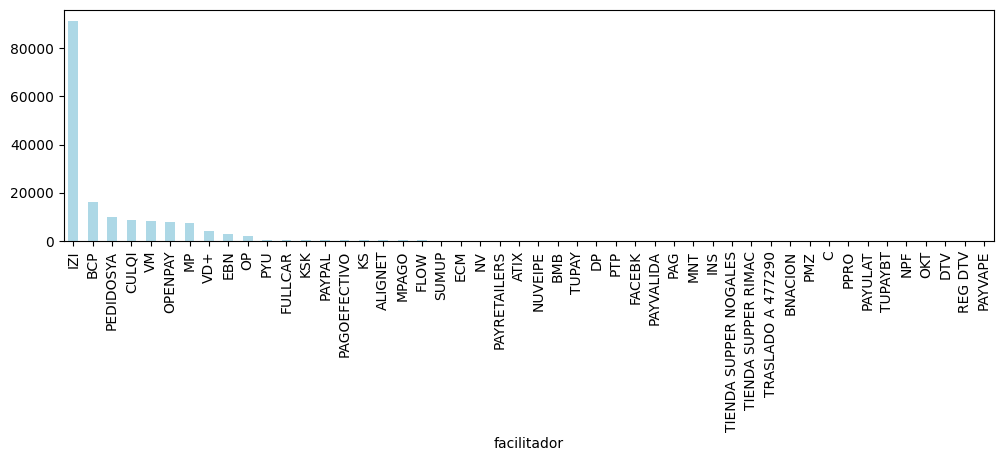

In [264]:
fig, ax = plt.subplots(figsize=(12,3))
temp.facilitador.value_counts(dropna=False).plot(kind='bar', ax=ax, color='lightblue')

In [265]:
temp['facilitador'] = np.where(temp['facilitador'].isin(['VM', 'VD+','VD']),'VD+',
                               np.where(temp['facilitador'].isin(['CULQI', 'FPCULQUI']),'CULQI',
                                        np.where(temp['facilitador'].isin(['MP','MPAGO']),'MPAGO',
                                                 np.where(temp['facilitador'].isin(['OPE','OP','OPENPAY']),'OP',
                                                          np.where(temp['facilitador'].isin(['PYU','PAYU']),'PAYU',temp['facilitador'])
                                                          )
                                                          )
                                                          )
                                                          )

In [266]:
ibk.drop(columns='facilitador', inplace=True)

In [267]:
ibk.shape # 1318792

(1411681, 19)

In [268]:
ibk = ibk.merge(temp, on='codigo', how='left')

In [269]:
ibk.shape # 1318792

(1411695, 20)

In [270]:
temp = ibk[['codigo', 'facilitador']].drop_duplicates()
temp

,codigo,facilitador
0,5717284,IZI
1,5851646,IZI
2,5852292,IZI
3,5957887,IZI
4,5934496,IZI
...,...,...
1411690,999999_ZARA 2 4,NaN
1411691,999999_ZONA 31 19 3,NaN
1411692,999999_ZONA 31 25 4,NaN
1411693,999999_ZONA 31 26 4,NaN


In [271]:
temp.nunique()

,0
codigo,348551
facilitador,45


In [272]:
temp.loc[temp.duplicated(subset='codigo', keep=False)].sort_values(by='codigo')

,codigo,facilitador
262668,NaN,PAYVALIDA
262669,NaN,PAYVAPE


In [273]:
temp.drop_duplicates(inplace=True)

In [274]:
ibk[['codigo', 'bolsa', 'facilitador']].drop_duplicates()

,codigo,bolsa,facilitador
0,5717284,NaN,IZI
1,5851646,NaN,IZI
2,5852292,NaN,IZI
3,5957887,NaN,IZI
4,5934496,NaN,IZI
...,...,...,...
1411690,999999_ZARA 2 4,999999,NaN
1411691,999999_ZONA 31 19 3,999999,NaN
1411692,999999_ZONA 31 25 4,999999,NaN
1411693,999999_ZONA 31 26 4,999999,NaN


In [275]:
ibk[['codigo', 'bolsa', 'facilitador']].drop_duplicates().nunique()

,0
codigo,348551
bolsa,1272
facilitador,45


#### Codigo y Nombre Comercial

In [276]:
# regla: un código solo tiene un nombre comercial
temp = ibk[['codigo', 'nombrecomercial']].drop_duplicates()
temp.sort_values(by='codigo', inplace=True)
temp.nombrecomercial = temp.nombrecomercial.str.lstrip('IZI*')
temp.nombrecomercial = temp.nombrecomercial.str.strip()
temp.drop_duplicates(inplace=True)
temp

,codigo,nombrecomercial
847801,100000000_1580CIX LICORERIA,1580CIX LICORERIA
994461,100000000_17 TH STREET,17 TH STREET
1245591,100000000_20565520734 MEDICAL AUDIC,20565520734 MEDICAL AUDIC
1245594,100000000_20600426649 OI2 EIRL,20600426649 OI2 EIRL
994463,100000000_20610428062,20610428062
...,...,...
1411687,999999_ZONAZUL CCO SANTAFE 12 3,ONAZUL CCO SANTAFE 12 3
1411688,999999_ZYROPE CAFE 9 4,YROPE CAFE 9 4
1411694,999999_ZYROPE CAFE BAR LC 1 4,YROPE CAFE BAR LC 1 4
262668,NaN,GARENA PE


In [277]:
temp.nunique()

,0
codigo,348551
nombrecomercial,233699


In [278]:
# cuales son los códigos que tienen varios nombres comerciales?
temp[temp.duplicated(subset='codigo', keep=False)]

,codigo,nombrecomercial
819951,5009488,TRIATHLON SPORT
32072,5009488,TRIATHLON S 005009488
78752,5009859,VIERDES GRA 005009859
359316,5009859,VIERDES GRASS CHALLAPAMPA
78753,5009871,VIERDES GRA 005009871
...,...,...
133551,9888132,OUTGOING EN 009888132
505835,9993813,MPORTACIONES ALEX
285981,9993813,MPORTACION 009993813
262668,NaN,GARENA PE


In [279]:
temp.drop_duplicates(subset='codigo', keep='first', inplace=True)

In [280]:
ibk.drop(columns='nombrecomercial', inplace=True)

In [281]:
temp.shape

(348552, 2)

In [282]:
temp.nunique()

,0
codigo,348551
nombrecomercial,231274


In [283]:
ibk = ibk.merge(temp, on='codigo', how='left')

In [284]:
temp = ibk[['codigo', 'nombrecomercial']].drop_duplicates()
temp

,codigo,nombrecomercial
0,5717284,AGRO VET 005717284
1,5851646,AGRO VETERI 005851646
2,5852292,AMERICA SAC 005852292
3,5957887,ANIMAL CARE 005957887
4,5934496,ANIMAL GLAM 005934496
...,...,...
1411690,999999_ZARA 2 4,ARA 2 4
1411691,999999_ZONA 31 19 3,ONA 31 19 3
1411692,999999_ZONA 31 25 4,ONA 31 25 4
1411693,999999_ZONA 31 26 4,ONA 31 26 4


In [285]:
temp.nunique()

,0
codigo,348551
nombrecomercial,231274


In [286]:
# cuales son los códigos que aparecen más en la base?
ibk.codigo.value_counts()

,count
codigo,
100000000_INVERSIONES,192
200000000_INVERSIONES,142
4035823,112
4035821,109
4028501,107
...,...
999999_VILLA ROMANA 11 4,1
999999_VENUES SNACKS 25 4,1
999999_VENUES SNACKS 23 4,1


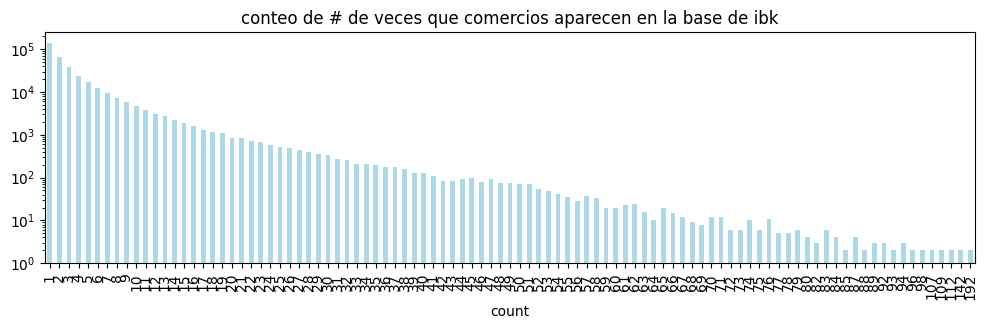

In [287]:
fig, ax = plt.subplots(figsize=(12, 3))
ibk.codigo.value_counts().value_counts().sort_index().plot(kind='bar', log=True, color='lightblue', title='conteo de # de veces que comercios aparecen en la base de ibk')
plt.show()

#### Codigo y Mcc

In [288]:
temp = ibk[['codigo', 'mcc']].drop_duplicates()
temp

,codigo,mcc
0,5717284,0742
1,5851646,0742
2,5852292,0742
3,5957887,0742
4,5934496,0742
...,...,...
1411690,999999_ZARA 2 4,9999
1411691,999999_ZONA 31 19 3,9999
1411692,999999_ZONA 31 25 4,9999
1411693,999999_ZONA 31 26 4,9999


In [289]:
temp.nunique()

,0
codigo,348551
mcc,329


In [290]:
cantidad_codigos_unicos = temp['codigo'].nunique()
print(f"Cantidad de códigos únicos: {cantidad_codigos_unicos}")
cantidad_registros = len(temp)
print(f"Cantidad total de registros: {cantidad_registros}")
codigos_mas_de_un_mcc = temp.groupby('codigo')['mcc'].nunique()
codigos_con_mas_de_un_mcc = codigos_mas_de_un_mcc[codigos_mas_de_un_mcc > 1]
print(f"Cantidad de códigos con más de un MCC: {len(codigos_con_mas_de_un_mcc)}")

Cantidad de códigos únicos: 348551
Cantidad total de registros: 360409
Cantidad de códigos con más de un MCC: 11147


In [291]:
# se asigna a cada código de comercio el mcc que tenga mayor transacción
temp = ibk.groupby(by=['codigo', 'mcc'])['monto'].sum().reset_index()
temp.sort_values(by=['codigo', 'monto'], inplace=True)
temp

,codigo,mcc,monto
0,100000000_1580CIX LICORERIA,5735,18.90
1,100000000_17 TH STREET,5812,120.00
2,100000000_20565520734 MEDICAL AUDIC,5976,2289.82
3,100000000_20600426649 OI2 EIRL,5976,108.00
4,100000000_20610428062,5812,13.00
...,...,...,...
360403,999999_ZONA GW 24 3,9999,163.44
360404,999999_ZONA IN 31 3,9999,6.87
360405,999999_ZONAZUL CCO SANTAFE 12 3,9999,198.66
360406,999999_ZYROPE CAFE 9 4,9999,232.79


In [292]:
temp.query('codigo=="987_TRASLADO DE SALDO"')

,codigo,mcc,monto
356994,987_TRASLADO DE SALDO,6010,284176.37


In [293]:
# nos quedamos con el mcc on más monto transaccionado por código
temp.drop_duplicates(subset=['codigo'], inplace=True, keep='last')
temp

,codigo,mcc,monto
0,100000000_1580CIX LICORERIA,5735,18.90
1,100000000_17 TH STREET,5812,120.00
2,100000000_20565520734 MEDICAL AUDIC,5976,2289.82
3,100000000_20600426649 OI2 EIRL,5976,108.00
4,100000000_20610428062,5812,13.00
...,...,...,...
360403,999999_ZONA GW 24 3,9999,163.44
360404,999999_ZONA IN 31 3,9999,6.87
360405,999999_ZONAZUL CCO SANTAFE 12 3,9999,198.66
360406,999999_ZYROPE CAFE 9 4,9999,232.79


In [294]:
ibk.drop(columns='mcc', inplace=True)
ibk = ibk.merge(temp[['codigo', 'mcc']], on='codigo', how='left')

In [295]:
ibk[['codigo', 'mcc']].drop_duplicates().nunique()

,0
codigo,348551
mcc,328


In [296]:
temp = ibk[['codigo', 'mcc']].drop_duplicates()
temp.sort_values(by='codigo', inplace=True)
temp

,codigo,mcc
847801,100000000_1580CIX LICORERIA,5735
994461,100000000_17 TH STREET,5812
1245591,100000000_20565520734 MEDICAL AUDIC,5976
1245594,100000000_20600426649 OI2 EIRL,5976
994463,100000000_20610428062,5812
...,...,...
1411686,999999_ZONA IN 31 3,9999
1411687,999999_ZONAZUL CCO SANTAFE 12 3,9999
1411688,999999_ZYROPE CAFE 9 4,9999
1411694,999999_ZYROPE CAFE BAR LC 1 4,9999


In [297]:
temp.nunique()

,0
codigo,348551
mcc,328


In [298]:
temp[temp.duplicated(subset='codigo', keep=False)]

,codigo,mcc


In [299]:
ibk.query('codigo=="987_TRASLADO DE SALDO"')

,tipoproducto,emisor,nombrecomercial_old,desciudadcomercio,dpto,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,count,cant_codigo_x,cant_codigo_y,codigo,bolsa,facilitador,nombrecomercial,mcc
1258279,Fisico,L,TRASLADO DE SALDO,None,ANCASH,TC,Visa,1,9983.10,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258280,Fisico,L,TRASLADO DE SALDO,None,CALLAO,TC,Visa,1,51.42,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258281,Fisico,L,TRASLADO DE SALDO,None,ICA,TC,Amex,1,20487.87,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258282,Fisico,L,TRASLADO DE SALDO,None,ICA,TC,Visa,1,670.27,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258283,Fisico,L,TRASLADO DE SALDO,None,JUNIN,TC,Amex,1,3865.09,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258284,Fisico,L,TRASLADO DE SALDO,None,LA LIBERTAD,TC,Visa,11,4046.24,11,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258285,Fisico,L,TRASLADO DE SALDO,None,LAMBAYEQUE,TC,Amex,1,30000.00,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258286,Fisico,L,TRASLADO DE SALDO,None,LAMBAYEQUE,TC,Visa,1,2728.48,1,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258287,Fisico,L,TRASLADO DE SALDO,None,LIMA,TC,Amex,121231,57564.46,121231,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010
1258288,Fisico,L,TRASLADO DE SALDO,None,LIMA,TC,Visa,13221114122111,82586.95,13221114122111,NaN,TRASLADO DE SALDO,NaN,NaN,NaN,987_TRASLADO DE SALDO,987,NaN,TRASLADO DE SALDO,6010


#### Tipo Producto

In [300]:
temp = ibk[['codigo', 'tipoproducto']].drop_duplicates()
temp

,codigo,tipoproducto
0,5717284,Virtual
1,5851646,Virtual
2,5852292,Virtual
3,5957887,Virtual
4,5934496,Virtual
...,...,...
1411690,999999_ZARA 2 4,Fisico
1411691,999999_ZONA 31 19 3,Fisico
1411692,999999_ZONA 31 25 4,Fisico
1411693,999999_ZONA 31 26 4,Fisico


In [301]:
temp.nunique()

,0
codigo,348551
tipoproducto,2


In [302]:
temp = ibk.groupby(by=['codigo', 'tipoproducto'])['monto'].sum().reset_index()
temp.sort_values(by=['codigo', 'monto'], inplace=True)
temp.drop_duplicates(subset='codigo', inplace=True, keep='last')
temp

,codigo,tipoproducto,monto
0,100000000_1580CIX LICORERIA,Fisico,18.90
1,100000000_17 TH STREET,Fisico,120.00
2,100000000_20565520734 MEDICAL AUDIC,Fisico,2289.82
3,100000000_20600426649 OI2 EIRL,Fisico,108.00
4,100000000_20610428062,Fisico,13.00
...,...,...,...
390021,999999_ZONA GW 24 3,Fisico,163.44
390022,999999_ZONA IN 31 3,Fisico,6.87
390023,999999_ZONAZUL CCO SANTAFE 12 3,Fisico,198.66
390024,999999_ZYROPE CAFE 9 4,Fisico,232.79


In [303]:
ibk.drop(columns='tipoproducto', inplace=True)
ibk = ibk.merge(temp[['codigo', 'tipoproducto']], on='codigo', how='left')

In [304]:
ibk[['codigo', 'tipoproducto']].drop_duplicates().shape

(348552, 2)

In [305]:
temp = ibk[['codigo', 'tipoproducto']].drop_duplicates()
temp

,codigo,tipoproducto
0,5717284,Virtual
1,5851646,Fisico
2,5852292,Fisico
3,5957887,Fisico
4,5934496,Fisico
...,...,...
1411690,999999_ZARA 2 4,Fisico
1411691,999999_ZONA 31 19 3,Fisico
1411692,999999_ZONA 31 25 4,Fisico
1411693,999999_ZONA 31 26 4,Fisico


In [306]:
temp.nunique()

,0
codigo,348551
tipoproducto,2


#### Departamento

In [307]:
temp = ibk.loc[ibk.dpto!='?', ['codigo', 'dpto']].drop_duplicates()
temp

,codigo,dpto
0,5717284,ICA
1,5851646,None
2,5852292,None
3,5957887,LORETO
4,5934496,CALLAO
...,...,...
1411690,999999_ZARA 2 4,LIMA
1411691,999999_ZONA 31 19 3,LIMA
1411692,999999_ZONA 31 25 4,None
1411693,999999_ZONA 31 26 4,None


In [308]:
temp.nunique()

,0
codigo,348551
dpto,27


In [309]:
temp = ibk.loc[ibk.dpto!='?', ['codigo', 'dpto', 'monto']].groupby(by=['codigo', 'dpto'])['monto'].sum().reset_index()
temp.sort_values(by=['codigo','monto'], inplace=True)
temp.drop_duplicates(subset='codigo', keep='last', inplace=True)
temp

,codigo,dpto,monto
0,100000000_1580CIX LICORERIA,LAMBAYEQUE,18.90
2,100000000_17 TH STREET,None,90.00
3,100000000_20565520734 MEDICAL AUDIC,AREQUIPA,2050.00
6,100000000_20600426649 OI2 EIRL,None,108.00
7,100000000_20610428062,None,13.00
...,...,...,...
985858,999999_ZONA GW 24 3,LIMA,163.44
985859,999999_ZONA IN 31 3,LIMA,6.87
985860,999999_ZONAZUL CCO SANTAFE 12 3,None,198.66
985861,999999_ZYROPE CAFE 9 4,LIMA,232.79


In [310]:
temp.nunique()

,0
codigo,348551
dpto,27
monto,94617


In [311]:
ibk.drop(columns='dpto', inplace=True)
ibk = ibk.merge(temp[['codigo', 'dpto']], on='codigo', how='left')
ibk

,emisor,nombrecomercial_old,desciudadcomercio,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,count,cant_codigo_x,cant_codigo_y,codigo,bolsa,facilitador,nombrecomercial,mcc,tipoproducto,dpto
0,L,AGRO VET 005717284,None,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,NaN,1.00,NaN,5717284,NaN,IZI,AGRO VET 005717284,0742,Virtual,ICA
1,L,AGRO VETERI 005851646,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,NaN,2.00,NaN,5851646,NaN,IZI,AGRO VETERI 005851646,0742,Fisico,UCAYALI
2,L,AMERICA SAC 005852292,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,NaN,1.00,NaN,5852292,NaN,IZI,AMERICA SAC 005852292,0742,Fisico,None
3,L,ANIMAL CARE 005957887,None,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,NaN,1.00,NaN,5957887,NaN,IZI,ANIMAL CARE 005957887,0742,Fisico,None
4,L,ANIMAL GLAM 005934496,None,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,NaN,1.00,NaN,5934496,NaN,IZI,ANIMAL GLAM 005934496,0742,Fisico,LIMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411690,L,ZARA 2 4,LIMA,TC,Visa,1,1905.74,1,NaN,Zara 2/4,NaN,NaN,NaN,999999_ZARA 2 4,999999,NaN,ARA 2 4,9999,Fisico,LIMA
1411691,L,ZONA 31 19 3,LIMA,TC,Visa,2,105.64,2,NaN,Zona 31 19/3,NaN,NaN,NaN,999999_ZONA 31 19 3,999999,NaN,ONA 31 19 3,9999,Fisico,LIMA
1411692,L,ZONA 31 25 4,LIMA,TC,Visa,1,47.47,1,NaN,Zona 31 25/4,NaN,NaN,NaN,999999_ZONA 31 25 4,999999,NaN,ONA 31 25 4,9999,Fisico,None
1411693,L,ZONA 31 26 4,LIMA,TC,Visa,1,64.16,1,NaN,Zona 31 26/4,NaN,NaN,NaN,999999_ZONA 31 26 4,999999,NaN,ONA 31 26 4,9999,Fisico,None


In [312]:
ibk.dpto.value_counts(dropna=False)

,count
dpto,
LIMA,847093
None,103630
LA LIBERTAD,63140
AREQUIPA,56832
PIURA,45684
LAMBAYEQUE,38411
ICA,34041
CALLAO,27449
CUSCO,25761


In [313]:
ibk.loc[ibk.dpto.isna()]

,emisor,nombrecomercial_old,desciudadcomercio,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,count,cant_codigo_x,cant_codigo_y,codigo,bolsa,facilitador,nombrecomercial,mcc,tipoproducto,dpto
262668,L,GARENA PE,LIMA,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVALIDA,GARENA PE,NaN,NaN,NaN
262669,L,GARENA PE,LIMA,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVAPE,GARENA PE,NaN,NaN,NaN
262670,L,GARENA PE,LIMA,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVALIDA,GARENA PE,NaN,NaN,NaN
262671,L,GARENA PE,LIMA,TD,Visa,1,3.90,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVAPE,GARENA PE,NaN,NaN,NaN
262672,L,GARENA PE,LIMA,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVALIDA,GARENA PE,NaN,NaN,NaN
262673,L,GARENA PE,LIMA,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVAPE,GARENA PE,NaN,NaN,NaN
262674,L,GARENA PE,LIMA,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVALIDA,GARENA PE,NaN,NaN,NaN
262675,L,GARENA PE,LIMA,TD,Visa,1,11.50,1,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVAPE,GARENA PE,NaN,NaN,NaN
262676,L,GARENA PE,LIMA,TD,Visa,11,31.00,11,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVALIDA,GARENA PE,NaN,NaN,NaN
262677,L,GARENA PE,LIMA,TD,Visa,11,31.00,11,NaN,PAYVALIDA*GARENA PE,NaN,NaN,NaN,NaN,NaN,PAYVAPE,GARENA PE,NaN,NaN,NaN


In [314]:
ibk.loc[ibk.codigo == '6056758']

,emisor,nombrecomercial_old,desciudadcomercio,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,count,cant_codigo_x,cant_codigo_y,codigo,bolsa,facilitador,nombrecomercial,mcc,tipoproducto,dpto


In [315]:
ibk.loc[ibk.dpto.isna(), 'dpto'] = 'LIMA'

In [316]:
ibk.loc[ibk.dpto=='LIMA PROV', 'dpto'] = 'LIMA'

In [317]:
temp = ibk.loc[ibk.dpto!='?', ['codigo', 'dpto']].drop_duplicates()
temp

,codigo,dpto
0,5717284,ICA
1,5851646,UCAYALI
2,5852292,None
3,5957887,None
4,5934496,LIMA
...,...,...
1411690,999999_ZARA 2 4,LIMA
1411691,999999_ZONA 31 19 3,LIMA
1411692,999999_ZONA 31 25 4,None
1411693,999999_ZONA 31 26 4,None


In [318]:
temp.nunique()

,0
codigo,348551
dpto,26


In [319]:
temp.sort_values(by='codigo', inplace=True)

In [320]:
temp[temp.duplicated(subset='codigo', keep=False)]

,codigo,dpto


In [321]:
print(f"Volumen Total: {ibk['monto'].sum()}")
print(f"\nCantidad de Códigos Distintos: {ibk['codigo'].nunique()}")
print(f"\nCantidad de Nombres Comerciales Distintos: {ibk['nombrecomercial'].nunique()}")

Volumen Total: 1796270854.5991988

Cantidad de Códigos Distintos: 348551

Cantidad de Nombres Comerciales Distintos: 231274


In [322]:
ibk.shape

(1411695, 20)

In [323]:
#Base Final IBK
ibk.head()

,emisor,nombrecomercial_old,desciudadcomercio,tipotarjeta,marca,clientes,monto,trx,cons,nombrecomercial_raw,count,cant_codigo_x,cant_codigo_y,codigo,bolsa,facilitador,nombrecomercial,mcc,tipoproducto,dpto
0,L,AGRO VET 005717284,None,TC,Visa,2,78.00,2,NaN,IZI*AGRO VET*005717284,NaN,1.00,NaN,5717284,NaN,IZI,AGRO VET 005717284,0742,Virtual,ICA
1,L,AGRO VETERI 005851646,None,TC,Visa,1,5.00,1,NaN,IZI*AGRO VETERI*005851646,NaN,2.00,NaN,5851646,NaN,IZI,AGRO VETERI 005851646,0742,Fisico,UCAYALI
2,L,AMERICA SAC 005852292,None,TC,Visa,11,232.00,11,NaN,IZI*AMERICA SAC*005852292,NaN,1.00,NaN,5852292,NaN,IZI,AMERICA SAC 005852292,0742,Fisico,None
3,L,ANIMAL CARE 005957887,None,TC,Visa,1,55.00,1,NaN,IZI*ANIMAL CARE*005957887,NaN,1.00,NaN,5957887,NaN,IZI,ANIMAL CARE 005957887,0742,Fisico,None
4,L,ANIMAL GLAM 005934496,None,TC,Visa,1,40.00,1,NaN,IZI*ANIMAL GLAM*005934496,NaN,1.00,NaN,5934496,NaN,IZI,ANIMAL GLAM 005934496,0742,Fisico,LIMA


In [324]:
# ibk.to_gbq(destination_table='pxc.ibk',
#           project_id='dev-izipay-data-storage',
#           if_exists='replace')  # Opciones: 'fail', 'replace', 'append'

# Tablón central <a class="anchor" id="chapter3"></a>

### Agrupación

Se busca crear una tabla central conteniendo la información relativa y homologada de cada comercio de las 3 fuentes de información.  
El tablón central contiene los campos: codigo, nroruc, razsoc, nombrecomercial, cartera, tipoproducto, mcc, giro, compania y dpto.

In [325]:
codigo_list = izi.codigo.unique().tolist() + ibk.codigo.unique().tolist() + amex.codigo.unique().tolist()

In [326]:
df = pd.DataFrame(data=codigo_list, columns=['codigo'])
df.drop_duplicates(inplace=True)


temp = izi.codigo.to_frame().drop_duplicates()
temp['en_izi'] = '1'
df = df.merge(temp, on='codigo', how='left')

temp = ibk.codigo.to_frame().drop_duplicates()
temp['en_ibk'] = '1'
df = df.merge(temp, on='codigo', how='left')

temp = amex.codigo.to_frame().drop_duplicates()
temp['en_amex'] = '1'
df = df.merge(temp, on='codigo', how='left')

temp = ibk.groupby('codigo')['trx'].sum().reset_index()
temp['trx'] = temp['trx'].astype(str)
df = df.merge(temp, on='codigo', how='left')

df[['en_izi', 'en_ibk', 'en_amex', 'trx']] = df[['en_izi', 'en_ibk', 'en_amex','trx']].replace(np.nan, '0')


df

,codigo,en_izi,en_ibk,en_amex,trx
0,2267144,1,1,0,1213
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...
2,6079852,1,1,0,111111111111
3,8963437,1,0,0,0
4,1038068,1,1,0,1112111112
...,...,...,...,...,...
433365,6177335,0,0,1,0
433366,6152743,0,0,1,0
433367,6083969,0,0,1,0
433368,6270417,0,0,1,0


In [327]:
# la tabla maestra siempre tiene que tener este número de lineas
df.codigo.nunique() # número malo 485238. el resultado debería ser menor.

433369

In [328]:
df[['en_izi', 'en_ibk', 'en_amex']].value_counts(dropna=False).sort_index().sum()

np.int64(433370)

In [329]:
df.shape

(433370, 5)

In [330]:
# Encontrar duplicados basados en el 'index_name' después del merge
duplicados = df[df.duplicated( keep=False)]

# Mostrar los duplicados
duplicados

,codigo,en_izi,en_ibk,en_amex,trx


### Ruc
El nroruc proviene de la tabla izipay, de la tabla de amex o del archivo externo de códigos con nroruc.

In [331]:
# nroruc de izipay
df = df.merge(izi[['codigo', 'nroruc']].drop_duplicates().rename(columns={'nroruc':'nroruc_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi
0,2267144,1,1,0,1213,20307246741
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336
2,6079852,1,1,0,111111111111,20100935032
3,8963437,1,0,0,0,20605282076
4,1038068,1,1,0,1112111112,20100017491
...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN
433366,6152743,0,0,1,0,NaN
433367,6083969,0,0,1,0,NaN
433368,6270417,0,0,1,0,NaN


In [332]:
# nroruc de amex
df = df.merge(amex[['codigo', 'nroruc']].drop_duplicates().rename(columns={'nroruc':'nroruc_amex'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex
0,2267144,1,1,0,1213,20307246741,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN
3,8963437,1,0,0,0,20605282076,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN
...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565
433366,6152743,0,0,1,0,NaN,20479801275
433367,6083969,0,0,1,0,NaN,20160852195
433368,6270417,0,0,1,0,NaN,20160852195


In [333]:
# nroruc de la fuente externa
df = df.merge(codigonroruc[['codigo', 'nroruc']].drop_duplicates().rename(columns={'nroruc':'nroruc_ext'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext
0,2267144,1,1,0,1213,20307246741,NaN,20307246741
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032
3,8963437,1,0,0,0,20605282076,NaN,20605282076
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491
...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565
433366,6152743,0,0,1,0,NaN,20479801275,20479801275
433367,6083969,0,0,1,0,NaN,20160852195,20160852195
433368,6270417,0,0,1,0,NaN,20160852195,NaN


In [334]:
df = df.merge(datos_manuales[['Codigo', 'Ruc']].drop_duplicates().rename(columns={'Ruc':'nroruc_manual'}),
            left_on='codigo', right_on = 'Codigo',
            how='left').drop(columns = 'Codigo')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491
...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN


In [335]:
#df = df.merge(datos_ejercicios[['Codigo', 'Ruc']].drop_duplicates().rename(columns={'Ruc':'nroruc_ejercicio'}),
           # left_on='codigo', right_on = 'Codigo',
           # how='left').drop(columns = 'Codigo')
#df

In [336]:
df = df.merge(cotizador[['codigo', 'nroruc']].drop_duplicates(subset='codigo').rename(columns={'nroruc': 'nroruc_cotiz'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN
...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN


#### Selección de nroruc

In [337]:
nombre_campo = 'nroruc'
index_name = ['codigo']
#feat_list = ['nroruc_izi', 'nroruc_amex', 'nroruc_ext', 'nroruc_manual']
feat_list = ['nroruc_izi', 'nroruc_amex', 'nroruc_ext', 'nroruc_cotiz', 'nroruc_manual']
#feat_list = ['nroruc_izi', 'nroruc_amex', 'nroruc_ext', 'nroruc_cotiz', 'nroruc_manual', 'nroruc_ejercicio'] #cotizador despues de externo antes de manual

agrarramos la informacion transaccion de fuentes
vemos la participacion de ibk en izipay
reglas de extrapolacion (cuentas clientes por grupitos (llave2))
estima el volumen ibk de los codigos de competenia que tienen esas caracteristicas

In [338]:
def seleccion_cascada(df, index_name, lista, nombre_campo):

    mining = df[index_name + lista].copy()
    reconstructed = pd.DataFrame()

    for feat_i in lista:
        temp = mining[index_name + [feat_i]].copy()

        information = temp.dropna(subset=feat_i).copy()
        information_index = information[index_name[0]].tolist()

        nombre_origen = nombre_campo + '_origen'
        information[nombre_origen] = feat_i

        information = information.rename(columns={feat_i:nombre_campo})
        reconstructed = pd.concat([reconstructed, information])

        mining = mining.loc[~mining[index_name[0]].isin(information_index)]

    return reconstructed

In [339]:
temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,nroruc,nroruc_origen
0,2267144,20307246741,nroruc_izi
1,1559621,20466776336,nroruc_izi
2,6079852,20100935032,nroruc_izi
3,8963437,20605282076,nroruc_izi
4,1038068,20100017491,nroruc_izi
...,...,...,...
424950,603210408,20603210426,nroruc_manual
425682,550513001,20550513057,nroruc_manual
427450,176360404,20176360497,nroruc_manual
427451,176360405,20176360497,nroruc_manual


In [340]:
df = df.merge(temp, on='codigo', how='left')

In [341]:
if show_fig:
    fig, ax = plt.subplots(figsize=(5, 2))
    df['nroruc_origen'].value_counts().plot(kind='bar', title='conteo del origen del campo nroruc', color='lightblue', xlabel='')
    plt.show()

In [342]:
df.sample(15)

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen
86677,5093821,1,0,0,0,42037659,NaN,NaN,NaN,NaN,42037659,nroruc_izi
301021,51221,0,1,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29180,8515706,1,0,0,0,72465352,NaN,72465352,72465352,NaN,72465352,nroruc_izi
27529,8096550,1,0,0,0,20609247411,NaN,20609247411,20609247411,NaN,20609247411,nroruc_izi
298247,602370409_FERRETERIA LESLIE,0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65084,5405124,1,1,0,11121,10105806740,NaN,10105806740,10105806740,NaN,10105806740,nroruc_izi
340757,16612,0,1,0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160216,5827876,1,1,0,11111,20613884697,NaN,NaN,NaN,NaN,20613884697,nroruc_izi
93344,5536668,1,0,0,0,10417265762,NaN,NaN,NaN,NaN,10417265762,nroruc_izi
415660,651042973,0,1,0,1211111,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [343]:
df.nroruc_origen.value_counts(dropna=False)

,count
nroruc_origen,
NaN,197983
nroruc_izi,197012
nroruc_amex,27121
nroruc_ext,8091
nroruc_cotiz,2865
nroruc_manual,298


In [344]:
# número de registros con valor en nroruc_izi
df.query('~nroruc_izi.isna()').shape

(197012, 12)

In [345]:
# número de registros sin valor en nroruc_izi pero con valor en nroruc_amex
df.query('nroruc_izi.isna() & ~nroruc_amex.isna()').shape

(27121, 12)

In [346]:
# número de registros sin valor en nroruc_izi y en nroruc_amex pero con valor en nroruc_ext
df.query('nroruc_izi.isna() & nroruc_amex.isna() & ~nroruc_ext.isna()').shape

(8091, 12)

In [347]:
# número de registros sin valor en nroruc_izi y en nroruc_amex y en nroruc_ext pero con valor en nroruc_manual
df.query('nroruc_izi.isna() & nroruc_amex.isna() & nroruc_ext.isna() & ~nroruc_manual.isna()').shape

(304, 12)

In [348]:
# grupo economico según fuente externa
nroruc_greco
df = df.merge(nroruc_greco[['nroruc', 'greco']].drop_duplicates(subset='nroruc'), on='nroruc', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL


In [349]:
df['nroruc_real'] = df['nroruc'].copy()

### Cartera
La cartera proviene de izipay. Si un código no tiene cartera, se calcula la cartera con las transacciones mensuales de nroruc correspondiente. Si no tiene nroruc, se considera el codigo como un nroruc aparte.  
Después, se pone unen todos los nrorucs que pertenezcan a un mismo grupo económico.

In [350]:
# Encontrar duplicados basados en el 'index_name' después del merge
duplicados = df[df.duplicated(keep=False)]

# Mostrar los duplicados
duplicados

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real


In [351]:
df.shape

(433370, 14)

In [352]:
# cartera de izipay
df = df.merge(izi[['codigo', 'cartera']].drop_duplicates().rename(columns={'cartera':'cartera_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN


#### Carterización IBK

In [353]:
# df temporal para definir carteras según nroruc de ibk
temp = ibk[['codigo', 'monto']] # se elige el código y el monto de ibk
temp = temp.merge(df[['codigo', 'nroruc']].drop_duplicates(), on='codigo', how='left') # se agrega el campo final de nroruc
temp.dropna(subset='nroruc', inplace=True) # se eliminan los registros que no tengan nroruc
temp = temp.groupby(by='nroruc')['monto'].sum().reset_index() # se agrupan los montos por nroruc
fraccion = 0.16
temp['monto_proy'] = temp['monto'] / fraccion # se proyecta el monto anual
temp

,nroruc,monto,monto_proy
0,,1520.50,9503.12
1,10000108338,403.00,2518.75
2,10000111959,164.00,1025.00
3,10000269706,5224.00,32650.00
4,10000319878,823.00,5143.75
...,...,...,...
86380,9993209,3191.00,19943.75
86381,9997210,1500.00,9375.00
86382,9998513,168.00,1050.00
86383,9998907,1800.00,11250.00


In [354]:
# def cartera_monto(monto):
#     if monto < 20000:
#         return 'NEG'
#     elif monto >=20000 and monto < 200000:
#         return 'EMP'
#     elif monto >=200000 and monto < 10000000:
#         return 'GGEE'
#     elif monto > 10000000:
#         return 'CORPORACIONES'

In [355]:
def cartera_monto(monto):
    if monto < 25000:
        return 'RETAIL'
    elif monto >=25000 and monto < 1000000:
        return 'NEG'
    elif monto > 1000000:
        return 'CORP'

In [356]:
temp['cartera_ibk_nroruc'] = temp.apply(lambda x: cartera_monto(x.monto_proy), axis=1)
temp

,nroruc,monto,monto_proy,cartera_ibk_nroruc
0,,1520.50,9503.12,RETAIL
1,10000108338,403.00,2518.75,RETAIL
2,10000111959,164.00,1025.00,RETAIL
3,10000269706,5224.00,32650.00,NEG
4,10000319878,823.00,5143.75,RETAIL
...,...,...,...,...
86380,9993209,3191.00,19943.75,RETAIL
86381,9997210,1500.00,9375.00,RETAIL
86382,9998513,168.00,1050.00,RETAIL
86383,9998907,1800.00,11250.00,RETAIL


In [357]:
# revisamos por cada cartera los valores máximos y mínimos del monto proyectado
temp.groupby(by='cartera_ibk_nroruc')['monto_proy'].agg(['max', 'min']).sort_index()

,max,min
cartera_ibk_nroruc,,
CORP,405366306.54,1006264.62
NEG,999710.06,25000.00
RETAIL,24999.75,0.06


In [358]:
df = df.merge(temp[['nroruc', 'cartera_ibk_nroruc']], on='nroruc', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL


In [359]:
# df temporal para definir carteras según códigos sin nroruc de ibk
temp = ibk[['codigo', 'monto']] # se elige el código y el monto de ibk
temp = temp.merge(df[['codigo', 'nroruc']].drop_duplicates(), on='codigo', how='left') # se agrega el campo final de nroruc
temp = temp.loc[temp.nroruc.isna()] # se eligen los registros que no tengan nroruc
temp = temp.groupby(by='codigo')['monto'].sum().reset_index() # se agrupan los montos por nroruc
fraccion = 0.16
temp['monto_proy'] = temp['monto'] / fraccion # se proyecta el monto anual
temp

,codigo,monto,monto_proy
0,100000000_1580CIX LICORERIA,18.90,118.12
1,100000000_17 TH STREET,120.00,750.00
2,100000000_20565520734 MEDICAL AUDIC,2289.82,14311.38
3,100000000_20600426649 OI2 EIRL,108.00,675.00
4,100000000_20610428062,13.00,81.25
...,...,...,...
197977,999999_ZONA GW 24 3,163.44,1021.51
197978,999999_ZONA IN 31 3,6.87,42.96
197979,999999_ZONAZUL CCO SANTAFE 12 3,198.66,1241.60
197980,999999_ZYROPE CAFE 9 4,232.79,1454.92


In [360]:
temp['cartera_ibk_codigo'] = temp.apply(lambda x: cartera_monto(x.monto_proy), axis=1)
temp

,codigo,monto,monto_proy,cartera_ibk_codigo
0,100000000_1580CIX LICORERIA,18.90,118.12,RETAIL
1,100000000_17 TH STREET,120.00,750.00,RETAIL
2,100000000_20565520734 MEDICAL AUDIC,2289.82,14311.38,RETAIL
3,100000000_20600426649 OI2 EIRL,108.00,675.00,RETAIL
4,100000000_20610428062,13.00,81.25,RETAIL
...,...,...,...,...
197977,999999_ZONA GW 24 3,163.44,1021.51,RETAIL
197978,999999_ZONA IN 31 3,6.87,42.96,RETAIL
197979,999999_ZONAZUL CCO SANTAFE 12 3,198.66,1241.60,RETAIL
197980,999999_ZYROPE CAFE 9 4,232.79,1454.92,RETAIL


In [361]:
# revisamos por cada cartera los valores máximos y mínimos del monto proyectado
temp.groupby(by='cartera_ibk_codigo')['monto_proy'].agg(['max', 'min']).sort_index()

,max,min
cartera_ibk_codigo,,
CORP,93456061.50,1001767.50
NEG,994996.25,25000.00
RETAIL,24999.75,0.62


In [362]:
df = df.merge(temp[['codigo', 'cartera_ibk_codigo']], on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN


#### Carterización Amex

In [363]:
# df temporal para definir carteras según nroruc de amex
temp = amex[['codigo', 'monto']] # se elige el código y el monto de amex
temp = temp.merge(df[['codigo', 'nroruc']].drop_duplicates(), on='codigo', how='left') # se agrega el campo final de nroruc
temp.dropna(subset='nroruc', inplace=True) # se eliminan los registros que no tengan nroruc
temp = temp.groupby(by='nroruc')['monto'].sum().reset_index() # se agrupan los montos por nroruc
fraccion = 0.16
temp['monto_proy'] = temp['monto'] / fraccion # se proyecta el monto anual
temp

,nroruc,monto,monto_proy
0,10000269706,3769.00,23556.25
1,10000825196,59.00,368.75
2,10002132660,106.50,665.62
3,10002401326,316.50,1978.12
4,10002453954,243.00,1518.75
...,...,...,...
12103,20615923282,452.00,2825.00
12104,20615933733,700.50,4378.12
12105,20615952878,119.50,746.88
12106,20615956458,445.00,2781.25


In [364]:
temp['cartera_amex_nroruc'] = temp.apply(lambda x: cartera_monto(x.monto_proy), axis=1)
temp

,nroruc,monto,monto_proy,cartera_amex_nroruc
0,10000269706,3769.00,23556.25,RETAIL
1,10000825196,59.00,368.75,RETAIL
2,10002132660,106.50,665.62,RETAIL
3,10002401326,316.50,1978.12,RETAIL
4,10002453954,243.00,1518.75,RETAIL
...,...,...,...,...
12103,20615923282,452.00,2825.00,RETAIL
12104,20615933733,700.50,4378.12,RETAIL
12105,20615952878,119.50,746.88,RETAIL
12106,20615956458,445.00,2781.25,RETAIL


In [365]:
# revisamos por cada cartera los valores máximos y mínimos del monto proyectado
temp.groupby(by='cartera_amex_nroruc')['monto_proy'].agg(['max', 'min']).sort_index()

,max,min
cartera_amex_nroruc,,
CORP,287432607.44,1003556.81
NEG,974102.50,25000.00
RETAIL,24990.94,0.00


In [366]:
df = df.merge(temp[['nroruc', 'cartera_amex_nroruc']], on='nroruc', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL


In [367]:
# df temporal para definir carteras según códigos sin nroruc de amex
temp = amex[['codigo', 'monto']] # se elige el código y el monto de amex
temp = temp.merge(df[['codigo', 'nroruc']].drop_duplicates(), on='codigo', how='left') # se agrega el campo final de nroruc
temp = temp.loc[temp.nroruc.isna()] # se eligen los registros que no tengan nroruc
temp = temp.groupby(by='codigo')['monto'].sum().reset_index() # se agrupan los montos por nroruc
fraccion = 0.16
temp['monto_proy'] = temp['monto'] / fraccion # se proyecta el monto anual
temp

,codigo,monto,monto_proy


In [368]:
try:
    temp['cartera_amex_codigo'] = temp.apply(lambda x: cartera_monto(x.monto_proy), axis=1)

    df = df.merge(temp[['codigo', 'cartera_amex_codigo']], on='codigo', how='left')

except ValueError:
    df['cartera_amex_codigo'] = pd.NA
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN


#### Selección de cartera

In [369]:
nombre_campo = 'cartera'
index_name = ['codigo']
feat_list = ['cartera_izi', 'cartera_ibk_nroruc', 'cartera_amex_nroruc', 'cartera_ibk_codigo', 'cartera_amex_codigo']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,cartera,cartera_origen
0,2267144,BC,cartera_izi
1,1559621,BC,cartera_izi
2,6079852,BE,cartera_izi
3,8963437,BPE,cartera_izi
4,1038068,BC,cartera_izi
...,...,...,...
430404,999999_ZARA 2 4,RETAIL,cartera_ibk_codigo
430405,999999_ZONA 31 19 3,RETAIL,cartera_ibk_codigo
430406,999999_ZONA 31 25 4,RETAIL,cartera_ibk_codigo
430407,999999_ZONA 31 26 4,RETAIL,cartera_ibk_codigo


In [370]:
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN


In [371]:
df = df.merge(temp, on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc


In [372]:
# Encontrar duplicados basados en el 'index_name' después del merge
duplicados = df[df.duplicated(subset=index_name, keep=False)]

# Mostrar los duplicados
duplicados

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen


In [373]:
if show_fig:
    fig, ax = plt.subplots(figsize=(5, 2))
    df['cartera_origen'].value_counts().plot(kind='bar', title='conteo del origen del campo cartera', color='lightblue', xlabel='')
    plt.show()

In [374]:
df.shape

(433370, 21)

### Tipo de producto

In [375]:
# tipoproducto de izipay
df = df.merge(izi[['codigo', 'tipoproducto']].drop_duplicates().rename(columns={'tipoproducto':'tipoproducto_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN


In [376]:
# tipoproducto de ibk
df = df.merge(ibk[['codigo', 'tipoproducto']].drop_duplicates().rename(columns={'tipoproducto':'tipoproducto_ibk'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN


In [377]:
df.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'nroruc_izi',
       'nroruc_amex', 'nroruc_ext', 'nroruc_manual', 'nroruc_cotiz', 'nroruc',
       'nroruc_origen', 'greco', 'nroruc_real', 'cartera_izi',
       'cartera_ibk_nroruc', 'cartera_ibk_codigo', 'cartera_amex_nroruc',
       'cartera_amex_codigo', 'cartera', 'cartera_origen', 'tipoproducto_izi',
       'tipoproducto_ibk'],
      dtype='object')

#### Selección de Producto

In [378]:
nombre_campo = 'tipoproducto'
index_name = ['codigo']
feat_list = ['tipoproducto_izi', 'tipoproducto_ibk']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,tipoproducto,tipoproducto_origen
0,2267144,Fisico,tipoproducto_izi
1,1559621,Fisico,tipoproducto_izi
2,6079852,Fisico,tipoproducto_izi
3,8963437,Fisico,tipoproducto_izi
4,1038068,Fisico,tipoproducto_izi
...,...,...,...
430404,999999_ZARA 2 4,Fisico,tipoproducto_ibk
430405,999999_ZONA 31 19 3,Fisico,tipoproducto_ibk
430406,999999_ZONA 31 25 4,Fisico,tipoproducto_ibk
430407,999999_ZONA 31 26 4,Fisico,tipoproducto_ibk


In [379]:
df = df.merge(temp, on='codigo', how='left')

In [380]:
if show_fig:
    fig, ax = plt.subplots(figsize=(5, 2))
    df['tipoproducto_origen'].value_counts(dropna=False).plot(kind='bar', title='conteo del origen del campo tipoproducto', color='lightblue', xlabel='')
    plt.show()

In [381]:
df.loc[df.tipoproducto.isna(), 'tipoproducto'] = 'Fisico'

In [382]:
df.tipoproducto.value_counts(dropna=False)

,count
tipoproducto,
Fisico,334913
Virtual,98457


### Mcc

In [383]:
df.shape

(433370, 25)

In [384]:
# mcc de izipay
df = df.merge(izi[['codigo', 'mcc']].drop_duplicates().rename(columns={'mcc':'mcc_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN


In [385]:
# mcc de ibk
df = df.merge(ibk[['codigo', 'mcc']].drop_duplicates().rename(columns={'mcc':'mcc_ibk'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN


In [386]:
# mcc de amex
df = df.merge(amex[['codigo', 'mcc']].drop_duplicates().rename(columns={'mcc':'mcc_amex'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311


#### Selección de mcc

In [387]:
nombre_campo = 'mcc'
index_name = ['codigo']
feat_list = ['mcc_izi', 'mcc_ibk', 'mcc_amex']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,mcc,mcc_origen
0,2267144,3076,mcc_izi
1,1559621,5039,mcc_izi
2,6079852,3357,mcc_izi
3,8963437,8071,mcc_izi
4,1038068,4900,mcc_izi
...,...,...,...
433365,6177335,9311,mcc_amex
433366,6152743,9311,mcc_amex
433367,6083969,9311,mcc_amex
433368,6270417,9311,mcc_amex


In [388]:
df = df.merge(temp, on='codigo', how='left')

In [389]:
df.shape

(433370, 30)

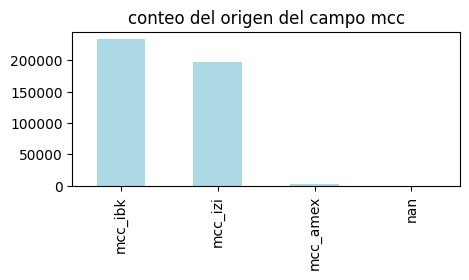

In [390]:
fig, ax = plt.subplots(figsize=(5, 2))
df['mcc_origen'].value_counts(dropna=False).plot(kind='bar', title='conteo del origen del campo mcc', color='lightblue', xlabel='')
plt.show()

In [391]:
amex.loc[amex.codigo.isin(df.loc[df.mcc.isna(), 'codigo'].values.tolist())]

,periodo,nroruc,codigo,banco,facilitador,monto,trx,nombrecomercial,mcc,giro


#### Campo giro y  vertical

In [392]:
df = df.merge(mccgv, on='mcc', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS


### Compañia

In [393]:
df.shape

(433370, 32)

In [394]:
# Obtener los códigos que tienen más de una compañía asociada
codigo_multiples_companias = izi.groupby('codigo')['compania'].nunique()
codigo_multiples_companias = codigo_multiples_companias[codigo_multiples_companias > 1]

# Filtrar las filas originales donde el código tiene más de una compañía
result = izi[izi['codigo'].isin(codigo_multiples_companias.index)]

# Mostrar el resultado
result

,periodo,nroruc,codigo,razsoc,compania,tipoproducto,dpto,tipotarjeta,emisor,marca,onus,banco,cartera,nombrecomercial,monto,trx,mcc,giro,facilitador


In [395]:
# compania de izipay
df = df.merge(izi[['codigo', 'compania']].drop_duplicates(), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN


In [396]:
# los que no son de izipay, poner valor OTROS
df.loc[df.compania.isna(), 'compania'] = 'OTROS'

In [397]:
if show_fig:
    fig, ax = plt.subplots(figsize=(5, 2))
    df['compania'].value_counts(dropna=False).plot(kind='bar', title='conteo de la compañía', color='lightblue', xlabel='')
    plt.show()

### Departamento

In [398]:
# dpto de izipay
df = df.merge(izi[['codigo', 'dpto']].drop_duplicates().rename(columns={'dpto':'dpto_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN


In [399]:
# dpto de ibk
df = df.merge(ibk[['codigo', 'dpto']].drop_duplicates().rename(columns={'dpto':'dpto_ibk'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN


#### Selección de dpto

In [400]:
nombre_campo = 'dpto'
index_name = ['codigo']
feat_list = ['dpto_izi', 'dpto_ibk']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,dpto,dpto_origen
0,2267144,LIMA,dpto_izi
1,1559621,LIMA,dpto_izi
2,6079852,LIMA,dpto_izi
3,8963437,SAN MARTIN,dpto_izi
4,1038068,LIMA,dpto_izi
...,...,...,...
430404,999999_ZARA 2 4,LIMA,dpto_ibk
430405,999999_ZONA 31 19 3,LIMA,dpto_ibk
430406,999999_ZONA 31 25 4,None,dpto_ibk
430407,999999_ZONA 31 26 4,None,dpto_ibk


In [401]:
df = df.merge(temp, on='codigo', how='left')

In [402]:
if show_fig:
    fig, ax = plt.subplots(figsize=(5, 2))
    df['dpto_origen'].value_counts(dropna=False).plot(kind='bar', title='conteo del origen del campo dpto', color='lightblue', xlabel='')
    plt.show()

In [403]:
df.loc[df.dpto=='CALLAO', 'dpto'] = 'LIMA'

In [404]:
df.loc[df.dpto.isna(), 'dpto'] = 'LIMA'

In [405]:
df.dpto.isna().sum()

np.int64(0)

In [406]:
df.shape

(433370, 37)

### Razon Social

In [407]:
df = df.merge(izi[['codigo', 'razsoc']].drop_duplicates().rename(columns={'razsoc':'razsoc_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN


In [408]:
df = df.merge(scrapper[['nroruc','razsoc']].rename(columns = {'razsoc':'razsoc_scrapper'}), on='nroruc', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN


In [409]:
df = df.merge(datos_manuales[['Codigo','Razon_Social']].drop_duplicates(subset='Codigo').rename(columns = {'Razon_Social':'razsoc_manual'}),
              left_on='codigo', right_on = 'Codigo',
              how='left').drop(columns = ['Codigo'])
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,MUNICIPALIDAD DISTRITRAL DE CERRO AZUL
433368,6270417,0,0,1,0,NaN,20160852195,NaN,NaN,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,NaN


In [410]:
nombre_campo = 'razsoc'
index_name = ['codigo']
feat_list = ['razsoc_izi', 'razsoc_scrapper','razsoc_manual']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,razsoc,razsoc_origen
0,2267144,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi
1,1559621,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi
2,6079852,INKA S RENT A CAR S A,razsoc_izi
3,8963437,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi
4,1038068,INTEGRATEL PERU S A A,razsoc_izi
...,...,...,...
433358,6085270,SERVICIO DE ADMINISTRACION TRIBUTARIA DE HUAMANGA,razsoc_manual
433363,6134651,MUNICIPALIDAD DE VILLA EL SALVADOR,razsoc_manual
433365,6177335,CONCEJO DISTRITAL DE COMAS,razsoc_manual
433366,6152743,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,razsoc_manual


In [411]:
df = df.merge(temp, on='codigo', how='left')

In [412]:
df.shape

(433370, 42)

### Nombre Comercial

In [413]:
df = df.merge(izi[['codigo', 'nombrecomercial']].drop_duplicates().rename(columns={'nombrecomercial':'nombrecomercial_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,razsoc_manual,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES 

In [414]:
df = df.merge(ibk[['codigo', 'nombrecomercial']].drop_duplicates().rename(columns={'nombrecomercial':'nombrecomercial_ibk'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,razsoc_manual,NaN,NaN
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195,nroruc_amex,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,RETAIL,NaN,RETAIL,NaN,RETAIL,cartera_ibk_nroru

In [415]:
df = df.merge(amex[['codigo', 'nombrecomercial']].drop_duplicates().rename(columns={'nombrecomercial':'nombrecomercial_amex'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,razsoc_manual,NaN,NaN,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO
433367,6083969,0,0,1,0,NaN,20160852195,20160852195,20160852195,NaN,20160852195

In [416]:
df.head()

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN


#### Selección de Nombre Comercial

In [417]:
nombre_campo = 'nombrecomercial'
index_name = ['codigo']
feat_list = ['nombrecomercial_izi','nombrecomercial_ibk', 'nombrecomercial_amex']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,nombrecomercial,nombrecomercial_origen
0,2267144,AEROMEXICO IATA,nombrecomercial_izi
1,1559621,HIPERMERCADO CERAMICO,nombrecomercial_izi
2,6079852,HERTZ,nombrecomercial_izi
3,8963437,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi
4,1038068,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi
...,...,...,...
433365,6177335,CONCEJO DISTRITAL DE COMAS,nombrecomercial_amex
433366,6152743,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,nombrecomercial_amex
433367,6083969,MUNI CERRO AZUL,nombrecomercial_amex
433368,6270417,MUNI CERRO AZUL,nombrecomercial_amex


In [418]:
df = df.merge(temp, on='codigo', how='left')

In [419]:
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,nombrecomercial_amex
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipal

### Facilitador

In [420]:
df = df.merge(izi[['codigo', 'facilitador']].drop_duplicates().rename(columns={'facilitador':'facilitador_izi'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433365,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,nombrecomercial_amex,NaN
433366,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,N

In [421]:
df = df.merge(ibk[['codigo', 'facilitador']].drop_duplicates().rename(columns={'facilitador':'facilitador_ibk'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi,facilitador_ibk
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433366,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,nombrecomercial_amex,NaN,NaN
433367,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,20479801275,nroruc_amex,CGT,20479801275,NaN,NEG,NaN,NEG

In [422]:
df = df.merge(amex[['codigo', 'facilitador']].drop_duplicates().rename(columns={'facilitador':'facilitador_amex'}), on='codigo', how='left')
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi,facilitador_ibk,facilitador_amex
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA,NaN,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA,NaN,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA,NaN,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433366,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,nombrecomercial_amex,NaN,NaN,NIUBIZ-AX
433367,6152743,0,0,1,0,NaN,20479801275,20479801275,20479801275,NaN,2047

In [423]:
df.head()

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi,facilitador_ibk,facilitador_amex
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA,NaN,NaN
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA,NaN,NaN
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA,NaN,NaN
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI,NaN,NaN
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA,NaN,NaN


#### Selección de Facilitador

In [424]:
nombre_campo = 'facilitador'
index_name = ['codigo']
feat_list = ['facilitador_izi','facilitador_ibk', 'facilitador_amex']

temp = seleccion_cascada(df, index_name, feat_list, nombre_campo)
temp

,codigo,facilitador,facilitador_origen
0,2267144,NA,facilitador_izi
1,1559621,NA,facilitador_izi
2,6079852,NA,facilitador_izi
3,8963437,IZI,facilitador_izi
4,1038068,NA,facilitador_izi
...,...,...,...
433366,6177335,NIUBIZ-AX,facilitador_amex
433367,6152743,NIUBIZ-AX,facilitador_amex
433368,6083969,NIUBIZ-AX,facilitador_amex
433369,6270417,NIUBIZ-AX,facilitador_amex


In [425]:
df = df.merge(temp, on='codigo', how='left')

In [426]:
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi,facilitador_ibk,facilitador_amex,facilitador,facilitador_origen
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI,NaN,NaN,IZI,facilitador_izi
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CO

### Informacion Adicional

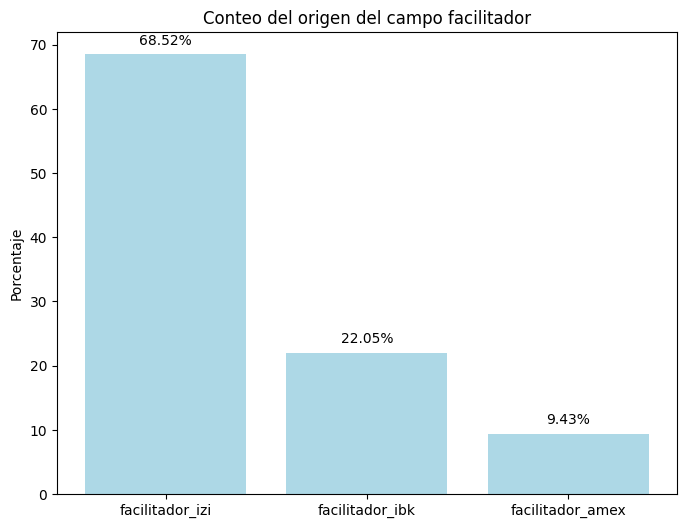

In [427]:
counts = df['facilitador_origen'].value_counts(normalize=True) * 100
# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(counts.index, counts.values, color='lightblue')

# Agregar etiquetas de datos (porcentajes) en cada barra
for i, v in enumerate(counts):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

# Personalizar el gráfico
ax.set_title('Conteo del origen del campo facilitador')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')

# Mostrar el gráfico
plt.show()

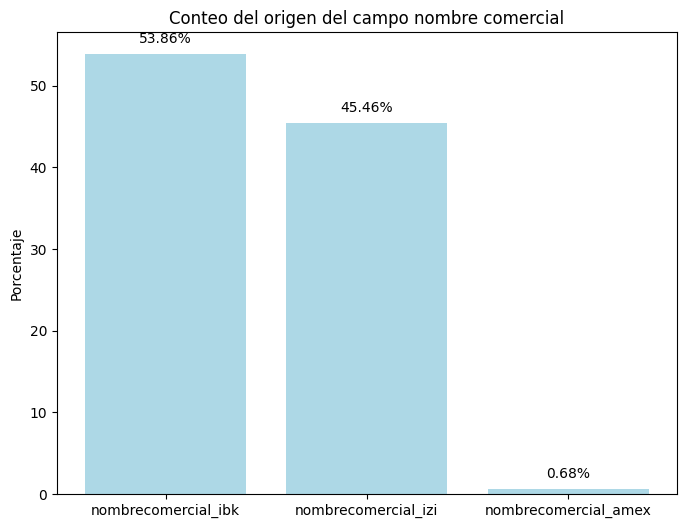

In [428]:
counts = df['nombrecomercial_origen'].value_counts(normalize=True) * 100
# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(counts.index, counts.values, color='lightblue')

# Agregar etiquetas de datos (porcentajes) en cada barra
for i, v in enumerate(counts):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

# Personalizar el gráfico
ax.set_title('Conteo del origen del campo nombre comercial')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')

# Mostrar el gráfico
plt.show()

In [429]:
df

,codigo,en_izi,en_ibk,en_amex,trx,nroruc_izi,nroruc_amex,nroruc_ext,nroruc_manual,nroruc_cotiz,nroruc,nroruc_origen,greco,nroruc_real,cartera_izi,cartera_ibk_nroruc,cartera_ibk_codigo,cartera_amex_nroruc,cartera_amex_codigo,cartera,cartera_origen,tipoproducto_izi,tipoproducto_ibk,tipoproducto,tipoproducto_origen,mcc_izi,mcc_ibk,mcc_amex,mcc,mcc_origen,giro,vertical,compania,dpto_izi,dpto_ibk,dpto,dpto_origen,razsoc_izi,razsoc_scrapper,razsoc_manual,razsoc,razsoc_origen,nombrecomercial_izi,nombrecomercial_ibk,nombrecomercial_amex,nombrecomercial,nombrecomercial_origen,facilitador_izi,facilitador_ibk,facilitador_amex,facilitador,facilitador_origen
0,2267144,1,1,0,1213,20307246741,NaN,20307246741,20307246741,NaN,20307246741,nroruc_izi,AEROMEXICO,20307246741,BC,NEG,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3076,4511,NaN,3076,mcc_izi,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,PMP,LIMA,LIMA,LIMA,dpto_izi,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,NaN,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,razsoc_izi,AEROMEXICO IATA,AEROMEXICO IATA,NaN,AEROMEXICO IATA,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,20466776336,NaN,20466776336,20466776336,NaN,20466776336,nroruc_izi,CASSINELLI,20466776336,BC,CORP,NaN,RETAIL,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,5039,5039,NaN,5039,mcc_izi,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,PMP,LIMA,LIMA,LIMA,dpto_izi,CENTRO CERAMICO LAS FLORES SAC,NaN,CENTRO CERAMICO LAS FLORES SAC,CENTRO CERAMICO LAS FLORES SAC,razsoc_izi,HIPERMERCADO CERAMICO,HIPERMERCADO CERAMICO,NaN,HIPERMERCADO CERAMICO,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
2,6079852,1,1,0,111111111111,20100935032,NaN,20100935032,20100935032,NaN,20100935032,nroruc_izi,E S GESA,20100935032,BE,NEG,NaN,NaN,NaN,BE,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,3357,3357,NaN,3357,mcc_izi,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,PMP,LIMA,LIMA,LIMA,dpto_izi,INKA S RENT A CAR S A,NaN,INKA S RENT A CAR S A,INKA S RENT A CAR S A,razsoc_izi,HERTZ,HERTZ,NaN,HERTZ,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
3,8963437,1,0,0,0,20605282076,NaN,20605282076,20605282076,NaN,20605282076,nroruc_izi,NaN,20605282076,BPE,NaN,NaN,NaN,NaN,BPE,cartera_izi,Fisico,NaN,Fisico,tipoproducto_izi,8071,NaN,NaN,8071,mcc_izi,Laboratorios medicos,GRUPO 4 - SALUD,IZIPAY,SAN MARTIN,NaN,SAN MARTIN,dpto_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,razsoc_izi,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,NaN,NaN,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,nombrecomercial_izi,IZI,NaN,NaN,IZI,facilitador_izi
4,1038068,1,1,0,1112111112,20100017491,NaN,20100017491,20100017491,NaN,20100017491,nroruc_izi,MOVISTAR,20100017491,BC,CORP,NaN,NaN,NaN,BC,cartera_izi,Fisico,Fisico,Fisico,tipoproducto_izi,4900,4900,NaN,4900,mcc_izi,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,PMP,LIMA,LIMA,LIMA,dpto_izi,INTEGRATEL PERU S A A,NaN,TELEFONICA DEL PERU SAA,INTEGRATEL PERU S A A,razsoc_izi,MOVISTAR PGRECIBO CORP SIC,MOVISTAR PGRECIBO CORP SIC,NaN,MOVISTAR PGRECIBO CORP SIC,nombrecomercial_izi,NA,NaN,NaN,NA,facilitador_izi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,6177335,0,0,1,0,NaN,20168737565,20168737565,20168737565,NaN,20168737565,nroruc_amex,CONCEJO DISTRITAL DE COMAS,20168737565,NaN,NEG,NaN,NEG,NaN,NEG,cartera_ibk_nroruc,NaN,NaN,Fisico,NaN,NaN,NaN,9311,9311,mcc_amex,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,OTROS,NaN,NaN,LIMA,NaN,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,razsoc_manual,NaN,NaN,CONCEJO DISTRITAL DE COMAS,CO

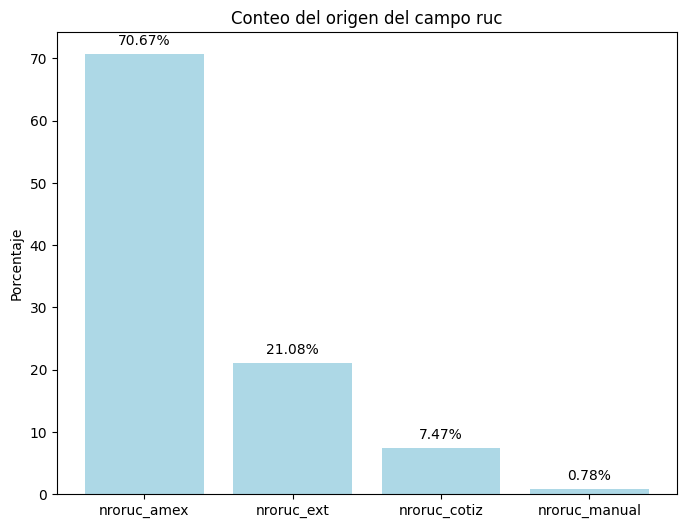

In [430]:
df_otros = df[(df['compania'] == 'OTROS') & (df['en_izi'] == '0')]
counts = df_otros['nroruc_origen'].value_counts(normalize=True) * 100
# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(counts.index, counts.values, color='lightblue')

# Agregar etiquetas de datos (porcentajes) en cada barra
for i, v in enumerate(counts):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

# Personalizar el gráfico
ax.set_title('Conteo del origen del campo ruc')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')

# Mostrar el gráfico
plt.show()

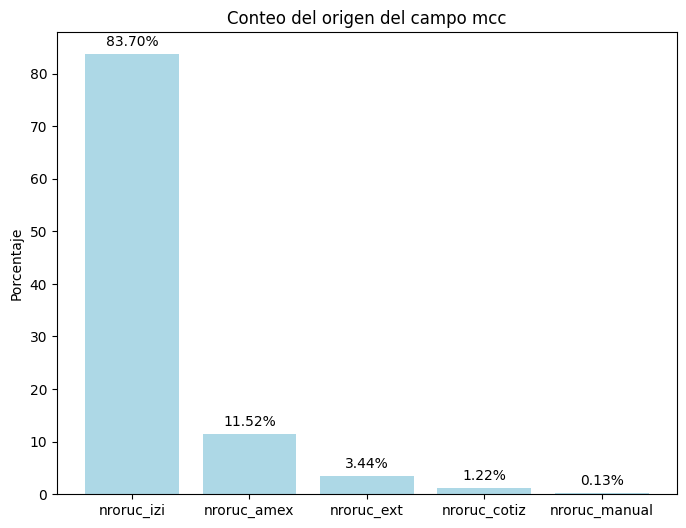

In [431]:
counts = df['nroruc_origen'].value_counts(normalize=True) * 100
# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(counts.index, counts.values, color='lightblue')

# Agregar etiquetas de datos (porcentajes) en cada barra
for i, v in enumerate(counts):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

# Personalizar el gráfico
ax.set_title('Conteo del origen del campo mcc')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')

# Mostrar el gráfico
plt.show()

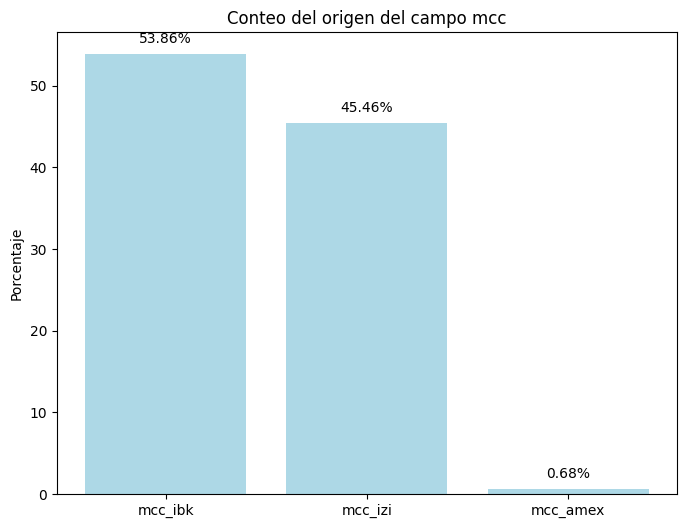

In [432]:
counts = df['mcc_origen'].value_counts(normalize=True) * 100
# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(counts.index, counts.values, color='lightblue')

# Agregar etiquetas de datos (porcentajes) en cada barra
for i, v in enumerate(counts):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

# Personalizar el gráfico
ax.set_title('Conteo del origen del campo mcc')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')

# Mostrar el gráfico
plt.show()

In [433]:
print(ibk[['codigo', 'bolsa']].drop_duplicates().shape)

(348552, 2)


In [434]:
print(ibk[['codigo', 'bolsa']].drop_duplicates().codigo.nunique())

348551


In [435]:
df.shape

(433373, 52)

In [436]:
df.codigo.nunique()

433369

In [437]:
df = df.merge(ibk[['codigo', 'bolsa']].drop_duplicates(), on='codigo', how='left')
df.shape

(433373, 53)

In [438]:
temp = ibk[['codigo', 'bolsa']].drop_duplicates()

In [439]:
temp.shape

(348552, 2)

In [440]:
temp.nunique()

,0
codigo,348551
bolsa,1272


In [441]:
temp.sort_values(by='codigo', inplace=True)

In [442]:
temp[temp.duplicated(subset='codigo', keep=False)]

,codigo,bolsa


In [443]:
df['detalle_compania'] = np.where(df['facilitador'].isin(['VM','VD','VD+']),'VENDEMAS',
                                    np.where(df['facilitador'].isin(['CULQI','FPCULQI']),'CULQI',
                                        np.where(df['facilitador'].isin(['OP','OPE']),'OPENPAY',
                                            np.where(df['facilitador'].isin(['MPAGO']),'MERCADOPAGO',
                                                # np.where((df.nroruc.str.contains('20555530090')),'CULQI',
                                                    # np.where((df.nroruc.str.contains('20607489433')),'OPENPAY',
                                                        np.where((df.compania == 'OTROS')&(df.en_izi == 1),'VENDEMAS',
                                                            # np.where((df['nroruc'].str.contains('20610868577')),'MERCADOPAGO',
                                                                np.where((df.compania == 'OTROS'),'ND','IZIPAY'
                                                                            )
                                                                        # )
                                                                    )
                                                                # )
                                                            # )
                                                        )
                                                    )
                                               )
                                           )

In [444]:
df.codigo.nunique()

433369

In [445]:
df.nroruc.nunique()

154236

In [446]:
#df.drop_duplicates(inplace=True)

In [447]:
#df.to_csv('tmp/df_complete1_PRO.csv', index=False, sep='|')
#df= pd.read_csv('tmp/df_complete.csv',encoding='utf-8',sep = '|',dtype = 'string')

In [448]:
df.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'nroruc_izi',
       'nroruc_amex', 'nroruc_ext', 'nroruc_manual', 'nroruc_cotiz', 'nroruc',
       'nroruc_origen', 'greco', 'nroruc_real', 'cartera_izi',
       'cartera_ibk_nroruc', 'cartera_ibk_codigo', 'cartera_amex_nroruc',
       'cartera_amex_codigo', 'cartera', 'cartera_origen', 'tipoproducto_izi',
       'tipoproducto_ibk', 'tipoproducto', 'tipoproducto_origen', 'mcc_izi',
       'mcc_ibk', 'mcc_amex', 'mcc', 'mcc_origen', 'giro', 'vertical',
       'compania', 'dpto_izi', 'dpto_ibk', 'dpto', 'dpto_origen', 'razsoc_izi',
       'razsoc_scrapper', 'razsoc_manual', 'razsoc', 'razsoc_origen',
       'nombrecomercial_izi', 'nombrecomercial_ibk', 'nombrecomercial_amex',
       'nombrecomercial', 'nombrecomercial_origen', 'facilitador_izi',
       'facilitador_ibk', 'facilitador_amex', 'facilitador',
       'facilitador_origen', 'bolsa', 'detalle_compania'],
      dtype='object')

In [449]:
# se seleccionan unas columnas

columns_list = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc', 'razsoc', 'nombrecomercial', 'cartera',
               'tipoproducto', 'compania', 'dpto', 'mcc', 'giro', 'vertical','bolsa','facilitador','detalle_compania']

df = df[columns_list].copy()
df

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,2267144,1,1,0,1213,AEROMEXICO,20307246741,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROMEXICO IATA,BC,Fisico,PMP,LIMA,3076,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NA,IZIPAY
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,CASSINELLI,20466776336,CENTRO CERAMICO LAS FLORES SAC,HIPERMERCADO CERAMICO,BC,Fisico,PMP,LIMA,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY
2,6079852,1,1,0,111111111111,E S GESA,20100935032,INKA S RENT A CAR S A,HERTZ,BE,Fisico,PMP,LIMA,3357,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,NaN,NA,IZIPAY
3,8963437,1,0,0,0,NaN,20605282076,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,BPE,Fisico,IZIPAY,SAN MARTIN,8071,Laboratorios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
4,1038068,1,1,0,1112111112,MOVISTAR,20100017491,INTEGRATEL PERU S A A,MOVISTAR PGRECIBO CORP SIC,BC,Fisico,PMP,LIMA,4900,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NA,IZIPAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,6177335,0,0,1,0,CONCEJO DISTRITAL DE COMAS,20168737565,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
433369,6152743,0,0,1,0,CGT,20479801275,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
433370,6083969,0,0,1,0,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,MUNICIPALIDAD DISTRITRAL DE CERRO AZUL,MUNI CERRO AZUL,RETAIL,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
433371,6270417,0,0,1,0,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,MUNI CERRO AZUL,RETAIL,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND


In [450]:
df.isna().sum()

,0
codigo,4
en_izi,0
en_ibk,0
en_amex,0
trx,0
greco,388023
nroruc,197986
razsoc,221842
nombrecomercial,0
cartera,4


In [451]:
df.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,2267144,1,1,0,1213,AEROMEXICO,20307246741,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROMEXICO IATA,BC,Fisico,PMP,LIMA,3076,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NA,IZIPAY
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,CASSINELLI,20466776336,CENTRO CERAMICO LAS FLORES SAC,HIPERMERCADO CERAMICO,BC,Fisico,PMP,LIMA,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY
2,6079852,1,1,0,111111111111,E S GESA,20100935032,INKA S RENT A CAR S A,HERTZ,BE,Fisico,PMP,LIMA,3357,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,NaN,NA,IZIPAY
3,8963437,1,0,0,0,NaN,20605282076,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,BPE,Fisico,IZIPAY,SAN MARTIN,8071,Laboratorios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
4,1038068,1,1,0,1112111112,MOVISTAR,20100017491,INTEGRATEL PERU S A A,MOVISTAR PGRECIBO CORP SIC,BC,Fisico,PMP,LIMA,4900,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NA,IZIPAY


In [452]:
df.dtypes

,0
codigo,object
en_izi,object
en_ibk,object
en_amex,object
trx,object
greco,object
nroruc,object
razsoc,object
nombrecomercial,object
cartera,object


In [453]:
df_bq = df.copy()

In [454]:
df_bq = df_bq.astype(str)

In [455]:
# df_bq.to_gbq(destination_table='pxc.tablon',
#           project_id='dev-izipay-data-storage',
#           if_exists='replace')  # Opciones: 'fail', 'replace', 'append'

# Homologacion Bases Transaccional

In [456]:
duplicados = df[df.duplicated(keep=False)]

# Mostrar los duplicados
duplicados

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,NaN,NaN,NaN,NaN,PAYVALIDA,ND
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,NaN,NaN,NaN,NaN,PAYVAPE,ND
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,NaN,NaN,NaN,NaN,PAYVALIDA,ND
259301,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,NaN,NaN,NaN,NaN,PAYVAPE,ND


In [457]:
izi = izi[['periodo', 'codigo', 'tipotarjeta', 'emisor', 'marca', 'banco', 'onus', 'monto']].copy()
izi = izi.merge(df, on='codigo', how='left')
izi

,periodo,codigo,tipotarjeta,emisor,marca,banco,onus,monto,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,202606,2267144,Crédito,Internacional,Amex,OTROS,-,132504.89,1,1,0,1213,AEROMEXICO,20307246741,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROMEXICO IATA,BC,Fisico,PMP,LIMA,3076,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NA,IZIPAY
1,202606,1559621,Crédito,Local,Mastercard,OTROS,-,402.44,1,1,0,2111111111221141112112112332111111221311121111...,CASSINELLI,20466776336,CENTRO CERAMICO LAS FLORES SAC,HIPERMERCADO CERAMICO,BC,Fisico,PMP,LIMA,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY
2,202606,6079852,Crédito,Internacional,Visa,OTROS,-,17009.77,1,1,0,111111111111,E S GESA,20100935032,INKA S RENT A CAR S A,HERTZ,BE,Fisico,PMP,LIMA,3357,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,NaN,NA,IZIPAY
3,202606,8963437,Débito,Local,Mastercard,OTROS,-,60.00,1,0,0,0,NaN,20605282076,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,BPE,Fisico,IZIPAY,SAN MARTIN,8071,Laboratorios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
4,202606,1038068,Débito,Local,Visa,OTROS,-,98.30,1,1,0,1112111112,MOVISTAR,20100017491,INTEGRATEL PERU S A A,MOVISTAR PGRECIBO CORP SIC,BC,Fisico,PMP,LIMA,4900,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NA,IZIPAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997271,202606,1049084,Crédito,Local,Visa,IBK,-,6775.48,1,1,0,1112111211111121121211113121122141131111111111...,BATA,20101951872,EMPRESAS COMERCIALES S A Y O EMCOMER S A,50515 B2 CHIMBOTE,BC,Fisico,PMP,ANCASH,5661,Zapaterias,GRUPO 2 - ROPA / ACCESORIOS,NaN,NA,IZIPAY
1997272,202606,1803816,Débito,Local,Visa,OTROS,-,1553.30,1,1,0,1113111112121211112132342113223122321111111111...,TRIATHLON,20417531026,TRIATHLON S A C,46 MEGAPLAZA 1,BC,Fisico,PMP,LIMA,5661,Zapaterias,GRUPO 2 - ROPA / ACCESORIOS,NaN,NA,IZIPAY
1997273,202606,5896972,Crédito,Local,Visa,IBK,-,500.00,1,1,0,1,NaN,74743582,MONTOYA ROJAS CESAR GONZALO,SNEAKERS SPA BY GONZA,RETAIL,Virtual,IZIPAY,LIMA,5661,Zapaterias,GRUPO 2 - ROPA / ACCESORIOS,NaN,IZI,IZIPAY
1997274,202606,1049036,Crédito,Local,Visa,OTROS,-,10589.54,1,1,0,1111111111121111231111131111311111221111112111...,BATA,20101951872,EMPRESAS COMERCIALES S A Y O EMCOMER S A,50201 NS PLAZA NORTE,BC,Fisico,PMP,LIMA,5661,Zapaterias,GRUPO 2 - ROPA / ACCESORIOS,NaN,NA,IZIPAY


In [458]:
amex = amex[['periodo', 'codigo', 'banco', 'monto']].copy()
amex = amex.merge(df, on='codigo', how='left')
amex

,periodo,codigo,banco,monto,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,202606,6457646,OTROS,282.10,0,1,1,1111,NaN,20563788713,NaN,BISSU,NEG,Fisico,OTROS,AREQUIPA,5631,"Ropa mujeres, lenceria, ropa interior",GRUPO 2 - ROPA / ACCESORIOS,NaN,NIUBIZ-AX,ND
1,202606,6580088,OTROS,59.00,0,1,1,111111,GRUPO COMERCIALIZADOR DE FLORE,20507795642,NaN,SAN MIGUEL,NEG,Fisico,OTROS,LIMA,5261,Viveros,GRUPO 6 - SERVICIOS / AUTOS,NaN,NIUBIZ-AX,ND
2,202606,6535209,Interbank,1280.00,0,1,1,21,OPTICA JVQ,20517261387,NaN,OPTICAS JVQ,RETAIL,Fisico,OTROS,LIMA,8043,Opticas,GRUPO 4 - SALUD,NaN,OPEN-AX,ND
3,202606,6047107,OTROS,1264.20,0,1,1,111111124111,CONVET,20602313906,CORPORACION FARMACEUTICA VETERINARIA SAC,CONSORCIO VETERINARIO,NEG,Fisico,OTROS,LIMA,5995,Mascotas y accesorios,GRUPO 2 - ROPA / ACCESORIOS,NaN,NIUBIZ-AX,ND
4,202606,6515388,Interbank,305.00,0,1,1,11,NaN,20521128187,NaN,BONANZA HUARAL,NEG,Fisico,OTROS,LIMA,7392,ConsultorÃ­a de gestiÃ³n y servicios de relaci...,GRUPO 6 - SERVICIOS / AUTOS,NaN,NIUBIZ-AX,ND
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43796,202606,6396740,OTROS,588.10,0,1,1,111212111,MUNICIPALIDAD PUENTE PIEDRA,20131366702,NaN,MUNI PTE PIEDRA COBRANZA DOMICILIO,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
43797,202606,6131004,OTROS,11858.98,0,1,1,1,BANCO DE LA NACION,20100030595,BANCO DE LA NACION,BANCO DE LA NACION AG DL,CORP,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
43798,202606,6406633,Interbank,13168.40,0,1,1,11111211111111,MUNICIPALIDAD DIST SN JUAN DE MIRAFLORES,20131378204,MUNICIPALIDAD DIST SN JUAN DE MIRAFLORES,ARBITRIOS Y TASAS,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND
43799,202606,6554595,OTROS,4460.60,0,1,1,11112,NaN,20285139415,NaN,OFICINA REGISTRAL DE TARAPOTO,RETAIL,Fisico,OTROS,SAN MARTIN,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND


In [459]:
ibk['periodo'] = periodo
ibk = ibk[['periodo', 'codigo', 'tipotarjeta', 'marca', 'monto']].copy()
ibk = ibk.merge(df, on='codigo', how='left')
ibk

,periodo,codigo,tipotarjeta,marca,monto,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,202606,5717284,TC,Visa,78.00,1,1,0,212,NaN,20535060976,AGRO VET Y SERVICIOS ICA E I R L,AGRO VET,BPE,Fisico,IZIPAY,ICA,0742,Servicios veterinarios,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
1,202606,5851646,TC,Visa,5.00,1,1,0,1111,NaN,20606366966,AGRO VETERINARIA MI CAMPO EMPRESA INDIVIDUAL D...,AGRO VETERINARIA MI CAMPO,BE,Fisico,IZIPAY,UCAYALI,0742,Servicios veterinarios,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
2,202606,5852292,TC,Visa,232.00,1,1,0,1111111,NaN,20540058572,AGROINVERSIONES AMERICA S A C,AMERICA SAC,BPE,Fisico,IZIPAY,LA LIBERTAD,0742,Servicios veterinarios,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
3,202606,5957887,TC,Visa,55.00,1,1,0,11,NaN,43320952,Joel Cieza Estela,ANIMAL CARE SAN JUAN,RETAIL,Fisico,IZIPAY,LORETO,0742,Servicios veterinarios,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
4,202606,5934496,TC,Visa,40.00,1,1,0,1112111311111111111,NaN,10733348874,Ocampo Tananta Maria Mercedes,ANIMAL GLAMZ,BPE,Fisico,IZIPAY,LIMA,0742,Servicios veterinarios,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411774,202606,999999_ZARA 2 4,TC,Visa,1905.74,0,1,0,1,NaN,NaN,NaN,ARA 2 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND
1411775,202606,999999_ZONA 31 19 3,TC,Visa,105.64,0,1,0,2,NaN,NaN,NaN,ONA 31 19 3,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND
1411776,202606,999999_ZONA 31 25 4,TC,Visa,47.47,0,1,0,1,NaN,NaN,NaN,ONA 31 25 4,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND
1411777,202606,999999_ZONA 31 26 4,TC,Visa,64.16,0,1,0,1,NaN,NaN,NaN,ONA 31 26 4,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND


# Creación llaves

In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433373 entries, 0 to 433372
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   codigo            433369 non-null  object
 1   en_izi            433373 non-null  object
 2   en_ibk            433373 non-null  object
 3   en_amex           433373 non-null  object
 4   trx               433373 non-null  object
 5   greco             45350 non-null   object
 6   nroruc            235387 non-null  object
 7   razsoc            211531 non-null  object
 8   nombrecomercial   433373 non-null  object
 9   cartera           433369 non-null  object
 10  tipoproducto      433373 non-null  object
 11  compania          433373 non-null  object
 12  dpto              433373 non-null  object
 13  mcc               433369 non-null  object
 14  giro              414623 non-null  object
 15  vertical          414623 non-null  object
 16  bolsa             115774 non-null  obj

In [461]:
df['mcc'] = df['mcc'].astype(str)

In [462]:
df['llave1'] = df['nroruc'] + df['tipoproducto'] + df['mcc'] + df['dpto']
df['llave2'] = df['cartera'] + df['tipoproducto'] + df['mcc'] + df['dpto']
df['llave3'] = df['codigo'] + df['tipoproducto'] + df['mcc'] + df['dpto']
df

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3
0,2267144,1,1,0,1213,AEROMEXICO,20307246741,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROMEXICO IATA,BC,Fisico,PMP,LIMA,3076,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NA,IZIPAY,20307246741Fisico3076LIMA,BCFisico3076LIMA,2267144Fisico3076LIMA
1,1559621,1,1,0,2111111111221141112112112332111111221311121111...,CASSINELLI,20466776336,CENTRO CERAMICO LAS FLORES SAC,HIPERMERCADO CERAMICO,BC,Fisico,PMP,LIMA,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY,20466776336Fisico5039LIMA,BCFisico5039LIMA,1559621Fisico5039LIMA
2,6079852,1,1,0,111111111111,E S GESA,20100935032,INKA S RENT A CAR S A,HERTZ,BE,Fisico,PMP,LIMA,3357,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,NaN,NA,IZIPAY,20100935032Fisico3357LIMA,BEFisico3357LIMA,6079852Fisico3357LIMA
3,8963437,1,0,0,0,NaN,20605282076,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,BPE,Fisico,IZIPAY,SAN MARTIN,8071,Laboratorios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY,20605282076Fisico8071SAN MARTIN,BPEFisico8071SAN MARTIN,8963437Fisico8071SAN MARTIN
4,1038068,1,1,0,1112111112,MOVISTAR,20100017491,INTEGRATEL PERU S A A,MOVISTAR PGRECIBO CORP SIC,BC,Fisico,PMP,LIMA,4900,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NA,IZIPAY,20100017491Fisico4900LIMA,BCFisico4900LIMA,1038068Fisico4900LIMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,6177335,0,0,1,0,CONCEJO DISTRITAL DE COMAS,20168737565,CONCEJO DISTRITAL DE COMAS,CONCEJO DISTRITAL DE COMAS,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND,20168737565Fisico9311LIMA,NEGFisico9311LIMA,6177335Fisico9311LIMA
433369,6152743,0,0,1,0,CGT,20479801275,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,CENTRO DE GESTION TRIBUTARIA DE CHICLAYO,NEG,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND,20479801275Fisico9311LIMA,NEGFisico9311LIMA,6152743Fisico9311LIMA
433370,6083969,0,0,1,0,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,MUNICIPALIDAD DISTRITRAL DE CERRO AZUL,MUNI CERRO AZUL,RETAIL,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND,20160852195Fisico9311LIMA,RETAILFisico9311LIMA,6083969Fisico9311LIMA
433371,6270417,0,0,1,0,MUNICIPALIDAD DISTRITAL DE CERRO AZUL,20160852195,NaN,MUNI CERRO AZUL,RETAIL,Fisico,OTROS,LIMA,9311,"Municipalidades, tributos",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NIUBIZ-AX,ND,20160852195Fisico9311LIMA,RETAILFisico9311LIMA,6270417Fisico9311LIMA


In [463]:
# control de calidad: el número de códigos únicos debe corresponder a el número de registros de df
df.codigo.nunique()

433369

In [464]:
df.sort_values(by='codigo', inplace=True)

In [465]:
# cuales son los códigos de comercios repetidos en la tabla final, si es que hay?
df[df.duplicated(subset='codigo', keep=False)]

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN
259301,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN


In [466]:
df.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None


In [467]:
# df.to_gbq(destination_table='pxc.llaves',
#           project_id='dev-izipay-data-storage',
#           if_exists='replace')  # Opciones: 'fail', 'replace', 'append'

# Bases Transaccionales (12) <a class="anchor" id="chapter4"></a>

## Amex

### Base Amex local <a id="section_4_1"></a>

In [468]:
amexloc = df.copy()
amexloc['tarjeta'] = 'TC'
amexloc['marca'] = 'Amex'
amexloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Amex
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Amex
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Amex
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Amex
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Amex
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Amex
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Amex
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex


In [469]:
temp = ibk.query('marca=="Amex"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Data IBK'}, inplace=True)
#amexloc = amexloc.merge(temp, on='codigo', how='left')
amexloc = amexloc.merge(temp, on=['codigo'], how='left')
amexloc['Importe Data IBK'].replace(np.nan, 0, inplace=True)
amexloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Amex,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Amex,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Amex,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Amex,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Amex,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Amex,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Amex,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00


In [470]:
amexloc['Importe Data IBK'].sum()

np.float64(318867944.53559995)

In [471]:
ibk.query('marca=="Amex"')['monto'].sum()

np.float64(318867944.53560007)

In [472]:
# Importe Data Amex
temp = amex.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Data Amex'}, inplace=True)
amexloc = amexloc.merge(temp, on='codigo', how='left')
amexloc['Importe Data Amex'].replace(np.nan, 0, inplace=True)
amexloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Amex,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Amex,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Amex,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Amex,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Amex,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Amex,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00


In [473]:
amexloc['Importe Data Amex'].sum()

np.float64(163099607.28000292)

In [474]:
amex['monto'].sum()

np.float64(163099607.28000298)

In [475]:
# Importe Total Izipay
temp = izi.query('marca=="Amex"').query('emisor=="Local" | emisor=="Otros" | emisor.isna()')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
amexloc = amexloc.merge(temp, on='codigo', how='left')
amexloc['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
amexloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Amex,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Amex,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Amex,0.00,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Amex,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Amex,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Amex,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00


In [476]:
amexloc['Importe Total Izipay'].sum()

np.float64(272401733.7899998)

In [477]:
izi.query('marca=="Amex"').query('emisor=="Local" | emisor=="Otros" | emisor.isna()')['monto'].sum()

np.float64(272401733.7899999)

In [478]:
# Importe IBK en Izipay
temp = izi.query('marca=="Amex"').query('emisor=="Local" | emisor=="Otros" | emisor.isna()').query('banco=="IBK"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe IBK en Izipay'}, inplace=True)
amexloc = amexloc.merge(temp, on='codigo', how='left')
amexloc['Importe IBK en Izipay'].replace(np.nan, 0, inplace=True)
amexloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Amex,0.00,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Amex,0.00,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Amex,0.00,0.00,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Amex,0.00,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Amex,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Amex,0.00,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Amex,0.00,0.00,0.00,0.00


In [479]:
izi.query('marca=="Amex"').query('emisor=="Local" | emisor=="Otros" | emisor.isna()').query('banco=="IBK"')['monto'].sum()

np.float64(196483651.34999982)

In [480]:
amexloc['Importe IBK en Izipay'].sum()

np.float64(196483651.3499999)

In [481]:
# Importe IBK en Enrut
amexloc['Importe IBK en Enrut'] = 0

In [482]:
# Importe Total Izipay S/OnUs
amexloc['Importe Total Izipay S/OnUs'] = 0

In [483]:
# Importe IBK en Izipay S/OnUs
amexloc['Importe IBK en Izipay S/OnUs'] = 0

Ratio IBK en IZIPAY

El ratio IBK en Izipay de amex local es el resultado de la división entre el importe IBK en Izipay y el importe total en Izipay.  El ratio da el porcentaje de los pagos a Izipay que se han hecho con tarjetas de IBK sobre tarjetas locales y de Amex

In [484]:
# Ratio IBK en IZIPAY
def ratioibkenizi(ibkenizi, totalizi):
    try:
        result = ibkenizi / totalizi
    except ZeroDivisionError:
        result = 0
    return result

amexloc['Ratio IBK en IZIPAY'] = amexloc.apply(lambda x: ratioibkenizi(x['Importe IBK en Izipay'], x['Importe Total Izipay']), axis=1)

In [485]:
amexloc['Ratio IBK en IZIPAY'].isna().sum()

np.int64(0)

In [486]:
print(amexloc['Ratio IBK en IZIPAY'].min(), amexloc['Ratio IBK en IZIPAY'].max())

0.0 1.0


<Axes: ylabel='Frequency'>

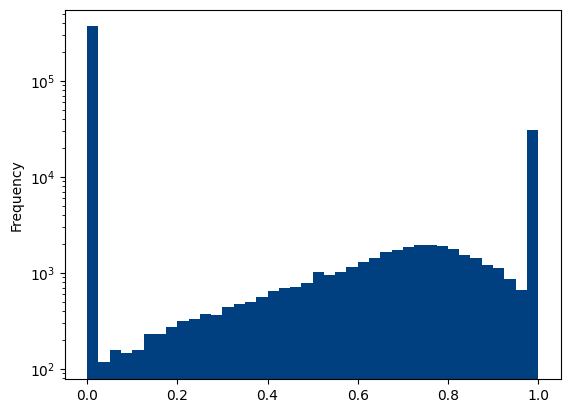

In [487]:
amexloc['Ratio IBK en IZIPAY'].plot(kind='hist', bins=40, log=True)

In [488]:
amexloc.isna().sum()

,0
codigo,4
en_izi,0
en_ibk,0
en_amex,0
trx,0
greco,388023
nroruc,197986
razsoc,221842
nombrecomercial,0
cartera,4


In [489]:
# Ratio IBK en Enrut
def divisioncero(parte, total):
    try:
        result = parte / total
    except ZeroDivisionError:
        result = 0
    return result

amexloc['Ratio IBK en Enrut'] = amexloc.apply(lambda x: divisioncero(x['Importe IBK en Enrut'], x['Importe Data Amex']), axis=1)

In [490]:
# Ratio IBK en IZIPAY S/OnUs
amexloc['Ratio IBK en IZIPAY S/OnUs'] = 0

Mercado estimado inicial

In [491]:
# # Mercado estimado inicial
# amexloc['Mercado estimado inicial'] = amexloc.apply(lambda x: x['Importe Data Amex'] if x['Importe Data Amex'] != 0 else x['Importe Total Izipay'], axis=1)

In [492]:
# 1 Lógica original: prioriza Data Amex, luego Total Izipay
amexloc['Mercado estimado inicial'] = amexloc.apply(
    lambda x: x['Importe Data Amex'] if x['Importe Data Amex'] != 0 else x['Importe Total Izipay'],
    axis=1
)

# 2 Ajuste puntual: si IBK > Amex y el comercio está en ambos bancos, usa el volumen IBK
amexloc.loc[
    (amexloc['en_amex'] == "1") &
    (amexloc['en_ibk'] == "1") &
    (amexloc['Importe Data IBK'] > amexloc['Importe Data Amex']),
    'Mercado estimado inicial'
] = amexloc['Importe Data IBK']

# 3  Parche MEF – si el comercio está en Izipay e IBK, MEF está en 0
#     y hay volumen positivo en IBK, usa ese volumen como MEF
mask_mef = (
    (amexloc["Importe Data IBK"] > 0) &
    (amexloc["en_izi"] == "1") &
    (amexloc["en_ibk"] == "1") &
    (amexloc["Importe Data Amex"] == 0) &
    (amexloc["Importe Total Izipay"] == 0)
)

amexloc.loc[mask_mef, "Mercado estimado inicial"] = amexloc.loc[mask_mef, "Importe Data IBK"]


Mercado estimado final

In [493]:
amexloc.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'razsoc', 'nombrecomercial', 'cartera', 'tipoproducto', 'compania',
       'dpto', 'mcc', 'giro', 'vertical', 'bolsa', 'facilitador',
       'detalle_compania', 'llave1', 'llave2', 'llave3', 'tarjeta', 'marca',
       'Importe Data IBK', 'Importe Data Amex', 'Importe Total Izipay',
       'Importe IBK en Izipay', 'Importe IBK en Enrut',
       'Importe Total Izipay S/OnUs', 'Importe IBK en Izipay S/OnUs',
       'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial'],
      dtype='object')

In [494]:
# Mercado estimado final
amexloc['Mercado estimado final'] = amexloc['Mercado estimado inicial']#.abs()

In [495]:
print(amexloc.shape, amexloc.codigo.nunique())

(433373, 36) 433369


In [496]:
amexloc = amexloc.loc[~amexloc.duplicated(subset = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical', 'bolsa', 'facilitador', 'detalle_compania',
       'llave1', 'llave2', 'llave3', 'tarjeta', 'marca', 'Importe Data IBK',
       'Importe Data Amex', 'Importe Total Izipay', 'Importe IBK en Izipay',
       'Importe IBK en Enrut', 'Importe Total Izipay S/OnUs',
       'Importe IBK en Izipay S/OnUs',
       'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],keep = 'last')]

In [497]:
amexloc['Mercado estimado final'].sum() # 364156658.9105101 de 202306

np.float64(440240237.3044029)

### Base Amex internacional <a id="section_4_2"></a>

In [498]:
amexint = df.copy()
amexint['tarjeta'] = 'F'
amexint['marca'] = 'Amex'
amexint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Amex
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Amex
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Amex
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Amex
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Amex
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Amex
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Amex
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Amex
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Amex


In [499]:
# Importe Data IBK
amexint['Importe Data IBK'] = 0

In [500]:
# Importe Data Amex
amexint['Importe Data Amex'] = 0

In [501]:
# Importe Total Izipay
temp = izi.query('marca=="Amex"').query('emisor=="Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
amexint = amexint.merge(temp, on='codigo', how='left')
amexint['Importe Total Izipay'].replace(np.nan, 0, inplace=True)

amexint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Amex,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Amex,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Amex,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Amex,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Amex,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Amex,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Amex,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Amex,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Amex,0,0,0.00


In [502]:
# Importe IBK en Izipay
amexint['Importe IBK en Izipay'] = 0

In [503]:
# Importe IBK en Enrut
amexint['Importe IBK en Enrut'] = 0

In [504]:
# Importe Total Izipay S/OnUs
amexint['Importe Total Izipay S/OnUs'] = 0

In [505]:
# Importe IBK en Izipay S/OnUs
amexint['Importe IBK en Izipay S/OnUs'] = 0

In [506]:
# Ratio IBK en IZIPAY
def ratioibkenizi(ibkenizi, totalizi):
    try:
        result = ibkenizi / totalizi
    except ZeroDivisionError:
        result = 0
    return result

amexint['Ratio IBK en IZIPAY'] = amexint.apply(lambda x: ratioibkenizi(x['Importe IBK en Izipay'], x['Importe Total Izipay']), axis=1)

In [507]:
# Ratio IBK en Enrut
def divisioncero(parte, total):
    try:
        result = parte / total
    except ZeroDivisionError:
        result = 0
    return result

amexint['Ratio IBK en Enrut'] = amexint.apply(lambda x: divisioncero(x['Importe IBK en Enrut'], x['Importe Data Amex']), axis=1)

In [508]:
# Ratio IBK en IZIPAY S/OnUs
amexint['Ratio IBK en IZIPAY S/OnUs'] = 0

In [509]:
# Mercado estimado inicial
amexint['Mercado estimado inicial'] = amexint.apply(lambda x: x['Importe Data Amex'] if x['Importe Data Amex'] != 0 else x['Importe Total Izipay'], axis=1)

In [510]:
amexint.loc[amexint['codigo']=='6056758']

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial


In [511]:
# Mercado estimado final
amexint['Mercado estimado final'] = amexint['Mercado estimado inicial']

In [512]:
print(amexint.shape, amexint.codigo.nunique())

(433373, 36) 433369


In [513]:
amexint['Importe Total Izipay'].sum()

np.float64(71211785.73)

In [514]:
izi.query('marca=="Amex"').query('emisor!="Local" & emisor!="Otros" & ~emisor.isna()')['monto'].sum()

np.float64(71211785.72999999)

In [515]:
amexint['Mercado estimado final'].sum() # 68137612.80 de 202306

np.float64(71211785.73)

## Bases de Visa

### Base Visa débito <a id="section_4_3"></a>

In [516]:
# campos artificiales
ratio_minimo_visa = 0.0038
visadeb = df.copy()
visadeb['tarjeta'] = 'TD'
visadeb['marca'] = 'Visa'
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa


In [517]:
# Importe Data IBK
temp = ibk.query('marca=="Visa"').query('tipotarjeta=="TD"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Data IBK'}, inplace=True)
visadeb = visadeb.merge(temp, on='codigo', how='left')
visadeb['Importe Data IBK'].replace(np.nan, 0, inplace=True)
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00


In [518]:
ibk.query('marca=="Visa"').query('tipotarjeta=="TD"')['monto'].sum()

np.float64(701329517.3882002)

In [519]:
visadeb['Importe Data IBK'].sum()

np.float64(701301945.7882)

In [520]:
visadeb.loc[visadeb['codigo'].duplicated()]['Importe Data IBK'].sum()

np.float64(0.0)

In [521]:
# Importe Data Amex
visadeb['Importe Data Amex'] = 0

In [522]:
# Importe Total Izipay
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
visadeb = visadeb.merge(temp, on='codigo', how='left')
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN


In [523]:
izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"')['monto'].sum()

np.float64(3566197792.1699734)

In [524]:
izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"')['monto'].sum()

np.float64(3508917648.2999754)

In [525]:
visadeb['Importe Total Izipay'].sum()

np.float64(3508917648.2999725)

In [526]:
# Importe IBK en Izipay
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('banco=="IBK"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe IBK en Izipay'}, inplace=True)
visadeb = visadeb.merge(temp, on='codigo', how='left')
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN


In [527]:
visadeb['Importe IBK en Izipay'].sum()

np.float64(432372534.97999936)

In [528]:
izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('banco=="IBK"')['monto'].sum()

np.float64(432372534.97999936)

In [529]:
# Importe IBK en Enrut
visadeb['Importe IBK en Enrut'] = 0

In [530]:
# Importe Total Izipay S/OnUs
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"').query('onus!="On us"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay S/OnUs'}, inplace=True)
visadeb = visadeb.merge(temp, on='codigo', how='left')
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN


In [531]:
visadeb['Importe Total Izipay S/OnUs'].sum()

np.float64(3508917648.2999725)

In [532]:
izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('onus!="On us"')['monto'].sum()

np.float64(3566197792.1699734)

In [533]:
# Importe IBK en Izipay S/OnUs
visadeb['Importe IBK en Izipay S/OnUs'] = 0

In [534]:
# Ratio IBK en IZIPAY
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"')
# agrupación de datos
ratioibkdfito_llave1 = temp.groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()
# formación de la llave
ratioibkdfito_llave1['llave1'] = ratioibkdfito_llave1['nroruc'] + ratioibkdfito_llave1['tipoproducto'] + ratioibkdfito_llave1['mcc'] + ratioibkdfito_llave1['dpto']
ratioibkdfito_llave1.drop(columns=['nroruc', 'tipoproducto', 'mcc', 'dpto'], inplace=True)
ratioibkdfito_llave1 = pd.pivot_table(ratioibkdfito_llave1, index='llave1', columns='banco', values='monto').reset_index()
ratioibkdfito_llave1['total'] = ratioibkdfito_llave1['IBK'] + ratioibkdfito_llave1['OTROS']
ratioibkdfito_llave1['ratioibkllave1'] = ratioibkdfito_llave1['IBK'] / ratioibkdfito_llave1['total']

# calculo del ratio general
ratio = ratioibkdfito_llave1['IBK'].sum() / ratioibkdfito_llave1['total'].sum()
print(ratio)

ratio_q15 = ratioibkdfito_llave1.loc[ratioibkdfito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.15)

print(ratio_q15)

ratio_q10 = ratioibkdfito_llave1.loc[ratioibkdfito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratioibkdfito_llave1['ratioibkllave1'] = ratioibkdfito_llave1.apply(lambda x: ratio_q10 if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
ratioibkdfito_llave1['ratioibkllave1'] = ratioibkdfito_llave1.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
ratioibkdfito_llave1.replace(np.nan, 0, inplace=True)
ratioibkdfito_llave1

0.12609798186494492
0.045090521312650345
0.02104835870194811


banco,llave1,IBK,OTROS,total,ratioibkllave1
0,10000108338Fisico5451UCAYALI,775.50,10203.10,10978.60,0.07
1,10000111959Fisico7230UCAYALI,0.00,188.00,0.00,0.00
2,10000201168Fisico5812UCAYALI,0.00,78.00,0.00,0.00
3,10000220804Fisico5947UCAYALI,0.00,0.10,0.00,0.00
4,10000276389Fisico5812UCAYALI,0.00,54.00,0.00,0.00
...,...,...,...,...,...
97873,9989627Fisico5199LIMA,23.10,190.60,213.70,0.11
97874,9993209Fisico5331LIMA,0.00,50.00,0.00,0.00
97875,9994033Virtual5499LIMA,0.00,43.50,0.00,0.00
97876,9995282Fisico5651LIMA,477.00,4473.00,4950.00,0.10


In [535]:
ratioibkdfito_llave1.loc[ratioibkdfito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.15)

np.float64(0.045090521312650345)

In [536]:
# debería tener el mismo número de lineas que ratioibkdfito_llave1
temp.drop_duplicates(subset=['nroruc', 'tipoproducto', 'mcc', 'dpto']).shape

(97878, 26)

In [537]:
ratioibkdfito_llave1.sort_values(by='ratioibkllave1')

banco,llave1,IBK,OTROS,total,ratioibkllave1
70267,20610385789Fisico8021SAN MARTIN,0.00,420.00,0.00,0.00
34480,10704710700Fisico5621LA LIBERTAD,0.00,148.00,0.00,0.00
34484,10704732321Fisico5722LIMA,0.00,1078.90,0.00,0.00
34485,10704746020Fisico5947LIMA,0.00,46.00,0.00,0.00
34487,10704750329Fisico5172LIMA,0.00,122.00,0.00,0.00
...,...,...,...,...,...
90246,6654622Virtual7230LIMA,6429.56,1.00,6430.56,1.00
87723,4702060Virtual4215LIMA,7765.46,1.00,7766.46,1.00
75726,20613172085Fisico5699LIMA,8196.13,1.00,8197.13,1.00
24330,10449222399Fisico5712LIMA,4358.00,0.50,4358.50,1.00


<Axes: ylabel='Frequency'>

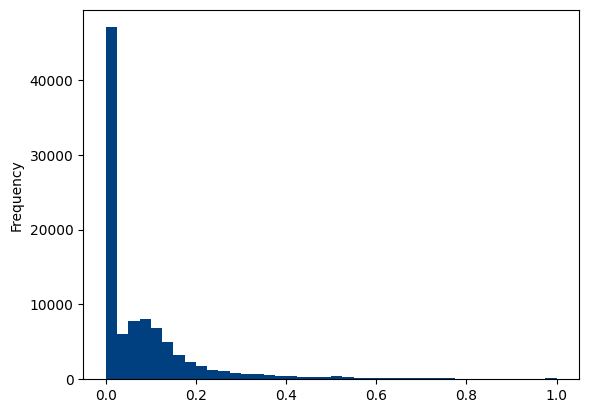

In [538]:
ratioibkdfito_llave1['ratioibkllave1'].plot(kind='hist', bins=40)
# la columna después del precipicio son todos los ratios entre cero y el límite mínimo

In [539]:
ratioibkdfito_llave1['ratioibkllave1'].value_counts()

,count
ratioibkllave1,
0.00,43563
0.02,359
0.50,129
0.33,66
0.25,48
...,...
0.05,1
0.05,1
0.18,1


In [540]:
# unión con base por llave
visadeb = visadeb.merge(ratioibkdfito_llave1[['llave1', 'ratioibkllave1']], on='llave1', how='left')
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN


In [541]:
visadeb.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'razsoc', 'nombrecomercial', 'cartera', 'tipoproducto', 'compania',
       'dpto', 'mcc', 'giro', 'vertical', 'bolsa', 'facilitador',
       'detalle_compania', 'llave1', 'llave2', 'llave3', 'tarjeta', 'marca',
       'Importe Data IBK', 'Importe Data Amex', 'Importe Total Izipay',
       'Importe IBK en Izipay', 'Importe IBK en Enrut',
       'Importe Total Izipay S/OnUs', 'Importe IBK en Izipay S/OnUs',
       'ratioibkllave1'],
      dtype='object')

In [542]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"')
ratioibkdfito_llave2 = temp.groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()
ratioibkdfito_llave2['llave2'] = ratioibkdfito_llave2['cartera'] + ratioibkdfito_llave2['tipoproducto'] + ratioibkdfito_llave2['mcc'] + ratioibkdfito_llave2['dpto']
ratioibkdfito_llave2.drop(columns=['cartera', 'tipoproducto', 'mcc', 'dpto'], inplace=True)
ratioibkdfito_llave2 = pd.pivot_table(ratioibkdfito_llave2, index='llave2', columns='banco', values='monto').reset_index()
ratioibkdfito_llave2['total'] = ratioibkdfito_llave2['IBK'] + ratioibkdfito_llave2['OTROS']
ratioibkdfito_llave2['ratioibkllave2'] = ratioibkdfito_llave2['IBK'] / ratioibkdfito_llave2['total']
# calculo del ratio general
ratio = ratioibkdfito_llave2['IBK'].sum() / ratioibkdfito_llave2['total'].sum()

print(ratio)

ratio_q15 = ratioibkdfito_llave2.loc[ratioibkdfito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.15)

print(ratio_q15)

ratio_q10 = ratioibkdfito_llave2.loc[ratioibkdfito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.05)

print(ratio_q10)
# asignación de valores
ratioibkdfito_llave2['ratioibkllave2'] = ratioibkdfito_llave2.apply(lambda x: ratio_q10 if x['ratioibkllave2']<ratio_minimo_visa and x['ratioibkllave2']>0 else x['ratioibkllave2'], axis=1)
ratioibkdfito_llave2['ratioibkllave2'] = ratioibkdfito_llave2.apply(lambda x: 0 if x['ratioibkllave2']<0 else x['ratioibkllave2'], axis=1)
ratioibkdfito_llave2.replace(np.nan, 0, inplace=True)
ratioibkdfito_llave2

0.12330861136325824
0.04184936992909655
0.017444456607978623


banco,llave2,IBK,OTROS,total,ratioibkllave2
0,BCFisico0780ANCASH,6232.80,58278.15,64510.95,0.10
1,BCFisico0780AREQUIPA,1449.85,80377.67,81827.52,0.02
2,BCFisico0780HUANUCO,486.95,20076.65,20563.60,0.02
3,BCFisico0780LA LIBERTAD,1896.30,29421.34,31317.64,0.06
4,BCFisico0780LAMBAYEQUE,446.00,10148.26,10594.26,0.04
...,...,...,...,...,...
6858,RETAILVirtual8999PIURA,71.00,8047.70,8118.70,0.01
6859,RETAILVirtual8999PUNO,40.00,2631.00,2671.00,0.01
6860,RETAILVirtual8999SAN MARTIN,20.00,875.00,895.00,0.02
6861,RETAILVirtual8999TUMBES,0.00,1.00,0.00,0.00


In [543]:
ratioibkdfito_llave2

banco,llave2,IBK,OTROS,total,ratioibkllave2
0,BCFisico0780ANCASH,6232.80,58278.15,64510.95,0.10
1,BCFisico0780AREQUIPA,1449.85,80377.67,81827.52,0.02
2,BCFisico0780HUANUCO,486.95,20076.65,20563.60,0.02
3,BCFisico0780LA LIBERTAD,1896.30,29421.34,31317.64,0.06
4,BCFisico0780LAMBAYEQUE,446.00,10148.26,10594.26,0.04
...,...,...,...,...,...
6858,RETAILVirtual8999PIURA,71.00,8047.70,8118.70,0.01
6859,RETAILVirtual8999PUNO,40.00,2631.00,2671.00,0.01
6860,RETAILVirtual8999SAN MARTIN,20.00,875.00,895.00,0.02
6861,RETAILVirtual8999TUMBES,0.00,1.00,0.00,0.00


In [544]:
# unión con base por llave
visadeb = visadeb.merge(ratioibkdfito_llave2[['llave2', 'ratioibkllave2']], on='llave2', how='left')
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN


In [545]:
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"')
ratio_llave3 = temp.groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()
ratio_llave3['llave3'] = ratio_llave3['codigo'] + ratio_llave3['tipoproducto'] + ratio_llave3['mcc'] + ratio_llave3['dpto']
ratio_llave3.drop(columns=['codigo', 'tipoproducto', 'mcc', 'dpto'], inplace=True)
ratio_llave3 = pd.pivot_table(ratio_llave3, index='llave3', columns='banco', values='monto').reset_index()
ratio_llave3['total'] = ratio_llave3['IBK'] + ratio_llave3['OTROS']
ratio_llave3['ratioibkllave3'] = ratio_llave3['IBK'] / ratio_llave3['total']
# calculo del ratio general
ratio = ratio_llave3['IBK'].sum() / ratio_llave3['total'].sum()

ratio_q15 = ratio_llave3.loc[ratio_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratio_llave3.loc[ratio_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratio_llave3['ratioibkllave3'] = ratio_llave3.apply(lambda x: ratio_q10 if x['ratioibkllave3']<ratio_minimo_visa and x['ratioibkllave3']>0 else x['ratioibkllave3'], axis=1)
ratio_llave3['ratioibkllave3'] = ratio_llave3.apply(lambda x: 0 if x['ratioibkllave3']<0 else x['ratioibkllave3'], axis=1)
ratio_llave3.replace(np.nan, 0, inplace=True)
ratio_llave3

# unión con base por llave
visadeb = visadeb.merge(ratio_llave3[['llave3', 'ratioibkllave3']], on='llave3', how='left')
visadeb

0.04765504910626709
0.022693196371267585


,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN


In [546]:
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito"')[['banco', 'monto']].groupby(by=['banco'])['monto'].sum().reset_index()
print(temp)
ratio_ibk_otros = temp.loc[temp.banco=='IBK', 'monto'].values / temp.monto.sum()
print(ratio_ibk_otros)

   banco         monto
0    IBK  432372534.98
1  OTROS 3133825257.19
[0.12124188]


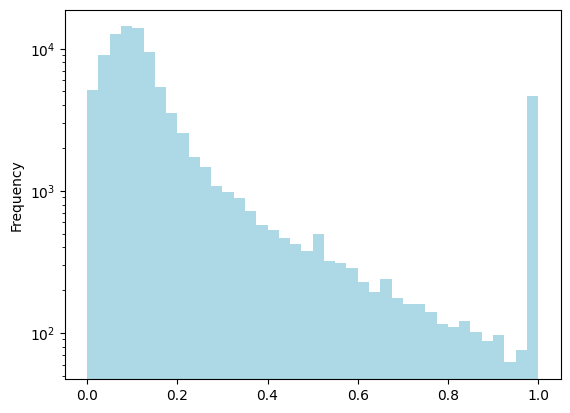

In [547]:
def ratioibkizi(visadeb):
    if (visadeb.tipoproducto == 'Fisico') and (visadeb.compania != 'OTROS'):
        if (visadeb['Importe IBK en Izipay']==np.nan) or visadeb['Importe Total Izipay']==np.nan or visadeb['Importe Total Izipay']==0:
            return 0
        else:
            return visadeb['Importe IBK en Izipay'] / visadeb['Importe Total Izipay']

    elif (visadeb.tipoproducto == 'Fisico') and (visadeb.compania == 'OTROS'):
        if visadeb.ratioibkllave1!=0:
            return visadeb.ratioibkllave1
        elif visadeb.ratioibkllave2!=0:
            return visadeb.ratioibkllave2
        elif visadeb.ratioibkllave3!=0:
            return visadeb.ratioibkllave3
        else: return ratio_ibk_otros

    if (visadeb.tipoproducto == 'Virtual') and (visadeb.compania != 'OTROS'):
        if (visadeb['Importe IBK en Izipay']==np.nan) or visadeb['Importe Total Izipay']==np.nan or visadeb['Importe Total Izipay']==0:
            return 0
        else:
            return visadeb['Importe IBK en Izipay'] / visadeb['Importe Total Izipay']
    elif (visadeb.tipoproducto == 'Virtual') and (visadeb.compania == 'OTROS'):
        if visadeb.ratioibkllave1!=0:
            return visadeb.ratioibkllave1
        elif visadeb.ratioibkllave2!=0:
            return visadeb.ratioibkllave2
        elif visadeb.ratioibkllave3!=0:
            return visadeb.ratioibkllave3
        else: return ratio_ibk_otros #* 0.95

visadeb['Ratio IBK en IZIPAY'] = visadeb.apply(lambda x: ratioibkizi(x) if pd.notna(x.tipoproducto) else np.nan, axis=1)
visadeb['Ratio IBK en IZIPAY'] = visadeb['Ratio IBK en IZIPAY'].astype('float')
visadeb.loc[visadeb['Ratio IBK en IZIPAY'] < 0, 'Ratio IBK en IZIPAY'] = 0
visadeb['Ratio IBK en IZIPAY'].plot(kind='hist', log=True, bins=40, color='lightblue')
plt.show()

In [548]:
# Ratio IBK en Enrut
visadeb['Ratio IBK en Enrut'] = 0

In [549]:
# Ratio IBK en IZIPAY
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación de datos
ratio_llave1 = temp.groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# formación de la llave
ratio_llave1['llave1'] = ratio_llave1['nroruc'] + ratio_llave1['tipoproducto'] + ratio_llave1['mcc'] + ratio_llave1['dpto']

# pivot
ratio_llave1 = pd.pivot_table(ratio_llave1, index=['llave1', 'nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratio_llave1[['IBK', 'OTROS']] = ratio_llave1[['IBK', 'OTROS']].fillna(0)
ratio_llave1['total'] = ratio_llave1['IBK'] + ratio_llave1['OTROS']

# ratio
ratio_llave1['ratioibkllave1'] = ratio_llave1['IBK'] / ratio_llave1['total']

# calculo del ratio general
ratio = ratio_llave1['IBK'].sum() / ratio_llave1['total'].sum()
print(ratio)

ratio_q15 = ratio_llave1.loc[ratio_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.15)

print(ratio_q15)

ratio_q10 = ratio_llave1.loc[ratio_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratio_llave1['ratioibkllave1'] = ratio_llave1.apply(lambda x: ratio_q10 if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
ratio_llave1['ratioibkllave1'] = ratio_llave1.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
ratio_llave1.replace(np.nan, 0, inplace=True)
ratio_llave1

0.1232210551277767
0.04727073104422774
0.022112979936861014


banco,llave1,nroruc,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave1
0,10000108338Fisico5451UCAYALI,10000108338,Fisico,5451,UCAYALI,775.50,10203.10,10978.60,0.07
1,10000111959Fisico7230UCAYALI,10000111959,Fisico,7230,UCAYALI,0.00,188.00,188.00,0.00
2,10000201168Fisico5812UCAYALI,10000201168,Fisico,5812,UCAYALI,0.00,78.00,78.00,0.00
3,10000220804Fisico5947UCAYALI,10000220804,Fisico,5947,UCAYALI,0.00,0.10,0.10,0.00
4,10000276389Fisico5812UCAYALI,10000276389,Fisico,5812,UCAYALI,0.00,54.00,54.00,0.00
...,...,...,...,...,...,...,...,...,...
97873,9989627Fisico5199LIMA,9989627,Fisico,5199,LIMA,23.10,190.60,213.70,0.11
97874,9993209Fisico5331LIMA,9993209,Fisico,5331,LIMA,0.00,50.00,50.00,0.00
97875,9994033Virtual5499LIMA,9994033,Virtual,5499,LIMA,0.00,43.50,43.50,0.00
97876,9995282Fisico5651LIMA,9995282,Fisico,5651,LIMA,477.00,4473.00,4950.00,0.10


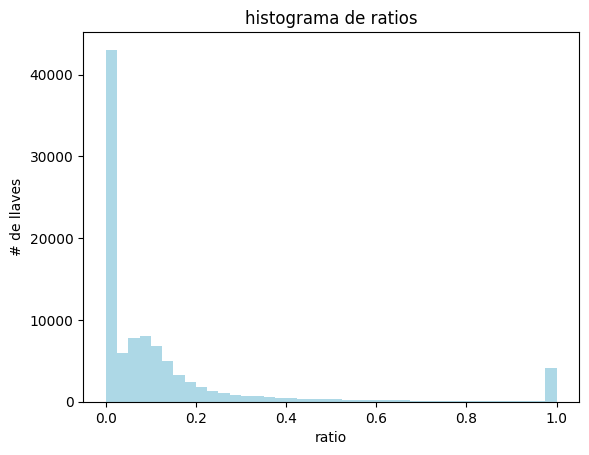

In [550]:
ratio_llave1['ratioibkllave1'].plot(kind='hist', bins=40, color='lightblue', xlabel='ratio', ylabel='# de llaves', title='histograma de ratios')
plt.show()

In [551]:
# unión con base por llave
visadeb = visadeb.merge(ratio_llave1[['llave1', 'ratioibkllave1']].rename(columns={'ratioibkllave1':'ratioibkonusllave1'}), on='llave1', how='left')
visadeb['ratioibkonusllave1'].replace(np.nan, 0, inplace=True)
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN,NaN,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00


In [552]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación
ratio_llave2 = temp.groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave
ratio_llave2['llave2'] = ratio_llave2['cartera'] + ratio_llave2['tipoproducto'] + ratio_llave2['mcc'] + ratio_llave2['dpto']

# pivot
ratio_llave2 = pd.pivot_table(ratio_llave2, index=['llave2', 'cartera', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratio_llave2[['IBK', 'OTROS']] = ratio_llave2[['IBK', 'OTROS']].fillna(0)

# total
ratio_llave2['total'] = ratio_llave2['IBK'] + ratio_llave2['OTROS']

# ratio
ratio_llave2['ratioibkllave2'] = ratio_llave2['IBK'] / ratio_llave2['total']

# calculo del ratio general
ratio = ratio_llave2['IBK'].sum() / ratio_llave2['total'].sum()
print(ratio)

ratio_q15 = ratio_llave2.loc[ratio_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratio_llave2.loc[ratio_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratio_llave2['ratioibkllave2'] = ratio_llave2.apply(lambda x: ratio_q10 if x['ratioibkllave2']<ratio_minimo_visa and x['ratioibkllave2']>0 else x['ratioibkllave2'], axis=1)
ratio_llave2['ratioibkllave2'] = ratio_llave2.apply(lambda x: 0 if x['ratioibkllave2']<0 else x['ratioibkllave2'], axis=1)
ratio_llave2.replace(np.nan, 0, inplace=True)
ratio_llave2

0.1232210551277767
0.04263433535368678
0.0177759926242554


banco,llave2,cartera,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave2
0,BCFisico0780ANCASH,BC,Fisico,0780,ANCASH,6232.80,58278.15,64510.95,0.10
1,BCFisico0780AREQUIPA,BC,Fisico,0780,AREQUIPA,1449.85,80377.67,81827.52,0.02
2,BCFisico0780HUANUCO,BC,Fisico,0780,HUANUCO,486.95,20076.65,20563.60,0.02
3,BCFisico0780LA LIBERTAD,BC,Fisico,0780,LA LIBERTAD,1896.30,29421.34,31317.64,0.06
4,BCFisico0780LAMBAYEQUE,BC,Fisico,0780,LAMBAYEQUE,446.00,10148.26,10594.26,0.04
...,...,...,...,...,...,...,...,...,...
6858,RETAILVirtual8999PIURA,RETAIL,Virtual,8999,PIURA,71.00,8047.70,8118.70,0.01
6859,RETAILVirtual8999PUNO,RETAIL,Virtual,8999,PUNO,40.00,2631.00,2671.00,0.01
6860,RETAILVirtual8999SAN MARTIN,RETAIL,Virtual,8999,SAN MARTIN,20.00,875.00,895.00,0.02
6861,RETAILVirtual8999TUMBES,RETAIL,Virtual,8999,TUMBES,0.00,1.00,1.00,0.00


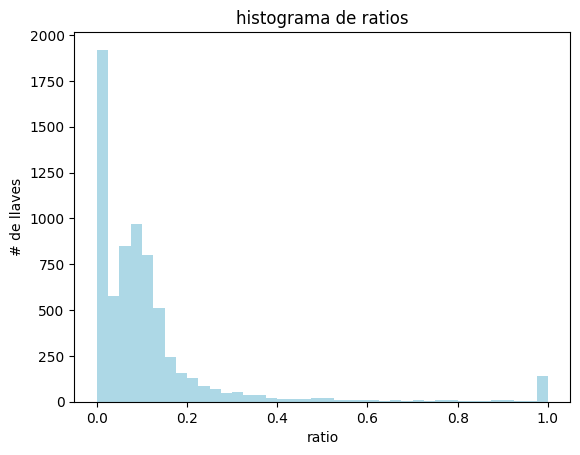

In [553]:
ratio_llave2['ratioibkllave2'].plot(kind='hist', bins=40, color='lightblue', xlabel='ratio', ylabel='# de llaves', title='histograma de ratios')
plt.show()

In [554]:
# unión con base por llave
visadeb = visadeb.merge(ratio_llave2[['llave2', 'ratioibkllave2']].rename(columns={'ratioibkllave2':'ratioibkonusllave2'}), on='llave2', how='left')
visadeb['ratioibkonusllave2'].replace(np.nan, 0, inplace=True)
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN,NaN,0,0.00,0.02
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00


In [555]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación
ratio_llave3 = temp.groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave
ratio_llave3['llave3'] = ratio_llave3['codigo'] + ratio_llave3['tipoproducto'] + ratio_llave3['mcc'] + ratio_llave3['dpto']

# pivot
ratio_llave3 = pd.pivot_table(ratio_llave3, index='llave3', columns='banco', values='monto').reset_index()
ratio_llave3[['IBK', 'OTROS']] = ratio_llave3[['IBK', 'OTROS']].fillna(0)

# total
ratio_llave3['total'] = ratio_llave3['IBK'] + ratio_llave3['OTROS']

# ratio
ratio_llave3['ratioibkllave3'] = ratio_llave3['IBK'] / ratio_llave3['total']

# calculo del ratio general
ratio = ratio_llave3['IBK'].sum() / ratio_llave3['total'].sum()
print(ratio)
ratio_q15 = ratio_llave3.loc[ratio_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratio_llave3.loc[ratio_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratio_llave3['ratioibkllave3'] = ratio_llave3.apply(lambda x: ratio_q10 if x['ratioibkllave3']<ratio_minimo_visa and x['ratioibkllave3']>0 else x['ratioibkllave3'], axis=1)
ratio_llave3['ratioibkllave3'] = ratio_llave3.apply(lambda x: 0 if x['ratioibkllave3']<0 else x['ratioibkllave3'], axis=1)
ratio_llave3.replace(np.nan, 0, inplace=True)
ratio_llave3

0.12322105512777663
0.049417011526375995
0.023564355473092047


banco,llave3,IBK,OTROS,total,ratioibkllave3
0,1000010Fisico5511LIMA,928.50,46077.45,47005.95,0.02
1,1000071Fisico5137LIMA,1468.35,17804.11,19272.46,0.08
2,1000080Fisico5111AREQUIPA,14414.39,145449.21,159863.60,0.09
3,1000083Fisico5300LIMA,3922.43,30238.72,34161.15,0.11
4,1000096Fisico5300ANCASH,0.00,14.10,14.10,0.00
...,...,...,...,...,...
135679,9998206Virtual5046LIMA,1573.00,10672.90,12245.90,0.13
135680,9998875Virtual8999LIMA,5220.00,50249.50,55469.50,0.09
135681,9999342Virtual5499JUNIN,0.00,9.00,9.00,0.00
135682,9999359Virtual5046LIMA,0.00,8.80,8.80,0.00


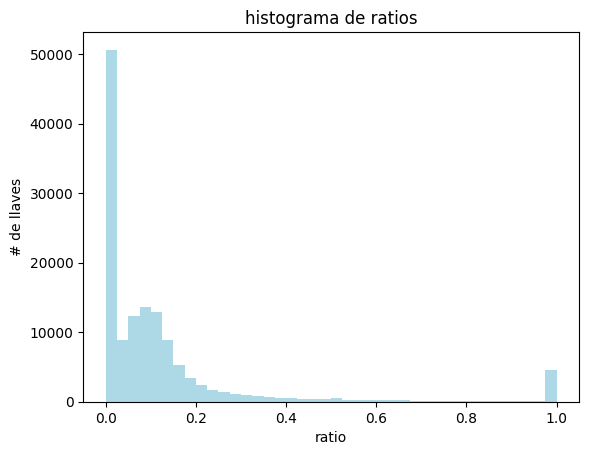

In [556]:
ratio_llave3['ratioibkllave3'].plot(kind='hist', bins=40, color='lightblue', xlabel='ratio', ylabel='# de llaves', title='histograma de ratios')
plt.show()

In [557]:
# unión con base por llave
visadeb = visadeb.merge(ratio_llave3[['llave3', 'ratioibkllave3']].rename(columns={'ratioibkllave3':'ratioibkonusllave3'}), on='llave3', how='left')
visadeb['ratioibkonusllave3'].replace(np.nan, 0, inplace=True)
visadeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2,ratioibkonusllave3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN,NaN,0,0.00,0.02,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00


In [558]:
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Débito"').query('onus!="On us"')[['banco', 'monto']].groupby(by=['banco'])['monto'].sum().reset_index()
print(temp)
ratio_ibk_otros = temp.loc[temp.banco=='IBK', 'monto'].values / temp.monto.sum()
print(ratio_ibk_otros)

   banco         monto
0    IBK  432372534.98
1  OTROS 3133825257.19
[0.12124188]


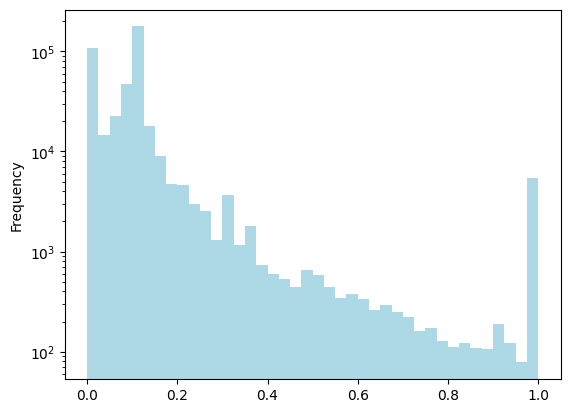

In [559]:
def ratioibkizi(visadeb):
    if (visadeb.tipoproducto == 'Fisico') and (visadeb.compania != 'OTROS'):
        if (visadeb['Importe IBK en Izipay']==np.nan) or visadeb['Importe Total Izipay S/OnUs']==np.nan or visadeb['Importe Total Izipay S/OnUs']==0:
            return 0
        else:
            return visadeb['Importe IBK en Izipay'] / visadeb['Importe Total Izipay S/OnUs']
    elif (visadeb.tipoproducto == 'Fisico') and (visadeb.compania == 'OTROS'):
        if visadeb.ratioibkonusllave1 != 0:
            return visadeb.ratioibkonusllave1
        elif visadeb.ratioibkonusllave2 != 0:
            return visadeb.ratioibkonusllave2
        elif visadeb.ratioibkonusllave3 != 0:
            return visadeb.ratioibkonusllave3
        else: return ratio_ibk_otros

    if (visadeb.tipoproducto == 'Virtual') and (visadeb.compania != 'OTROS'):
        if (visadeb['Importe IBK en Izipay']==np.nan) or visadeb['Importe Total Izipay S/OnUs']==np.nan or visadeb['Importe Total Izipay S/OnUs']==0:
            return 0
        else:
            return visadeb['Importe IBK en Izipay'] / visadeb['Importe Total Izipay S/OnUs']
    elif (visadeb.tipoproducto == 'Virtual') and (visadeb.compania == 'OTROS'):
        if visadeb.ratioibkonusllave1 != 0:
            return visadeb.ratioibkonusllave1
        elif visadeb.ratioibkonusllave2 != 0:
            return visadeb.ratioibkonusllave2
        elif visadeb.ratioibkonusllave3 != 0:
            return visadeb.ratioibkonusllave3
        else: return ratio_ibk_otros#*0.95

visadeb['Ratio IBK en IZIPAY S/OnUs'] = visadeb.apply(lambda x: ratioibkizi(x) if pd.notna(x.tipoproducto) else np.nan, axis=1)
visadeb['Ratio IBK en IZIPAY S/OnUs'] = visadeb['Ratio IBK en IZIPAY S/OnUs'].astype('float')
visadeb.loc[visadeb['Ratio IBK en IZIPAY S/OnUs'] < 0, 'Ratio IBK en IZIPAY S/OnUs'] = 0
visadeb['Ratio IBK en IZIPAY S/OnUs'].replace(np.nan, 0, inplace=True)
visadeb['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')
plt.show()

<Axes: ylabel='Frequency'>

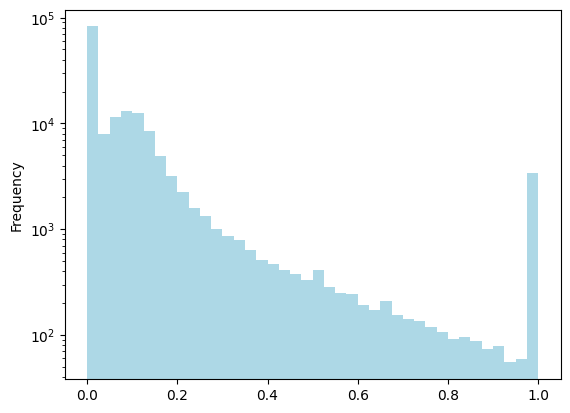

In [560]:
visadeb.query('compania!="OTROS" & tipoproducto=="Fisico"')['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')

<Axes: ylabel='Frequency'>

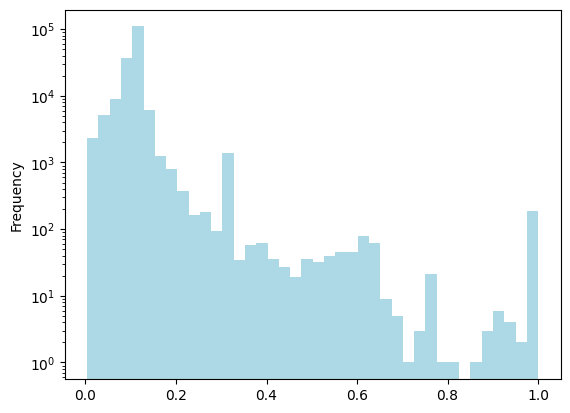

In [561]:
visadeb.query('compania=="OTROS" & tipoproducto=="Fisico"')['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')

In [562]:
def divisioncero(parte, total):
    try:
        result = parte / total
    except ZeroDivisionError:
        result = 0
    return result

visadeb['Mercado estimado inicial'] = visadeb.apply(lambda x: divisioncero(x['Importe Data IBK'], x['Ratio IBK en IZIPAY S/OnUs']), axis=1)
visadeb['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)

In [563]:
# Mercado estimado final
visadeb['Mercado estimado final'] = visadeb.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [564]:
visadeb.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2,ratioibkonusllave3,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Visa,18.90,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00,0.12,155.89,155.89
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Visa,120.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00,0.12,989.76,989.76
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN,NaN,0,0.00,0.02,0.00,0.02,109911.36,109911.36
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Visa,108.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00,0.12,890.78,890.78
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Visa,13.00,0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,0,0.00,0.00,0.00,0.12,107.22,107.22


In [565]:
visadeb.query('`Ratio IBK en IZIPAY S/OnUs`>0 & `Ratio IBK en IZIPAY S/OnUs`<0.10')

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2,ratioibkonusllave3,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Visa,2289.82,0,NaN,NaN,0,NaN,0,NaN,0.02,NaN,NaN,0,0.00,0.02,0.00,0.02,109911.36,109911.36
9,100000000_360 GRADOS,0,1,0,11111,NaN,NaN,NaN,360 GRADOS,RETAIL,Fisico,OTROS,JUNIN,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812JUNIN,100000000_360 GRADOSFisico5812JUNIN,TD,Visa,232.50,0,NaN,NaN,0,NaN,0,NaN,0.10,NaN,NaN,0,0.00,0.10,0.00,0.10,2340.15,2340.15
10,100000000_365 MINI MA,0,1,0,1111,NaN,NaN,NaN,365 MINI MA,RETAIL,Fisico,OTROS,UCAYALI,5411,Supermercados,GRUPO 1 - SUPERMERCADOS / HOGAR,100000000,NaN,ND,NaN,RETAILFisico5411UCAYALI,100000000_365 MINI MAFisico5411UCAYALI,TD,Visa,289.90,0,NaN,NaN,0,NaN,0,NaN,0.09,NaN,NaN,0,0.00,0.09,0.00,0.09,3318.22,3318.22
16,100000000_44 SUR,0,1,0,1,NaN,NaN,NaN,44 SUR,RETAIL,Virtual,OTROS,LIMA,5811,"Proveedor fiestas, alimentos preparados",GRUPO 1 - SUPERMERCADOS / HOGAR,100000000,NaN,ND,NaN,RETAILVirtual5811LIMA,100000000_44 SURVirtual5811LIMA,TD,Visa,242.00,0,NaN,NaN,0,NaN,0,NaN,0.01,NaN,NaN,0,0.00,0.01,0.00,0.01,33342.76,33342.76
20,100000000_69 HOSPEDAJ,0,1,0,111111111112,NaN,NaN,NaN,69 HOSPEDAJ,RETAIL,Fisico,OTROS,PIURA,7011,"Hoteles, hostales, moteles",GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,100000000,NaN,ND,NaN,RETAILFisico7011PIURA,100000000_69 HOSPEDAJFisico7011PIURA,TD,Visa,423.00,0,NaN,NaN,0,NaN,0,NaN,0.09,NaN,NaN,0,0.00,0.09,0.00,0.09,4583.09,4583.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430635,99977,0,1,0,211,NaN,NaN,NaN,LAMARQUE AUTOMOTRIZ,RETAIL,Fisico,OTROS,LIMA,5541,"Estaciones de servicio, grifos",GRUPO 6 - SERVICIOS / AUTOS,NaN,NaN,ND,NaN,RETAILFisico5541LIMA,99977Fisico5541LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,0.10,NaN,NaN,0,0.00,0.10,0.00,0.10,0.00,0.00
430636,9997783,1,0,0,0,NaN,20610115625,INVERSIONES DEI GRATIA E I R L,INVERSIONES DEI GRATIA,BPE,Virtual,IZIPAY,LIMA,5046,Activ. Comercial no clasific.,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,IZI,IZIPAY,20610115625Virtual5046LIMA,BPEVirtual5046LIMA,9997783Virtual5046LIMA,TD,Visa,0.00,0,5714.45,408.45,0,5714.45,0,0.07,0.06,0.07,0.07,0,0.07,0.06,0.07,0.07,0.00,5714.45
430646,9998875,1,1,0,11112111125412,NaN,20610149198,GUNKAN,GUNKAN,BPE,Virtual,IZIPAY,LIMA,8999,Otros servicios profesionales,GRUPO 6 - SERVICIOS / AUTOS,NaN,IZI,IZIPAY,20610149198Virtual8999LIMA,BPEVirtual8999LIMA,9998875Virtual8999LIMA,TD,Visa,216.00,0,55469.50,5220.00,0,55469.50,0,0.09,0.07,0.09,0.09,0,0.09,0.07,0.09,0.09,2295.29,55469.50
430647,99989,0,1,0,11112111112111121111111121111111,NaN,NaN,NaN,FELIX II,RETAIL,Fisico,OTROS,LIMA,5411,Supermercados,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NaN,ND,NaN,RETAILFisico5411LIMA,99989Fisico5411LIMA,TD,Visa,0.00,0,NaN,NaN,0,NaN,0,NaN,0.09,NaN,NaN,0,0.00,0.09,0.00,0.09,0.00,0.00


In [566]:
print(visadeb.shape, visadeb.codigo.nunique())

(433373, 42) 433369


In [567]:
visadeb['Mercado estimado final'].sum() # 4699874047

np.float64(7791762764.472757)

### Base Visa crédito <a id="section_4_4"></a>

In [568]:
# campos artificiales
visacred = df.copy()
visacred['tarjeta'] = 'TC'
visacred['marca'] = 'Visa'
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa


In [569]:
# Importe Data IBK
temp = ibk.query('marca=="Visa"').query('tipotarjeta=="TC"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Data IBK'}, inplace=True)
visacred = visacred.merge(temp, on='codigo', how='left')
visacred['Importe Data IBK'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00


In [570]:
visacred['Importe Data IBK'].sum()-ibk.query('marca=="Visa"').query('tipotarjeta=="TC"')['monto'].sum()

np.float64(0.0)

In [571]:
# Importe Data Amex
visacred['Importe Data Amex'] = 0

In [572]:
# Importe Total Izipay
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
visacred = visacred.merge(temp, on='codigo', how='left')
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN


In [573]:
# Importe IBK en Izipay
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('banco=="IBK"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe IBK en Izipay'}, inplace=True)
visacred = visacred.merge(temp, on='codigo', how='left')
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN


In [574]:
# Importe IBK en Enrut
visacred['Importe IBK en Enrut'] = 0

In [575]:
# Importe Total Izipay S/OnUs
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"').query('onus!="On us"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay S/OnUs'}, inplace=True)
visacred = visacred.merge(temp, on='codigo', how='left')
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN


In [576]:
# Importe IBK en Izipay S/OnUs
visacred['Importe IBK en Izipay S/OnUs'] = 0

In [577]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"')

# agrupación de datos
ratioibkvisacredito_llave1 = temp.groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# formación de la llave
ratioibkvisacredito_llave1['llave1'] = ratioibkvisacredito_llave1['nroruc'] + ratioibkvisacredito_llave1['tipoproducto'] + ratioibkvisacredito_llave1['mcc'] + ratioibkvisacredito_llave1['dpto']
ratioibkvisacredito_llave1 = pd.pivot_table(ratioibkvisacredito_llave1, index=['llave1', 'nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratioibkvisacredito_llave1[['IBK', 'OTROS']] = ratioibkvisacredito_llave1[['IBK', 'OTROS']].fillna(0)

# calculo del total
ratioibkvisacredito_llave1['total'] = ratioibkvisacredito_llave1['IBK'] + ratioibkvisacredito_llave1['OTROS']

# calculo del ratio
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1['IBK'] / ratioibkvisacredito_llave1['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave1['IBK'].sum() / ratioibkvisacredito_llave1['total'].sum()
print('El ratio general es:', ratio)
ratio_q15 = ratioibkvisacredito_llave1.loc[ratioibkvisacredito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave1.loc[ratioibkvisacredito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.05)

print(ratio_q10)
# asignación de valores
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1.apply(lambda x: ratio_q10 if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
ratioibkvisacredito_llave1.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave1

El ratio general es: 0.14573472863029166
0.08515711007575448
0.03932928511490555


banco,llave1,nroruc,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave1
0,10000108338Fisico5451UCAYALI,10000108338,Fisico,5451,UCAYALI,116.50,581.50,698.00,0.17
1,10000111959Fisico7230UCAYALI,10000111959,Fisico,7230,UCAYALI,23.00,573.00,596.00,0.04
2,10000112530Fisico5812JUNIN,10000112530,Fisico,5812,JUNIN,0.00,255.70,255.70,0.00
3,10000201168Fisico5812UCAYALI,10000201168,Fisico,5812,UCAYALI,0.00,111.00,111.00,0.00
4,10000276389Fisico5812UCAYALI,10000276389,Fisico,5812,UCAYALI,0.00,59.00,59.00,0.00
...,...,...,...,...,...,...,...,...,...
108826,9994528Virtual5970CAJAMARCA,9994528,Virtual,5970,CAJAMARCA,0.00,1020.00,1020.00,0.00
108827,9995282Fisico5651LIMA,9995282,Fisico,5651,LIMA,0.00,223.00,223.00,0.00
108828,9997155Fisico8021LIMA,9997155,Fisico,8021,LIMA,0.00,1100.00,1100.00,0.00
108829,9997210Fisico7531LIMA,9997210,Fisico,7531,LIMA,0.00,370.00,370.00,0.00


In [578]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave1[['llave1', 'ratioibkllave1']], on='llave1', how='left')
visacred['ratioibkllave1'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00


In [579]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"')

# agrupación
ratioibkvisacredito_llave2 = temp.groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave
ratioibkvisacredito_llave2['llave2'] = ratioibkvisacredito_llave2['cartera'] + ratioibkvisacredito_llave2['tipoproducto'] + ratioibkvisacredito_llave2['mcc'] + ratioibkvisacredito_llave2['dpto']
ratioibkvisacredito_llave2 = pd.pivot_table(ratioibkvisacredito_llave2, index=['llave2', 'cartera', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()

# valores vacíos a 0
ratioibkvisacredito_llave2[['IBK', 'OTROS']] = ratioibkvisacredito_llave2[['IBK', 'OTROS']].fillna(0)
ratioibkvisacredito_llave2['total'] = ratioibkvisacredito_llave2['IBK'] + ratioibkvisacredito_llave2['OTROS']

# ratio
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2['IBK'] / ratioibkvisacredito_llave2['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave2['IBK'].sum() / ratioibkvisacredito_llave2['total'].sum()
print('El ratio general es:', ratio)

ratio_q15 = ratioibkvisacredito_llave2.loc[ratioibkvisacredito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave2.loc[ratioibkvisacredito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2.apply(lambda x: ratio_q10 if x['ratioibkllave2']<ratio_minimo_visa and x['ratioibkllave2']>0 else x['ratioibkllave2'], axis=1)
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2.apply(lambda x: 0 if x['ratioibkllave2']<0 else x['ratioibkllave2'], axis=1)
ratioibkvisacredito_llave2.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave2

El ratio general es: 0.14573472863029166
0.08264126100808272
0.03392427670036015


banco,llave2,cartera,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave2
0,BCFisico0780ANCASH,BC,Fisico,0780,ANCASH,100.00,19050.71,19150.71,0.01
1,BCFisico0780AREQUIPA,BC,Fisico,0780,AREQUIPA,35812.83,122541.37,158354.20,0.23
2,BCFisico0780HUANUCO,BC,Fisico,0780,HUANUCO,0.00,906.00,906.00,0.00
3,BCFisico0780LA LIBERTAD,BC,Fisico,0780,LA LIBERTAD,6012.00,12915.16,18927.16,0.32
4,BCFisico0780LAMBAYEQUE,BC,Fisico,0780,LAMBAYEQUE,1377.25,12705.85,14083.10,0.10
...,...,...,...,...,...,...,...,...,...
6814,RETAILVirtual8999PUNO,RETAIL,Virtual,8999,PUNO,0.00,4900.00,4900.00,0.00
6815,RETAILVirtual8999SAN MARTIN,RETAIL,Virtual,8999,SAN MARTIN,2940.00,6780.00,9720.00,0.30
6816,RETAILVirtual8999TACNA,RETAIL,Virtual,8999,TACNA,926.20,150.00,1076.20,0.86
6817,RETAILVirtual8999TUMBES,RETAIL,Virtual,8999,TUMBES,0.00,2500.00,2500.00,0.00


In [580]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave2[['llave2', 'ratioibkllave2']], on='llave2', how='left')
visacred['ratioibkllave2'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.06
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00


In [581]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"')

# agrupación
ratioibkvisacredito_llave3 = temp.groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave3
ratioibkvisacredito_llave3['llave3'] = ratioibkvisacredito_llave3['codigo'] + ratioibkvisacredito_llave3['tipoproducto'] + ratioibkvisacredito_llave3['mcc'] + ratioibkvisacredito_llave3['dpto']

# pivot
ratioibkvisacredito_llave3 = pd.pivot_table(ratioibkvisacredito_llave3, index=['llave3', 'codigo', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratioibkvisacredito_llave3[['IBK', 'OTROS']] = ratioibkvisacredito_llave3[['IBK', 'OTROS']].fillna(0)

# total
ratioibkvisacredito_llave3['total'] = ratioibkvisacredito_llave3['IBK'] + ratioibkvisacredito_llave3['OTROS']

# ratio
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3['IBK'] / ratioibkvisacredito_llave3['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave3['IBK'].sum() / ratioibkvisacredito_llave3['total'].sum()
print('El ratio general es:', ratio)

ratio_q15 = ratioibkvisacredito_llave3.loc[ratioibkvisacredito_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave3.loc[ratioibkvisacredito_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.05)

print(ratio_q10)
# asignación de valores
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3.apply(lambda x: ratio_q10 if x['ratioibkllave3']<ratio_minimo_visa and x['ratioibkllave3']>0 else x['ratioibkllave3'], axis=1)
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3.apply(lambda x: 0 if x['ratioibkllave3']<0 else x['ratioibkllave3'], axis=1)
ratioibkvisacredito_llave3.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave3

El ratio general es: 0.14573472863029166
0.08351648351648351
0.04087756558828973


banco,llave3,codigo,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave3
0,1000010Fisico5511LIMA,1000010,Fisico,5511,LIMA,2010.55,12574.85,14585.40,0.14
1,1000071Fisico5137LIMA,1000071,Fisico,5137,LIMA,2178.84,15917.40,18096.24,0.12
2,1000080Fisico5111AREQUIPA,1000080,Fisico,5111,AREQUIPA,15055.57,100135.31,115190.88,0.13
3,1000083Fisico5300LIMA,1000083,Fisico,5300,LIMA,959.92,6147.81,7107.73,0.14
4,1000096Fisico5300ANCASH,1000096,Fisico,5300,ANCASH,20.80,74.80,95.60,0.22
...,...,...,...,...,...,...,...,...,...
145359,9993813Virtual5999LIMA,9993813,Virtual,5999,LIMA,44.50,0.00,44.50,1.00
145360,9994270Virtual5812LIMA,9994270,Virtual,5812,LIMA,131.50,0.00,131.50,1.00
145361,9997386Virtual1799LIMA,9997386,Virtual,1799,LIMA,800.00,0.00,800.00,1.00
145362,9998875Virtual8999LIMA,9998875,Virtual,8999,LIMA,328.00,0.00,328.00,1.00


In [582]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave3[['llave3', 'ratioibkllave3']], on='llave3', how='left')
visacred['ratioibkllave3'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.06,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00


In [583]:
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"')[['banco', 'monto']].groupby(by=['banco'])['monto'].sum().reset_index()
print(temp)
ratio_ibk_otros = temp.loc[temp.banco=='IBK', 'monto'].values / temp.monto.sum()
print(ratio_ibk_otros)

   banco         monto
0    IBK  274400016.94
1  OTROS 1724034852.48
[0.13730746]


In [584]:
def ratioibkizi(visacred):
    if (visacred.tipoproducto == 'Fisico') and (visacred.compania != 'OTROS'):
        if (visacred['Importe IBK en Izipay']==np.nan) or visacred['Importe Total Izipay']==np.nan or visacred['Importe Total Izipay']==0:
            return 0
        else:
            return visacred['Importe IBK en Izipay'] / visacred['Importe Total Izipay']
    elif (visacred.tipoproducto == 'Fisico') and (visacred.compania == 'OTROS'):
        if visacred.ratioibkllave1 != 0:
            return visacred.ratioibkllave1
        elif visacred.ratioibkllave2 != 0:
            return visacred.ratioibkllave2
        elif visacred.ratioibkllave3 != 0:
            return visacred.ratioibkllave3
        else: return ratio_ibk_otros

    if (visacred.tipoproducto == 'Virtual') and (visacred.compania != 'OTROS'):
        if (visacred['Importe IBK en Izipay']==np.nan) or visacred['Importe Total Izipay']==np.nan or visacred['Importe Total Izipay']==0:
            return 0
        else:
            return visacred['Importe IBK en Izipay'] / visacred['Importe Total Izipay']
    elif (visacred.tipoproducto == 'Virtual') and (visacred.compania == 'OTROS'):
        if visacred.ratioibkllave1 != 0:
            return visacred.ratioibkllave1
        elif visacred.ratioibkllave2 != 0:
            return visacred.ratioibkllave2
        elif visacred.ratioibkllave3 != 0:
            return visacred.ratioibkllave3
        else: return ratio_ibk_otros#*0.95

visacred['Ratio IBK en IZIPAY'] = visacred.apply(lambda x: ratioibkizi(x) if pd.notna(x.tipoproducto) else np.nan, axis=1)
visacred['Ratio IBK en IZIPAY'] = visacred['Ratio IBK en IZIPAY'].astype('float')
visacred.loc[visacred['Ratio IBK en IZIPAY'] < 0, 'Ratio IBK en IZIPAY'] = 0
visacred['Ratio IBK en IZIPAY'].replace(np.nan, 0, inplace=True)

<Axes: ylabel='Frequency'>

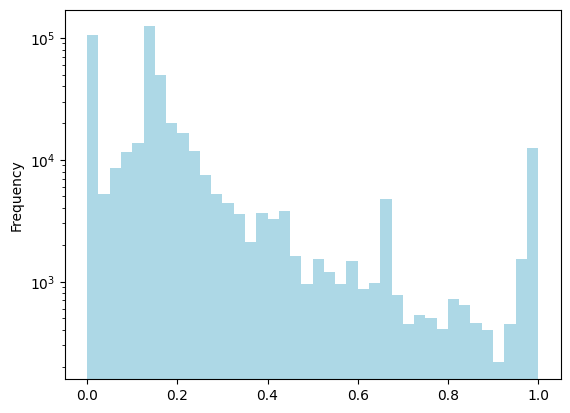

In [585]:
visacred['Ratio IBK en IZIPAY'].plot(kind='hist', log=True, bins=40, color='lightblue')

<Axes: ylabel='Frequency'>

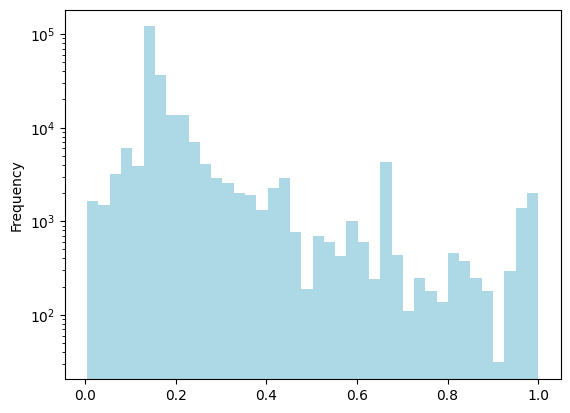

In [586]:
visacred.query('compania=="OTROS"')['Ratio IBK en IZIPAY'].plot(kind='hist', log=True, bins=40, color='lightblue')

<Axes: ylabel='Frequency'>

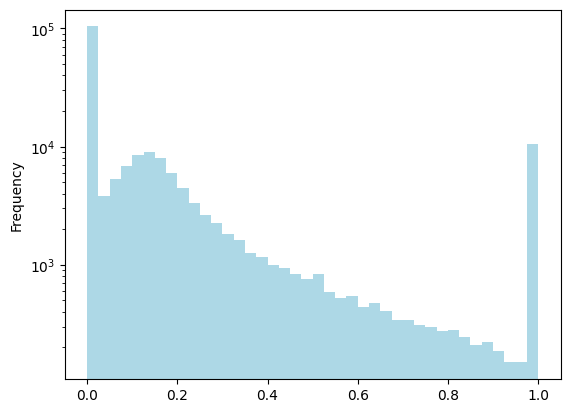

In [587]:
visacred.query('compania!="OTROS"')['Ratio IBK en IZIPAY'].plot(kind='hist', log=True, bins=40, color='lightblue')

In [588]:
# Ratio IBK en Enrut
visacred['Ratio IBK en Enrut'] = 0

In [589]:
# Ratio IBK en IZIPAY S/OnUs

# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación de datos
ratioibkvisacredito_llave1 = temp.groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# formación de la llave
ratioibkvisacredito_llave1['llave1'] = ratioibkvisacredito_llave1['nroruc'] + ratioibkvisacredito_llave1['tipoproducto'] + ratioibkvisacredito_llave1['mcc'] + ratioibkvisacredito_llave1['dpto']

# pivot en banco
ratioibkvisacredito_llave1 = pd.pivot_table(ratioibkvisacredito_llave1, index=['llave1', 'nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratioibkvisacredito_llave1[['IBK', 'OTROS']] = ratioibkvisacredito_llave1[['IBK', 'OTROS']].fillna(0)
ratioibkvisacredito_llave1['total'] = ratioibkvisacredito_llave1['IBK'] + ratioibkvisacredito_llave1['OTROS']

# calculo de ratio
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1['IBK'] / ratioibkvisacredito_llave1['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave1['IBK'].sum() / ratioibkvisacredito_llave1['total'].sum()
print('El ratio general es:', ratio)
ratio_q15 = ratioibkvisacredito_llave1.loc[ratioibkvisacredito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave1.loc[ratioibkvisacredito_llave1['ratioibkllave1']>0]['ratioibkllave1'].quantile(0.05)

print(ratio_q10)

# asignación de valores
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1.apply(lambda x: ratio_q10 if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
ratioibkvisacredito_llave1['ratioibkllave1'] = ratioibkvisacredito_llave1.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
ratioibkvisacredito_llave1.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave1

El ratio general es: 0.14573472863029166
0.08515711007575448
0.03932928511490555


banco,llave1,nroruc,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave1
0,10000108338Fisico5451UCAYALI,10000108338,Fisico,5451,UCAYALI,116.50,581.50,698.00,0.17
1,10000111959Fisico7230UCAYALI,10000111959,Fisico,7230,UCAYALI,23.00,573.00,596.00,0.04
2,10000112530Fisico5812JUNIN,10000112530,Fisico,5812,JUNIN,0.00,255.70,255.70,0.00
3,10000201168Fisico5812UCAYALI,10000201168,Fisico,5812,UCAYALI,0.00,111.00,111.00,0.00
4,10000276389Fisico5812UCAYALI,10000276389,Fisico,5812,UCAYALI,0.00,59.00,59.00,0.00
...,...,...,...,...,...,...,...,...,...
108826,9994528Virtual5970CAJAMARCA,9994528,Virtual,5970,CAJAMARCA,0.00,1020.00,1020.00,0.00
108827,9995282Fisico5651LIMA,9995282,Fisico,5651,LIMA,0.00,223.00,223.00,0.00
108828,9997155Fisico8021LIMA,9997155,Fisico,8021,LIMA,0.00,1100.00,1100.00,0.00
108829,9997210Fisico7531LIMA,9997210,Fisico,7531,LIMA,0.00,370.00,370.00,0.00


In [590]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave1[['llave1', 'ratioibkllave1']].rename(columns={'ratioibkllave1':'ratioibkonusllave1'}), on='llave1', how='left')
visacred['ratioibkonusllave1'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.06,0.00,0.06,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00


In [591]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación
ratioibkvisacredito_llave2 = temp.groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave2
ratioibkvisacredito_llave2['llave2'] = ratioibkvisacredito_llave2['cartera'] + ratioibkvisacredito_llave2['tipoproducto'] + ratioibkvisacredito_llave2['mcc'] + ratioibkvisacredito_llave2['dpto']

# pivot
ratioibkvisacredito_llave2 = pd.pivot_table(ratioibkvisacredito_llave2, index=['llave2', 'cartera', 'tipoproducto', 'mcc', 'dpto'], columns='banco', values='monto').reset_index()
ratioibkvisacredito_llave2[['IBK', 'OTROS']] = ratioibkvisacredito_llave2[['IBK', 'OTROS']].fillna(0)
ratioibkvisacredito_llave2['total'] = ratioibkvisacredito_llave2['IBK'] + ratioibkvisacredito_llave2['OTROS']

# ratio
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2['IBK'] / ratioibkvisacredito_llave2['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave2['IBK'].sum() / ratioibkvisacredito_llave2['total'].sum()
print(ratio)

ratio_q15 = ratioibkvisacredito_llave2.loc[ratioibkvisacredito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave2.loc[ratioibkvisacredito_llave2['ratioibkllave2']>0]['ratioibkllave2'].quantile(0.05)

print(ratio_q10)
# asignación de valores
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2.apply(lambda x: ratio_q10 if x['ratioibkllave2']<ratio_minimo_visa and x['ratioibkllave2']>0 else x['ratioibkllave2'], axis=1)
ratioibkvisacredito_llave2['ratioibkllave2'] = ratioibkvisacredito_llave2.apply(lambda x: 0 if x['ratioibkllave2']<0 else x['ratioibkllave2'], axis=1)
ratioibkvisacredito_llave2.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave2

0.14573472863029166
0.08264126100808272
0.03392427670036015


banco,llave2,cartera,tipoproducto,mcc,dpto,IBK,OTROS,total,ratioibkllave2
0,BCFisico0780ANCASH,BC,Fisico,0780,ANCASH,100.00,19050.71,19150.71,0.01
1,BCFisico0780AREQUIPA,BC,Fisico,0780,AREQUIPA,35812.83,122541.37,158354.20,0.23
2,BCFisico0780HUANUCO,BC,Fisico,0780,HUANUCO,0.00,906.00,906.00,0.00
3,BCFisico0780LA LIBERTAD,BC,Fisico,0780,LA LIBERTAD,6012.00,12915.16,18927.16,0.32
4,BCFisico0780LAMBAYEQUE,BC,Fisico,0780,LAMBAYEQUE,1377.25,12705.85,14083.10,0.10
...,...,...,...,...,...,...,...,...,...
6814,RETAILVirtual8999PUNO,RETAIL,Virtual,8999,PUNO,0.00,4900.00,4900.00,0.00
6815,RETAILVirtual8999SAN MARTIN,RETAIL,Virtual,8999,SAN MARTIN,2940.00,6780.00,9720.00,0.30
6816,RETAILVirtual8999TACNA,RETAIL,Virtual,8999,TACNA,926.20,150.00,1076.20,0.86
6817,RETAILVirtual8999TUMBES,RETAIL,Virtual,8999,TUMBES,0.00,2500.00,2500.00,0.00


In [592]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave2[['llave2', 'ratioibkllave2']].rename(columns={'ratioibkllave2':'ratioibkonusllave2'}), on='llave2', how='left')
visacred['ratioibkonusllave2'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.06,0.00,0.06,0,0.00,0.06
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00


In [593]:
# query
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('emisor != "Internacional"').query('onus!="On us"')

# agrupación
ratioibkvisacredito_llave3 = temp.groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto','banco'])['monto'].sum().reset_index()

# llave
ratioibkvisacredito_llave3['llave3'] = ratioibkvisacredito_llave3['codigo'] + ratioibkvisacredito_llave3['tipoproducto'] + ratioibkvisacredito_llave3['mcc'] + ratioibkvisacredito_llave3['dpto']

# pivot
ratioibkvisacredito_llave3 = pd.pivot_table(ratioibkvisacredito_llave3, index='llave3', columns='banco', values='monto').reset_index()
ratioibkvisacredito_llave3[['IBK', 'OTROS']] = ratioibkvisacredito_llave3[['IBK', 'OTROS']].fillna(0)
ratioibkvisacredito_llave3['total'] = ratioibkvisacredito_llave3['IBK'] + ratioibkvisacredito_llave3['OTROS']

# calculo del ratio
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3['IBK'] / ratioibkvisacredito_llave3['total']

# calculo del ratio general
ratio = ratioibkvisacredito_llave3['IBK'].sum() / ratioibkvisacredito_llave3['total'].sum()
print(ratio)
ratio_q15 = ratioibkvisacredito_llave3.loc[ratioibkvisacredito_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.15)

print(ratio_q15)
ratio_q10 = ratioibkvisacredito_llave3.loc[ratioibkvisacredito_llave3['ratioibkllave3']>0]['ratioibkllave3'].quantile(0.05)

print(ratio_q10)
# asignación de valores
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3.apply(lambda x: ratio_q10 if x['ratioibkllave3']<ratio_minimo_visa and x['ratioibkllave3']>0 else x['ratioibkllave3'], axis=1)
ratioibkvisacredito_llave3['ratioibkllave3'] = ratioibkvisacredito_llave3.apply(lambda x: 0 if x['ratioibkllave3']<0 else x['ratioibkllave3'], axis=1)
ratioibkvisacredito_llave3.replace(np.nan, 0, inplace=True)
ratioibkvisacredito_llave3

0.14573472863029166
0.08351648351648351
0.04087756558828973


banco,llave3,IBK,OTROS,total,ratioibkllave3
0,1000010Fisico5511LIMA,2010.55,12574.85,14585.40,0.14
1,1000071Fisico5137LIMA,2178.84,15917.40,18096.24,0.12
2,1000080Fisico5111AREQUIPA,15055.57,100135.31,115190.88,0.13
3,1000083Fisico5300LIMA,959.92,6147.81,7107.73,0.14
4,1000096Fisico5300ANCASH,20.80,74.80,95.60,0.22
...,...,...,...,...,...
145359,9993813Virtual5999LIMA,44.50,0.00,44.50,1.00
145360,9994270Virtual5812LIMA,131.50,0.00,131.50,1.00
145361,9997386Virtual1799LIMA,800.00,0.00,800.00,1.00
145362,9998875Virtual8999LIMA,328.00,0.00,328.00,1.00


In [594]:
# unión con base por llave
visacred = visacred.merge(ratioibkvisacredito_llave3[['llave3', 'ratioibkllave3']].rename(columns={'ratioibkllave3':'ratioibkonusllave3'}), on='llave3', how='left')
visacred['ratioibkonusllave3'].replace(np.nan, 0, inplace=True)
visacred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2,ratioibkonusllave3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.06,0.00,0.06,0,0.00,0.06,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Visa,126.16,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.00,0.00,0.14,0,0.00,0.00,0.00


In [595]:
temp = izi.query('marca=="Visa"').query('tipotarjeta=="Crédito"').query('onus!="On us"')[['banco', 'monto']].groupby(by=['banco'])['monto'].sum().reset_index()
print(temp)
ratio_ibk_otros = temp.loc[temp.banco=='IBK', 'monto'].values / temp.monto.sum()
print(ratio_ibk_otros)

   banco         monto
0    IBK  274400016.94
1  OTROS 1724034852.48
[0.13730746]


In [596]:
izi.head()

,periodo,codigo,tipotarjeta,emisor,marca,banco,onus,monto,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania
0,202606,2267144,Crédito,Internacional,Amex,OTROS,-,132504.89,1,1,0,1213,AEROMEXICO,20307246741,AEROVIAS DE MEXICO SA DE CV SUCURSAL PER,AEROMEXICO IATA,BC,Fisico,PMP,LIMA,3076,Aeromexico-AEROMEXI,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NA,IZIPAY
1,202606,1559621,Crédito,Local,Mastercard,OTROS,-,402.44,1,1,0,2111111111221141112112112332111111221311121111...,CASSINELLI,20466776336,CENTRO CERAMICO LAS FLORES SAC,HIPERMERCADO CERAMICO,BC,Fisico,PMP,LIMA,5039,MAYORISTA - MATERIALES DE CONSTRUCCIÃ“N (NO IN...,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY
2,202606,6079852,Crédito,Internacional,Visa,OTROS,-,17009.77,1,1,0,111111111111,E S GESA,20100935032,INKA S RENT A CAR S A,HERTZ,BE,Fisico,PMP,LIMA,3357,Hertz (HERTZ CORPORATION),GRUPO 6 - SERVICIOS / AUTOS,NaN,NA,IZIPAY
3,202606,8963437,Débito,Local,Mastercard,OTROS,-,60.00,1,0,0,0,NaN,20605282076,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS ...,CENTRO DE ANALISIS CLINICOS Y MICROBIOLOGICOS,BPE,Fisico,IZIPAY,SAN MARTIN,8071,Laboratorios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY
4,202606,1038068,Débito,Local,Visa,OTROS,-,98.30,1,1,0,1112111112,MOVISTAR,20100017491,INTEGRATEL PERU S A A,MOVISTAR PGRECIBO CORP SIC,BC,Fisico,PMP,LIMA,4900,"Luz, Agua, Gas.",GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,NaN,NA,IZIPAY


In [597]:
izi.groupby(by=['onus', 'tipotarjeta', 'banco','marca','emisor'])['monto'].sum()

onus   tipotarjeta  banco  marca       emisor       
-      Crédito      IBK    Amex        Local            196483651.35
                           Visa        Local            274400016.94
                    OTROS  Amex        Internacional     71211785.73
                                       Local             75908777.77
                           Diners      Internacional      2393507.95
                                       Local             77613496.57
                           Mastercard  Internacional     89251069.74
                                       Local            149046465.41
                           Otros       Internacional       393398.93
                           Visa        Internacional    115561655.06
                                       Local           1373394916.36
       Débito       IBK    Visa        Local            432372534.98
                    OTROS  Mastercard  Internacional     29227658.13
                                       Local            118411145.87
                           Otros       Internacional        21946.55
                                       Local              3504960.86
                           Visa        Internacional     57280143.87
                                       Local           3026712953.08
On Us  Crédito      OTROS  Mastercard  Local              9010269.97
                           Visa        Local            235078281.06
       Débito       OTROS  Otros       Local               899787.03
                           Visa        Local             49832160.24
Name: monto, dtype: float64

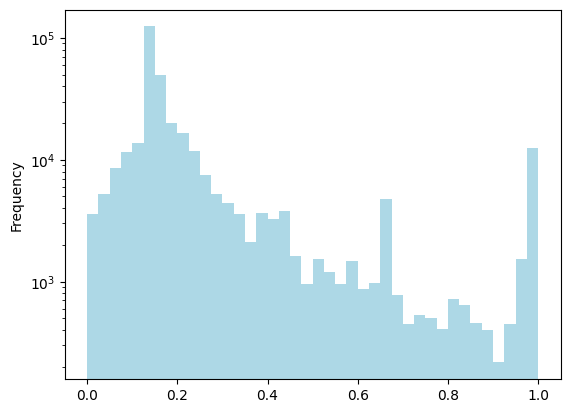

In [598]:
def ratioibkizi(visacred):
    if (visacred.tipoproducto == 'Fisico') and (visacred.compania != 'OTROS'):
        if (visacred['Importe IBK en Izipay']==np.nan) or visacred['Importe Total Izipay S/OnUs']==np.nan or visacred['Importe Total Izipay S/OnUs']==0:
            return 0
        else:
            return visacred['Importe IBK en Izipay'] / visacred['Importe Total Izipay S/OnUs']
    elif (visacred.tipoproducto == 'Fisico') and (visacred.compania == 'OTROS'):
        if visacred.ratioibkonusllave1 != 0:
            return visacred.ratioibkonusllave1
        elif visacred.ratioibkonusllave2 != 0:
            return visacred.ratioibkonusllave2
        elif visacred.ratioibkonusllave3!= 0:
            return visacred.ratioibkonusllave3
        else: return ratio_ibk_otros

    if (visacred.tipoproducto == 'Virtual') and (visacred.compania != 'OTROS'):
        if (visacred['Importe IBK en Izipay']==np.nan) or visacred['Importe Total Izipay S/OnUs']==np.nan or visacred['Importe Total Izipay S/OnUs']==0:
            return 0
        else:
            return visacred['Importe IBK en Izipay'] / visacred['Importe Total Izipay S/OnUs']
    elif (visacred.tipoproducto == 'Virtual') and (visacred.compania == 'OTROS'):
        if visacred.ratioibkonusllave1 != 0:
            return visacred.ratioibkonusllave1
        elif visacred.ratioibkonusllave2 != 0:
            return visacred.ratioibkonusllave2
        elif visacred.ratioibkonusllave3!= 0:
            return visacred.ratioibkonusllave3
        else: return ratio_ibk_otros #* 0.95

visacred['Ratio IBK en IZIPAY S/OnUs'] = visacred.apply(lambda x: ratioibkizi(x) if pd.notna(x.tipoproducto) else np.nan, axis=1)
visacred['Ratio IBK en IZIPAY S/OnUs'] = visacred['Ratio IBK en IZIPAY S/OnUs'].astype('float')
visacred.loc[visacred['Ratio IBK en IZIPAY S/OnUs'] < 0, 'Ratio IBK en IZIPAY S/OnUs'] = 0
visacred['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')
visacred['Ratio IBK en IZIPAY S/OnUs'].replace(np.nan, 0, inplace=True)
plt.show()

<Axes: ylabel='Frequency'>

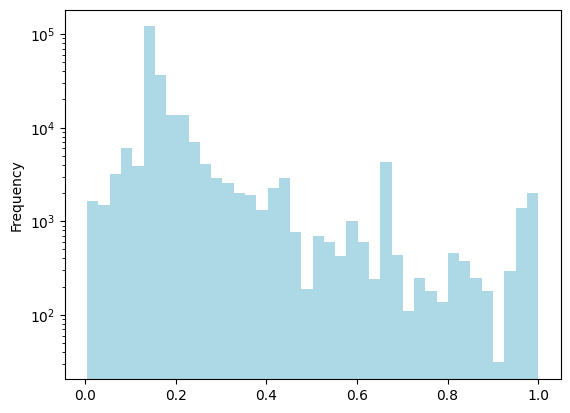

In [599]:
visacred.query('compania=="OTROS"')['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')

<Axes: ylabel='Frequency'>

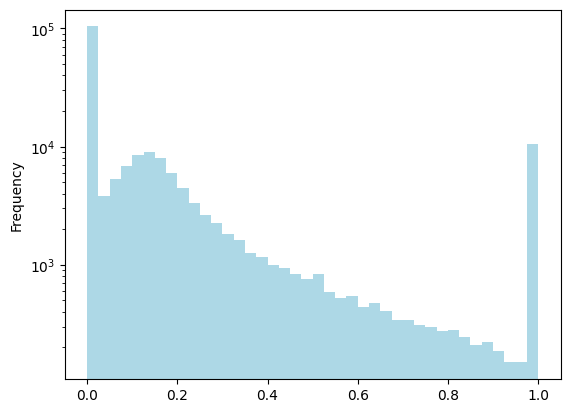

In [600]:
visacred.query('compania!="OTROS"')['Ratio IBK en IZIPAY S/OnUs'].plot(kind='hist', log=True, bins=40, color='lightblue')

In [601]:
visacred.sort_values(by='Ratio IBK en IZIPAY S/OnUs')

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,ratioibkllave1,ratioibkllave2,ratioibkllave3,Ratio IBK en IZIPAY,Ratio IBK en Enrut,ratioibkonusllave1,ratioibkonusllave2,ratioibkonusllave3,Ratio IBK en IZIPAY S/OnUs
398037,8284732,1,0,0,0,NaN,18081237,NAIRA MAJUAN SOCORRO,SOCORRO NAIRA,RETAIL,Fisico,IZIPAY,LA LIBERTAD,7230,Peluquerias,GRUPO 6 - SERVICIOS / AUTOS,NaN,IZI,IZIPAY,18081237Fisico7230LA LIBERTAD,RETAILFisico7230LA LIBERTAD,8284732Fisico7230LA LIBERTAD,TC,Visa,0.00,0,304.00,NaN,0,304.00,0,0.00,0.12,0.00,0.00,0,0.00,0.12,0.00,0.00
217954,5799970,1,0,0,0,NaN,41385557,PEREZ VARGAS CESAR AUGUSTO,AGUSPOKECOLECCION,RETAIL,Virtual,IZIPAY,LIMA,5945,Jugueterias y hobbies,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,IZI,IZIPAY,41385557Virtual5945LIMA,RETAILVirtual5945LIMA,5799970Virtual5945LIMA,TC,Visa,0.00,0,2000.00,NaN,0,2000.00,0,0.00,0.27,0.00,0.00,0,0.00,0.27,0.00,0.00
217974,5800073,1,0,0,0,NaN,10468564683,GUTIERREZ ZARATE JESICA BEATRIZ,TERAPIA FISICA CYG,RETAIL,Fisico,IZIPAY,LIMA,8099,Otros servicios medicos,GRUPO 4 - SALUD,NaN,IZI,IZIPAY,10468564683Fisico8099LIMA,RETAILFisico8099LIMA,5800073Fisico8099LIMA,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.19,0.00,0.00,0,0.00,0.19,0.00,0.00
217975,5800075,1,0,0,0,NaN,10463333314,VITALE SALAS PAOLA PIERINA,PAOLA VITALE,RETAIL,Fisico,IZIPAY,LIMA,5812,Restaurantes,GRUPO 3 - RESTAURANTES,NaN,IZI,IZIPAY,10463333314Fisico5812LIMA,RETAILFisico5812LIMA,5800075Fisico5812LIMA,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.16,0.00,0.00,0,0.00,0.16,0.00,0.00
110575,2778084,1,0,0,0,FALABELLA,20508565934,HIPERMERCADOS TOTTUS S A,HIPERMERCADOS TOTTUS CANTA CALLAO,BC,Fisico,PMP,LIMA,5411,Supermercados,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NA,IZIPAY,20508565934Fisico5411LIMA,BCFisico5411LIMA,2778084Fisico5411LIMA,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,0.11,0.00,0.00,0,0.00,0.11,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197607,5707080,1,1,0,111,NaN,10400976215,CABALLERO TORRES DENIS RENEE,MINI MARKET CELSITO,RETAIL,Fisico,IZIPAY,CAJAMARCA,5499,"Bodegas, Minimercados",GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,IZI,IZIPAY,10400976215Fisico5499CAJAMARCA,RETAILFisico5499CAJAMARCA,5707080Fisico5499CAJAMARCA,TC,Visa,24.00,0,24.00,24.00,0,24.00,0,1.00,0.19,1.00,1.00,0,1.00,0.19,1.00,1.00
330124,651019933_CSEXY SHOES Y ACCE,0,1,0,1,NaN,NaN,NaN,CSEXY SHOES Y ACCE,RETAIL,Virtual,OTROS,AREQUIPA,5661,Zapaterias,GRUPO 2 - ROPA / ACCESORIOS,651019933,CULQI,CULQI,NaN,RETAILVirtual5661AREQUIPA,651019933_CSEXY SHOES Y ACCEVirtual5661AREQUIPA,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,1.00,0.00,1.00,0,0.00,1.00,0.00,1.00
287026,6459645,0,1,1,11112212221131,NaN,20608381393,NaN,VIMARKET,RETAIL,Fisico,OTROS,AYACUCHO,5411,Supermercados,GRUPO 1 - SUPERMERCADOS / HOGAR,NaN,NIUBIZ-AX,ND,20608381393Fisico5411AYACUCHO,RETAILFisico5411AYACUCHO,6459645Fisico5411AYACUCHO,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,1.00,0.00,1.00,0,0.00,1.00,0.00,1.00
287083,6460641,0,0,1,0,NaN,20522563561,NaN,ALEGRIA TOURS PERU,RETAIL,Fisico,OTROS,LIMA,4111,Alquiler de buses,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,NaN,NIUBIZ-AX,ND,20522563561Fisico4111LIMA,RETAILFisico4111LIMA,6460641Fisico4111LIMA,TC,Visa,0.00,0,NaN,NaN,0,NaN,0,0.00,1.00,0.00,1.00,0,0.00,1.00,0.00,1.00


In [602]:
# Mercado estimado inicial
def divisioncero(parte, total):
    try:
        result = parte / total
    except ZeroDivisionError:
        result = 0
    return result

visacred['Mercado estimado inicial'] = visacred.apply(lambda x: divisioncero(x['Importe Data IBK'], x['Ratio IBK en IZIPAY S/OnUs']), axis=1)
visacred['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)

In [603]:
# Mercado estimado final
visacred['Mercado estimado final'] = visacred.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [604]:
visacred['Mercado estimado final'].sum() # 4009634828

np.float64(5779276833.51926)

In [605]:
visacred.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'razsoc', 'nombrecomercial', 'cartera', 'tipoproducto', 'compania',
       'dpto', 'mcc', 'giro', 'vertical', 'bolsa', 'facilitador',
       'detalle_compania', 'llave1', 'llave2', 'llave3', 'tarjeta', 'marca',
       'Importe Data IBK', 'Importe Data Amex', 'Importe Total Izipay',
       'Importe IBK en Izipay', 'Importe IBK en Enrut',
       'Importe Total Izipay S/OnUs', 'Importe IBK en Izipay S/OnUs',
       'ratioibkllave1', 'ratioibkllave2', 'ratioibkllave3',
       'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut', 'ratioibkonusllave1',
       'ratioibkonusllave2', 'ratioibkonusllave3',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],
      dtype='object')

In [606]:
print(visacred.shape, visacred.codigo.nunique())

(433373, 42) 433369


### Base Visa internacional <a id="section_4_5"></a>

In [607]:
# campos artificiales
visaint = df.copy()
visaint['tarjeta'] = 'F'
visaint['marca'] = 'Visa'
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa


In [608]:
# Importe Data IBK
visaint['Importe Data IBK'] = 0
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0


In [609]:
# Importe Data Amex
visaint['Importe Data Amex'] = 0

In [610]:
# Importe Total Izipay
temp = izi.query('marca=="Visa"').query('emisor=="Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
visaint = visaint.merge(temp, on='codigo', how='left')
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN


In [611]:
# Importe IBK en Izipay
visaint['Importe IBK en Izipay'] = 0

In [612]:
# Importe IBK en Enrut
visaint['Importe IBK en Enrut'] = 0

In [613]:
# Importe Total Izipay S/OnUs
visaint['Importe Total Izipay S/OnUs'] = visaint['Importe Total Izipay'].copy()
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN


In [614]:
# Importe IBK en Izipay S/OnUs
visaint['Importe IBK en Izipay S/OnUs'] = 0

In [615]:
# Ratio IBK en IZIPAY
visaint['Ratio IBK en IZIPAY'] = 0
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0


In [616]:
# Ratio IBK en Enrut
visaint['Ratio IBK en Enrut'] = 0

In [617]:
# Ratio IBK en IZIPAY S/OnUs
visaint['Ratio IBK en IZIPAY S/OnUs'] = 0
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0


In [618]:
# query
temp = izi.query('marca=="Visa"')

# agrupación de datos
temp = temp.groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# formación de la llave
temp['llave1'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# pivot
temp = pd.pivot_table(temp, index=['llave1', 'codigo', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp[['Internacional', 'Local']] = temp[['Internacional', 'Local']].fillna(0)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratioibkllave1'] = temp['Internacional'] / temp['Local']

temp.loc[temp['ratioibkllave1'] == np.inf, 'ratioibkllave1'] = 0

# calculo del ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)



# asignación de valores
#temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']>1 else x['ratioibkllave1'], axis=1)

temp['ratioibkllave1'].replace(np.nan, 0, inplace=True)
temp

0.03205647313344254


emisor,llave1,codigo,tipoproducto,mcc,dpto,Internacional,Local,total,ratioibkllave1
0,1000010Fisico5511LIMA,1000010,Fisico,5511,LIMA,0.00,61591.35,61591.35,0.00
1,1000071Fisico5137LIMA,1000071,Fisico,5137,LIMA,0.00,37368.70,37368.70,0.00
2,1000080Fisico5111AREQUIPA,1000080,Fisico,5111,AREQUIPA,1763.49,275054.48,276817.97,0.01
3,1000083Fisico5300LIMA,1000083,Fisico,5300,LIMA,68.25,41268.88,41337.13,0.00
4,1000096Fisico5300ANCASH,1000096,Fisico,5300,ANCASH,0.00,109.70,109.70,0.00
...,...,...,...,...,...,...,...,...,...
180404,9998206Virtual5046LIMA,9998206,Virtual,5046,LIMA,0.00,12245.90,12245.90,0.00
180405,9998875Virtual8999LIMA,9998875,Virtual,8999,LIMA,0.00,55797.50,55797.50,0.00
180406,9999342Virtual5499JUNIN,9999342,Virtual,5499,JUNIN,0.00,9.00,9.00,0.00
180407,9999359Virtual5046LIMA,9999359,Virtual,5046,LIMA,0.00,8.80,8.80,0.00


In [619]:
# unión con base por llave
visaint = visaint.merge(temp[['llave1', 'ratioibkllave1']].rename(columns={'ratioibkllave1':'ratio1'}), on='llave1', how='left')
visaint['ratio1'].replace(np.nan, 0, inplace=True)
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00


In [620]:
# query
temp = izi.query('marca=="Visa"')

# agrupación de datos
temp = temp.groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# formación de la llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# pivot
temp = pd.pivot_table(temp, index=['llave1', 'nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp[['Internacional', 'Local']] = temp[['Internacional', 'Local']].fillna(0)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratioibkllave1'] = temp['Internacional'] / temp['Local']

# calculo del ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()



# asignación de valores
#temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']>1 else x['ratioibkllave1'], axis=1)

temp['ratioibkllave1'].replace(np.nan, 0, inplace=True)
temp

emisor,llave1,nroruc,tipoproducto,mcc,dpto,Internacional,Local,total,ratioibkllave1
0,10000108338Fisico5451UCAYALI,10000108338,Fisico,5451,UCAYALI,31.50,11676.60,11708.10,0.00
1,10000111959Fisico7230UCAYALI,10000111959,Fisico,7230,UCAYALI,0.00,784.00,784.00,0.00
2,10000112530Fisico5812JUNIN,10000112530,Fisico,5812,JUNIN,0.00,255.70,255.70,0.00
3,10000201168Fisico5812UCAYALI,10000201168,Fisico,5812,UCAYALI,0.00,189.00,189.00,0.00
4,10000220804Fisico5947UCAYALI,10000220804,Fisico,5947,UCAYALI,0.00,0.10,0.10,0.00
...,...,...,...,...,...,...,...,...,...
138507,9994528Virtual5970CAJAMARCA,9994528,Virtual,5970,CAJAMARCA,0.00,1020.00,1020.00,0.00
138508,9995282Fisico5651LIMA,9995282,Fisico,5651,LIMA,0.00,5173.00,5173.00,0.00
138509,9997155Fisico8021LIMA,9997155,Fisico,8021,LIMA,0.00,1100.00,1100.00,0.00
138510,9997210Fisico7531LIMA,9997210,Fisico,7531,LIMA,0.00,370.00,370.00,0.00


In [621]:
# unión con base por llave
visaint = visaint.merge(temp[['llave1', 'ratioibkllave1']].rename(columns={'ratioibkllave1':'ratio2'}), on='llave1', how='left')
visaint['ratio2'].replace(np.nan, 0, inplace=True)
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00


In [622]:
# query
temp = izi.query('marca=="Visa"')

# agrupación de datos
temp = temp.groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# formación de la llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# pivot
temp = pd.pivot_table(temp, index=['llave2', 'cartera', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp[['Internacional', 'Local']] = temp[['Internacional', 'Local']].fillna(0)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratioibkllave1'] = temp['Internacional'] / temp['Local']

# calculo del ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)



# asignación de valores
#temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']<ratio_minimo_visa and x['ratioibkllave1']>0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: 0 if x['ratioibkllave1']<0 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'] = temp.apply(lambda x: ratio if x['ratioibkllave1']>1 else x['ratioibkllave1'], axis=1)
temp['ratioibkllave1'].replace(np.nan, 0, inplace=True)
temp

0.03205647313344254


emisor,llave2,cartera,tipoproducto,mcc,dpto,Internacional,Local,total,ratioibkllave1
0,BCFisico0780ANCASH,BC,Fisico,0780,ANCASH,0.00,83661.66,83661.66,0.00
1,BCFisico0780AREQUIPA,BC,Fisico,0780,AREQUIPA,0.00,240181.72,240181.72,0.00
2,BCFisico0780HUANUCO,BC,Fisico,0780,HUANUCO,0.00,21469.60,21469.60,0.00
3,BCFisico0780LA LIBERTAD,BC,Fisico,0780,LA LIBERTAD,0.00,50244.80,50244.80,0.00
4,BCFisico0780LAMBAYEQUE,BC,Fisico,0780,LAMBAYEQUE,0.00,24677.36,24677.36,0.00
...,...,...,...,...,...,...,...,...,...
7864,RETAILVirtual8999PUNO,RETAIL,Virtual,8999,PUNO,0.00,7571.00,7571.00,0.00
7865,RETAILVirtual8999SAN MARTIN,RETAIL,Virtual,8999,SAN MARTIN,6800.00,10615.00,17415.00,0.64
7866,RETAILVirtual8999TACNA,RETAIL,Virtual,8999,TACNA,0.00,1076.20,1076.20,0.00
7867,RETAILVirtual8999TUMBES,RETAIL,Virtual,8999,TUMBES,0.00,2501.00,2501.00,0.00


In [623]:
# unión con base por llave
visaint = visaint.merge(temp[['llave2', 'ratioibkllave1']].rename(columns={'ratioibkllave1':'ratio3'}), on='llave2', how='left')
visaint['ratio3'].replace(np.nan, 0, inplace=True)
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.12
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00


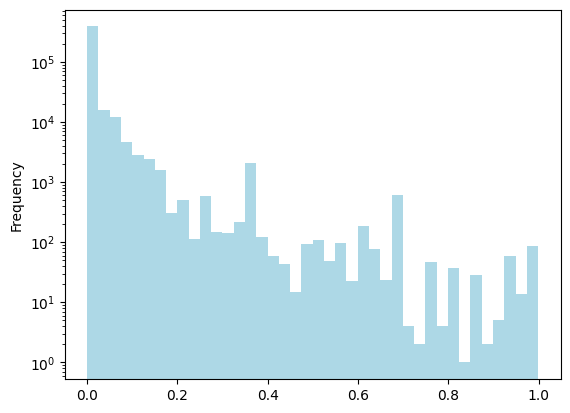

In [624]:
def ratioibkizi(visaint):
    if visaint.compania != 'OTROS':
        return visaint['ratio1'] #llave 1
    elif visaint.compania == 'OTROS':
        if visaint['ratio2'] != 0:
            return visaint['ratio2']
        else:
            return visaint['ratio3']

visaint['Mercado estimado inicial'] = visaint.apply(lambda x: ratioibkizi(x), axis=1)
visaint['Mercado estimado inicial'] = visaint['Mercado estimado inicial'].astype('float')
visaint.loc[visaint['Mercado estimado inicial'] < 0, 'Mercado estimado inicial'] = 0
visaint['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)
visaint['Mercado estimado inicial'].plot(kind='hist', log=True, bins=40, color='lightblue')
plt.show()

In [625]:
visaint.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.12,0.12
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00


In [626]:
visaint['Mercado estimado inicial'].value_counts()

,count
Mercado estimado inicial,
0.00,307576
0.01,15941
0.01,4480
0.01,4207
0.01,4033
...,...
0.01,1
0.01,1
0.03,1


In [627]:
visaint.query('`Mercado estimado inicial`<0.05 & `Mercado estimado inicial`>0')

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial
6,100000000_2REIS,0,1,0,1131,NaN,NaN,NaN,2REIS,RETAIL,Fisico,OTROS,LIMA,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812LIMA,100000000_2REISFisico5812LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.01,0.01
9,100000000_360 GRADOS,0,1,0,11111,NaN,NaN,NaN,360 GRADOS,RETAIL,Fisico,OTROS,JUNIN,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812JUNIN,100000000_360 GRADOSFisico5812JUNIN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
10,100000000_365 MINI MA,0,1,0,1111,NaN,NaN,NaN,365 MINI MA,RETAIL,Fisico,OTROS,UCAYALI,5411,Supermercados,GRUPO 1 - SUPERMERCADOS / HOGAR,100000000,NaN,ND,NaN,RETAILFisico5411UCAYALI,100000000_365 MINI MAFisico5411UCAYALI,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
12,100000000_3B AESTHETIC,0,1,0,1,NaN,NaN,NaN,3B AESTHETIC,RETAIL,Fisico,OTROS,JUNIN,5611,Ropa para hombres,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5611JUNIN,100000000_3B AESTHETICFisico5611JUNIN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
13,100000000_3E FISIOTER,0,1,0,112113111121,NaN,NaN,NaN,3E FISIOTER,RETAIL,Fisico,OTROS,LIMA,7230,Peluquerias,GRUPO 6 - SERVICIOS / AUTOS,100000000,NaN,ND,NaN,RETAILFisico7230LIMA,100000000_3E FISIOTERFisico7230LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.04,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430648,9999,0,1,0,112111111111,NaN,NaN,NaN,ASTORIA BAKERY,RETAIL,Fisico,OTROS,AREQUIPA,5814,Comida rapida,GRUPO 3 - RESTAURANTES,NaN,NaN,ND,NaN,RETAILFisico5814AREQUIPA,9999Fisico5814AREQUIPA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
430650,999922001,0,1,0,111,NaN,10099922091,MARIA DEL PILAR CHERO CABRERA,EUZ PET VET,RETAIL,Fisico,OTROS,LIMA,5995,Mascotas y accesorios,GRUPO 2 - ROPA / ACCESORIOS,NaN,NaN,ND,10099922091Fisico5995LIMA,RETAILFisico5995LIMA,999922001Fisico5995LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.01,0.01
430654,99994,0,1,0,111,NaN,NaN,NaN,MAR Y OLAS,RETAIL,Fisico,OTROS,LIMA,5812,Restaurantes,GRUPO 3 - RESTAURANTES,NaN,NaN,ND,NaN,RETAILFisico5812LIMA,99994Fisico5812LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.01,0.01
430656,999992801_ANA ESTILIS,0,1,0,11211,NaN,NaN,NaN,ANA ESTILIS,RETAIL,Fisico,OTROS,LIMA,7230,Peluquerias,GRUPO 6 - SERVICIOS / AUTOS,999992801,NaN,ND,NaN,RETAILFisico7230LIMA,999992801_ANA ESTILISFisico7230LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.04,0.04


In [628]:
visacred.columns

Index(['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'razsoc', 'nombrecomercial', 'cartera', 'tipoproducto', 'compania',
       'dpto', 'mcc', 'giro', 'vertical', 'bolsa', 'facilitador',
       'detalle_compania', 'llave1', 'llave2', 'llave3', 'tarjeta', 'marca',
       'Importe Data IBK', 'Importe Data Amex', 'Importe Total Izipay',
       'Importe IBK en Izipay', 'Importe IBK en Enrut',
       'Importe Total Izipay S/OnUs', 'Importe IBK en Izipay S/OnUs',
       'ratioibkllave1', 'ratioibkllave2', 'ratioibkllave3',
       'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut', 'ratioibkonusllave1',
       'ratioibkonusllave2', 'ratioibkonusllave3',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],
      dtype='object')

In [629]:
visaint.shape

(433373, 38)

In [630]:
visaint.drop_duplicates(inplace = True)
visadeb.drop_duplicates(inplace = True)
visacred.drop_duplicates(inplace = True)

In [631]:
# unión con mercado estimado final de visa deb y visa cred
visaint = visaint.merge(visacred[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa cred'}), on='codigo', how='left')
visaint.drop_duplicates(inplace=True)
visaint = visaint.merge(visadeb[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa deb'}), on='codigo', how='left'  )
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial,Mercado estimado final visa cred,Mercado estimado final visa deb
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,155.89
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,989.76
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.12,0.12,0.00,109911.36
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,890.78
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,107.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,918.83,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


In [632]:
visaint.drop_duplicates(inplace = True)

In [633]:
visaint['Mercado estimado inicial'] = visaint['Mercado estimado inicial'] * (visaint['Mercado estimado final visa deb'] + visaint['Mercado estimado final visa cred'])
visaint['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial,Mercado estimado final visa cred,Mercado estimado final visa deb
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,155.89
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,989.76
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.12,12869.66,0.00,109911.36
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,890.78
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,107.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433366,999999_ZONAZUL CCO SANTAFE 12 3,0,1,0,1,NaN,NaN,NaN,ONAZUL CCO SANTAFE 12 3,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999None,999999_ZONAZUL CCO SANTAFE 12 3Fisico9999None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,1446.80,0.00
433367,999999_ZYROPE CAFE 9 4,0,1,0,3,NaN,NaN,NaN,YROPE CAFE 9 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE 9 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,1695.37,0.00
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,918.83,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


In [634]:
visaint.sample(5)

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial,Mercado estimado final visa cred,Mercado estimado final visa deb
334244,651019933_PROFESSIONAL MANAG,0,1,0,11,NaN,NaN,NaN,PROFESSIONAL MANAG,RETAIL,Virtual,OTROS,PIURA,5812,Restaurantes,GRUPO 3 - RESTAURANTES,651019933,CULQI,CULQI,NaN,RETAILVirtual5812PIURA,651019933_PROFESSIONAL MANAGVirtual5812PIURA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.02,98.14,0.00,5345.29
12637,10008506_TOSCANA TRA,0,1,0,11,NaN,NaN,NaN,TOSCANA TRA,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,10008506,NaN,ND,NaN,RETAILFisico5812None,10008506_TOSCANA TRAFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,5699.35
61804,185688,0,1,0,211211112111111111,NaN,NaN,NaN,PERFORMANCE AUTOMOTRIZ,NEG,Fisico,OTROS,LIMA,7538,AUTOMOTIVE SERVICE SHOPS,GRUPO 6 - SERVICIOS / AUTOS,NaN,NaN,ND,NaN,NEGFisico7538LIMA,185688Fisico7538LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,92347.49,0.00
77293,200000000_ILKA SYSTEM,0,1,0,1111111,NaN,NaN,NaN,LKA SYSTEM,RETAIL,Fisico,OTROS,CAJAMARCA,7379,MANTENIMIENTO Y REPARACIÃ“N DE COMPUTADORAS (NO,GRUPO 6 - SERVICIOS / AUTOS,200000000,NaN,ND,NaN,RETAILFisico7379CAJAMARCA,200000000_ILKA SYSTEMFisico7379CAJAMARCA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3365.01
153867,5432675,1,0,0,0,NaN,10726222164,Cabrera Tasayco Fiorella Del Pilar,FIORELLA DEL PILAR CABRERA TASAYCO,RETAIL,Fisico,IZIPAY,LIMA,8021,"Dentistas, Ortodoncistas",GRUPO 4 - SALUD,NaN,IZI,IZIPAY,10726222164Fisico8021LIMA,RETAILFisico8021LIMA,5432675Fisico8021LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.08,0.00,2923.00,0.00


In [635]:
visaint.drop(columns=['Mercado estimado final visa cred', 'Mercado estimado final visa deb'], inplace=True)
visaint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratio1,ratio2,ratio3,Mercado estimado inicial
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.12,12869.66
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433366,999999_ZONAZUL CCO SANTAFE 12 3,0,1,0,1,NaN,NaN,NaN,ONAZUL CCO SANTAFE 12 3,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999None,999999_ZONAZUL CCO SANTAFE 12 3Fisico9999None,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
433367,999999_ZYROPE CAFE 9 4,0,1,0,3,NaN,NaN,NaN,YROPE CAFE 9 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE 9 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Visa,0,0,NaN,0,0,NaN,0,0,0,0,0.00,0.00,0.00,0.00


In [636]:
visaint['Mercado estimado final'] = visaint.apply(lambda x: x['Mercado estimado inicial'] if x['Mercado estimado inicial'] > x['Importe Total Izipay'] else x['Importe Total Izipay'], axis=1)

In [637]:
print(visaint.shape, visaint.codigo.nunique())

(433371, 39) 433369


In [638]:
visaint['Mercado estimado final'].sum() # en 202306: 186698194

np.float64(172841798.93000048)

## Base Mastercard

### Base Mastercard débito <a id="section_4_6"></a>

In [639]:
# campos artificiales
mcdeb = df.copy()
mcdeb['tarjeta'] = 'TD'
mcdeb['marca'] = 'Mastercard'
mcdeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Mastercard
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Mastercard
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Mastercard
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Mastercard
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Mastercard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Mastercard
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Mastercard
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard


In [640]:
# Importe Data IBK
mcdeb['Importe Data IBK'] = 0

In [641]:
# Importe Data Amex
mcdeb['Importe Data Amex'] = 0

In [642]:
# Importe Total Izipay
temp = izi.query('marca=="Mastercard"').query('emisor=="Local"').query('tipotarjeta=="Débito" | tipotarjeta=="-"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
mcdeb = mcdeb.merge(temp, on='codigo', how='left')
mcdeb['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
mcdeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Mastercard,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Mastercard,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Mastercard,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Mastercard,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Mastercard,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Mastercard,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00


In [643]:
izi.query('marca=="Mastercard"').query('emisor=="Local"').query('tipotarjeta=="Débito" | tipotarjeta=="-"')['monto'].sum()

np.float64(118411145.87000002)

In [644]:
mcdeb['Importe Total Izipay'].sum()

np.float64(118411145.87000005)

In [645]:
# Importe IBK en Izipay
mcdeb['Importe IBK en Izipay'] = 0

In [646]:
# Importe IBK en Enrut
mcdeb['Importe IBK en Enrut'] = 0

In [647]:
# Importe Total Izipay S/OnUs
mcdeb['Importe Total Izipay S/OnUs'] = 0

In [648]:
# Importe IBK en Izipay S/OnUs
mcdeb['Importe IBK en Izipay S/OnUs'] = 0

In [649]:
# Ratio IBK en IZIPAY
mcdeb['Ratio IBK en IZIPAY'] = 0

In [650]:
# Ratio IBK en Enrut
mcdeb['Ratio IBK en Enrut'] = 0

In [651]:
# Ratio IBK en IZIPAY S/OnUs
mcdeb['Ratio IBK en IZIPAY S/OnUs'] = 0

In [652]:
# llave1 (se validaron ciertos códigos)

# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa1'] = temp['Mastercard'] / temp['Visa']

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiomastervisa1']>1, 'ratiomastervisa1'] = ratio
temp.loc[temp['ratiomastervisa1']<0, 'ratiomastervisa1'] = 0
temp

0.03374577511882294


marca,codigo,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiomastervisa1,llave3
0,1000010,Fisico,5511,LIMA,0.00,NaN,47005.95,0.00,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,677.10,NaN,19272.46,0.04,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,4476.73,NaN,159863.60,0.03,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,1131.33,13.80,34161.15,0.03,1000083Fisico5300LIMA
4,1000096,Fisico,5300,ANCASH,0.00,NaN,14.10,0.00,1000096Fisico5300ANCASH
...,...,...,...,...,...,...,...,...,...
138949,9998206,Virtual,5046,LIMA,0.00,49.00,12245.90,0.00,9998206Virtual5046LIMA
138950,9998875,Virtual,8999,LIMA,275.00,17.00,55469.50,0.00,9998875Virtual8999LIMA
138951,9999342,Virtual,5499,JUNIN,0.00,NaN,9.00,0.00,9999342Virtual5499JUNIN
138952,9999359,Virtual,5046,LIMA,0.00,NaN,8.80,0.00,9999359Virtual5046LIMA


In [653]:
mcdeb = mcdeb.merge(temp[['ratiomastervisa1', 'llave3']], on='llave3', how='left')
mcdeb['ratiomastervisa1'].replace(np.nan, 0, inplace=True)
mcdeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiomastervisa1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00


In [654]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa2'] = temp['Mastercard'] / temp['Visa']

# total
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiomastervisa2']>1, 'ratiomastervisa2'] = ratio
temp.loc[temp['ratiomastervisa2']<0, 'ratiomastervisa2'] = 0
temp

0.03374577511882296


marca,nroruc,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiomastervisa2,llave1
0,10000108338,Fisico,5451,UCAYALI,199.50,41.50,10978.60,0.02,10000108338Fisico5451UCAYALI
1,10000111959,Fisico,7230,UCAYALI,0.00,NaN,188.00,0.00,10000111959Fisico7230UCAYALI
2,10000201168,Fisico,5812,UCAYALI,0.00,NaN,78.00,0.00,10000201168Fisico5812UCAYALI
3,10000220804,Fisico,5947,UCAYALI,0.00,NaN,0.10,0.00,10000220804Fisico5947UCAYALI
4,10000276389,Fisico,5812,UCAYALI,0.00,NaN,54.00,0.00,10000276389Fisico5812UCAYALI
...,...,...,...,...,...,...,...,...,...
100892,9989627,Fisico,5199,LIMA,0.00,NaN,213.70,0.00,9989627Fisico5199LIMA
100893,9993209,Fisico,5331,LIMA,0.00,NaN,50.00,0.00,9993209Fisico5331LIMA
100894,9994033,Virtual,5499,LIMA,0.00,11.00,43.50,0.00,9994033Virtual5499LIMA
100895,9995282,Fisico,5651,LIMA,0.00,NaN,4950.00,0.00,9995282Fisico5651LIMA


In [655]:
mcdeb = mcdeb.merge(temp[['ratiomastervisa2', 'llave1']], on='llave1', how='left')
mcdeb['ratiomastervisa2'].replace(np.nan, 0, inplace=True)
mcdeb

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiomastervisa1,ratiomastervisa2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00


In [656]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa3'] = temp['Mastercard'] / temp['Visa']

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)
temp.loc[temp['ratiomastervisa3']>1, 'ratiomastervisa3'] = ratio
temp.loc[temp['ratiomastervisa3']<0, 'ratiomastervisa3'] = 0
temp

0.03374577511882297


marca,cartera,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiomastervisa3,llave2
0,BC,Fisico,0780,ANCASH,288.00,32.17,64510.95,0.00,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,6231.19,NaN,81827.52,0.08,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,0.00,NaN,20563.60,0.00,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,0.00,NaN,31317.64,0.00,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,1397.07,NaN,10594.26,0.13,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...
6992,RETAIL,Virtual,8999,PUNO,0.00,NaN,2671.00,0.00,RETAILVirtual8999PUNO
6993,RETAIL,Virtual,8999,SAN MARTIN,9.00,NaN,895.00,0.01,RETAILVirtual8999SAN MARTIN
6994,RETAIL,Virtual,8999,TACNA,2530.00,NaN,0.00,0.03,RETAILVirtual8999TACNA
6995,RETAIL,Virtual,8999,TUMBES,0.00,NaN,1.00,0.00,RETAILVirtual8999TUMBES


In [657]:
mcdeb = mcdeb.merge(temp[['ratiomastervisa3', 'llave2']], on='llave2', how='left')
mcdeb['ratiomastervisa3'].replace(np.nan, 0, inplace=True)
temp

marca,cartera,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiomastervisa3,llave2
0,BC,Fisico,0780,ANCASH,288.00,32.17,64510.95,0.00,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,6231.19,NaN,81827.52,0.08,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,0.00,NaN,20563.60,0.00,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,0.00,NaN,31317.64,0.00,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,1397.07,NaN,10594.26,0.13,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...
6992,RETAIL,Virtual,8999,PUNO,0.00,NaN,2671.00,0.00,RETAILVirtual8999PUNO
6993,RETAIL,Virtual,8999,SAN MARTIN,9.00,NaN,895.00,0.01,RETAILVirtual8999SAN MARTIN
6994,RETAIL,Virtual,8999,TACNA,2530.00,NaN,0.00,0.03,RETAILVirtual8999TACNA
6995,RETAIL,Virtual,8999,TUMBES,0.00,NaN,1.00,0.00,RETAILVirtual8999TUMBES


In [658]:
# Mercado estimado inicial
def mercadoestimadoinicial(mcdeb):
    if mcdeb['compania'] != 'OTROS':
        mercado = mcdeb['ratiomastervisa1'] if (mcdeb['ratiomastervisa1']!=0) else 0
    else:
        if mcdeb['ratiomastervisa2'] != 0:
            mercado = mcdeb['ratiomastervisa2']
        elif mcdeb['ratiomastervisa3'] != 0:
            mercado = mcdeb['ratiomastervisa3']
        else: mercado = 0

    return mercado

mcdeb['Mercado estimado inicial'] = mcdeb.apply(lambda x: mercadoestimadoinicial(x), axis=1)

In [659]:
mcdeb = mcdeb.merge(visadeb[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa deb'}), on='codigo', how='left')

In [660]:
mcdeb['Mercado estimado inicial'] = mcdeb['Mercado estimado inicial'] * mcdeb['Mercado estimado final visa deb']
mcdeb.drop(columns='Mercado estimado final visa deb', inplace=True)

In [661]:
# Mercado estimado final
mcdeb['Mercado estimado final'] = mcdeb.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [662]:
print(mcdeb.shape, mcdeb.codigo.nunique())

(433377, 39) 433369


In [663]:
mcdeb['Mercado estimado final'].sum()

np.float64(150655458.37981403)

In [664]:
mcdeb.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiomastervisa1,ratiomastervisa2,ratiomastervisa3,Mercado estimado inicial,Mercado estimado final
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.06,6376.27,6376.27
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Mastercard,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00


### Base Mastercard crédito <a id="section_4_7"></a>

In [665]:
# campos artificiales
mccred = df.copy()
mccred['tarjeta'] = 'TC'
mccred['marca'] = 'Mastercard'
mccred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Mastercard
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Mastercard
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Mastercard
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Mastercard
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Mastercard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Mastercard
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Mastercard
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard


In [666]:
# Importe Data IBK
mccred['Importe Data IBK'] = 0

In [667]:
# Importe Data Amex
mccred['Importe Data Amex'] = 0

In [668]:
# Importe Total Izipay
temp = izi.query('marca=="Mastercard"').query('emisor=="Local"').query('tipotarjeta=="Crédito"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
mccred = mccred.merge(temp, on='codigo', how='left')
mccred['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
mccred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Mastercard,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Mastercard,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Mastercard,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Mastercard,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Mastercard,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Mastercard,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00


In [669]:
izi.query('marca=="Mastercard"').query('emisor=="Local"').query('tipotarjeta=="Crédito"')['monto'].sum()

np.float64(158056735.37999994)

In [670]:
mccred['Importe Total Izipay'].sum()

np.float64(158056735.38000003)

In [671]:
# Importe IBK en Izipay
mccred['Importe IBK en Izipay'] = 0

In [672]:
# Importe IBK en Enrut
mccred['Importe IBK en Enrut'] = 0

In [673]:
# Importe Total Izipay S/OnUs
temp = izi.query('marca=="Mastercard"').query('emisor=="Local"').query('tipotarjeta=="Crédito"').query('onus!="On us"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay S/OnUs'}, inplace=True)
mccred = mccred.merge(temp, on='codigo', how='left')
mccred['Importe Total Izipay S/OnUs'].replace(np.nan, 0, inplace=True)
mccred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Mastercard,0,0,0.00,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Mastercard,0,0,0.00,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Mastercard,0,0,0.00,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Mastercard,0,0,0.00,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00


In [674]:
# Importe IBK en Izipay S/OnUs
mccred['Importe IBK en Izipay S/OnUs'] = 0

In [675]:
# Ratio IBK en IZIPAY
mccred['Ratio IBK en IZIPAY'] = 0

In [676]:
# Ratio IBK en Enrut
mccred['Ratio IBK en Enrut'] = 0

In [677]:
# Ratio IBK en IZIPAY S/OnUs
mccred['Ratio IBK en IZIPAY S/OnUs'] = 0

In [678]:
# llave1

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa1'] = temp['Mastercard'] / temp['Visa']

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiomastervisa1']>1, 'ratiomastervisa1'] = ratio
temp.loc[temp['ratiomastervisa1']<0, 'ratiomastervisa1'] = 0
temp

0.08394443883664482


marca,codigo,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,ratiomastervisa1,llave3
0,1000010,Fisico,5511,LIMA,398.50,31122.00,191.20,14585.40,0.01,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,449.62,1980.45,540.75,18096.24,0.03,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,7981.27,4498.80,7997.55,115190.88,0.07,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,945.24,985.34,1867.70,7107.73,0.26,1000083Fisico5300LIMA
4,1000096,Fisico,5300,ANCASH,NaN,NaN,35.00,95.60,0.37,1000096Fisico5300ANCASH
...,...,...,...,...,...,...,...,...,...,...
160979,9994270,Virtual,5812,LIMA,NaN,NaN,0.00,131.50,0.00,9994270Virtual5812LIMA
160980,9997386,Virtual,1799,LIMA,NaN,NaN,0.00,800.00,0.00,9997386Virtual1799LIMA
160981,9998206,Virtual,5046,LIMA,187.00,NaN,0.00,0.00,NaN,9998206Virtual5046LIMA
160982,9998875,Virtual,8999,LIMA,NaN,NaN,0.00,328.00,0.00,9998875Virtual8999LIMA


In [679]:
mccred = mccred.merge(temp[['ratiomastervisa1', 'llave3']], on='llave3', how='left')
mccred['ratiomastervisa1'].replace(np.nan, 0, inplace=True)
mccred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiomastervisa1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00


In [680]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa2'] = temp['Mastercard'] / temp['Visa']

# llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)
temp.loc[temp['ratiomastervisa2']>1, 'ratiomastervisa2'] = ratio
temp.loc[temp['ratiomastervisa2']<0, 'ratiomastervisa2'] = 0
temp

0.0839444388366448


marca,nroruc,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,ratiomastervisa2,llave1
0,,Fisico,5812,LIMA,1720.50,208.00,0.00,0.00,NaN,Fisico5812LIMA
1,10000030843,Virtual,5812,UCAYALI,NaN,NaN,40.00,0.00,0.08,10000030843Virtual5812UCAYALI
2,10000108338,Fisico,5451,UCAYALI,30.50,NaN,57.00,698.00,0.08,10000108338Fisico5451UCAYALI
3,10000111959,Fisico,7230,UCAYALI,39.00,NaN,140.00,596.00,0.23,10000111959Fisico7230UCAYALI
4,10000112530,Fisico,5812,JUNIN,NaN,NaN,0.00,255.70,0.00,10000112530Fisico5812JUNIN
...,...,...,...,...,...,...,...,...,...,...
121972,9997155,Fisico,8021,LIMA,NaN,NaN,1750.00,1100.00,0.08,9997155Fisico8021LIMA
121973,9997210,Fisico,7531,LIMA,1500.00,NaN,0.00,370.00,0.00,9997210Fisico7531LIMA
121974,9998513,Fisico,7230,LIMA,168.00,NaN,130.00,256.00,0.51,9998513Fisico7230LIMA
121975,9998907,Fisico,8011,LIMA,2450.00,675.00,0.00,0.00,NaN,9998907Fisico8011LIMA


In [681]:
mccred = mccred.merge(temp[['ratiomastervisa2', 'llave1']], on='llave1', how='left')
mccred['ratiomastervisa2'].replace(np.nan, 0, inplace=True)
temp

marca,nroruc,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,ratiomastervisa2,llave1
0,,Fisico,5812,LIMA,1720.50,208.00,0.00,0.00,NaN,Fisico5812LIMA
1,10000030843,Virtual,5812,UCAYALI,NaN,NaN,40.00,0.00,0.08,10000030843Virtual5812UCAYALI
2,10000108338,Fisico,5451,UCAYALI,30.50,NaN,57.00,698.00,0.08,10000108338Fisico5451UCAYALI
3,10000111959,Fisico,7230,UCAYALI,39.00,NaN,140.00,596.00,0.23,10000111959Fisico7230UCAYALI
4,10000112530,Fisico,5812,JUNIN,NaN,NaN,0.00,255.70,0.00,10000112530Fisico5812JUNIN
...,...,...,...,...,...,...,...,...,...,...
121972,9997155,Fisico,8021,LIMA,NaN,NaN,1750.00,1100.00,0.08,9997155Fisico8021LIMA
121973,9997210,Fisico,7531,LIMA,1500.00,NaN,0.00,370.00,0.00,9997210Fisico7531LIMA
121974,9998513,Fisico,7230,LIMA,168.00,NaN,130.00,256.00,0.51,9998513Fisico7230LIMA
121975,9998907,Fisico,8011,LIMA,2450.00,675.00,0.00,0.00,NaN,9998907Fisico8011LIMA


In [682]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp[['Mastercard', 'Visa']] = temp[['Mastercard', 'Visa']].fillna(0)

# ratio
temp['ratiomastervisa3'] = temp['Mastercard'] / temp['Visa']

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Mastercard'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiomastervisa3']>1, 'ratiomastervisa3'] = ratio
temp.loc[temp['ratiomastervisa3']<0, 'ratiomastervisa3'] = 0
temp

0.0839444388366448


marca,cartera,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,ratiomastervisa3,llave2
0,BC,Fisico,0780,ANCASH,2424.00,680.80,40543.15,19150.71,0.08,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,26574.81,NaN,5003.20,158354.20,0.03,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,1446.00,NaN,97.00,906.00,0.11,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,1568.40,NaN,146.00,18927.16,0.01,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,NaN,NaN,0.00,14083.10,0.00,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...,...
7285,RETAIL,Virtual,8999,PUNO,NaN,NaN,0.00,4900.00,0.00,RETAILVirtual8999PUNO
7286,RETAIL,Virtual,8999,SAN MARTIN,NaN,NaN,1289.00,9720.00,0.13,RETAILVirtual8999SAN MARTIN
7287,RETAIL,Virtual,8999,TACNA,491.00,NaN,0.00,1076.20,0.00,RETAILVirtual8999TACNA
7288,RETAIL,Virtual,8999,TUMBES,5000.00,NaN,0.00,2500.00,0.00,RETAILVirtual8999TUMBES


In [683]:
mccred = mccred.merge(temp[['ratiomastervisa3', 'llave2']], on='llave2', how='left')
mccred['ratiomastervisa3'].replace(np.nan, 0, inplace=True)
mccred

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiomastervisa1,ratiomastervisa2,ratiomastervisa3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.12
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Mastercard,0,0,0.00,0,0,0.00,0,0,0,0,0.00,0.00,0.00


In [684]:
# Mercado estimado inicial
def mercadoestimadoinicial(mccred):
    if mccred['compania'] != 'OTROS':
        mercado = mccred['ratiomastervisa1'] if (mccred['ratiomastervisa1']!=0) else 0
    else:
        if mccred['ratiomastervisa2'] != 0:
            mercado = mccred['ratiomastervisa2']
        elif mccred['ratiomastervisa3'] != 0:
            mercado = mccred['ratiomastervisa3']
        else: mercado = 0
    return mercado

mccred['Mercado estimado inicial'] = mccred.apply(lambda x: mercadoestimadoinicial(x), axis=1)
mccred['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)

In [685]:
mccred = mccred.merge(visacred[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa cred'}), on='codigo', how='left')

In [686]:
mccred['Mercado estimado inicial'] = mccred['Mercado estimado inicial'] * mccred['Mercado estimado final visa cred']
mccred.drop(columns='Mercado estimado final visa cred', inplace=True)

In [687]:
# Mercado estimado final
mccred['Mercado estimado final'] = mccred.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [688]:
print(mccred.shape, mccred.codigo.nunique())

(433377, 39) 433369


In [689]:
mccred['Mercado estimado final'].sum() # en 202306 540873900

np.float64(244760483.4575026)

### Base Mastercard internacional <a id="section_4_8"></a>

In [690]:
# campos artificiales
mcint = df.copy()
mcint['tarjeta'] = 'F'
mcint['marca'] = 'Mastercard'
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard


In [691]:
# Importe Data IBK
mcint['Importe Data IBK'] = 0

In [692]:
# Importe Data Amex
mcint['Importe Data Amex'] = 0

In [693]:
# Importe Total Izipay
temp = izi.query('marca=="Mastercard"').query('emisor=="Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
mcint = mcint.merge(temp, on='codigo', how='left')
mcint['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00


In [694]:
# Importe IBK en Izipay
temp = izi.query('marca=="Mastercard"').query('emisor=="Internacional"').query('banco=="IBK"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe IBK en Izipay'}, inplace=True)
mcint = mcint.merge(temp, on='codigo', how='left')
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN


In [695]:
# Importe IBK en Enrut
mcint['Importe IBK en Enrut'] = 0

In [696]:
# Importe Total Izipay S/OnUs
mcint['Importe Total Izipay S/OnUs'] = 0

In [697]:
# Importe IBK en Izipay S/OnUs
mcint['Importe IBK en Izipay S/OnUs'] = 0

In [698]:
# Ratio IBK en IZIPAY
mcint['Ratio IBK en IZIPAY'] = 0

In [699]:
# Ratio IBK en Enrut
mcint['Ratio IBK en Enrut'] = 0

In [700]:
# Ratio IBK en IZIPAY S/OnUs
mcint['Ratio IBK en IZIPAY S/OnUs'] = 0

In [701]:
# llave1 (se validaron ciertos códigos)

# query y agrupación
temp = izi.query('marca=="Mastercard"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratiointtotal1'] = temp['Internacional'] / temp['total']

# ratio total
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratiointtotal1']>1, 'ratiointtotal1'] = ratio
temp.loc[temp['ratiointtotal1']<0, 'ratiointtotal1'] = 0
temp

0.42854427550252727


emisor,codigo,tipoproducto,mcc,dpto,Internacional,Local,total,ratiointtotal1,llave3
0,1000010,Fisico,5511,LIMA,0.00,191.20,191.20,0.00,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,245.65,1217.85,1463.50,0.17,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,1131.00,12474.28,13605.28,0.08,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,0.00,2999.03,2999.03,0.00,1000083Fisico5300LIMA
4,1000096,Fisico,5300,ANCASH,0.00,35.00,35.00,0.00,1000096Fisico5300ANCASH
...,...,...,...,...,...,...,...,...,...
106272,9993813,Virtual,5999,LIMA,0.00,355.00,355.00,0.00,9993813Virtual5999LIMA
106273,9994270,Virtual,5812,LIMA,0.00,145.00,145.00,0.00,9994270Virtual5812LIMA
106274,9996064,Virtual,5499,LA LIBERTAD,0.00,14.00,14.00,0.00,9996064Virtual5499LA LIBERTAD
106275,9997783,Virtual,5046,LIMA,0.00,16.50,16.50,0.00,9997783Virtual5046LIMA


In [702]:
mcint = mcint.merge(temp[['ratiointtotal1', 'llave3']], on='llave3', how='left')
mcint['ratiointtotal1'].replace(np.nan, 0, inplace=True)
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiointtotal1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00


In [703]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Mastercard"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratiointtotal2'] = temp['Internacional'] / temp['total']

# ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()

temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']
temp.loc[temp['ratiointtotal2']>1, 'ratiointtotal2'] = ratio
temp.loc[temp['ratiointtotal2']<0, 'ratiointtotal2'] = 0
temp

emisor,nroruc,tipoproducto,mcc,dpto,Internacional,Local,total,ratiointtotal2,llave1
0,10000030843,Virtual,5812,UCAYALI,0.00,40.00,40.00,0.00,10000030843Virtual5812UCAYALI
1,10000108338,Fisico,5451,UCAYALI,4.00,256.50,260.50,0.02,10000108338Fisico5451UCAYALI
2,10000111959,Fisico,7230,UCAYALI,0.00,140.00,140.00,0.00,10000111959Fisico7230UCAYALI
3,10000113234,Virtual,5921,LIMA,7504.00,0.00,7504.00,1.00,10000113234Virtual5921LIMA
4,10000276389,Fisico,5812,UCAYALI,0.00,59.00,59.00,0.00,10000276389Fisico5812UCAYALI
...,...,...,...,...,...,...,...,...,...
74272,9988546,Fisico,5812,LIMA,0.00,138.00,138.00,0.00,9988546Fisico5812LIMA
74273,9988793,Fisico,7299,LIMA,546.00,1428.00,1974.00,0.28,9988793Fisico7299LIMA
74274,9993209,Fisico,5331,LIMA,1460.00,50.00,1510.00,0.97,9993209Fisico5331LIMA
74275,9997155,Fisico,8021,LIMA,7950.00,1750.00,9700.00,0.82,9997155Fisico8021LIMA


In [704]:
mcint = mcint.merge(temp[['ratiointtotal2', 'llave1']], on='llave1', how='left')
mcint['ratiointtotal2'].replace(np.nan, 0, inplace=True)
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiointtotal1,ratiointtotal2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00


In [705]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Mastercard"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratiointtotal3'] = temp['Internacional'] / temp['total']

# ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']
temp.loc[temp['ratiointtotal3']>1, 'ratiointtotal3'] = ratio
temp.loc[temp['ratiointtotal3']<0, 'ratiointtotal3'] = 0
temp

emisor,cartera,tipoproducto,mcc,dpto,Internacional,Local,total,ratiointtotal3,llave2
0,BC,Fisico,0780,ANCASH,0.00,40831.15,40831.15,0.00,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,2940.00,11234.39,14174.39,0.21,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,0.00,97.00,97.00,0.00,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,0.00,146.00,146.00,0.00,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,0.00,1397.07,1397.07,0.00,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...
5666,RETAIL,Virtual,8999,MADRE DE DIOS,0.00,800.00,800.00,0.00,RETAILVirtual8999MADRE DE DIOS
5667,RETAIL,Virtual,8999,PIURA,702.61,16145.38,16847.99,0.04,RETAILVirtual8999PIURA
5668,RETAIL,Virtual,8999,SAN MARTIN,620.51,1298.00,1918.51,0.32,RETAILVirtual8999SAN MARTIN
5669,RETAIL,Virtual,8999,TACNA,464.44,2530.00,2994.44,0.16,RETAILVirtual8999TACNA


In [706]:
mcint = mcint.merge(temp[['ratiointtotal3', 'llave2']], on='llave2', how='left')
mcint['ratiointtotal3'].replace(np.nan, 0, inplace=True)
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiointtotal1,ratiointtotal2,ratiointtotal3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.12
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00


In [707]:
# Mercado estimado inicial
def mercadoestimadoinicial(mcint):
    if mcint['compania'] != 'OTROS':
        mercado = mcint['ratiointtotal1'] if (mcint['ratiointtotal1']!=0) else 0
    else:
        if mcint['ratiointtotal2'] != 0:
            mercado = mcint['ratiointtotal2']
        elif mcint['ratiointtotal3'] != 0:
            mercado = mcint['ratiointtotal3']
        else: mercado = 0

    return mercado

mcint['Mercado estimado inicial'] = mcint.apply(lambda x: mercadoestimadoinicial(x), axis=1)

<Axes: ylabel='Frequency'>

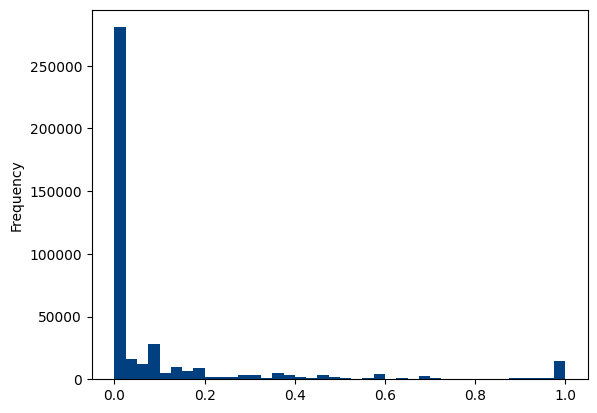

In [708]:
mcint['Mercado estimado inicial'].plot(kind='hist', bins=40)

In [709]:
print(mcint.shape, mcint.codigo.nunique())

(433373, 38) 433369


In [710]:
print(mcdeb.shape, mcdeb.codigo.nunique())

(433377, 39) 433369


In [711]:
print(mccred.shape, mccred.codigo.nunique())

(433377, 39) 433369


In [712]:
mccred.drop_duplicates(inplace =True)
mcdeb.drop_duplicates(inplace =True)
mcint.drop_duplicates(inplace =True)

In [713]:
mcint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiointtotal1,ratiointtotal2,ratiointtotal3,Mercado estimado inicial
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.12,0.12
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433366,999999_ZONAZUL CCO SANTAFE 12 3,0,1,0,1,NaN,NaN,NaN,ONAZUL CCO SANTAFE 12 3,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999None,999999_ZONAZUL CCO SANTAFE 12 3Fisico9999None,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
433367,999999_ZYROPE CAFE 9 4,0,1,0,3,NaN,NaN,NaN,YROPE CAFE 9 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE 9 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Mastercard,0,0,0.00,NaN,0,0,0,0,0,0,0.00,0.00,0.00,0.00


In [714]:
# Remove duplicates and assign to a new DataFrame
mcdeb_clean = mcdeb[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final mcdeb'}).drop_duplicates()
mccred_clean = mccred[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final mccred'}).drop_duplicates()

# Merge the DataFrames
mcint = mcint.merge(mcdeb_clean, on='codigo')
mcint = mcint.drop_duplicates()
mcint = mcint.merge(mccred_clean, on='codigo')
mcint['Mercado estimado inicial'] = mcint['Mercado estimado inicial'] * (mcint['Mercado estimado final mcdeb'] + mcint['Mercado estimado final mccred'])

In [715]:
mcint['Mercado estimado final'] = mcint.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [716]:
print(mcint.shape, mcint.codigo.nunique())

(433371, 41) 433369


In [717]:
mcint['Mercado estimado final'].sum() # 124235749 en 202306

np.float64(135901389.31252035)

## Base Diners

### Base Diners local <a id="section_4_9"></a>

In [718]:
# campos artificiales
dinloc = df.copy()
dinloc['tarjeta'] = 'TC'
dinloc['marca'] = 'Diners'
dinloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Diners
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Diners
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Diners
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Diners
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Diners
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Diners
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Diners
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners


In [719]:
# Importe Data IBK
dinloc['Importe Data IBK'] = 0

In [720]:
# Importe Data Amex
dinloc['Importe Data Amex'] = 0

In [721]:
# Importe Total Izipay
temp = izi.query('marca=="Diners"').query('emisor=="Local" | emisor=="Otros"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
dinloc = dinloc.merge(temp, on='codigo', how='left')
dinloc['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
dinloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Diners,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Diners,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Diners,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Diners,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Diners,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Diners,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00


In [722]:
# Importe IBK en Izipay
dinloc['Importe IBK en Izipay'] = 0

In [723]:
# Importe IBK en Enrut
dinloc['Importe IBK en Enrut'] = 0

In [724]:
# Importe Total Izipay S/OnUs
dinloc['Importe Total Izipay S/OnUs'] = 0

In [725]:
# Importe IBK en Izipay S/OnUs
dinloc['Importe IBK en Izipay S/OnUs'] = 0

In [726]:
# Ratio IBK en IZIPAY
dinloc['Ratio IBK en IZIPAY'] = 0

In [727]:
# Ratio IBK en Enrut
dinloc['Ratio IBK en Enrut'] = 0

In [728]:
# Ratio IBK en IZIPAY S/OnUs
dinloc['Ratio IBK en IZIPAY S/OnUs'] = 0

In [729]:
# Mercado estimado inicial

# llave1 (se validaron ciertos códigos)

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Diners'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)
temp['total'] = temp['Diners'] + temp['Visa']

# ratio
temp['ratiodinersvisa1'] = temp['Diners'] / temp['Visa']

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Diners'].sum() / temp['Visa'].sum()
print(ratio)


temp.loc[temp['ratiodinersvisa1']>1, 'ratiodinersvisa1'] = ratio
temp.loc[temp['ratiodinersvisa1']<0, 'ratiodinersvisa1'] = 0
temp

0.04122077683089314


marca,codigo,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,total,ratiodinersvisa1,llave3
0,1000010,Fisico,5511,LIMA,398.50,31122.00,191.20,14585.40,45707.40,0.04,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,449.62,1980.45,540.75,18096.24,20076.69,0.11,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,7981.27,4498.80,7997.55,115190.88,119689.68,0.04,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,945.24,985.34,1867.70,7107.73,8093.07,0.14,1000083Fisico5300LIMA
4,1000096,Fisico,5300,ANCASH,NaN,0.00,35.00,95.60,95.60,0.00,1000096Fisico5300ANCASH
...,...,...,...,...,...,...,...,...,...,...,...
160979,9994270,Virtual,5812,LIMA,NaN,0.00,NaN,131.50,131.50,0.00,9994270Virtual5812LIMA
160980,9997386,Virtual,1799,LIMA,NaN,0.00,NaN,800.00,800.00,0.00,9997386Virtual1799LIMA
160981,9998206,Virtual,5046,LIMA,187.00,0.00,NaN,0.00,0.00,NaN,9998206Virtual5046LIMA
160982,9998875,Virtual,8999,LIMA,NaN,0.00,NaN,328.00,328.00,0.00,9998875Virtual8999LIMA


In [730]:
dinloc = dinloc.merge(temp[['ratiodinersvisa1', 'llave3']], on='llave3', how='left')
dinloc['ratiodinersvisa1'].replace(np.nan, 0, inplace=True)
dinloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00


In [731]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Diners'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)
temp['total'] = temp['Diners'] + temp['Visa']

# ratio
temp['ratiodinersvisa2'] = temp['Diners'] / temp['Visa']

# llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Diners'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiodinersvisa2']>1, 'ratiodinersvisa2'] = ratio
temp.loc[temp['ratiodinersvisa2']<0, 'ratiodinersvisa2'] = 0
temp

0.04122077683089314


marca,nroruc,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,total,ratiodinersvisa2,llave1
0,,Fisico,5812,LIMA,1720.50,208.00,NaN,0.00,208.00,0.04,Fisico5812LIMA
1,10000030843,Virtual,5812,UCAYALI,NaN,0.00,40.00,0.00,0.00,NaN,10000030843Virtual5812UCAYALI
2,10000108338,Fisico,5451,UCAYALI,30.50,0.00,57.00,698.00,698.00,0.00,10000108338Fisico5451UCAYALI
3,10000111959,Fisico,7230,UCAYALI,39.00,0.00,140.00,596.00,596.00,0.00,10000111959Fisico7230UCAYALI
4,10000112530,Fisico,5812,JUNIN,NaN,0.00,NaN,255.70,255.70,0.00,10000112530Fisico5812JUNIN
...,...,...,...,...,...,...,...,...,...,...,...
121972,9997155,Fisico,8021,LIMA,NaN,0.00,1750.00,1100.00,1100.00,0.00,9997155Fisico8021LIMA
121973,9997210,Fisico,7531,LIMA,1500.00,0.00,NaN,370.00,370.00,0.00,9997210Fisico7531LIMA
121974,9998513,Fisico,7230,LIMA,168.00,0.00,130.00,256.00,256.00,0.00,9998513Fisico7230LIMA
121975,9998907,Fisico,8011,LIMA,2450.00,675.00,NaN,0.00,675.00,0.04,9998907Fisico8011LIMA


In [732]:
dinloc = dinloc.merge(temp[['ratiodinersvisa2', 'llave1']], on='llave1', how='left')
dinloc['ratiodinersvisa2'].replace(np.nan, 0, inplace=True)
dinloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1,ratiodinersvisa2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00


In [733]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Crédito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Diners'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)
temp['total'] = temp['Diners'] + temp['Visa']

# ratio
temp['ratiodinersvisa3'] = temp['Diners'] / temp['Visa']

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Diners'].sum() / temp['Visa'].sum()
print(ratio)

temp.loc[temp['ratiodinersvisa3']>1, 'ratiodinersvisa3'] = ratio
temp.loc[temp['ratiodinersvisa3']<0, 'ratiodinersvisa3'] = 0
temp

0.04122077683089314


marca,cartera,tipoproducto,mcc,dpto,Amex,Diners,Mastercard,Visa,total,ratiodinersvisa3,llave2
0,BC,Fisico,0780,ANCASH,2424.00,680.80,40543.15,19150.71,19831.51,0.04,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,26574.81,0.00,5003.20,158354.20,158354.20,0.00,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,1446.00,0.00,97.00,906.00,906.00,0.00,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,1568.40,0.00,146.00,18927.16,18927.16,0.00,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,NaN,0.00,NaN,14083.10,14083.10,0.00,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...,...,...
7285,RETAIL,Virtual,8999,PUNO,NaN,0.00,NaN,4900.00,4900.00,0.00,RETAILVirtual8999PUNO
7286,RETAIL,Virtual,8999,SAN MARTIN,NaN,0.00,1289.00,9720.00,9720.00,0.00,RETAILVirtual8999SAN MARTIN
7287,RETAIL,Virtual,8999,TACNA,491.00,0.00,NaN,1076.20,1076.20,0.00,RETAILVirtual8999TACNA
7288,RETAIL,Virtual,8999,TUMBES,5000.00,0.00,NaN,2500.00,2500.00,0.00,RETAILVirtual8999TUMBES


In [734]:
dinloc = dinloc.merge(temp[['ratiodinersvisa3', 'llave2']], on='llave2', how='left')
dinloc['ratiodinersvisa3'].replace(np.nan, 0, inplace=True)
dinloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1,ratiodinersvisa2,ratiodinersvisa3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.01
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TC,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00


In [735]:
# Mercado estimado inicial
def mercadoestimadoinicial(dinloc):
    if dinloc['compania'] != 'OTROS':
        mercado = dinloc['ratiodinersvisa1'] if (dinloc['ratiodinersvisa1']!=0) else 0
    else:
        if dinloc['ratiodinersvisa2'] != 0:
            mercado = dinloc['ratiodinersvisa2']
        elif dinloc['ratiodinersvisa3'] != 0:
            mercado = dinloc['ratiodinersvisa3']
        else: mercado = 0

    return mercado

dinloc['Mercado estimado inicial'] = dinloc.apply(lambda x: mercadoestimadoinicial(x), axis=1)
dinloc['Mercado estimado inicial'].replace(np.nan, 0, inplace=True)

In [736]:
dinloc = dinloc.merge(visacred[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa deb'}), on='codigo', how='left')

In [737]:
dinloc['Mercado estimado inicial'] = dinloc['Mercado estimado inicial'] * dinloc['Mercado estimado final visa deb']

In [738]:
dinloc.drop(columns='Mercado estimado final visa deb', inplace=True)

In [739]:
# Mercado estimado final
dinloc['Mercado estimado final'] = dinloc.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [740]:
dinloc = dinloc.loc[~dinloc.duplicated(subset = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical', 'bolsa', 'facilitador', 'detalle_compania',
       'llave1', 'llave2', 'llave3', 'tarjeta', 'marca', 'Importe Data IBK',
       'Importe Data Amex', 'Importe Total Izipay', 'Importe IBK en Izipay',
       'Importe IBK en Enrut', 'Importe Total Izipay S/OnUs',
       'Importe IBK en Izipay S/OnUs', 'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],keep = 'last')]

In [741]:
dinloc['Mercado estimado final'].sum() # en 202306 312654706

np.float64(120442298.07747841)

### Base Diners internacional <a id="section_4_10"></a>

In [742]:
# campos artificiales
dinint = df.copy()
dinint['tarjeta'] = 'F'
dinint['marca'] = 'Diners'
dinint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Diners
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Diners
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Diners
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Diners
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Diners
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Diners
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Diners
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners


In [743]:
# Importe Data IBK
dinint['Importe Data IBK'] = 0

In [744]:
# Importe Data Amex
dinint['Importe Data Amex'] = 0

In [745]:
# Importe Total Izipay
temp = izi.query('marca=="Diners"').query('emisor=="Internacional"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
dinint = dinint.merge(temp, on='codigo', how='left')
dinint['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
dinint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Diners,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Diners,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Diners,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Diners,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Diners,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Diners,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Diners,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00


In [746]:
# Importe IBK en Izipay
dinint['Importe IBK en Izipay'] = 0

In [747]:
# Importe IBK en Enrut
dinint['Importe IBK en Enrut'] = 0

In [748]:
# Importe Total Izipay S/OnUs
dinint['Importe Total Izipay S/OnUs'] = 0

In [749]:
# Importe IBK en Izipay S/OnUs
dinint['Importe IBK en Izipay S/OnUs'] = 0

In [750]:
# Ratio IBK en IZIPAY
dinint['Ratio IBK en IZIPAY'] = 0

In [751]:
# Ratio IBK en Enrut
dinint['Ratio IBK en Enrut'] = 0

In [752]:
# Ratio IBK en IZIPAY S/OnUs
dinint['Ratio IBK en IZIPAY S/OnUs'] = 0

In [753]:
# llave1 (se validaron ciertos códigos)

# query y agrupación
temp = izi.query('marca=="Diners"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# ratio
temp['ratioibk1'] = temp['Internacional'] / temp['Local']

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)

temp.loc[temp['ratioibk1']>1, 'ratioibk1'] = ratio
temp.loc[temp['ratioibk1']<0, 'ratioibk1'] = 0
temp

0.030838810977176907


emisor,codigo,tipoproducto,mcc,dpto,Internacional,Local,ratioibk1,llave3
0,1000010,Fisico,5511,LIMA,0.00,31122.00,0.00,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,0.00,1980.45,0.00,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,0.00,4498.80,0.00,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,0.00,985.34,0.00,1000083Fisico5300LIMA
4,1000341,Fisico,5199,LIMA,0.00,481.40,0.00,1000341Fisico5199LIMA
...,...,...,...,...,...,...,...,...
45392,8999416,Fisico,8021,LIMA,0.00,200.00,0.00,8999416Fisico8021LIMA
45393,8999584,Fisico,7297,LIMA,72.00,212.00,0.34,8999584Fisico7297LIMA
45394,8999906,Fisico,0742,LIMA,0.00,220.00,0.00,8999906Fisico0742LIMA
45395,8999924,Fisico,5331,LIMA,0.00,65.00,0.00,8999924Fisico5331LIMA


In [754]:
dinint = dinint.merge(temp[['ratioibk1', 'llave3']], on='llave3', how='left')
dinint['ratioibk1'].replace(np.nan, 0, inplace=True)
dinint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00


In [755]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Diners"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratioibk2'] = temp['Internacional'] / temp['Local']

# llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)

temp.loc[temp['ratioibk2']>1, 'ratioibk2'] = ratio
temp.loc[temp['ratioibk2']<0, 'ratioibk2'] = 0
temp

0.030838810977176907


emisor,nroruc,tipoproducto,mcc,dpto,Internacional,Local,total,ratioibk2,llave1
0,,Fisico,5812,LIMA,0.00,208.00,208.00,0.00,Fisico5812LIMA
1,10000714327,Fisico,5812,UCAYALI,0.00,130.00,130.00,0.00,10000714327Fisico5812UCAYALI
2,10000792069,Fisico,5812,UCAYALI,0.00,149.00,149.00,0.00,10000792069Fisico5812UCAYALI
3,10000958200,Fisico,5462,UCAYALI,0.00,115.80,115.80,0.00,10000958200Fisico5462UCAYALI
4,10001067449,Fisico,5812,UCAYALI,72.00,0.00,72.00,0.03,10001067449Fisico5812UCAYALI
...,...,...,...,...,...,...,...,...,...
26810,9983123,Fisico,5734,LIMA,0.00,52800.00,52800.00,0.00,9983123Fisico5734LIMA
26811,9985889,Fisico,7230,LIMA,0.00,420.00,420.00,0.00,9985889Fisico7230LIMA
26812,9988546,Fisico,5812,LIMA,0.00,112.00,112.00,0.00,9988546Fisico5812LIMA
26813,9988793,Fisico,7299,LIMA,0.00,273.00,273.00,0.00,9988793Fisico7299LIMA


In [756]:
dinint = dinint.merge(temp[['ratioibk2', 'llave1']], on='llave1', how='left')
dinint['ratioibk2'].replace(np.nan, 0, inplace=True)
dinint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1,ratioibk2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00


In [757]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Diners"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)

# total
temp['total'] = temp['Internacional'] + temp['Local']

# ratio
temp['ratioibk3'] = temp['Internacional'] / temp['Local']

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

# ratio general
ratio = temp['Internacional'].sum() / temp['Local'].sum()
print(ratio)

temp.loc[temp['ratioibk3']>1, 'ratioibk2'] = ratio
temp.loc[temp['ratioibk3']<0, 'ratioibk2'] = 0
temp

0.030838810977176893


emisor,cartera,tipoproducto,mcc,dpto,Internacional,Local,total,ratioibk3,llave2,ratioibk2
0,BC,Fisico,0780,ANCASH,0.00,680.80,680.80,0.00,BCFisico0780ANCASH,NaN
1,BC,Fisico,3030,LIMA,0.00,2559.13,2559.13,0.00,BCFisico3030LIMA,NaN
2,BC,Fisico,3102,LIMA,0.00,609.48,609.48,0.00,BCFisico3102LIMA,NaN
3,BC,Fisico,3509,CUSCO,0.00,9040.11,9040.11,0.00,BCFisico3509CUSCO,NaN
4,BC,Fisico,3509,LIMA,12037.76,3480.70,15518.46,3.46,BCFisico3509LIMA,0.03
...,...,...,...,...,...,...,...,...,...,...
3106,RETAIL,Virtual,8999,AREQUIPA,0.00,12296.00,12296.00,0.00,RETAILVirtual8999AREQUIPA,NaN
3107,RETAIL,Virtual,8999,JUNIN,0.00,1577.00,1577.00,0.00,RETAILVirtual8999JUNIN,NaN
3108,RETAIL,Virtual,8999,LAMBAYEQUE,0.00,7850.00,7850.00,0.00,RETAILVirtual8999LAMBAYEQUE,NaN
3109,RETAIL,Virtual,8999,LIMA,0.00,35640.79,35640.79,0.00,RETAILVirtual8999LIMA,NaN


In [758]:
dinint = dinint.merge(temp[['ratioibk3', 'llave2']], on='llave2', how='left')
dinint['ratioibk3'].replace(np.nan, 0, inplace=True)
dinint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1,ratioibk2,ratioibk3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Diners,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00


In [759]:
# Mercado estimado inicial
def mercadoestimadoinicial(dinint):
    if dinint['compania'] != 'OTROS':
        mercado = dinint['ratioibk1'] if (dinint['ratioibk1']!=0) else 0
    else:
        if dinint['ratioibk2'] != 0:
            mercado = dinint['ratioibk2']
        elif dinint['ratioibk3'] != 0:
            mercado = dinint['ratioibk3']
        else: mercado = 0

    return mercado

dinint['Mercado estimado inicial'] = dinint.apply(lambda x: mercadoestimadoinicial(x), axis=1)

In [760]:
dinint = dinint.merge(dinloc[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final din loc'}))
dinint.drop_duplicates(inplace=True)

In [761]:
dinint['Mercado estimado inicial'] = dinint['Mercado estimado inicial'] * dinint['Mercado estimado final din loc']

In [762]:
dinint.drop(columns='Mercado estimado final din loc', inplace=True)

In [763]:
# Mercado estimado final
dinint['Mercado estimado final'] = dinint.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [764]:
dinint = dinint.loc[~dinint.duplicated(subset = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical', 'bolsa', 'facilitador', 'detalle_compania',
       'llave1', 'llave2', 'llave3', 'tarjeta', 'marca', 'Importe Data IBK',
       'Importe Data Amex', 'Importe Total Izipay', 'Importe IBK en Izipay',
       'Importe IBK en Enrut', 'Importe Total Izipay S/OnUs',
       'Importe IBK en Izipay S/OnUs', 'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'], keep = 'last')]

In [765]:
dinint['Mercado estimado final'].sum() # 202306 1011592

np.float64(3280099.989494499)

## Base Otros

### Base otros local <a id="section_4_11"></a>

In [766]:
# campos artificiales
otrloc = df.copy()
otrloc['tarjeta'] = 'TD'
otrloc['marca'] = 'Otros'
otrloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Otros
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Otros
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Otros
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Otros
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Otros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Otros
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Otros
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros


In [767]:
# Importe Data IBK
otrloc['Importe Data IBK'] = 0

In [768]:
# Importe Data Amex
otrloc['Importe Data Amex'] = 0

In [769]:
# Importe Total Izipay
temp = izi.query('marca=="Otros"').query('emisor=="Local"').query('tipotarjeta=="Débito" | tipotarjeta=="-"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
otrloc = otrloc.merge(temp, on='codigo', how='left')
otrloc['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
otrloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Otros,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Otros,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Otros,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Otros,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Otros,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Otros,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00


In [770]:
# Importe IBK en Izipay
otrloc['Importe IBK en Izipay'] = 0

In [771]:
# Importe IBK en Enrut
otrloc['Importe IBK en Enrut'] = 0

In [772]:
# Importe Total Izipay S/OnUs
otrloc['Importe Total Izipay S/OnUs'] = 0

In [773]:
# Importe IBK en Izipay S/OnUs
otrloc['Importe IBK en Izipay S/OnUs'] = 0

In [774]:
# Ratio IBK en IZIPAY
otrloc['Ratio IBK en IZIPAY'] = 0

In [775]:
# Ratio IBK en Enrut
otrloc['Ratio IBK en Enrut'] = 0

In [776]:
# Ratio IBK en IZIPAY S/OnUs
otrloc['Ratio IBK en IZIPAY S/OnUs'] = 0

In [777]:
# query y agrupación
temp = izi.query('emisor=="Local"').query('tipotarjeta=="Débito" | tipotarjeta=="-"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp

,codigo,tipoproducto,mcc,dpto,marca,monto
0,1000010,Fisico,5511,LIMA,Visa,47005.95
1,1000071,Fisico,5137,LIMA,Mastercard,677.10
2,1000071,Fisico,5137,LIMA,Visa,19272.46
3,1000080,Fisico,5111,AREQUIPA,Mastercard,4476.73
4,1000080,Fisico,5111,AREQUIPA,Visa,159863.60
...,...,...,...,...,...,...
224980,9998875,Virtual,8999,LIMA,Visa,55469.50
224981,9999342,Virtual,5499,JUNIN,Visa,9.00
224982,9999359,Virtual,5046,LIMA,Visa,8.80
224983,9999678,Virtual,5046,LIMA,Otros,606.00


In [778]:
izi['marca'].unique()

array(['Amex', 'Mastercard', 'Visa', 'Diners', 'Otros', None],
      dtype=object)

In [779]:
# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Otros'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)

# ratio
temp['ratiodinersvisa1'] = temp['Otros'] / temp['Visa']

# ratio general
ratio = temp['Otros'].sum() / temp['Visa'].sum()
print(ratio)

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

#temp.loc[temp['ratiodinersvisa1']>1, 'ratiodinersvisa1'] = 1
temp.loc[temp['ratiodinersvisa1']<0, 'ratiodinersvisa1'] = 0
temp.loc[temp['ratiodinersvisa1']>1, 'ratiodinersvisa1'] = ratio
temp

0.001255301016293171


marca,codigo,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiodinersvisa1,llave3
0,1000010,Fisico,5511,LIMA,NaN,0.00,47005.95,0.00,1000010Fisico5511LIMA
1,1000071,Fisico,5137,LIMA,677.10,0.00,19272.46,0.00,1000071Fisico5137LIMA
2,1000080,Fisico,5111,AREQUIPA,4476.73,0.00,159863.60,0.00,1000080Fisico5111AREQUIPA
3,1000083,Fisico,5300,LIMA,1131.33,13.80,34161.15,0.00,1000083Fisico5300LIMA
4,1000096,Fisico,5300,ANCASH,NaN,0.00,14.10,0.00,1000096Fisico5300ANCASH
...,...,...,...,...,...,...,...,...,...
138949,9998206,Virtual,5046,LIMA,NaN,49.00,12245.90,0.00,9998206Virtual5046LIMA
138950,9998875,Virtual,8999,LIMA,275.00,17.00,55469.50,0.00,9998875Virtual8999LIMA
138951,9999342,Virtual,5499,JUNIN,NaN,0.00,9.00,0.00,9999342Virtual5499JUNIN
138952,9999359,Virtual,5046,LIMA,NaN,0.00,8.80,0.00,9999359Virtual5046LIMA


In [780]:
otrloc = otrloc.merge(temp[['ratiodinersvisa1', 'llave3']], on='llave3', how='left')
otrloc['ratiodinersvisa1'].replace(np.nan, 0, inplace=True)
otrloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00


In [781]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Otros'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)

# ratio
temp['ratiodinersvisa2'] = temp['Otros'] / temp['Visa']

# ratio general
ratio = temp['Otros'].sum() / temp['Visa'].sum()

# llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratiodinersvisa2']>1, 'ratiodinersvisa2'] = ratio
temp.loc[temp['ratiodinersvisa2']<0, 'ratiodinersvisa2'] = 0
temp

marca,nroruc,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiodinersvisa2,llave1
0,10000108338,Fisico,5451,UCAYALI,199.50,41.50,10978.60,0.00,10000108338Fisico5451UCAYALI
1,10000111959,Fisico,7230,UCAYALI,NaN,0.00,188.00,0.00,10000111959Fisico7230UCAYALI
2,10000201168,Fisico,5812,UCAYALI,NaN,0.00,78.00,0.00,10000201168Fisico5812UCAYALI
3,10000220804,Fisico,5947,UCAYALI,NaN,0.00,0.10,0.00,10000220804Fisico5947UCAYALI
4,10000276389,Fisico,5812,UCAYALI,NaN,0.00,54.00,0.00,10000276389Fisico5812UCAYALI
...,...,...,...,...,...,...,...,...,...
100892,9989627,Fisico,5199,LIMA,NaN,0.00,213.70,0.00,9989627Fisico5199LIMA
100893,9993209,Fisico,5331,LIMA,NaN,0.00,50.00,0.00,9993209Fisico5331LIMA
100894,9994033,Virtual,5499,LIMA,NaN,11.00,43.50,0.25,9994033Virtual5499LIMA
100895,9995282,Fisico,5651,LIMA,NaN,0.00,4950.00,0.00,9995282Fisico5651LIMA


In [782]:
otrloc = otrloc.merge(temp[['ratiodinersvisa2', 'llave1']], on='llave1', how='left')
otrloc['ratiodinersvisa2'].replace(np.nan, 0, inplace=True)
otrloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1,ratiodinersvisa2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00


In [783]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('tipotarjeta=="Débito" | tipotarjeta=="-"').query('emisor=="Local" | emisor=="Otros"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'marca'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='marca', values='monto').reset_index()
temp['Otros'].replace(np.nan, 0, inplace=True)
temp['Visa'].replace(np.nan, 0, inplace=True)

#ratio
temp['ratiodinersvisa3'] = temp['Otros'] / temp['Visa']

# ratio general
temp['ratiodinersvisa3'] = temp['Otros'].sum() / temp['Visa'].sum()

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratiodinersvisa3']>1, 'ratiodinersvisa3'] = ratio
temp.loc[temp['ratiodinersvisa3']<0, 'ratiodinersvisa3'] = 0
temp

marca,cartera,tipoproducto,mcc,dpto,Mastercard,Otros,Visa,ratiodinersvisa3,llave2
0,BC,Fisico,0780,ANCASH,288.00,32.17,64510.95,0.00,BCFisico0780ANCASH
1,BC,Fisico,0780,AREQUIPA,6231.19,0.00,81827.52,0.00,BCFisico0780AREQUIPA
2,BC,Fisico,0780,HUANUCO,NaN,0.00,20563.60,0.00,BCFisico0780HUANUCO
3,BC,Fisico,0780,LA LIBERTAD,NaN,0.00,31317.64,0.00,BCFisico0780LA LIBERTAD
4,BC,Fisico,0780,LAMBAYEQUE,1397.07,0.00,10594.26,0.00,BCFisico0780LAMBAYEQUE
...,...,...,...,...,...,...,...,...,...
6992,RETAIL,Virtual,8999,PUNO,NaN,0.00,2671.00,0.00,RETAILVirtual8999PUNO
6993,RETAIL,Virtual,8999,SAN MARTIN,9.00,0.00,895.00,0.00,RETAILVirtual8999SAN MARTIN
6994,RETAIL,Virtual,8999,TACNA,2530.00,0.00,0.00,0.00,RETAILVirtual8999TACNA
6995,RETAIL,Virtual,8999,TUMBES,NaN,0.00,1.00,0.00,RETAILVirtual8999TUMBES


In [784]:
otrloc = otrloc.merge(temp[['ratiodinersvisa3', 'llave2']], on='llave2', how='left')
otrloc['ratiodinersvisa3'].replace(np.nan, 0, inplace=True)
otrloc

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratiodinersvisa1,ratiodinersvisa2,ratiodinersvisa3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,TD,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00


In [785]:
# Mercado estimado inicial
def mercadoestimadoinicial(otrloc):
    if otrloc['compania'] != 'OTROS':
        mercado = otrloc['ratiodinersvisa1'] if (otrloc['ratiodinersvisa1']!=0) else 0
    else:
        if otrloc['ratiodinersvisa2'] != 0:
            mercado = otrloc['ratiodinersvisa2']
        elif otrloc['ratiodinersvisa3'] != 0:
            mercado = otrloc['ratiodinersvisa3']
        else: mercado = 0

    return mercado

otrloc['Mercado estimado inicial'] = otrloc.apply(lambda x: mercadoestimadoinicial(x), axis=1)
otrloc.loc[otrloc['Mercado estimado inicial'] < 0, 'Mercado estimado inicial'] = 0
otrloc.loc[otrloc['Mercado estimado inicial'] == np.inf, 'Mercado estimado inicial'] = 0

In [786]:
otrloc = otrloc.merge(visadeb[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final visa deb'}), on='codigo', how='left')

In [787]:
otrloc['Mercado estimado inicial'] = otrloc['Mercado estimado inicial'] * otrloc['Mercado estimado final visa deb']
otrloc.drop(columns='Mercado estimado final visa deb', inplace=True)

In [788]:
# Mercado estimado final
otrloc['Mercado estimado final'] = otrloc.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [789]:
otrloc = otrloc.loc[~otrloc.duplicated(subset = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical', 'bolsa', 'facilitador', 'detalle_compania',
       'llave1', 'llave2', 'llave3', 'tarjeta', 'marca', 'Importe Data IBK',
       'Importe Data Amex', 'Importe Total Izipay', 'Importe IBK en Izipay',
       'Importe IBK en Enrut', 'Importe Total Izipay S/OnUs',
       'Importe IBK en Izipay S/OnUs', 'Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],keep = 'last')]

In [790]:
otrloc['Mercado estimado final'].sum()

np.float64(6020451.528794785)

### Base otros internacional <a id="section_4_12"></a>

In [791]:
# campos artificiales
otrint = df.copy()
otrint['tarjeta'] = 'F'
otrint['marca'] = 'Otros'
otrint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca
341426,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Otros
361097,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Otros
392446,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Otros
392447,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Otros
361098,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Otros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430411,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Otros
259298,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros
259299,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Otros
259300,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros


In [792]:
# Importe Data IBK
otrint['Importe Data IBK'] = 0

In [793]:
# Importe Data Amex
otrint['Importe Data Amex'] = 0

In [794]:
# Importe Total Izipay
temp = izi.query('marca=="Otros"').query('emisor=="Internacional" | emisor=="Otros"')
temp = temp.groupby(by='codigo')['monto'].sum().reset_index()
temp.rename(columns={'monto':'Importe Total Izipay'}, inplace=True)
otrint = otrint.merge(temp, on='codigo', how='left')
otrint['Importe Total Izipay'].replace(np.nan, 0, inplace=True)
otrint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Otros,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Otros,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Otros,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Otros,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Otros,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Otros,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Otros,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00


In [795]:
# Importe IBK en Izipay
otrint['Importe IBK en Izipay'] = 0

In [796]:
# Importe IBK en Enrut
otrint['Importe IBK en Enrut'] = 0

In [797]:
# Importe Total Izipay S/OnUs
otrint['Importe Total Izipay S/OnUs'] = 0

In [798]:
# Importe IBK en Izipay S/OnUs
otrint['Importe IBK en Izipay S/OnUs'] = 0

In [799]:
# Ratio IBK en IZIPAY
otrint['Ratio IBK en IZIPAY'] = 0

In [800]:
# Ratio IBK en Enrut
otrint['Ratio IBK en Enrut'] = 0

In [801]:
# Ratio IBK en IZIPAY S/OnUs
otrint['Ratio IBK en IZIPAY S/OnUs'] = 0

In [802]:
# llave1 (se validaron ciertos códigos)

# query y agrupación
temp = izi.query('marca=="Otros"').groupby(by=['codigo', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['codigo', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)
#temp['Otros'].replace(np.nan, 0, inplace=True)

# ratio
#temp['ratioibk1'] = (temp['Internacional'] + temp['Otros']) / temp['Local']
temp['ratioibk1'] = (temp['Internacional']) / temp['Local']

# ratio general
#ratio = (temp['Internacional'].sum() + temp['Otros'].sum()) / temp['Local'].sum()
ratio = (temp['Internacional'].sum()) / temp['Local'].sum()

print(ratio)
# temp['ratioibk1'] = temp.apply(lambda x: 0 if x['Local']==0 else x['ratioibk1'], axis=1)

# llave
temp['llave3'] = temp['codigo'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratioibk1'] < 0, 'ratioibk1'] = 0
temp.loc[temp['ratioibk1'] > 1, 'ratioibk1'] = ratio
temp

0.09429494953455779


emisor,codigo,tipoproducto,mcc,dpto,Internacional,Local,ratioibk1,llave3
0,1000083,Fisico,5300,LIMA,0.00,13.80,0.00,1000083Fisico5300LIMA
1,1000396,Fisico,5812,PIURA,0.00,89.35,0.00,1000396Fisico5812PIURA
2,1000686,Fisico,5912,LIMA,0.00,55.52,0.00,1000686Fisico5912LIMA
3,1001149,Fisico,5912,LIMA,0.00,3.00,0.00,1001149Fisico5912LIMA
4,1001156,Fisico,5300,HUANUCO,0.00,129.70,0.00,1001156Fisico5300HUANUCO
...,...,...,...,...,...,...,...,...
21016,9983809,Virtual,5812,LIMA,0.00,15.00,0.00,9983809Virtual5812LIMA
21017,9994270,Virtual,5812,LIMA,0.00,57.00,0.00,9994270Virtual5812LIMA
21018,9998206,Virtual,5046,LIMA,0.00,49.00,0.00,9998206Virtual5046LIMA
21019,9998875,Virtual,8999,LIMA,0.00,17.00,0.00,9998875Virtual8999LIMA


In [803]:
otrint = otrint.merge(temp[['ratioibk1', 'llave3']], on='llave3', how='left')
otrint['ratioibk1'].replace(np.nan, 0, inplace=True)
otrint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00


In [804]:
# llave2 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Otros"').groupby(by=['nroruc', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['nroruc', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)
#temp['Otros'].replace(np.nan, 0, inplace=True)

# ratio
#temp['ratioibk2'] = (temp['Internacional'] + temp['Otros']) / temp['Local']
temp['ratioibk2'] = (temp['Internacional']) / temp['Local']

#temp['ratioibk2'] = temp.apply(lambda x: 0 if x['Local']==0 else x['ratioibk2'], axis=1)

# ratio general
#ratio = (temp['Internacional'].sum() + temp['Otros'].sum()) / temp['Local'].sum()
ratio = (temp['Internacional'].sum()) / temp['Local'].sum()

print(ratio)

# llave
temp['llave1'] = temp['nroruc'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratioibk2'] < 0, 'ratioibk2'] = 0
temp.loc[temp['ratioibk2'] > 1, 'ratioibk2'] = ratio
temp

0.0942949495345578


emisor,nroruc,tipoproducto,mcc,dpto,Internacional,Local,ratioibk2,llave1
0,10000108338,Fisico,5451,UCAYALI,0.00,41.50,0.00,10000108338Fisico5451UCAYALI
1,10000319878,Fisico,5451,UCAYALI,0.00,35.00,0.00,10000319878Fisico5451UCAYALI
2,10000958200,Fisico,5462,UCAYALI,0.00,144.40,0.00,10000958200Fisico5462UCAYALI
3,10001028982,Fisico,5411,UCAYALI,0.00,128.00,0.00,10001028982Fisico5411UCAYALI
4,10001106878,Fisico,5541,UCAYALI,0.00,335.77,0.00,10001106878Fisico5541UCAYALI
...,...,...,...,...,...,...,...,...
12581,9974007,Fisico,5422,LIMA,0.00,46.90,0.00,9974007Fisico5422LIMA
12582,9976734,Fisico,5462,LIMA,0.00,7.10,0.00,9976734Fisico5462LIMA
12583,9985281,Fisico,5499,LIMA,0.00,2.40,0.00,9985281Fisico5499LIMA
12584,9988546,Fisico,5812,LIMA,0.00,54.00,0.00,9988546Fisico5812LIMA


In [805]:
otrint = otrint.merge(temp[['ratioibk2', 'llave1']], on='llave1', how='left')
otrint['ratioibk2'].replace(np.nan, 0, inplace=True)
otrint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1,ratioibk2
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00


In [806]:
# llave3 (se validaron ciertos nroruc)

# query y agrupación
temp = izi.query('marca=="Otros"').groupby(by=['cartera', 'tipoproducto', 'mcc', 'dpto', 'emisor'])['monto'].sum().reset_index()

# pivot
temp = pd.pivot_table(temp, index=['cartera', 'tipoproducto', 'mcc', 'dpto'], columns='emisor', values='monto').reset_index()
temp['Internacional'].replace(np.nan, 0, inplace=True)
temp['Local'].replace(np.nan, 0, inplace=True)
#temp['Otros'].replace(np.nan, 0, inplace=True)

# ratio
#temp['ratioibk3'] = (temp['Internacional'] + temp['Otros']) / temp['Local']
temp['ratioibk3'] = (temp['Internacional']) / temp['Local']

# ratio general
#ratio = (temp['Internacional'].sum() + temp['Otros'].sum()) / temp['Local'].sum()
ratio = (temp['Internacional'].sum()) / temp['Local'].sum()

print(ratio)
#temp['ratioibk3'] = temp.apply(lambda x: 0 if x['Local']==0 else x['ratioibk3'], axis=1)

# llave
temp['llave2'] = temp['cartera'] + temp['tipoproducto'] + temp['mcc'] + temp['dpto']

temp.loc[temp['ratioibk3'] < 0, 'ratioibk3'] = 0
temp.loc[temp['ratioibk3'] > 1, 'ratioibk3'] = ratio
temp

0.09429494953455782


emisor,cartera,tipoproducto,mcc,dpto,Internacional,Local,ratioibk3,llave2
0,BC,Fisico,0780,ANCASH,0.00,32.17,0.00,BCFisico0780ANCASH
1,BC,Fisico,0780,LIMA,0.00,139.46,0.00,BCFisico0780LIMA
2,BC,Fisico,0780,PIURA,0.00,342.50,0.00,BCFisico0780PIURA
3,BC,Fisico,3509,CUSCO,2426.45,0.00,0.09,BCFisico3509CUSCO
4,BC,Fisico,3509,LIMA,17313.35,0.00,0.09,BCFisico3509LIMA
...,...,...,...,...,...,...,...,...
2326,RETAIL,Virtual,8999,ICA,0.00,65.00,0.00,RETAILVirtual8999ICA
2327,RETAIL,Virtual,8999,LA LIBERTAD,0.00,1363.00,0.00,RETAILVirtual8999LA LIBERTAD
2328,RETAIL,Virtual,8999,LAMBAYEQUE,0.00,2683.00,0.00,RETAILVirtual8999LAMBAYEQUE
2329,RETAIL,Virtual,8999,LIMA,0.00,6317.50,0.00,RETAILVirtual8999LIMA


In [807]:
otrint = otrint.merge(temp[['ratioibk3', 'llave2']], on='llave2', how='left')
otrint['ratioibk3'].replace(np.nan, 0, inplace=True)
otrint

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,llave1,llave2,llave3,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,ratioibk1,ratioibk2,ratioibk3
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,NaN,RETAILFisico5735LAMBAYEQUE,100000000_1580CIX LICORERIAFisico5735LAMBAYEQUE,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_17 TH STREETFisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976AREQUIPA,100000000_20565520734 MEDICAL AUDICFisico5976A...,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,NaN,RETAILFisico5976None,100000000_20600426649 OI2 EIRLFisico5976None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,NaN,RETAILFisico5812None,100000000_20610428062Fisico5812None,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433368,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,NaN,RETAILFisico9999LIMA,999999_ZYROPE CAFE BAR LC 1 4Fisico9999LIMA,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433369,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433370,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVAPE,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00
433371,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,NaN,NaN,NaN,F,Otros,0,0,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00


In [808]:
# Mercado estimado inicial
def mercadoestimadoinicial(otrint):
    if otrint['compania'] != 'OTROS':
        mercado = otrint['ratioibk1'] if (otrint['ratioibk1']!=0) else 0
    else:
        if otrint['ratioibk2'] != 0:
            mercado = otrint['ratioibk2']
        elif otrint['ratioibk3'] != 0:
            mercado = otrint['ratioibk3']
        else: mercado = 0

    return mercado

otrint['Mercado estimado inicial'] = otrint.apply(lambda x: mercadoestimadoinicial(x), axis=1)

<Axes: ylabel='Frequency'>

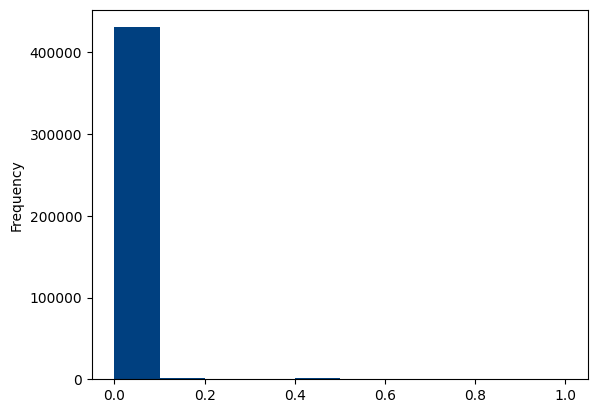

In [809]:
otrint['Mercado estimado inicial'].plot(kind='hist')

In [810]:
otrloc.drop_duplicates(inplace=True)

In [811]:
otrint = otrint.merge(otrloc[['codigo', 'Mercado estimado final']].rename(columns={'Mercado estimado final':'Mercado estimado final otrloc'}))
otrint.drop_duplicates(inplace=True)

In [812]:
otrint['Mercado estimado inicial'] = otrint['Mercado estimado inicial'] * otrint['Mercado estimado final otrloc']

In [813]:
otrint.drop(columns='Mercado estimado final otrloc', inplace=True)

In [814]:
otrint['Mercado estimado final'] = otrint.apply(lambda x: x['Importe Total Izipay'] if x['Importe Total Izipay'] > x['Mercado estimado inicial'] else x['Mercado estimado inicial'], axis=1)

In [815]:
otrint = otrint.loc[~otrint.duplicated(subset = ['codigo', 'en_izi', 'en_ibk', 'en_amex', 'trx', 'greco', 'nroruc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical', 'bolsa', 'facilitador', 'detalle_compania',
       'llave1', 'llave2', 'llave3', 'tarjeta', 'marca', 'Importe Data IBK',
       'Importe Data Amex', 'Importe Total Izipay', 'Importe IBK en Izipay',
       'Importe IBK en Enrut', 'Importe Total Izipay S/OnUs',
       'Importe IBK en Izipay S/OnUs','Ratio IBK en IZIPAY', 'Ratio IBK en Enrut',
       'Ratio IBK en IZIPAY S/OnUs', 'Mercado estimado inicial',
       'Mercado estimado final'],keep = 'last')]

In [816]:
otrint['Mercado estimado final'].sum() # 929467 en 202306

np.float64(421626.03246555605)

# Resultado Final <a class="anchor" id="chapter5"></a>

In [817]:
campo_list = ['codigo', 'en_izi', 'en_ibk', 'en_amex','trx', 'greco', 'nroruc', 'razsoc',
       'nombrecomercial', 'cartera', 'tipoproducto', 'compania', 'dpto', 'mcc',
       'giro', 'vertical','bolsa', 'facilitador','detalle_compania', 'tarjeta', 'marca',
       'Importe Data IBK', 'Importe Data Amex', 'Importe Total Izipay',
       'Importe IBK en Izipay', 'Importe IBK en Enrut',
       'Importe Total Izipay S/OnUs', 'Importe IBK en Izipay S/OnUs', 'Ratio IBK en IZIPAY',
       'Ratio IBK en Enrut', 'Ratio IBK en IZIPAY S/OnUs',
       'Mercado estimado inicial', 'Mercado estimado final']

In [818]:
tabla = pd.concat([amexloc[campo_list], amexint[campo_list], visadeb[campo_list],
                    visacred[campo_list], visaint[campo_list], mcdeb[campo_list],
                    mccred[campo_list], mcint[campo_list], dinloc[campo_list],
                    dinint[campo_list], otrloc[campo_list], otrint[campo_list]])

In [819]:
tabla['Importe Total Izipay'].sum()

np.float64(6388019888.119973)

In [820]:
izi.monto.sum()

np.float64(6388019925.009973)

In [821]:
tabla.shape

(5200454, 33)

In [822]:
#Se agrega la cartera

def cartera20(monto):
    if monto > 20000000:
        return 'CORP'
    elif monto < 20000000 and monto > 400000:
        return 'GGEE'
    elif monto < 400000 and monto > 40000:
        return 'EMP'
    elif monto < 40000:
        return 'NEG'

In [823]:
temp = tabla.dropna(subset='nroruc').groupby(by='nroruc')['Mercado estimado final'].sum().reset_index()
temp

,nroruc,Mercado estimado final
0,,1973.85
1,10000030843,40.00
2,10000108338,12040.60
3,10000111959,4227.00
4,10000112530,255.70
...,...,...
154231,9997210,1870.00
154232,9998513,659.00
154233,9998907,3129.70
154234,9999484,157.50


In [824]:
temp['cartera20'] = temp.apply(lambda x: cartera20(x['Mercado estimado final']), axis=1)

In [825]:
tabla = tabla.merge(temp[['nroruc', 'cartera20']], on='nroruc', how='left')
tabla

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final,cartera20
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5200449,999999_ZONAZUL CCO SANTAFE 12 3,0,1,0,1,NaN,NaN,NaN,ONAZUL CCO SANTAFE 12 3,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
5200450,999999_ZYROPE CAFE 9 4,0,1,0,3,NaN,NaN,NaN,YROPE CAFE 9 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
5200451,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN
5200452,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN


In [826]:
# por código de comercio
temp = tabla.loc[tabla.nroruc.isna()].groupby(by='codigo')['Mercado estimado final'].sum().reset_index()
temp

,codigo,Mercado estimado final
0,100000000_1580CIX LICORERIA,155.89
1,100000000_17 TH STREET,989.76
2,100000000_20565520734 MEDICAL AUDIC,117162.46
3,100000000_20600426649 OI2 EIRL,890.78
4,100000000_20610428062,107.22
...,...,...
197977,999999_ZONA GW 24 3,1190.34
197978,999999_ZONA IN 31 3,50.06
197979,999999_ZONAZUL CCO SANTAFE 12 3,1446.80
197980,999999_ZYROPE CAFE 9 4,1695.37


In [827]:
temp['cartera20'] = temp.apply(lambda x: cartera20(x['Mercado estimado final']), axis=1)

In [828]:
tabla = tabla.merge(temp[['codigo', 'cartera20']], on='codigo', how='left')
tabla

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final,cartera20_x,cartera20_y
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,EMP
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5200449,999999_ZONAZUL CCO SANTAFE 12 3,0,1,0,1,NaN,NaN,NaN,ONAZUL CCO SANTAFE 12 3,RETAIL,Fisico,OTROS,None,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
5200450,999999_ZYROPE CAFE 9 4,0,1,0,3,NaN,NaN,NaN,YROPE CAFE 9 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
5200451,999999_ZYROPE CAFE BAR LC 1 4,0,1,0,1,NaN,NaN,NaN,YROPE CAFE BAR LC 1 4,RETAIL,Fisico,OTROS,LIMA,9999,NaN,NaN,999999,NaN,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NEG
5200452,NaN,0,1,0,0,NaN,NaN,NaN,GARENA PE,NaN,Fisico,OTROS,LIMA,nan,NaN,NaN,NaN,PAYVALIDA,ND,F,Otros,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN


In [829]:
tabla['cartera20'] = tabla.apply(lambda x: x['cartera20_x'] if pd.notnull(x['cartera20_x']) else x['cartera20_y'], axis=1)

In [830]:
tabla.drop(columns=['cartera20_x', 'cartera20_y'], inplace=True)

In [831]:
tabla.drop_duplicates(subset = ['codigo', 'nroruc','tipoproducto','dpto','mcc','tarjeta','marca'],inplace = True)

In [832]:
tabla = tabla.dropna(subset=['codigo'])

In [833]:
# Filtramos las filas que coinciden con los criterios
filtro = (
    (tabla['nroruc'] == '20608644467') &
    (tabla['codigo'] == '5338228') &
    (tabla['marca'].str.lower() == 'visa') &
    (tabla['tarjeta'].str.upper() == 'TC') &
    (tabla['tipoproducto'].str.lower() == 'virtual')
)

In [834]:
valores = tabla.loc[filtro, 'Importe Total Izipay'].values

In [835]:
valores

array([1553210.57])

In [836]:
tabla.loc[filtro, ['Mercado estimado inicial', 'Mercado estimado final']] = np.tile(valores.reshape(-1, 1), (1, 2))

In [837]:
# Filtramos las filas que coinciden con los criterios
filtro = (
    (tabla['nroruc'] == '20337101276') &
    (tabla['codigo'] == '1052507') &
    (tabla['marca'].str.lower() == 'visa') &
    (tabla['tarjeta'].str.upper() == 'TC')
)

In [838]:
valores = tabla.loc[filtro, 'Importe Total Izipay'].values

In [839]:
valores

array([23128.81])

In [840]:
tabla.loc[filtro, ['Mercado estimado inicial', 'Mercado estimado final']] = np.tile(valores.reshape(-1, 1), (1, 2))

In [841]:
#tabla.to_csv('tablafinal_PRO.csv', sep='|', index=False)

In [842]:
tabla_bq = tabla.copy()

In [843]:
tabla_bq['process_date'] = var_fecha

In [844]:
tabla_bq.columns = tabla_bq.columns.str.replace(' ','_').str.replace('/','_').str.lower()

In [845]:
tabla_destino = f"{var_dataset_master_stage_transaction}.{var_table_t_potencial_cuenta}"

In [846]:
tabla_destino

'master_stage_transaction.t_potencial_cuenta'

In [847]:
tabla_bq.to_gbq(destination_table=tabla_destino,
          project_id=var_project_storage,
          if_exists='replace')  # Opciones: 'fail', 'replace', 'append'

100%|██████████| 1/1 [00:00<00:00, 7145.32it/s]


In [848]:
from google.cloud import bigquery
clientBQ = bigquery.Client()

In [849]:
job = clientBQ.query(query)
# Espera a que la consulta se complete
results = job.result()

In [850]:
# Llama al procedimiento almacenado con los parámetros
query = f"CALL `{var_project_operation}.{var_dataset_business_stage}.prc_load_table_dv_potencial_cuenta`('{var_project_storage}','{var_dataset_bi_apm}','{var_table_dv_potencial_cuenta}','{var_dataset_master_stage_transaction}','{var_table_t_potencial_cuenta}','{var_table_dv_potencial_cuenta_agrupado}','{var_table_dv_potencial_cuenta_detalle}');"
job = client.query(query)
# Espera a que la consulta se complete
results = job.result()

## Indicadores <a id="section_5_1"></a>

In [851]:
#tabla = pd.read_csv(r'tablafinal_PRO.csv',delimiter='|')
tabla.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final,cartera20
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,EMP
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG


In [852]:
print(tabla.shape[0]/12)

433369.0


In [853]:
tabla.codigo.nunique()

433369

In [854]:
tabla.nroruc.nunique()

154236

In [855]:
df.dropna(subset='nroruc').codigo.nunique()

235387

In [856]:
print(df.nroruc.nunique())
print(df.loc[df.nroruc.isna(), 'codigo'].nunique())

154236
197982


In [857]:
# cual es el número total de clientes? (considerando códigos sin RUC como clientes)
df.nroruc.nunique() + df.loc[df.nroruc.isna(), 'codigo'].nunique()

352218

### Mercado Estimado

In [858]:
# total izipay
print('Importe Total Izipay total:', tabla['Importe Total Izipay'].sum())

# total mercado estimado final
print('Mercado estimado final total:', tabla['Mercado estimado final'].sum())

# ratio importe total izipay total sobre mercado estimado final total
print('ratio importe total izipay total sobre mercado estimado final total:', tabla['Importe Total Izipay'].sum() / tabla['Mercado estimado final'].sum()*100)

Importe Total Izipay total: 6388019888.11997
Mercado estimado final total: 14916815226.734474
ratio importe total izipay total sobre mercado estimado final total: 42.824287832372704


In [859]:
tabla.head(20)

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final,cartera20
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,EMP
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
5,100000000_20611947489 DERMATOLOGI,0,1,0,211,NaN,NaN,NaN,20611947489 DERMATOLOGI,RETAIL,Fisico,OTROS,LIMA,8021,"Dentistas, Ortodoncistas",GRUPO 4 - SALUD,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
6,100000000_2REIS,0,1,0,1131,NaN,NaN,NaN,2REIS,RETAIL,Fisico,OTROS,LIMA,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
7,100000000_3 SABORES,0,1,0,11111,NaN,NaN,NaN,3 SABORES,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
8,100000000_360 AUTOMOTRIZ,0,1,0,1,NaN,NaN,NaN,360 AUTOMOTRIZ,NEG,Fisico,OTROS,None,7538,AUTOMOTIVE SERVICE SHOPS,GRUPO 6 - SERVICIOS / AUTOS,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,EMP
9,100000000_360 GRADOS,0,1,0,11111,NaN,NaN,NaN,360 GRADOS,RETAIL,Fisico,OTROS,JUNIN,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,NaN,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG


In [860]:
tabla[['tarjeta','Importe Total Izipay']].groupby('tarjeta').sum()

,Importe Total Izipay
tarjeta,
F,365341165.96
TC,2390945180.10
TD,3631733542.06


In [861]:
izi[['emisor','monto']].groupby('emisor').sum()

,monto
emisor,
Internacional,365341165.96
Local,6022669454.38


In [862]:
izi[['tipotarjeta','monto']].groupby('tipotarjeta').sum()

,monto
tipotarjeta,
Crédito,2669756634.40
Débito,3718263290.61


In [863]:
# agrupación por cartera
temp = tabla.groupby(by='cartera20')[['Importe Total Izipay', 'Mercado estimado final']].sum().reset_index()
temp.style.format(precision=1, thousands="'", decimal=".")

,cartera20,Importe Total Izipay,Mercado estimado final
0,CORP,3'267'205'084.2,6'686'370'994.0
1,EMP,684'951'286.1,2'372'076'480.8
2,GGEE,1'913'382'119.7,4'259'767'919.5
3,NEG,522'441'398.2,1'598'519'832.4


In [864]:
temp['Importe Total Izipay'].sum()

np.float64(6387979888.119976)

In [865]:
temp['Mercado estimado final'].sum()

np.float64(14916735226.734491)

In [866]:
temp['Importe Total Izipay'].sum()/temp['Mercado estimado final'].sum()

np.float64(0.428242493482832)

In [867]:
temp['porcentaje del mercado estimado final'] = temp['Mercado estimado final']/temp['Mercado estimado final'].sum()*100
temp.style.format(precision=1, thousands="'", decimal=".")

,cartera20,Importe Total Izipay,Mercado estimado final,porcentaje del mercado estimado final
0,CORP,3'267'205'084.2,6'686'370'994.0,44.8
1,EMP,684'951'286.1,2'372'076'480.8,15.9
2,GGEE,1'913'382'119.7,4'259'767'919.5,28.6
3,NEG,522'441'398.2,1'598'519'832.4,10.7


In [868]:
temp['ratio izipay mercado por cartera'] = temp['Importe Total Izipay'] / temp['Mercado estimado final']*100
temp['% de mercado final'] = temp['porcentaje del mercado estimado final'] * temp['ratio izipay mercado por cartera'] /100
temp.style.format(precision=1, thousands="'", decimal=".")

,cartera20,Importe Total Izipay,Mercado estimado final,porcentaje del mercado estimado final,ratio izipay mercado por cartera,% de mercado final
0,CORP,3'267'205'084.2,6'686'370'994.0,44.8,48.9,21.9
1,EMP,684'951'286.1,2'372'076'480.8,15.9,28.9,4.6
2,GGEE,1'913'382'119.7,4'259'767'919.5,28.6,44.9,12.8
3,NEG,522'441'398.2,1'598'519'832.4,10.7,32.7,3.5


In [869]:
duplicados = tabla.duplicated()
duplicados_totales = duplicados.sum()
print(f"Número de filas duplicadas en toda la tabla: {duplicados_totales}")

Número de filas duplicadas en toda la tabla: 0


In [870]:
# Mostrar las filas duplicadas (si existen)
filas_duplicadas = tabla[tabla.duplicated(keep=False)]
print("Filas duplicadas en la tabla:")
print(filas_duplicadas)

Filas duplicadas en la tabla:
Empty DataFrame
Columns: [codigo, en_izi, en_ibk, en_amex, trx, greco, nroruc, razsoc, nombrecomercial, cartera, tipoproducto, compania, dpto, mcc, giro, vertical, bolsa, facilitador, detalle_compania, tarjeta, marca, Importe Data IBK, Importe Data Amex, Importe Total Izipay, Importe IBK en Izipay, Importe IBK en Enrut, Importe Total Izipay S/OnUs, Importe IBK en Izipay S/OnUs, Ratio IBK en IZIPAY, Ratio IBK en Enrut, Ratio IBK en IZIPAY S/OnUs, Mercado estimado inicial, Mercado estimado final, cartera20]
Index: []


In [871]:
# agrupación por FACILITADOR
# Agrupación por 'facilitador' y suma de columnas
tabla['detalle_compania'] = tabla['detalle_compania'].fillna('Sin facilitador')
temp = tabla.groupby(by=['detalle_compania','tipoproducto'])[['Importe Total Izipay', 'Mercado estimado final']].sum()
# Formatear el DataFrame
temp.style.format(precision=1, thousands="'", decimal=".")

In [872]:
# agrupación por FACILITADOR
# Agrupación por 'facilitador' y suma de columnas
tabla['facilitador'] = tabla['facilitador'].fillna('Sin facilitador')
temp = tabla.groupby(by=['facilitador','tipoproducto'])[['Importe Total Izipay', 'Mercado estimado final']].sum()
# Formatear el DataFrame
temp.style.format(precision=1, thousands="'", decimal=".")

,,Importe Total Izipay,Mercado estimado final
facilitador,tipoproducto,,
ALIGNET,Virtual,638'022.2,4'910'304.9
ATIX,Virtual,0.0,70'223.3
BCP,Virtual,0.0,160'476'589.7
BMB,Virtual,0.0,1'122'309.4
BNACION,Virtual,3'555.4,3'555.4
C,Fisico,0.0,489.6
CULQI,Virtual,0.0,29'894'900.7
DP,Virtual,0.0,72'159'307.7
DTV,Fisico,0.0,726.8


In [873]:
temp['Importe Total Izipay'].sum()

np.float64(6388019888.119975)

In [874]:
temp['Mercado estimado final'].sum()

np.float64(14916815226.734491)

In [875]:
temp['Importe Total Izipay'].sum()/temp['Mercado estimado final'].sum()

np.float64(0.42824287832372687)

In [876]:
temp['porcentaje del mercado estimado final'] = temp['Mercado estimado final']/temp['Mercado estimado final'].sum()*100
temp.style.format(precision=1, thousands="'", decimal=".")

,,Importe Total Izipay,Mercado estimado final,porcentaje del mercado estimado final
facilitador,tipoproducto,,,
ALIGNET,Virtual,638'022.2,4'910'304.9,0.0
ATIX,Virtual,0.0,70'223.3,0.0
BCP,Virtual,0.0,160'476'589.7,1.1
BMB,Virtual,0.0,1'122'309.4,0.0
BNACION,Virtual,3'555.4,3'555.4,0.0
C,Fisico,0.0,489.6,0.0
CULQI,Virtual,0.0,29'894'900.7,0.2
DP,Virtual,0.0,72'159'307.7,0.5
DTV,Fisico,0.0,726.8,0.0


In [877]:
temp['ratio izipay mercado por cartera'] = temp['Importe Total Izipay'] / temp['Mercado estimado final']*100
temp['% de mercado final'] = temp['porcentaje del mercado estimado final'] * temp['ratio izipay mercado por cartera'] /100
temp.style.format(precision=1, thousands="'", decimal=".")

,,Importe Total Izipay,Mercado estimado final,porcentaje del mercado estimado final,ratio izipay mercado por cartera,% de mercado final
facilitador,tipoproducto,,,,,
ALIGNET,Virtual,638'022.2,4'910'304.9,0.0,13.0,0.0
ATIX,Virtual,0.0,70'223.3,0.0,0.0,0.0
BCP,Virtual,0.0,160'476'589.7,1.1,0.0,0.0
BMB,Virtual,0.0,1'122'309.4,0.0,0.0,0.0
BNACION,Virtual,3'555.4,3'555.4,0.0,100.0,0.0
C,Fisico,0.0,489.6,0.0,0.0,0.0
CULQI,Virtual,0.0,29'894'900.7,0.2,0.0,0.0
DP,Virtual,0.0,72'159'307.7,0.5,0.0,0.0
DTV,Fisico,0.0,726.8,0.0,0.0,0.0


In [878]:
# total rucs del mercado
print('total rucs:', tabla.dropna(subset='nroruc').nroruc.nunique())

print('codigos sin ruc:', tabla.loc[tabla.nroruc.isna()].codigo.nunique())

total rucs: 154236
codigos sin ruc: 197982


In [879]:
# volumen transaccionado del mercado por verticales
tabla.groupby(by='vertical')['Mercado estimado final'].sum().reset_index().style.format(precision=1, decimal=".")

,vertical,Mercado estimado final
0,GRUPO 1 - SUPERMERCADOS / HOGAR,4416335917.3
1,GRUPO 2 - ROPA / ACCESORIOS,1194998425.0
2,GRUPO 3 - RESTAURANTES,1497869207.1
3,GRUPO 4 - SALUD,1073089779.3
4,GRUPO 5 - TURISMO / TRANSPORTE / ENTRETENIMIENTO,2093400281.4
5,GRUPO 6 - SERVICIOS / AUTOS,2264621742.7
6,GRUPO 7 - BANCOS / SEGUROS,1240660775.9
7,GRUPO 9 - GOBIERNO / ENTIDADES PUBLICAS,882409952.2


In [880]:
# distribución del mercado por tipo de producto
temp = tabla.groupby(by='tipoproducto')[['Importe Total Izipay','Mercado estimado final']].sum().reset_index()
temp['ratio del mercado estimado final'] = temp['Mercado estimado final'] / temp['Mercado estimado final'].sum()*100
temp['ratio izipay'] = temp['Importe Total Izipay'] / temp['Mercado estimado final'] *100
temp.style.format(precision=1, thousands="'", decimal=".")

,tipoproducto,Importe Total Izipay,Mercado estimado final,ratio del mercado estimado final,ratio izipay
0,Fisico,4'860'911'293.4,9'856'063'635.2,66.1,49.3
1,Virtual,1'527'108'594.7,5'060'751'591.5,33.9,30.2


In [881]:
tabla.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5200428 entries, 0 to 5200451
Data columns (total 34 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   codigo                        object 
 1   en_izi                        object 
 2   en_ibk                        object 
 3   en_amex                       object 
 4   trx                           object 
 5   greco                         object 
 6   nroruc                        object 
 7   razsoc                        object 
 8   nombrecomercial               object 
 9   cartera                       object 
 10  tipoproducto                  object 
 11  compania                      object 
 12  dpto                          object 
 13  mcc                           object 
 14  giro                          object 
 15  vertical                      object 
 16  bolsa                         object 
 17  facilitador                   object 
 18  detalle_compania           

In [882]:
# distribución del mercado por tipo de producto
tabla_filtrada = tabla[tabla['en_izi'] == '1']
temp = tabla_filtrada.groupby(by=['marca'])[['Importe Total Izipay','Mercado estimado final'
                                                        ,'Importe Data IBK','Importe IBK en Izipay']].sum().reset_index()
temp.style.format(precision=1, decimal=".")

,marca,Importe Total Izipay,Mercado estimado final,Importe Data IBK,Importe IBK en Izipay
0,Amex,343613519.5,344238742.8,209695346.4,196483651.3
1,Diners,80007004.5,87122429.0,0.0,0.0
2,Mastercard,394946609.1,413012733.3,0.0,0.0
3,Otros,4820093.4,4828394.6,0.0,0.0
4,Visa,5564632661.6,5939805224.3,546867348.1,706772551.9


In [883]:
# distribución del mercado por tipo de producto
temp = tabla.groupby(by=['tipoproducto', 'cartera20'])[['Importe Total Izipay','Mercado estimado final']].sum().reset_index()
temp['ratio del mercado estimado final'] = temp['Mercado estimado final'] / temp['Mercado estimado final'].sum()*100
temp['ratio izipay'] = temp['Importe Total Izipay'] / temp['Mercado estimado final'] *100
temp.style.format(precision=1, thousands="'", decimal=".")

,tipoproducto,cartera20,Importe Total Izipay,Mercado estimado final,ratio del mercado estimado final,ratio izipay
0,Fisico,CORP,2'109'683'137.9,3'603'662'178.4,24.2,58.5
1,Fisico,EMP,641'068'982.9,1'999'656'010.2,13.4,32.1
2,Fisico,GGEE,1'648'766'966.5,2'983'993'766.5,20.0,55.3
3,Fisico,NEG,461'392'206.1,1'268'711'680.1,8.5,36.4
4,Virtual,CORP,1'157'521'946.3,3'082'708'815.6,20.7,37.5
5,Virtual,EMP,43'882'303.2,372'420'470.6,2.5,11.8
6,Virtual,GGEE,264'615'153.2,1'275'774'153.0,8.6,20.7
7,Virtual,NEG,61'049'192.1,329'808'152.3,2.2,18.5


In [884]:
tabla.tarjeta.value_counts(dropna=False)

,count
tarjeta,
F,2166845
TC,1733476
TD,1300107


In [885]:
# distribución del mercado por tipo de tarjeta
temp = tabla.groupby(by='tarjeta')['Mercado estimado final'].sum().reset_index()
temp['ratio del mercado estimado final'] = temp['Mercado estimado final'] / temp['Mercado estimado final'].sum()*100
temp

,tarjeta,Mercado estimado final,ratio del mercado estimado final
0,F,383656699.99,2.57
1,TC,6584719852.36,44.14
2,TD,7948438674.38,53.29


In [886]:
# volumen transaccionado en le mercado por departamento
temp = tabla.groupby(by='dpto')[['Importe Total Izipay', 'Mercado estimado final']].sum().reset_index().sort_values(by='Mercado estimado final', ascending=False)
temp['% del mercado estimado final'] = temp['Mercado estimado final'] / temp['Mercado estimado final'].sum()*100
temp.style.format(precision=1, thousands="'", decimal=".")

,dpto,Importe Total Izipay,Mercado estimado final,% del mercado estimado final
13,LIMA,4'612'915'217.9,11'502'986'342.9,77.1
11,LA LIBERTAD,216'637'150.6,492'648'039.8,3.3
3,AREQUIPA,242'587'693.9,431'975'205.7,2.9
19,PIURA,212'995'374.0,374'652'121.2,2.5
6,CUSCO,221'717'852.1,316'550'505.1,2.1
12,LAMBAYEQUE,156'928'528.4,276'314'415.4,1.9
9,ICA,146'675'399.2,251'268'502.6,1.7
17,None,0.0,217'993'339.0,1.5
10,JUNIN,85'349'178.8,152'286'516.8,1.0
1,ANCASH,73'189'002.5,135'253'421.7,0.9


In [887]:
# volumen de mercado por cartera
temp = tabla.groupby(by='cartera20')['Mercado estimado final'].sum().reset_index().sort_values(by='Mercado estimado final', ascending=False)
temp['ratio del mercado estimado final'] = temp['Mercado estimado final'] / temp['Mercado estimado final'].sum()*100
temp

,cartera20,Mercado estimado final,ratio del mercado estimado final
0,CORP,6686370994.01,44.82
2,GGEE,4259767919.48,28.56
1,EMP,2372076480.81,15.90
3,NEG,1598519832.43,10.72


In [888]:
# número de rucs identificados
temp = tabla.dropna(subset='nroruc').groupby(by='cartera20').nroruc.nunique().reset_index()
temp['porcentaje de # de rucs'] = temp['nroruc'] / tabla.dropna(subset='nroruc').nroruc.nunique()*100
print(temp['nroruc'].sum())
temp

154234


,cartera20,nroruc,porcentaje de # de rucs
0,CORP,61,0.04
1,EMP,7871,5.10
2,GGEE,1504,0.98
3,NEG,144798,93.88


In [889]:
# número de rucs identificados
temp = tabla.dropna(subset='nroruc').groupby(by='cartera').nroruc.nunique().reset_index()
temp['porcentaje de # de rucs'] = temp['nroruc'] / tabla.dropna(subset='nroruc').nroruc.nunique()*100
temp.loc['total'] = temp.sum(axis=0)
print(temp['nroruc'].sum())
temp

316068


,cartera,nroruc,porcentaje de # de rucs
0,BC,315,0.20
1,BE,2952,1.91
2,BI,384,0.25
3,BPE,58419,37.88
4,CORP,396,0.26
5,NEG,3328,2.16
6,RETAIL,92240,59.80
total,BCBEBIBPECORPNEGRETAIL,158034,102.46


In [890]:
# número de rucs sin identificar
temp = tabla.loc[tabla.nroruc.isna()].groupby(by='cartera20').codigo.nunique().reset_index()
temp

,cartera20,codigo
0,CORP,16
1,EMP,15496
2,GGEE,976
3,NEG,181494


In [891]:
# número de códigos de comercio identificados
temp = tabla.groupby(by='cartera20').codigo.nunique().reset_index()
temp['porcentaje de # de codigo'] = temp['codigo'] / tabla.codigo.nunique()*100
temp

,cartera20,codigo,porcentaje de # de codigo
0,CORP,11874,2.74
1,EMP,40996,9.46
2,GGEE,29592,6.83
3,NEG,350905,80.97


In [892]:
tabla.tipoproducto.value_counts()

,count
tipoproducto,
Fisico,4018944
Virtual,1181484


In [893]:
# agrupación por cartera de tipo producto físico
temp = tabla.query('tipoproducto=="Fisico"').groupby(by='cartera20')[['Importe Total Izipay', 'Mercado estimado final']].sum().reset_index()
temp['ratio izipay mercado estimado'] = temp['Importe Total Izipay'] / temp['Mercado estimado final']*100
temp

,cartera20,Importe Total Izipay,Mercado estimado final,ratio izipay mercado estimado
0,CORP,2109683137.90,3603662178.42,58.54
1,EMP,641068982.92,1999656010.24,32.06
2,GGEE,1648766966.51,2983993766.47,55.25
3,NEG,461392206.07,1268711680.09,36.37


In [894]:
# agrupación por cartera de tipo producto virtual
temp = tabla.query('tipoproducto=="Virtual"').groupby(by='cartera20')[['Importe Total Izipay', 'Mercado estimado final']].sum().reset_index()
temp['ratio izipay mercado estimado'] = temp['Importe Total Izipay'] / temp['Mercado estimado final']*100
temp

,cartera20,Importe Total Izipay,Mercado estimado final,ratio izipay mercado estimado
0,CORP,1157521946.29,3082708815.60,37.55
1,EMP,43882303.15,372420470.57,11.78
2,GGEE,264615153.17,1275774153.00,20.74
3,NEG,61049192.11,329808152.35,18.51


In [895]:
izi.codigo.nunique()

197012

In [896]:
ibk.codigo.nunique()

348551

In [897]:
amex.codigo.nunique()

27121

In [898]:
tabla.codigo.nunique()

433369

In [899]:
tabla.cartera20.value_counts()

,count
cartera20,
NEG,4210860
EMP,491952
GGEE,355104
CORP,142488


In [900]:
tabla.cartera.value_counts()

,count
cartera,
RETAIL,3393240
BPE,942768
NEG,345996
BE,174648
BC,160824
CORP,153192
BI,29760


In [901]:
tabla.groupby(by=['tipoproducto'])[['Importe Total Izipay','Mercado estimado final']].sum().reset_index().style.format(precision=1, thousands="'", decimal=".")

,tipoproducto,Importe Total Izipay,Mercado estimado final
0,Fisico,4'860'911'293.4,9'856'063'635.2
1,Virtual,1'527'108'594.7,5'060'751'591.5


In [902]:
tabla.groupby(by=['tipoproducto', 'marca'])['Mercado estimado final'].sum().reset_index().style.format(precision=1, thousands="'", decimal=".")

,tipoproducto,marca,Mercado estimado final
0,Fisico,Amex,291'189'639.2
1,Fisico,Diners,69'382'287.1
2,Fisico,Mastercard,380'184'456.5
3,Fisico,Otros,5'598'568.6
4,Fisico,Visa,9'109'708'683.9
5,Virtual,Amex,220'262'383.9
6,Virtual,Diners,54'340'111.0
7,Virtual,Mastercard,151'132'874.6
8,Virtual,Otros,843'509.0
9,Virtual,Visa,4'634'172'713.0


In [903]:
tabla['Mercado estimado final'].sum()

np.float64(14916815226.734474)

In [904]:
tabla.groupby(by=['tarjeta', 'marca'])['Mercado estimado final'].sum().reset_index().style.format(precision=1, thousands="'", decimal=".")

,tarjeta,marca,Mercado estimado final
0,F,Amex,71'211'785.7
1,F,Diners,3'280'100.0
2,F,Mastercard,135'901'389.3
3,F,Otros,421'626.0
4,F,Visa,172'841'798.9
5,TC,Amex,440'240'237.3
6,TC,Diners,120'442'298.1
7,TC,Mastercard,244'760'483.5
8,TC,Visa,5'779'276'833.5
9,TD,Mastercard,150'655'458.4


In [905]:
tabla.loc[tabla['en_izi']=='1'].codigo.nunique()

197012

In [906]:
izi.codigo.nunique()

197012

In [907]:
tabla.head()

,codigo,en_izi,en_ibk,en_amex,trx,greco,nroruc,razsoc,nombrecomercial,cartera,tipoproducto,compania,dpto,mcc,giro,vertical,bolsa,facilitador,detalle_compania,tarjeta,marca,Importe Data IBK,Importe Data Amex,Importe Total Izipay,Importe IBK en Izipay,Importe IBK en Enrut,Importe Total Izipay S/OnUs,Importe IBK en Izipay S/OnUs,Ratio IBK en IZIPAY,Ratio IBK en Enrut,Ratio IBK en IZIPAY S/OnUs,Mercado estimado inicial,Mercado estimado final,cartera20
0,100000000_1580CIX LICORERIA,0,1,0,1,NaN,NaN,NaN,1580CIX LICORERIA,RETAIL,Fisico,OTROS,LAMBAYEQUE,5735,Discos y casettes,GRUPO 2 - ROPA / ACCESORIOS,100000000,Sin facilitador,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
1,100000000_17 TH STREET,0,1,0,12,NaN,NaN,NaN,17 TH STREET,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,Sin facilitador,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
2,100000000_20565520734 MEDICAL AUDIC,0,1,0,1111,NaN,NaN,NaN,20565520734 MEDICAL AUDIC,RETAIL,Fisico,OTROS,AREQUIPA,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,Sin facilitador,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,EMP
3,100000000_20600426649 OI2 EIRL,0,1,0,11,NaN,NaN,NaN,20600426649 OI2 EIRL,RETAIL,Fisico,OTROS,None,5976,Aparatos ortopedicos,GRUPO 4 - SALUD,100000000,Sin facilitador,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG
4,100000000_20610428062,0,1,0,1,NaN,NaN,NaN,20610428062,RETAIL,Fisico,OTROS,None,5812,Restaurantes,GRUPO 3 - RESTAURANTES,100000000,Sin facilitador,ND,TC,Amex,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0.00,0.00,0.00,0.00,NEG


In [908]:
tabla['nroruc_final'] = tabla['nroruc'].fillna(tabla['codigo'])

identificado = tabla[tabla['nroruc'].notna()]
sin_identificar = tabla[tabla['nroruc'].isna()]

# Calcular el "Mercado Estimado Final" como la suma de 'monto'
mercado_estimado_final_con_bolsa = identificado['Mercado estimado final'].sum()
mercado_estimado_final_sin_bolsa = sin_identificar['Mercado estimado final'].sum()

# Obtener la cantidad de códigos y RUCs únicos
cantidad_codigos_unicos_con_bolsa = identificado['codigo'].nunique()
cantidad_codigos_unicos_sin_bolsa = sin_identificar['codigo'].nunique()

cantidad_rucs_unicos_con_bolsa = identificado['nroruc_final'].nunique()
cantidad_rucs_unicos_sin_bolsa = sin_identificar['nroruc_final'].nunique()

# Imprimir los resultados
print(f"Mercado Estimado Final (identificado): {mercado_estimado_final_con_bolsa}")
print(f"Cantidad de Códigos Únicos (identificado): {cantidad_codigos_unicos_con_bolsa}")
print(f"Cantidad de RUCs Únicos (identificado): {cantidad_rucs_unicos_con_bolsa}")

print(f"\nMercado Estimado Final (sin_identificar): {mercado_estimado_final_sin_bolsa}")
print(f"Cantidad de Códigos Únicos (sin_identificar): {cantidad_codigos_unicos_sin_bolsa}")
print(f"Cantidad de RUCs Únicos (sin_identificar): {cantidad_rucs_unicos_sin_bolsa}")

Mercado Estimado Final (identificado): 10407123912.21989
Cantidad de Códigos Únicos (identificado): 235387
Cantidad de RUCs Únicos (identificado): 154236

Mercado Estimado Final (sin_identificar): 4509691314.5146
Cantidad de Códigos Únicos (sin_identificar): 197982
Cantidad de RUCs Únicos (sin_identificar): 197982


In [909]:
# Filtrar registros con y sin valor en la columna 'bolsa'
tabla['nroruc_final'] = tabla['nroruc'].fillna(tabla['codigo'])

con_bolsa = tabla[tabla['codigo'].str.contains('_')]
sin_bolsa = tabla[~tabla['codigo'].str.contains('_')]

# Calcular el "Mercado Estimado Final" como la suma de 'monto'
mercado_estimado_final_con_bolsa = con_bolsa['Mercado estimado final'].sum()
mercado_estimado_final_sin_bolsa = sin_bolsa['Mercado estimado final'].sum()

# Obtener la cantidad de códigos y RUCs únicos
cantidad_codigos_unicos_con_bolsa = con_bolsa['codigo'].nunique()
cantidad_codigos_unicos_sin_bolsa = sin_bolsa['codigo'].nunique()

cantidad_rucs_unicos_con_bolsa = con_bolsa['nroruc_final'].nunique()
cantidad_rucs_unicos_sin_bolsa = sin_bolsa['nroruc_final'].nunique()

# Imprimir los resultados
print(f"Mercado Estimado Final (con bolsa): {mercado_estimado_final_con_bolsa}")
print(f"Cantidad de Códigos Únicos (con bolsa): {cantidad_codigos_unicos_con_bolsa}")
print(f"Cantidad de RUCs Únicos (con bolsa): {cantidad_rucs_unicos_con_bolsa}")

print(f"\nMercado Estimado Final (sin bolsa): {mercado_estimado_final_sin_bolsa}")
print(f"Cantidad de Códigos Únicos (sin bolsa): {cantidad_codigos_unicos_sin_bolsa}")
print(f"Cantidad de RUCs Únicos (sin bolsa): {cantidad_rucs_unicos_sin_bolsa}")


Mercado Estimado Final (con bolsa): 1912205860.2770245
Cantidad de Códigos Únicos (con bolsa): 115933
Cantidad de RUCs Únicos (con bolsa): 115933

Mercado Estimado Final (sin bolsa): 13004609366.45748
Cantidad de Códigos Únicos (sin bolsa): 317436
Cantidad de RUCs Únicos (sin bolsa): 236259


In [910]:
# Filtrar registros con y sin valor en la columna 'bolsa'
tabla['nroruc_final'] = tabla['nroruc'].fillna(tabla['codigo'])

# Filtrar registros para clientes y no clientes
clientes = tabla[tabla['en_izi'] == '1']
no_clientes = tabla[tabla['en_izi'] == '0']

# Calcular el "Mercado Estimado Final" como la suma de 'monto'
mercado_estimado_final_con_bolsa = clientes['Mercado estimado final'].sum()
mercado_estimado_final_sin_bolsa = no_clientes['Mercado estimado final'].sum()

# Obtener la cantidad de códigos y RUCs únicos
cantidad_codigos_unicos_con_bolsa = clientes['codigo'].nunique()
cantidad_codigos_unicos_sin_bolsa = no_clientes['codigo'].nunique()

# Imprimir los resultados
print(f"Mercado Estimado Final (clientes): {mercado_estimado_final_con_bolsa}")
print(f"Cantidad de Códigos Únicos (clientes): {cantidad_codigos_unicos_con_bolsa}")

print(f"\nMercado Estimado Final (no_clientes): {mercado_estimado_final_sin_bolsa}")
print(f"Cantidad de Códigos Únicos (no_clientes): {cantidad_codigos_unicos_sin_bolsa}")

Mercado Estimado Final (clientes): 6789007524.1454525
Cantidad de Códigos Únicos (clientes): 197012

Mercado Estimado Final (no_clientes): 8127807702.589037
Cantidad de Códigos Únicos (no_clientes): 236357


In [911]:
# Agrupar por 'nroruc_final' y calcular el valor máximo de 'en_izi' para cada grupo
tabla['es_cliente'] = tabla.groupby('nroruc_final')['en_izi'].transform('max')

# Filtrar registros para clientes y no clientes basados en el valor máximo de 'en_izi'
clientes = tabla[tabla['es_cliente'] == '1']
no_clientes = tabla[tabla['es_cliente'] == '0']

cantidad_rucs_unicos_clientes = clientes['nroruc_final'].nunique()
cantidad_rucs_unicos_no_clientes = no_clientes['nroruc_final'].nunique()

# Imprimir los resultados
print(f"Cantidad de RUCs Únicos (clientes): {cantidad_rucs_unicos_clientes}")
print(f"Cantidad de RUCs Únicos (no_clientes): {cantidad_rucs_unicos_no_clientes}")

Cantidad de RUCs Únicos (clientes): 142405
Cantidad de RUCs Únicos (no_clientes): 209787


In [912]:
# Agrupar por 'nroruc' y calcular la suma de 'Importe total izipay' y 'Mercado estimado final'

# Filtrar registros con y sin valor en la columna 'bolsa'
tabla['nroruc_final'] = tabla['nroruc'].fillna(tabla['codigo'])


agrupado = tabla.groupby('nroruc_final').agg({
    'codigo': 'nunique',
    'Importe Total Izipay': 'sum',
    'Mercado estimado final': 'sum'
}).reset_index()

# Determinar los grupos basados en las condiciones proporcionadas
def clasificar_fila(row):
    if row['Importe Total Izipay'] == row['Mercado estimado final']:
        return 'Exclusivo Izipay'
    elif 0 < row['Importe Total Izipay'] < row['Mercado estimado final']:
        return 'Compartido'
    elif row['Importe Total Izipay'] == 0 and row['Mercado estimado final'] > 0:
        return 'Exclusivo Competencia'
    else:
        return 'Otro'

agrupado['Grupo'] = agrupado.apply(clasificar_fila, axis=1)

# Imprimir los resultados
agrupado.head(10)

,nroruc_final,codigo,Importe Total Izipay,Mercado estimado final,Grupo
0,,1,1956.50,1973.85,Compartido
1,100000000_1580CIX LICORERIA,1,0.00,155.89,Exclusivo Competencia
2,100000000_17 TH STREET,1,0.00,989.76,Exclusivo Competencia
3,100000000_20565520734 MEDICAL AUDIC,1,0.00,117162.46,Exclusivo Competencia
4,100000000_20600426649 OI2 EIRL,1,0.00,890.78,Exclusivo Competencia
5,100000000_20610428062,1,0.00,107.22,Exclusivo Competencia
6,100000000_20611947489 DERMATOLOGI,1,0.00,7591.35,Exclusivo Competencia
7,100000000_2REIS,1,0.00,6287.21,Exclusivo Competencia
8,100000000_3 SABORES,1,0.00,1121.72,Exclusivo Competencia
9,100000000_360 AUTOMOTRIZ,1,0.00,41239.87,Exclusivo Competencia


In [913]:
# Convertir 'nroruc_final' a tipo string para asegurar que se cuenten como únicos
agrupado['nroruc_final'] = agrupado['nroruc_final'].astype(str)

# Agrupar por 'Grupo' y 'nroruc_final' y calcular el conteo de 'nroruc_final' único, suma de 'codigo' y suma de 'Mercado estimado final'
resultado = agrupado.groupby('Grupo').agg({
    'nroruc_final': 'nunique',
    'codigo': 'sum',
    'Mercado estimado final': 'sum',
    'Importe Total Izipay': 'sum'
}).reset_index()

# Renombrar las columnas para mayor claridad
resultado = resultado.rename(columns={
    'nroruc_final': 'Cantidad de RUCs Únicos',
    'codigo': 'Suma de Códigos',
    'Mercado estimado final': 'Volumen del Mercado Estimado Final',
    'Importe Total Izipay': 'Volumen izipay'
})

resultado

,Grupo,Cantidad de RUCs Únicos,Suma de Códigos,Volumen del Mercado Estimado Final,Volumen izipay
0,Compartido,23969,79297,9011845972.22,5759270776.21
1,Exclusivo Competencia,206295,218364,5276220142.60,0.00
2,Exclusivo Izipay,121927,135707,628748359.11,628748359.11
3,Otro,1,1,752.80,752.80
